In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
import sqlite3
from sklearn.metrics import accuracy_score,mean_squared_error,mean_absolute_error,r2_score
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import os
from IPython.display import Markdown,display

In [2]:
api_key=os.environ.get("GOOGLE_API_KEY")
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0.5)

In [3]:
conn = sqlite3.connect("C:\\Users\\EfrenMariscal\\Documents\\data scientific\\kaggle\\socialMediaAdvertisement\\ad_campaign_db.sqlite")
df_ads=pd.read_sql("SELECT * FROM ads;",conn)
df_ads

,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology
3,4,28,Facebook,Stories,Female,25-34,news
4,5,24,Instagram,Image,Female,25-34,news
...,...,...,...,...,...,...,...
195,196,12,Facebook,Stories,Male,35-44,"gaming, sports"
196,197,9,Facebook,Stories,All,All,"lifestyle, gaming"
197,198,34,Facebook,Video,All,35-44,"fitness, lifestyle"
198,199,15,Instagram,Video,Male,25-34,"art, news"


In [4]:
df_users=pd.read_sql("SELECT * FROM users",conn)
df_users

,user_id,user_gender,user_age,age_group,country,location,interests
0,a2474,Female,24,18-24,United Kingdom,New Mariomouth,"fitness, health"
1,141e5,Male,21,18-24,Germany,Danielsfort,"food, fitness, lifestyle"
2,34db0,Male,27,25-34,Australia,Vincentchester,"fashion, news"
3,20d08,Female,28,25-34,India,Lisaport,"health, news, finance"
4,9e830,Male,28,25-34,United States,Brownmouth,"health, photography, lifestyle"
...,...,...,...,...,...,...,...
9995,24364,Male,18,18-24,United States,Curtisside,"travel, fashion, art"
9996,68b82,Male,24,18-24,Mexico,Brownland,finance
9997,39f39,Male,29,25-34,United States,Watersburgh,health
9998,0b8e7,Male,31,25-34,United Kingdom,South Kenneth,"art, fashion"


In [5]:
df_campaigns=pd.read_sql("SELECT * FROM campaigns",conn)
df_campaigns.head(10)

,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32
1,2,Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41
2,3,Campaign_3_Winter,2025-05-04,2025-06-29,56,14343.25
3,4,Campaign_4_Summer,2025-06-04,2025-08-08,65,45326.60
4,5,Campaign_5_Launch,2025-07-11,2025-08-28,48,68376.69
5,6,Campaign_6_Winter,2025-06-21,2025-09-13,84,78607.49
6,7,Campaign_7_Winter,2025-05-25,2025-08-05,72,43744.59
7,8,Campaign_8_Q3,2025-02-25,2025-04-07,41,39953.19
8,9,Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07
9,10,Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27


In [6]:
df_ad_events=pd.read_sql("SELECT * FROM ad_events ORDER BY RANDOM() LIMIT 40000;",conn)
df_ad_events

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,312834,49,d75a9,2025-06-23 08:53:09,Monday,Morning,Impression
1,293696,185,0023e,2025-08-01 23:33:29,Friday,Evening,Impression
2,371590,12,f49e6,2025-05-20 06:38:48,Tuesday,Morning,Impression
3,384253,109,1eefe,2025-06-19 07:14:57,Thursday,Morning,Click
4,183939,35,540bb,2025-07-22 01:11:22,Tuesday,Night,Impression
...,...,...,...,...,...,...,...
39995,9391,33,b849a,2025-07-03 09:24:09,Thursday,Morning,Click
39996,119599,145,33df1,2025-07-30 23:59:56,Wednesday,Evening,Impression
39997,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression
39998,213903,106,0078e,2025-05-10 21:51:23,Saturday,Evening,Impression


## ANALYZING USERS TABLE

In [7]:
df_users.head(5)

,user_id,user_gender,user_age,age_group,country,location,interests
0,a2474,Female,24,18-24,United Kingdom,New Mariomouth,"fitness, health"
1,141e5,Male,21,18-24,Germany,Danielsfort,"food, fitness, lifestyle"
2,34db0,Male,27,25-34,Australia,Vincentchester,"fashion, news"
3,20d08,Female,28,25-34,India,Lisaport,"health, news, finance"
4,9e830,Male,28,25-34,United States,Brownmouth,"health, photography, lifestyle"


In [9]:
df_users_dict=df_users.sample(n=1000,random_state=42)
df_users_dict=df_users_dict.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_users_dict})
display(Markdown(response.content))

This dataset contains user demographic and interest information. Each record represents a single user with the following attributes:

*   **`user_id`**: A unique identifier for each user.
*   **`user_gender`**: The self-identified gender of the user (e.g., 'Female', 'Male', 'Other').
*   **`user_age`**: The numerical age of the user.
*   **`age_group`**: A categorical grouping of user ages (e.g., '16-17', '18-24', '25-34', '35-44', '45-54', '55-65').
*   **`country`**: The user's country of residence.
*   **`location`**: A more specific geographical location within the country.
*   **`interests`**: A comma-separated string listing the user's interests.

---

### How to Analyze the Dataset

The goal of analyzing this dataset would typically be to understand user demographics, identify popular interests, and discover how interests vary across different demographic segments.

**1. Data Preparation (Crucial Step):**

*   **Interests Transformation:** The `interests` field is a string of comma-separated values. For effective analysis, you'll need to split this string into individual interests for each user. This can be done by:
    *   Creating a list of interests for each user.
    *   Alternatively, "one-hot encoding" interests, where each unique interest becomes a new binary column (1 if the user has that interest, 0 otherwise). This is often preferred for frequency analysis.

**2. Useful Operations & Graphs:**

**A. Understanding Individual Variables (Univariate Analysis):**

*   **`user_id`**: Primarily for identification; no direct analytical operations needed beyond ensuring uniqueness (which it appears to be).
*   **`user_gender`**:
    *   **Operation:** Count the frequency/proportion of each gender (`value_counts()`).
    *   **Graph:** Bar chart (e.g., count or percentage of Male, Female, Other users).
*   **`user_age`**:
    *   **Operation:** Calculate descriptive statistics (mean, median, standard deviation, min, max, quartiles).
    *   **Graph:** Histogram or Box Plot to visualize the distribution of ages, identify central tendency, spread, and potential outliers.
*   **`age_group`**:
    *   **Operation:** Count the frequency/proportion of users in each age group (`value_counts()`).
    *   **Graph:** Bar chart.
*   **`country`**:
    *   **Operation:** Count the frequency/proportion of users from each country (`value_counts()`).
    *   **Graph:** Bar chart (consider showing top N countries if there are many).
*   **`location`**:
    *   **Operation:** Count the frequency/proportion of users from each location (`value_counts()`).
    *   **Graph:** Bar chart (likely too many unique locations; consider grouping by country first or focusing on top locations).
*   **`interests` (after transformation)**:
    *   **Operation:** Count the total occurrences of each unique interest across all users.
    *   **Graph:** Bar chart of the top N most popular interests.

**B. Exploring Relationships Between Variables (Multivariate Analysis):**

*   **Interests by Demographics:**
    *   **Operation:** Group by demographic variables (e.g., `user_gender`, `age_group`, `country`) and then count the frequency of each interest within those groups.
    *   **Graphs:**
        *   **Stacked Bar Charts:** To show the distribution of interests within each gender, age group, or country.
        *   **Grouped Bar Charts:** To compare the popularity of specific interests across different demographic segments.
        *   **Heatmap:** To visualize the correlation or co-occurrence of interests with demographic segments (e.g., rows are interests, columns are age groups, cells are counts/percentages).
*   **Demographics by Demographics:**
    *   **Operation:** Group by one demographic and count another (e.g., `country` by `age_group`).
    *   **Graphs:** Stacked or Grouped Bar Charts (e.g., age distribution within each country).

---

### Professional Perspective and Recommendations:

This dataset is excellent for **user segmentation** and **content recommendation**.

1.  **Understand Your Audience:** Start by thoroughly profiling your user base using the univariate analyses. This provides a foundational understanding of who your users are.
2.  **Identify Core Interests:** Determine the most popular interests overall. These are likely your broad content pillars.
3.  **Segmented Targeting:** The real power lies in the multivariate analysis. By understanding how interests vary by `gender`, `age_group`, and `country`, you can:
    *   **Tailor Content:** Develop specific content or product features that resonate with particular segments (e.g., "Young males in the US are heavily into 'gaming' and 'technology'").
    *   **Personalize Marketing:** Create targeted marketing campaigns that speak directly to the interests of different demographic groups.
    *   **Optimize Ad Placement:** If this data relates to an advertising platform, it can inform where and to whom ads should be shown.
    *   **Identify Market Gaps/Opportunities:** Are there underserved demographic groups, or niche interests that could be further explored?
4.  **Geographic Insights:** The `country` and `location` fields can highlight regional preferences, which is vital for internationalization or local marketing efforts.
5.  **Further Analysis (Advanced):**
    *   **Clustering:** If you have many users and interests, you could use clustering algorithms (e.g., K-Means on the one-hot encoded interests) to identify natural user segments based purely on their interests, independent of explicit demographics.
    *   **Association Rule Mining:** For the `interests` field, you could use algorithms like Apriori to find frequently co-occurring interests (e.g., "users interested in 'photography' are also often interested in 'travel'").

By following these steps, you can transform this raw data into actionable insights for strategic decision-making.

## CHECKING DATA FOR THE EXISTENCE OF NULL DATA

In [10]:
df_users.isna().sum()

user_id        0
user_gender    0
user_age       0
age_group      0
country        0
location       0
interests      0
dtype: int64

## EXPLORATORY DATA ANALYSIS (EDA)

In [13]:
df_users.describe()

,user_age
count,10000.000000
mean,27.646900
std,8.311686
min,16.000000
25%,21.000000
50%,26.000000
75%,32.000000
max,65.000000


In [15]:
# 50 different users
a=df_users["user_id"].value_counts()
f=a>1
len(a[f])

50

In [17]:
print(df_users["user_id"].value_counts())
print("")
print(df_users["user_gender"].value_counts())
print("")
print(df_users["user_age"].value_counts().head(5))
print("")
print(df_users["age_group"].value_counts())
print("")
print(df_users["country"].value_counts())
print("")

user_id
6f233    2
699a5    2
11bbd    2
953e8    2
1dc9b    2
        ..
3878e    1
a14c9    1
d60c8    1
db624    1
99e3f    1
Name: count, Length: 9950, dtype: int64

user_gender
Male      5536
Female    3443
Other     1021
Name: count, dtype: int64

user_age
16    622
26    509
24    496
23    495
27    488
Name: count, dtype: int64

age_group
25-34    4137
18-24    3116
35-44    1456
16-17     889
45-54     319
55-65      83
Name: count, dtype: int64

country
United States     3019
United Kingdom    1510
Canada            1000
India              946
Germany            823
Australia          716
Brazil             607
Mexico             512
Japan              490
France             377
Name: count, dtype: int64



In [18]:
print(df_users["location"].value_counts().head(5))
print("")
print(df_users["user_age"].value_counts().shape[0])
print("")
print(df_users["location"].value_counts().shape[0])
print("")
print(df_users["user_id"].value_counts().shape[0])

location
West Michael     15
North Michael    13
New Michael      11
North John       11
Port Michael     11
Name: count, dtype: int64

50

7706

9950


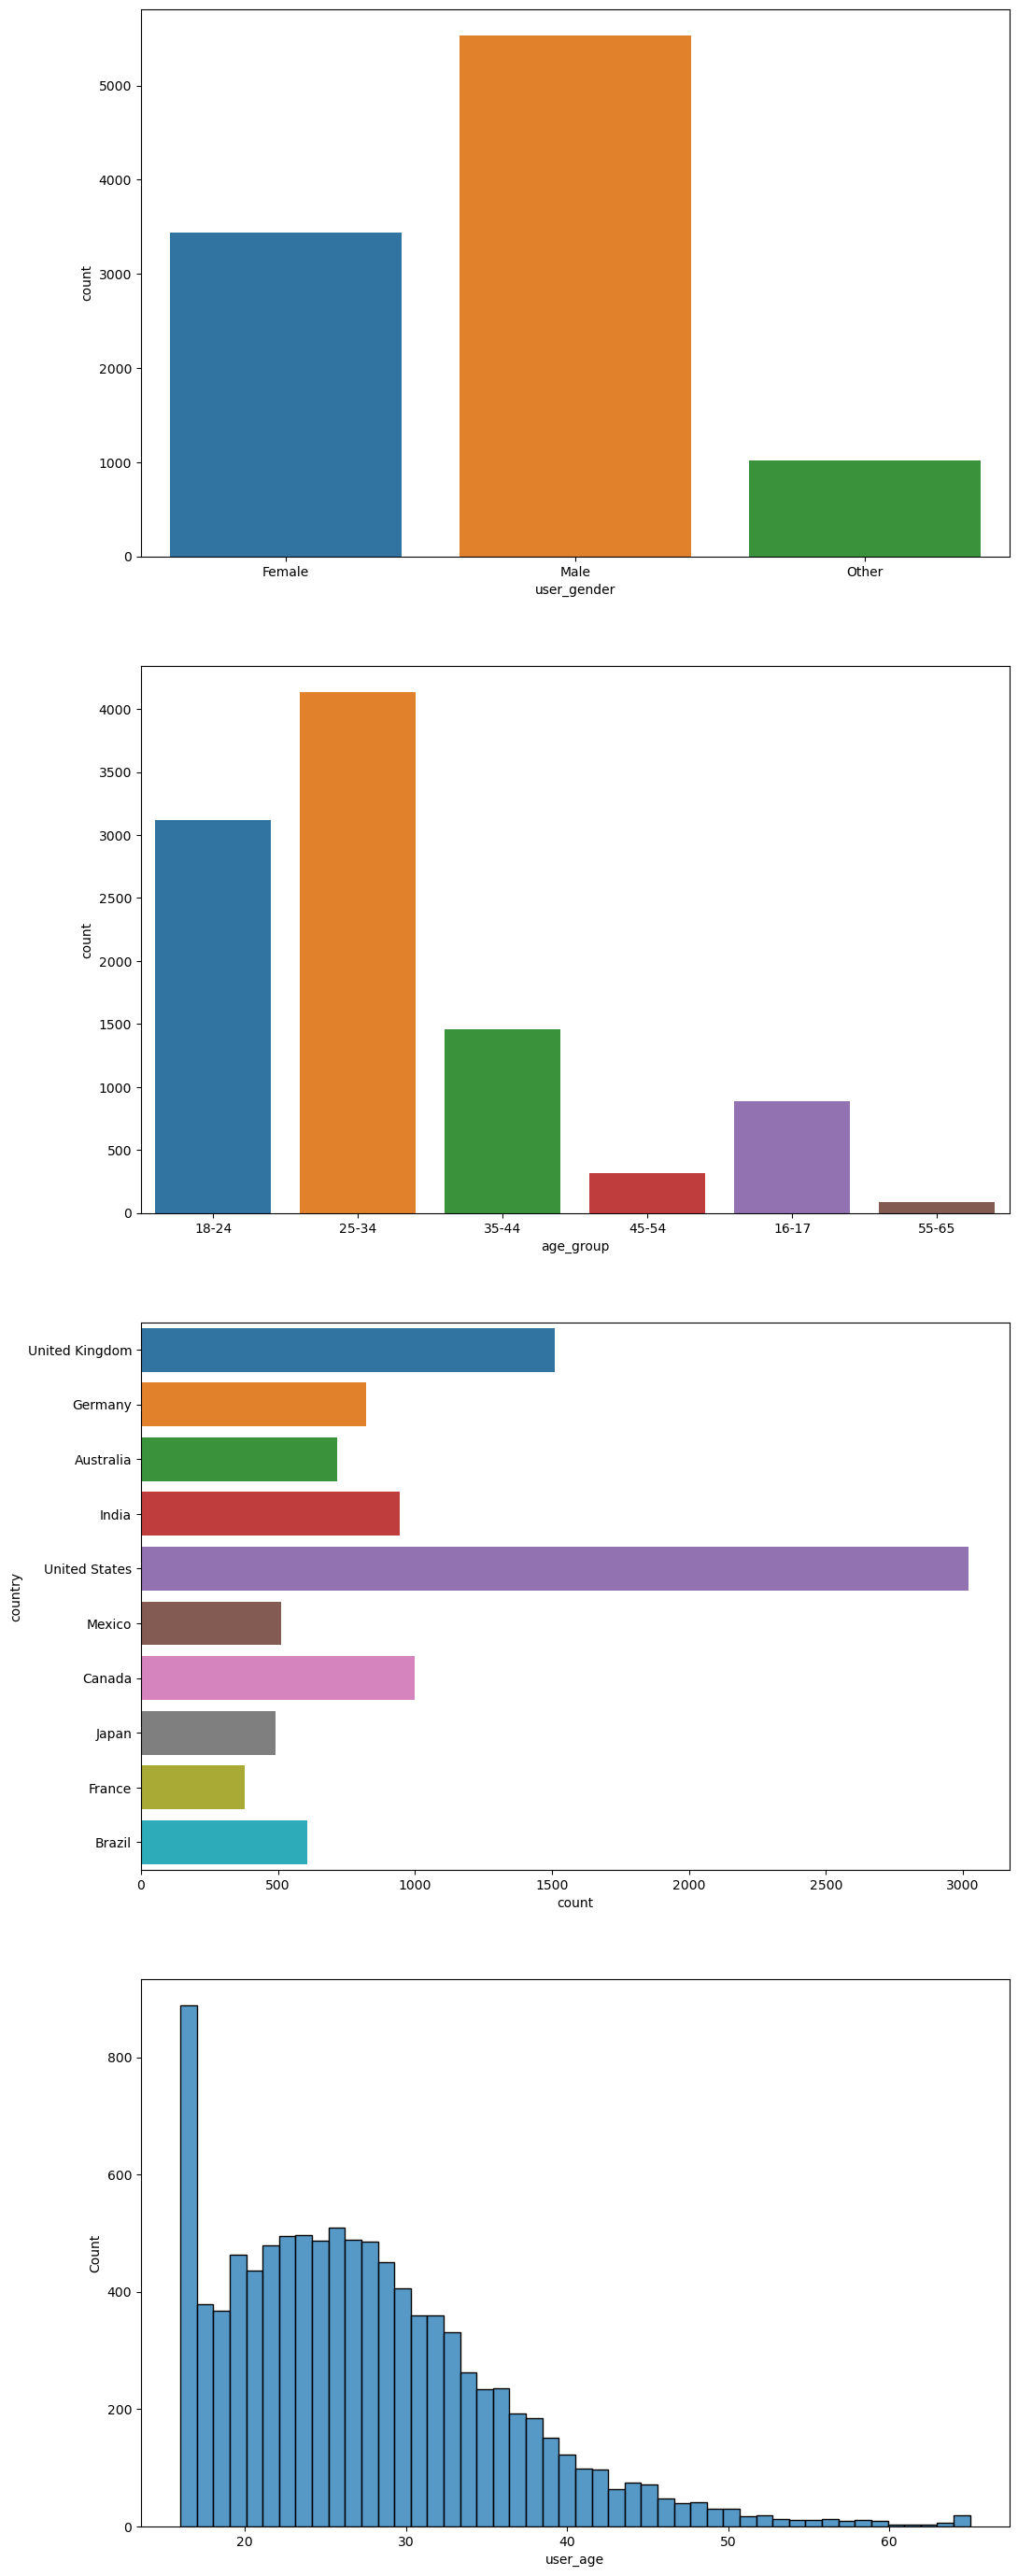

In [19]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(12,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];
sns.countplot(data=df_users,x="user_gender",hue="user_gender",ax=ax1)
sns.countplot(data=df_users,x="age_group",hue="age_group",ax=ax2)
sns.countplot(data=df_users,y="country",hue="country",ax=ax3)
sns.histplot(data=df_users,x="user_age",ax=ax4);

In [20]:
filtro=df_users["location"].value_counts().head(20).index
df_users_location=df_users[df_users["location"].isin(filtro)]
df_users_location

,user_id,user_gender,user_age,age_group,country,location,interests
80,f78e5,Male,18,18-24,United States,Lake David,"finance, sports, travel"
136,dd4f7,Male,20,18-24,United Kingdom,West Jennifer,"technology, fitness"
155,eac99,Other,16,16-17,India,North Christopher,"food, sports"
189,5c67c,Male,33,25-34,Australia,Port John,"food, news, photography"
234,7e896,Male,27,25-34,Brazil,North Michael,"technology, lifestyle, art"
...,...,...,...,...,...,...,...
9624,692b3,Female,33,25-34,United States,Michaelhaven,"lifestyle, sports, gaming"
9645,d7835,Male,23,18-24,Brazil,East Robert,food
9676,b7c75,Male,22,18-24,Mexico,North Michael,"food, photography, technology"
9714,9d79d,Male,16,16-17,India,New Jennifer,fashion


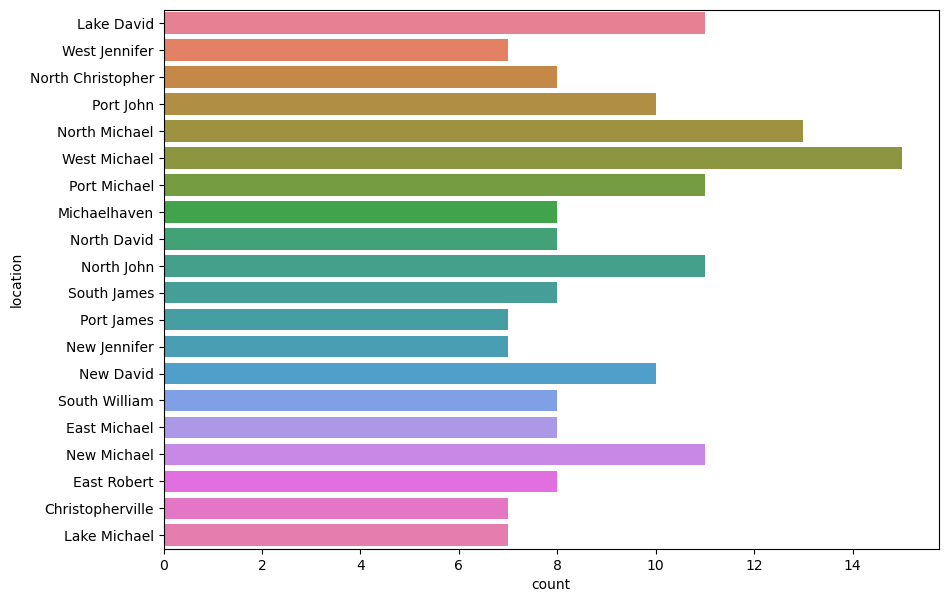

In [21]:
plt.figure(figsize=(10,7))
sns.countplot(data=df_users_location,y="location",hue="location");

## MULTIVARIABLE ANALYSIS

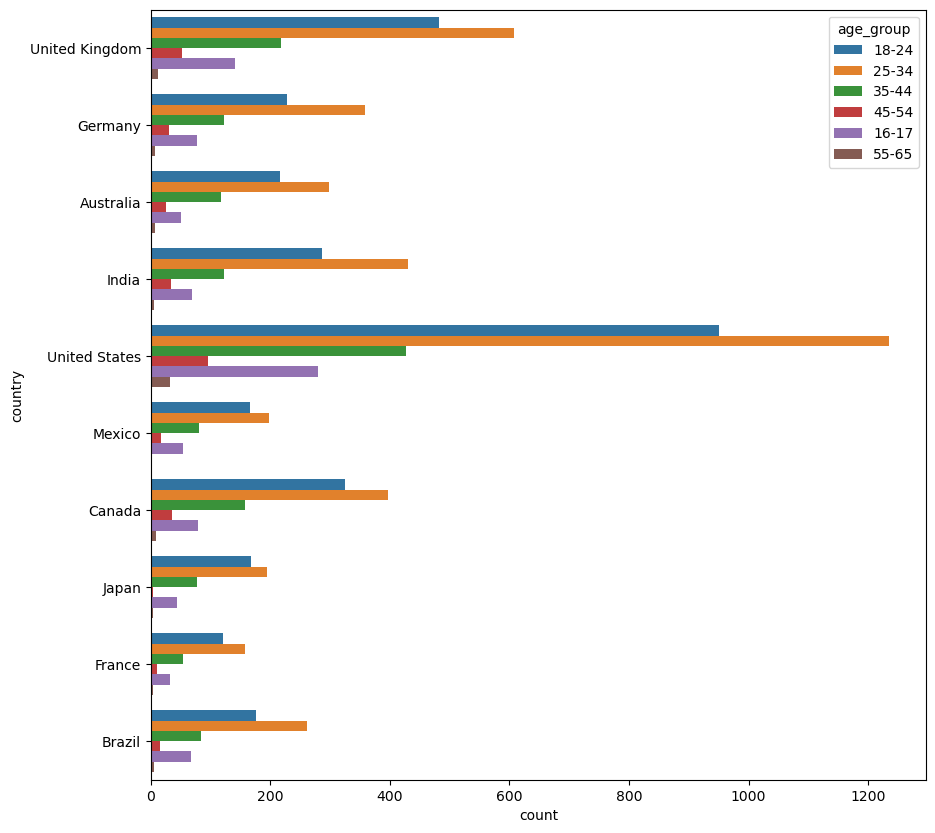

In [22]:
plt.figure(figsize=(10,10))
sns.countplot(data=df_users,y="country",hue="age_group");

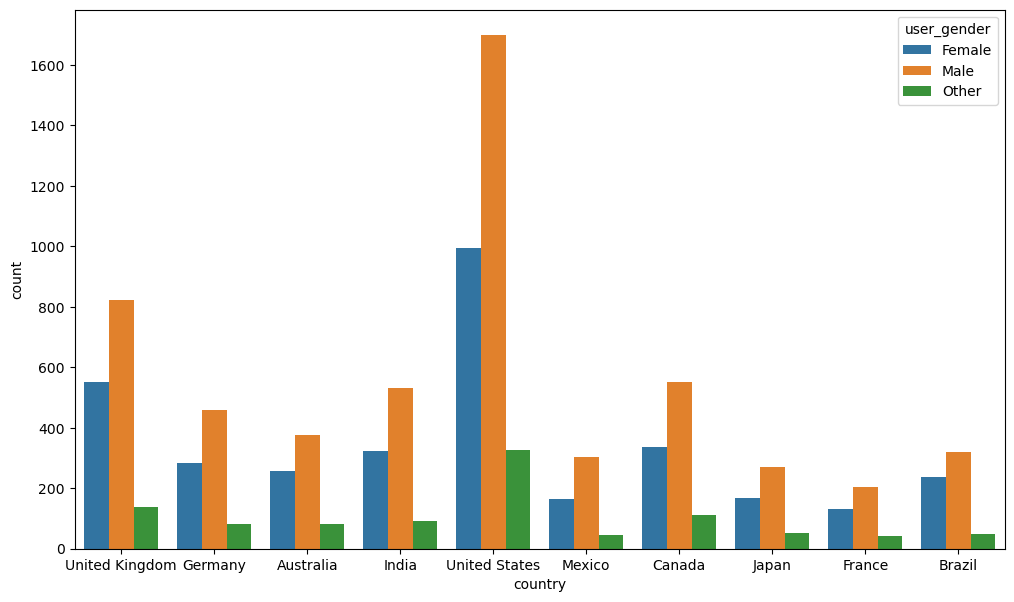

In [23]:
plt.figure(figsize=(12,7))
sns.countplot(data=df_users,x="country",hue="user_gender");

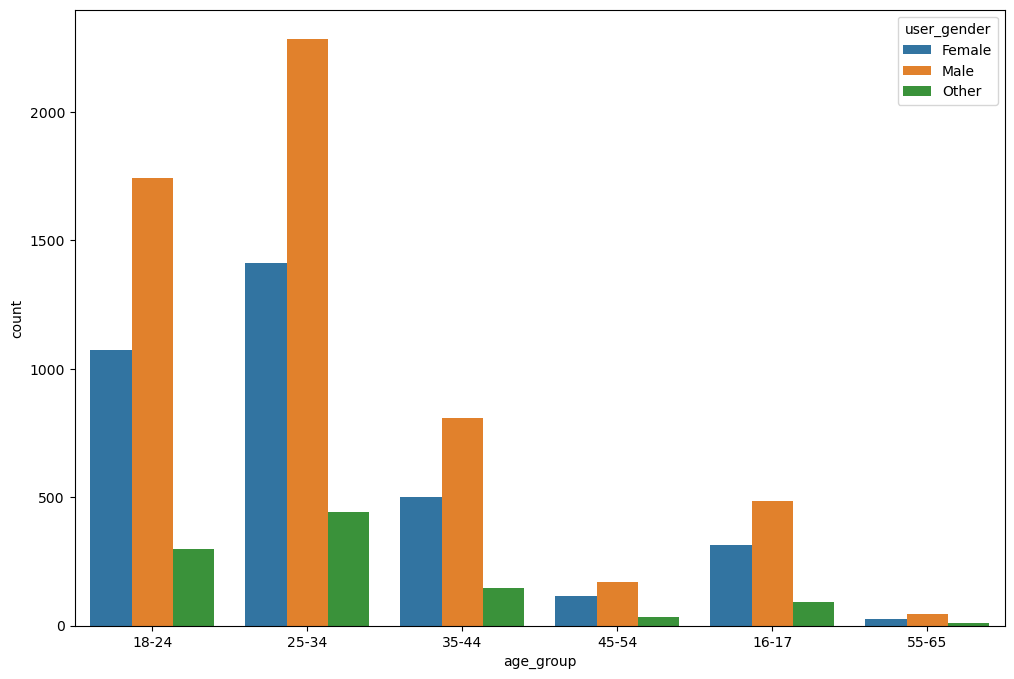

In [24]:
plt.figure(figsize=(12,8))
sns.countplot(data=df_users,x="age_group",hue="user_gender");

In [25]:
df_users.groupby(by="country")["user_age"].median()

country
Australia         27.0
Brazil            27.0
Canada            27.0
France            26.0
Germany           27.0
India             26.0
Japan             26.0
Mexico            27.0
United Kingdom    26.0
United States     26.0
Name: user_age, dtype: float64

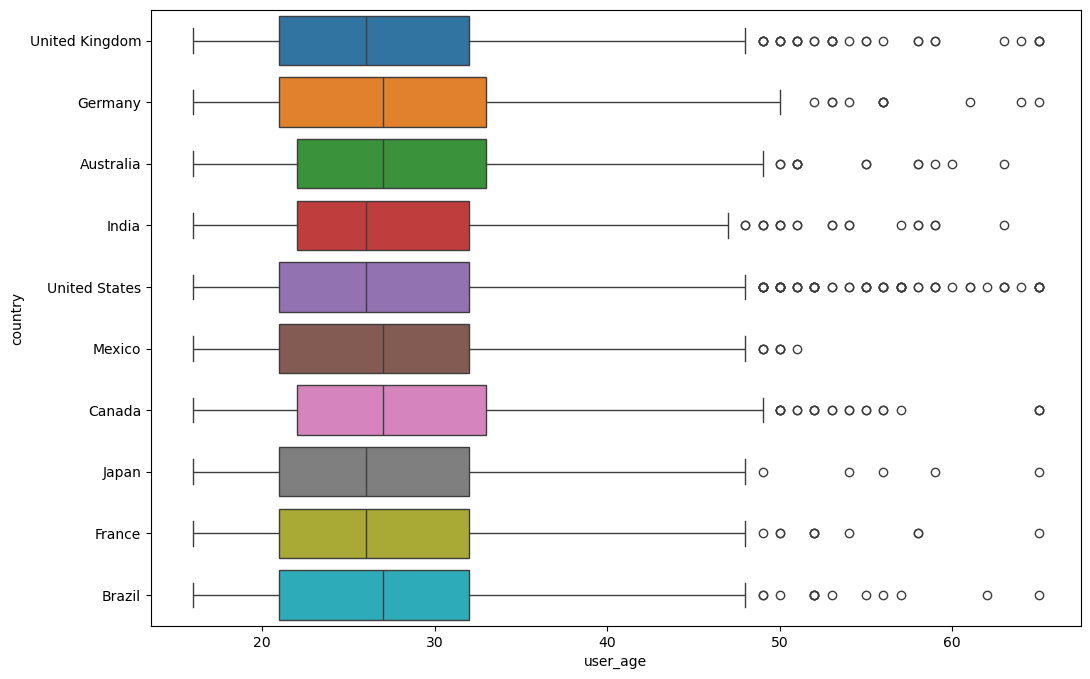

In [26]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_users,x="user_age",y="country",hue="country");

In [27]:
df_users_18=df_users[(df_users["user_age"]<=24) & (df_users["user_age"]>=18)]
df_users_16=df_users[(df_users["user_age"]<=17)]
df_users_25=df_users[(df_users["user_age"]<=34) & (df_users["user_age"]>=25)]
df_users_35=df_users[(df_users["user_age"]<=44) & (df_users["user_age"]>=35)]
df_users_45=df_users[(df_users["user_age"]<=54) & (df_users["user_age"]>=45)]
df_users_55=df_users[(df_users["user_age"]<=65) & (df_users["user_age"]>=55)]

In [28]:
media = np.mean(df_users_55["user_age"])
print(f"La media es: {media}") # Salida: La media es: 55.0
q1 = np.percentile(df_users_55["user_age"], 25) # Primer cuartil (percentil 25)
mediana = np.percentile(df_users_55["user_age"], 50) # Segundo cuartil (mediana, percentil 50)
q3 = np.percentile(df_users_55["user_age"], 75) # Tercer cuartil (percentil 75)
print(f"Primer Cuartil (Q1): {q1}") # Salida: Primer Cuartil (Q1): 32.5
print(f"Mediana (Q2): {mediana}") # Salida: Mediana (Q2): 55.0
print(f"Tercer Cuartil (Q3): {q3}") # Salida: Tercer Cuartil (Q3): 77.5

La media es: 59.3855421686747
Primer Cuartil (Q1): 56.0
Mediana (Q2): 58.0
Tercer Cuartil (Q3): 63.0


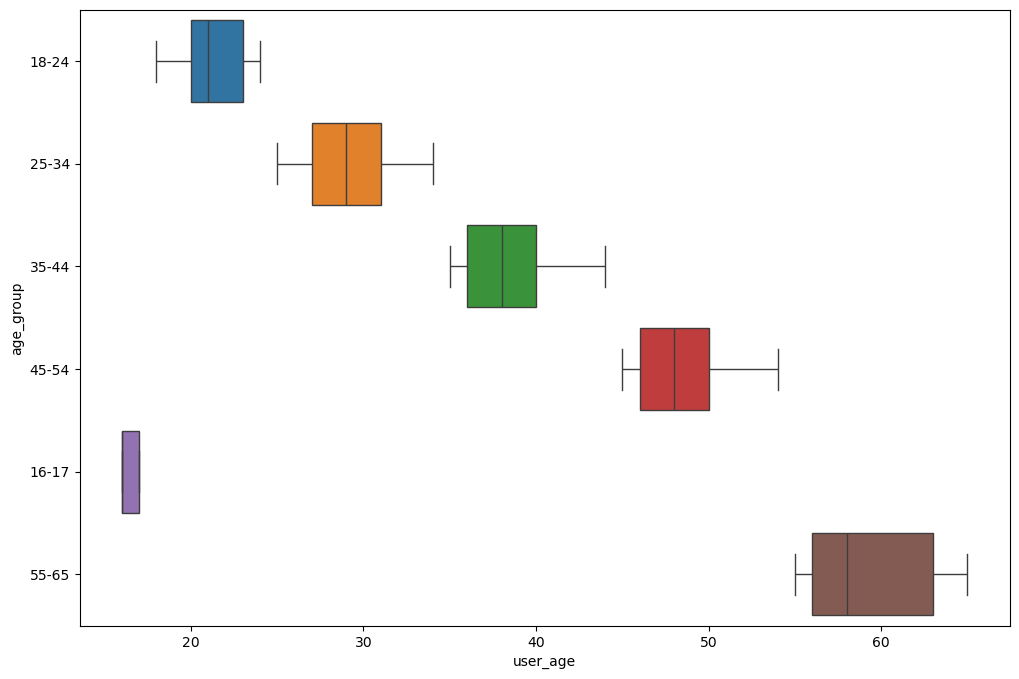

In [29]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_users,x="user_age",y="age_group",hue="age_group");

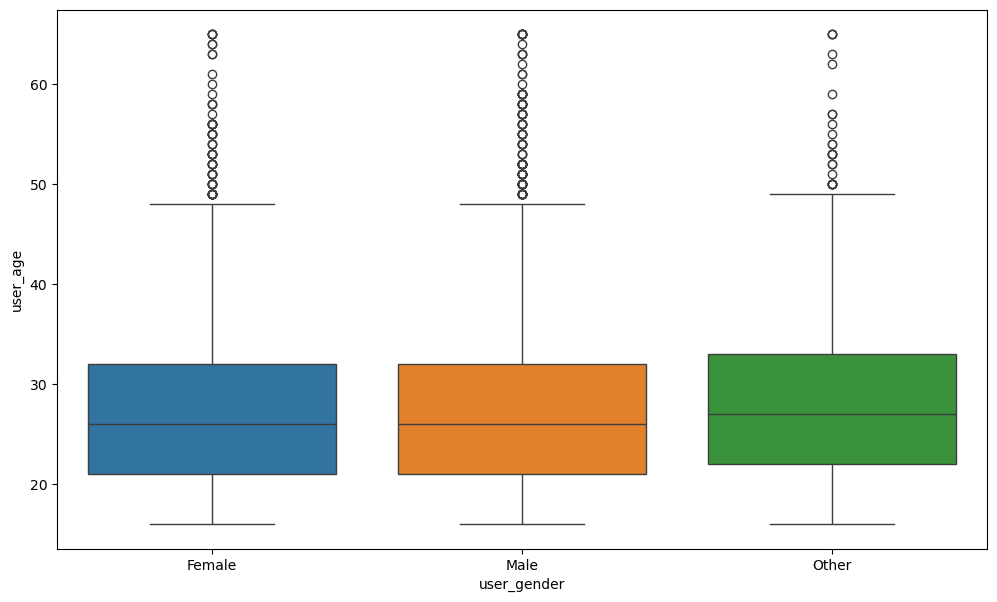

In [30]:
plt.figure(figsize=(12,7))
sns.boxplot(data=df_users,y="user_age",x="user_gender",hue="user_gender");

In [31]:
df_users_male=df_users[df_users["user_gender"]=="Male"]
df_users_female=df_users[df_users["user_gender"]=="Female"]
df_users_others=df_users[df_users["user_gender"]=="Other"]
print("MALE MEAN:",np.mean(df_users_male["user_age"]))
print("MALE MEDIAN:",np.median(df_users_male["user_age"]))
print("MALE Q1",np.percentile(df_users_male["user_age"],25))
print("MALE Q2",np.percentile(df_users_male["user_age"],50))
print("MALE Q3",np.percentile(df_users_male["user_age"],75))

print("FEMALE MEAN:",np.mean(df_users_female["user_age"]))
print("FEMALE MEDIAN:",np.median(df_users_female["user_age"]))
print("FEMALE Q1",np.percentile(df_users_female["user_age"],25))
print("FEMALE Q2",np.percentile(df_users_female["user_age"],50))
print("FEMALE Q3",np.percentile(df_users_female["user_age"],75))

print("OTHERS MEAN:",np.mean(df_users_others["user_age"]))
print("OTHERS MEDIAN:",np.median(df_users_others["user_age"]))
print("OTHERS Q1",np.percentile(df_users_others["user_age"],25))
print("OTHERS Q2",np.percentile(df_users_others["user_age"],50))
print("OTHERS Q3",np.percentile(df_users_others["user_age"],75))

MALE MEAN: 27.61795520231214
MALE MEDIAN: 26.0
MALE Q1 21.0
MALE Q2 26.0
MALE Q3 32.0
FEMALE MEAN: 27.59541097879756
FEMALE MEDIAN: 26.0
FEMALE Q1 21.0
FEMALE Q2 26.0
FEMALE Q3 32.0
OTHERS MEAN: 27.97747306562194
OTHERS MEDIAN: 27.0
OTHERS Q1 22.0
OTHERS Q2 27.0
OTHERS Q3 33.0


In [33]:
df_nuevo = df_users.copy()
df_nuevo["interests_list"] = df_nuevo["interests"].str.split(",")
intereses_unicos = set([i.strip() for lista in df_nuevo["interests_list"] for i in lista])
lista_intereses=list(intereses_unicos)
print(lista_intereses)
print("Cantidad de intereses únicos:", len(intereses_unicos))

['news', 'gaming', 'food', 'sports', 'lifestyle', 'art', 'travel', 'fashion', 'finance', 'health', 'technology', 'photography', 'fitness']
Cantidad de intereses únicos: 13


In [34]:
df_users["interests"].str.contains("news")

0       False
1       False
2        True
3        True
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: interests, Length: 10000, dtype: bool

In [35]:
df_users_news=df_users[df_users["interests"].str.contains("news")]
df_users_photo=df_users[df_users["interests"].str.contains("photograpy")]
df_users_finance=df_users[df_users["interests"].str.contains("finance")]
df_users_fashion=df_users[df_users["interests"].str.contains("fashion")]
df_users_life=df_users[df_users["interests"].str.contains("lifestyle")]
df_users_sports=df_users[df_users["interests"].str.contains("sports")]
df_users_tech=df_users[df_users["interests"].str.contains("technology")]
df_users_gaming=df_users[df_users["interests"].str.contains("gaming")]
df_users_art=df_users[df_users["interests"].str.contains("art")]
df_users_health=df_users[df_users["interests"].str.contains("health")]
df_users_fit=df_users[df_users["interests"].str.contains("fitness")]
df_users_food=df_users[df_users["interests"].str.contains("food")]
df_users_travel=df_users[df_users["interests"].str.contains("travel")]

In [36]:
news=df_users[df_users["interests"].str.contains("news")]
photo=df_users[df_users["interests"].str.contains("photograpy")]
finance=df_users[df_users["interests"].str.contains("finance")]
fashion=df_users[df_users["interests"].str.contains("fashion")]
life=df_users[df_users["interests"].str.contains("lifestyle")]
sports=df_users[df_users["interests"].str.contains("sports")]
tech=df_users[df_users["interests"].str.contains("technology")]
gaming=df_users[df_users["interests"].str.contains("gaming")]
art=df_users[df_users["interests"].str.contains("art")]
health=df_users[df_users["interests"].str.contains("health")]
fit=df_users[df_users["interests"].str.contains("fitness")]
food=df_users[df_users["interests"].str.contains("food")]
travel=df_users[df_users["interests"].str.contains("travel")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  1552
News:  1509
Tech:  1566
Fitness:  1579
Art:  1546
Food:  1511
Fashion:  1536
Health:  1529
Photo:  0
Sports:  1523
Finance:  1487
Travel:  1543
Life:  1561


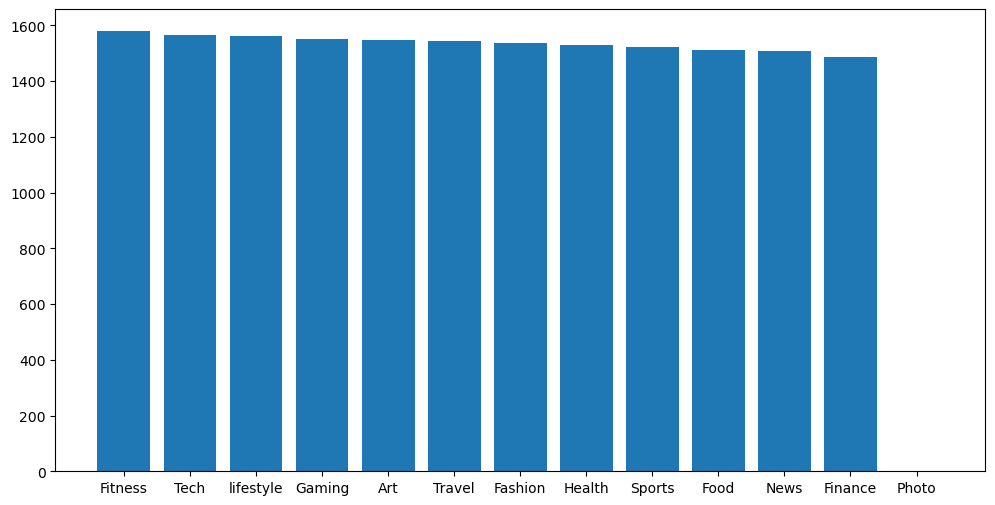

In [37]:
df_users_interest=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"lifestyle":len(life),"Travel":len(travel)})
df_users_interest=df_users_interest.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_users_interest.index,height=df_users_interest.values);

### USERS TABLE SUMMARY
#### EXPLORATORY ANALYSIS DATA

**user_id:** *There are a total of 9950 users in the data frame, of which 50 users are repeated.*

**user_gender:** *There are records of female, male, and unspecified (other) users. 5536 users are male, 3443 are female, and 1021 are other.*

**user_age:** *There are 50 users with different ages ranging from 16 to 65 years old. The most frequently registered ages are 16 (622), 26 (509), 24 (496), and 23 (495). 30 age groups have more than 50 registered users, reaching 622, as is the case with 16 years old.*

**age_group:** *Ages are divided into 6 ranges, with the most registered users being 25-34 (4137) and 18-24 years old (3116).*

**country:** *There is one A total of 10 countries are represented by users, with the United States having the most registrations at 3,019, followed by the United Kingdom with 1,510 and Canada with 1,000.

**Location:** There are 7,706 different locations from which users originate, of which 49 appear more than 5 times, with West Michael having a maximum of 15 registrations.

**Interests:** There are 13 different user interests reflected in the registrations. Overall, the greatest interest for users was 'fitness', followed by 'tech' and 'gaming'.*

#### Multivariate Data Analysis
**Country vs. User Group:** *In all countries, different age groups interacted. This means they belong to different generations, such as Generation Z (1997-2012), Millennials (1982-1996), Baby Boomers (1946-1964), and Generation X (1965-1981). The countries showed the highest number of participants in the 25-34 age group (Millennials and Generation Z), followed by 18-24 (Generation Z) and 35-44 (Millennials and Generation X). In Japan, Canada, and Basil, there are very few records for the 45-65 age range, with Japan having the lowest count in this age range (Baby Boomer and X Generation). This could indicate low cell phone usage in those countries by these groups of people.*\
**Country vs. Age and Gender:** *ALL COUNTRIES SHOW A HIGHER NUMBER OF RECORDS FOR MALES, FOLLOWED BY FEMALES. IN BRAZIL, THE GAP BETWEEN THESE TWO SEXES IS NOT AS LARGE.*\
**User gender vs. age group:** *In all age ranges, the male gender predominates, followed by the female.*\
**User age vs. country:** *In general, ages remain very similar across different countries, but there is a slight difference between Germany, Canada, and Australia compared to the rest, as they have higher average ages. This is noticeable in the outliers, the mean, and the third quartile.*\
**User age vs. age group:** *The most frequent ages by age range are:*
*18-24:*
- The mean is: 21.199293966623877
- First Quartile (Q1): 20.0
- Median (Q2): 21.0
- Third Quartile (Q3): 23.0

*25-34:*
- The mean is: 28.976311336717426
- First Quartile (Q1): 27.0
- Median (Q2): 29.0
- Third Quartile (Q3): 31.0

*35-44:*
- The mean is: 38.333104395604394
- First Quartile (Q1): 36.0
- Median (Q2): 38.0
- Third Quartile (Q3): 40.0

*45-54:*
- The mean is: 47.974921630094045
- First Quartile (Q1): 46.0
- Median (Q2): 48.0
- Third Quartile (Q3): 50.0

*55-65:*
- The mean is: 59.3855421686747]
- First Quartile (Q1): 56.0
- Median (Q2): 58.0
- Third Quartile (Q3): 63.0

**User age vs. user gender:** *Male and female users had practically the same mean (27) and median (26), while others had a slightly higher mean (28) and median (27). This indicates that the age with the highest participation in both sexes was 26 years, which belongs to the 25-34 range, the most representative range.*

# ADS DATASET

In [38]:
df_ads

,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology
3,4,28,Facebook,Stories,Female,25-34,news
4,5,24,Instagram,Image,Female,25-34,news
...,...,...,...,...,...,...,...
195,196,12,Facebook,Stories,Male,35-44,"gaming, sports"
196,197,9,Facebook,Stories,All,All,"lifestyle, gaming"
197,198,34,Facebook,Video,All,35-44,"fitness, lifestyle"
198,199,15,Instagram,Video,Male,25-34,"art, news"


In [40]:
df_ads_dict=df_ads.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_ads_dict})
display(Markdown(response.content))

This dataset describes individual advertisements and their targeting parameters. Each entry represents a unique ad and provides information about its associated campaign, the platform it runs on, its format, and its demographic and interest-based targeting.

**Dataset Explanation:**

*   **`ad_id`**: A unique identifier for each specific advertisement. (Numerical, unique)
*   **`campaign_id`**: An identifier linking ads to their respective campaigns. Multiple ads can belong to the same campaign. (Numerical, categorical)
*   **`ad_platform`**: The social media platform where the ad is displayed (e.g., 'Facebook', 'Instagram'). (Categorical)
*   **`ad_type`**: The creative format of the advertisement (e.g., 'Video', 'Stories', 'Image', 'Carousel'). (Categorical)
*   **`target_gender`**: The gender demographic targeted by the ad ('Female', 'Male', 'All'). (Categorical)
*   **`target_age_group`**: The age range targeted by the ad (e.g., '18-24', '25-34', '35-44', 'All'). (Categorical, ordinal)
*   **`target_interests`**: A comma-separated string listing the interests targeted by the ad (e.g., 'art, technology'). (Categorical, multi-value)

**How to Analyze It (Useful Graphs and Operations):**

The primary goal of analyzing this dataset is to understand the distribution and relationships between different ad attributes and targeting strategies.

1.  **Univariate Analysis (Single Variable Distributions):**
    *   **Operation:** Count the occurrences of each unique value for categorical columns.
    *   **Graphs:**
        *   **Bar Charts:** For `ad_platform`, `ad_type`, `target_gender`, `target_age_group`. These will show the most common platforms, ad formats, and demographic targets.
        *   **Bar Chart (for `campaign_id`):** To see which campaigns have the most ads, indicating larger or more diverse campaigns.
        *   **Bar Chart (for `target_interests`):** You'll need to first split the comma-separated string into individual interests, then count each unique interest. This reveals the most frequently targeted interests. A word cloud could also be visually appealing.

2.  **Bivariate Analysis (Relationships Between Two Variables):**
    *   **Operation:** Cross-tabulations (contingency tables) to count occurrences of combinations.
    *   **Graphs:**
        *   **Stacked Bar Charts or Grouped Bar Charts:**
            *   `ad_platform` vs. `ad_type`: Do certain platforms favor specific ad formats? (e.g., more 'Stories' on Instagram, more 'Video' on Facebook).
            *   `ad_platform` vs. `target_gender`/`target_age_group`: Are different demographics targeted on different platforms?
            *   `ad_type` vs. `target_gender`/`target_age_group`: Are specific ad types used for particular demographics?
        *   **Heatmaps:** For visualizing the frequency or proportion of combinations, especially useful for `ad_platform` vs. `target_age_group` or `target_gender`.

3.  **Multi-Value Interest Analysis:**
    *   **Operation:** After splitting `target_interests` into individual items, you can perform further analysis:
        *   Count co-occurrences of interests to find common interest pairings (e.g., "health" and "fitness" often targeted together).
        *   Analyze interest distribution segmented by `ad_platform` or `ad_type`.

**Professional Perspective & Recommendations:**

This dataset provides a foundational understanding of ad campaign structure and targeting. However, its true value would be unlocked by integrating it with **performance metrics** (e.g., impressions, clicks, conversions, cost, ROI).

**Without performance data, your analysis will answer questions like:**
*   "What is our current mix of ad formats across platforms?"
*   "Which age groups are we primarily targeting?"
*   "What are the most common interests we're trying to reach?"

**With performance data, you could answer more strategic questions such as:**
*   "Which ad platforms/types/targeting combinations are most effective (highest ROI, lowest CPA)?"
*   "Are we overspending on certain ad configurations that underperform?"
*   "What are the characteristics of our most successful campaigns (`campaign_id`)?"

For this dataset alone, focus on descriptive statistics to identify trends in ad creation and targeting strategies. This can inform decisions about diversifying ad formats, exploring new targeting demographics, or identifying areas where current efforts are concentrated.

## EXPLORATORY DATA ANALYSIS (EDA)

In [41]:
df_ads.isna().sum()

ad_id               0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
dtype: int64

In [42]:
df_ads.describe()

,ad_id,campaign_id
count,200.000000,200.000000
mean,100.500000,25.125000
std,57.879185,13.713485
min,1.000000,1.000000
25%,50.750000,13.000000
50%,100.500000,25.000000
75%,150.250000,37.000000
max,200.000000,50.000000


In [43]:
print(df_ads["campaign_id"].value_counts().head(10))
print("")
print(df_ads["ad_platform"].value_counts())
print("")
print(df_ads["ad_type"].value_counts())
print("")
print(df_ads["target_gender"].value_counts())
print("")
print(df_ads["target_age_group"].value_counts())

campaign_id
20    8
24    8
17    8
42    8
38    8
29    7
33    7
4     6
9     6
13    6
Name: count, dtype: int64

ad_platform
Facebook     127
Instagram     73
Name: count, dtype: int64

ad_type
Stories     64
Image       52
Carousel    51
Video       33
Name: count, dtype: int64

target_gender
Female    83
All       71
Male      46
Name: count, dtype: int64

target_age_group
35-44    54
18-24    54
25-34    46
All      46
Name: count, dtype: int64


In [44]:
df_nuevo = df_ads.copy()
df_nuevo["interests_list"] = df_nuevo["target_interests"].str.split(",")
intereses_unicos = set([i.strip() for lista in df_nuevo["interests_list"] for i in lista])
lista_intereses=list(intereses_unicos)
print(lista_intereses)
print("Cantidad de intereses únicos:", len(intereses_unicos))

['news', 'gaming', 'food', 'sports', 'art', 'lifestyle', 'travel', 'fashion', 'finance', 'health', 'technology', 'photography', 'fitness']
Cantidad de intereses únicos: 13


In [45]:
gaming=df_ads[df_ads["target_interests"].str.contains("gaming")]
news=df_ads[df_ads["target_interests"].str.contains("news")]
tech=df_ads[df_ads["target_interests"].str.contains("technology")]
fit=df_ads[df_ads["target_interests"].str.contains("fitness")]
art=df_ads[df_ads["target_interests"].str.contains("art")]
food=df_ads[df_ads["target_interests"].str.contains("food")]
fashion=df_ads[df_ads["target_interests"].str.contains("fashion")]
health=df_ads[df_ads["target_interests"].str.contains("health")]
photo=df_ads[df_ads["target_interests"].str.contains("photography")]
sports=df_ads[df_ads["target_interests"].str.contains("sports")]
finance=df_ads[df_ads["target_interests"].str.contains("finance")]
travel=df_ads[df_ads["target_interests"].str.contains("travel")]
life=df_ads[df_ads["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  27
News:  23
Tech:  21
Fitness:  20
Art:  21
Food:  12
Fashion:  26
Health:  29
Photo:  22
Sports:  24
Finance:  28
Travel:  27
Life:  20


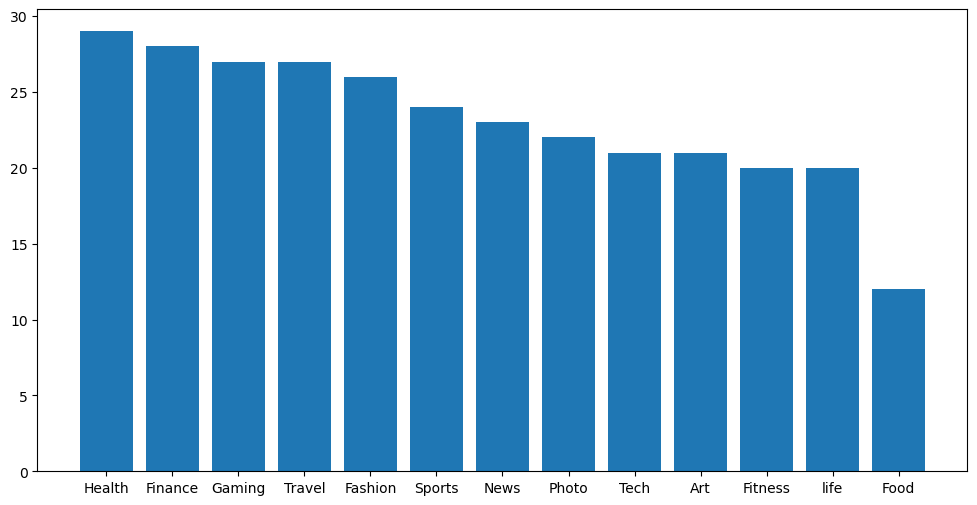

In [46]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"life":len(life),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

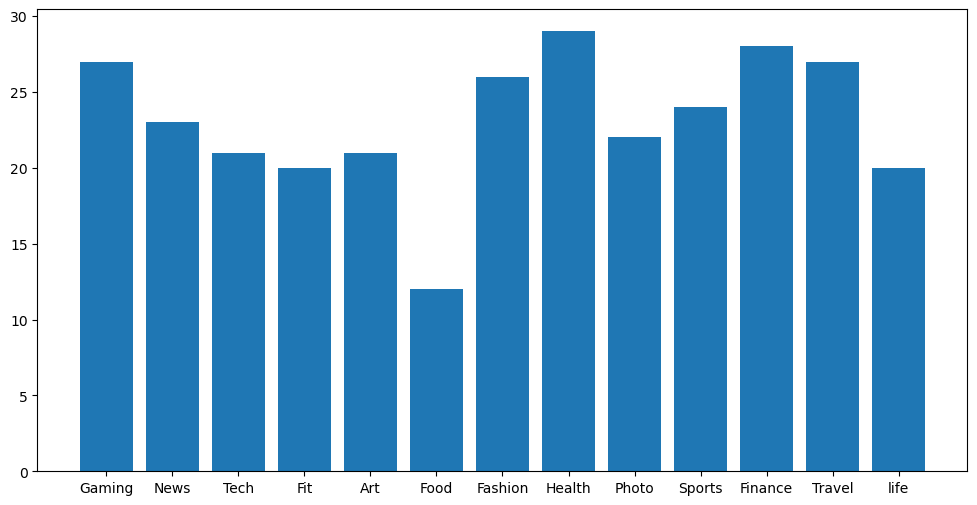

In [47]:
df_total2 = pd.DataFrame({
    "Category":['Gaming', 'News', 'Tech', 'Fit', 'Art', 'Food', 'Fashion', 'Health', 'Photo', 'Sports','Finance', 'Travel', 'life'],
    "Total":[len(gaming),len(news),len(tech),len(fit),len(art),len(food),len(fashion),len(health),len(photo),len(sports),len(finance),len(travel),len(life)]
})
plt.figure(figsize=(12,6))
plt.bar(x=df_total2["Category"],height=df_total2["Total"]);

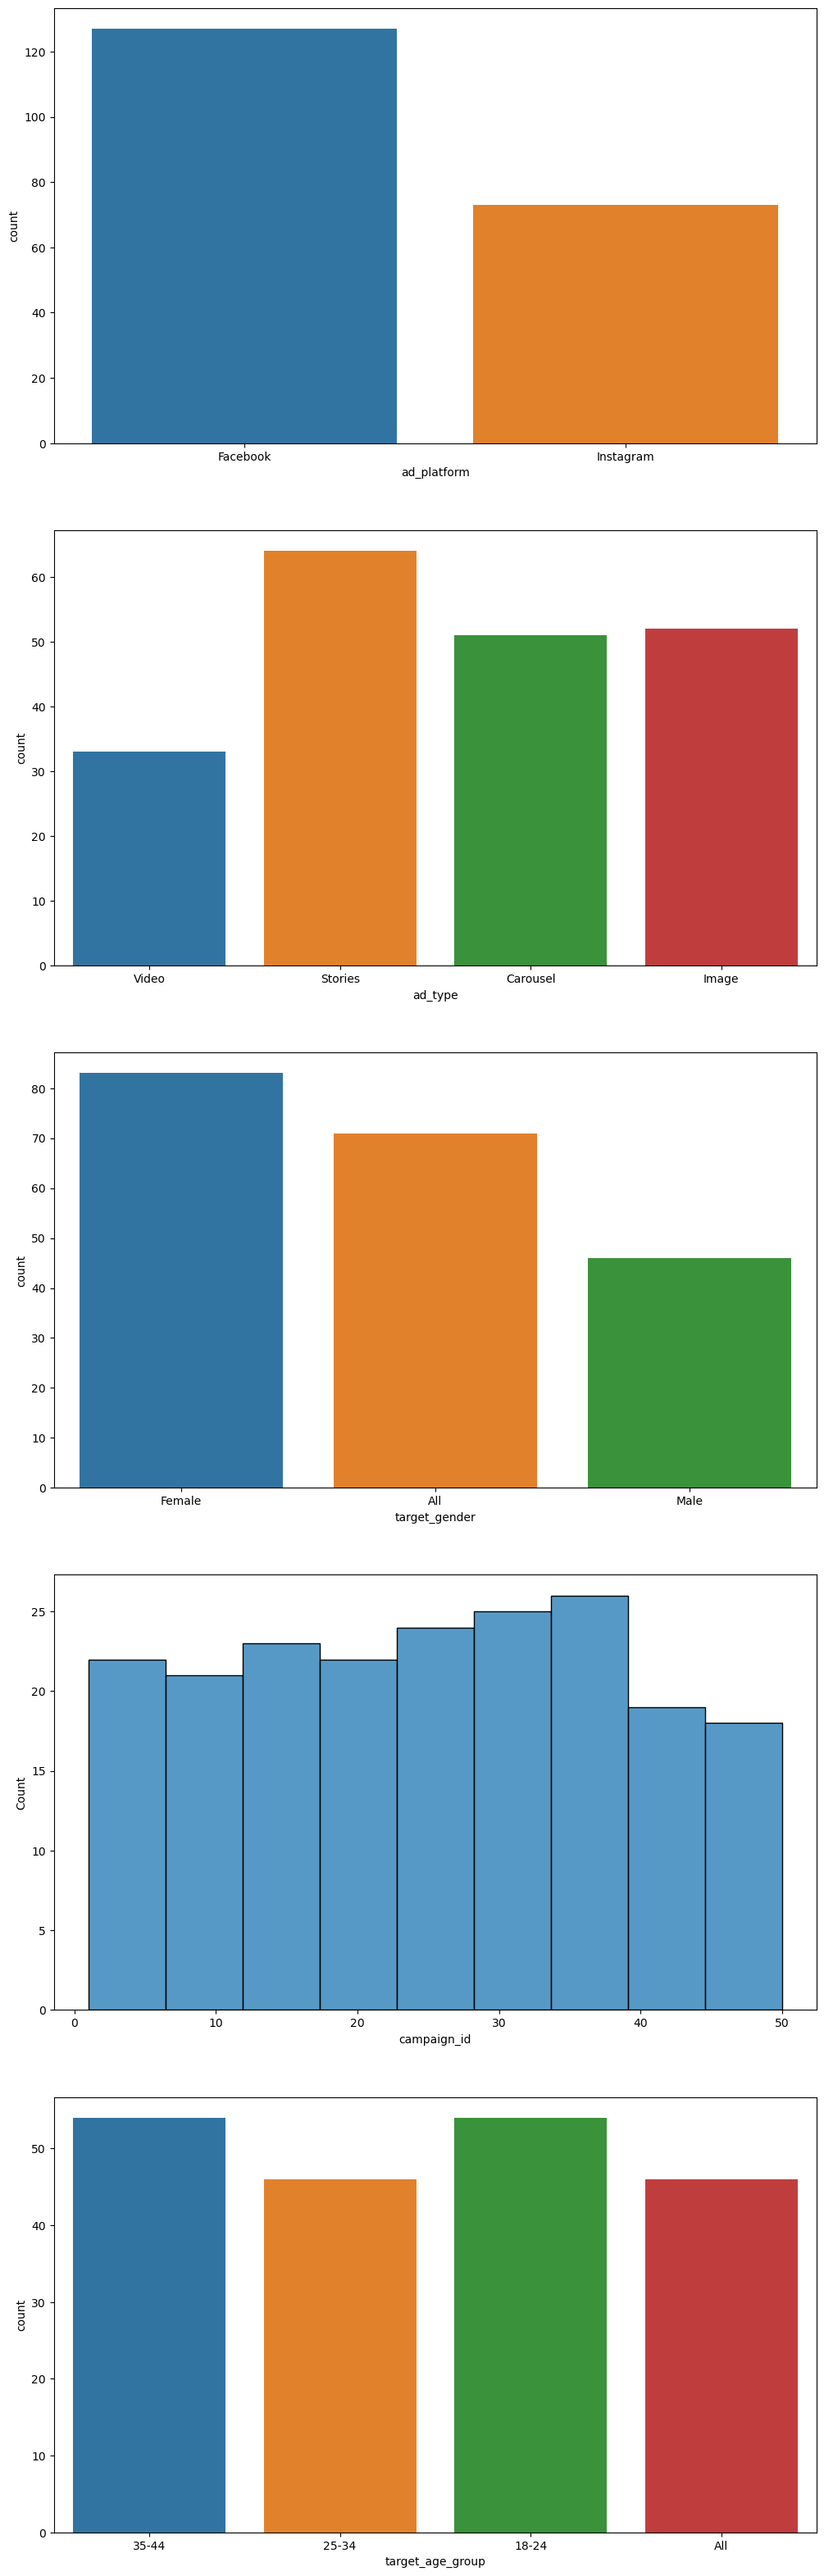

In [48]:
fig,ax=plt.subplots(nrows=5,ncols=1,figsize=(12,40))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4];
sns.countplot(data=df_ads,x="ad_platform",hue="ad_platform",ax=ax1)

sns.countplot(data=df_ads,x="ad_type",hue="ad_type",ax=ax2)

sns.countplot(data=df_ads,x="target_gender",hue="target_gender",ax=ax3)

sns.histplot(data=df_ads,x="campaign_id",ax=ax4)

sns.countplot(data=df_ads,x="target_age_group",hue="target_age_group",ax=ax5);

## MULTIVARIABLE ANALYSIS

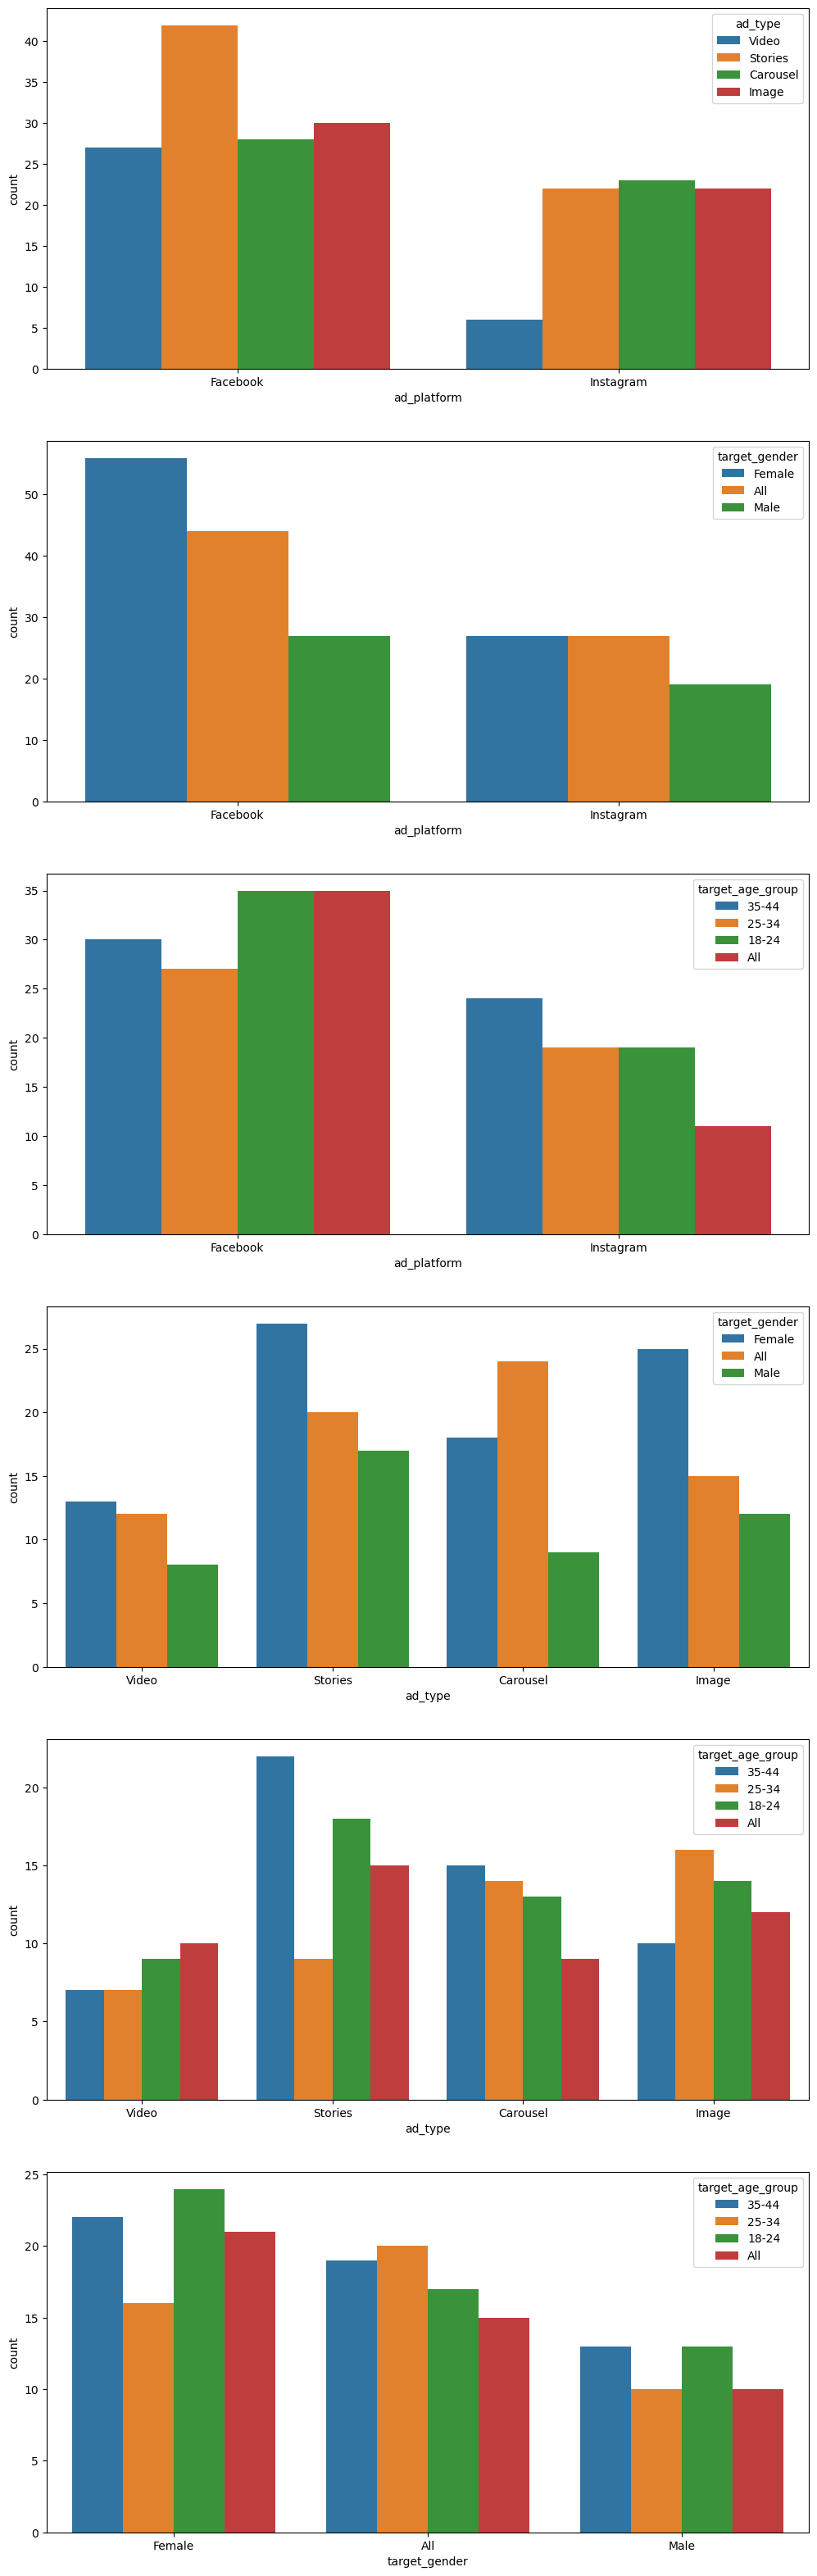

In [50]:
fig,ax=plt.subplots(nrows=6,ncols=1,figsize=(12,40))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4];ax6=ax[5];

sns.countplot(data=df_ads,x="ad_platform",hue="ad_type",ax=ax1)
sns.countplot(data=df_ads,x="ad_platform",hue="target_gender",ax=ax2)
sns.countplot(data=df_ads,x="ad_platform",hue="target_age_group",ax=ax3)
sns.countplot(data=df_ads,x="ad_type",hue="target_gender",ax=ax4)
sns.countplot(data=df_ads,x="ad_type",hue="target_age_group",ax=ax5)
sns.countplot(data=df_ads,x="target_gender",hue="target_age_group",ax=ax6);

## ADS TABLE SUMMARY
**THERE IS ONE RECORD OF 200**\
**campaign_id:** *This corresponds to the ID of the CAMPAIGN TABLE, indicating the type of advertising campaign that was carried out. There are more records from campaigns 24, 24, 17, 42, and 38, with 8 records each.*\
**ad_platform:** *The platforms on which the ads were developed were only Instagram and Facebook. More ads were developed on the Facebook platform with 127, and on Instagram with 73.*\
**ad types:** *The ads were published in various formats, including Stories, images, carousels, and video. Stories was the most used format, with 64 ads, followed by images with 52, carousels with 51, and video with 33.*\
**Target_gender:** *The development of the advertisements focused more on a female audience with 83 ads, followed by a more general (indistinct) development with 71 ads, and finally ads directed at men with 46 ads. This could be due to the fact that women have the least interaction with advertisements, and to have an impact on them, ads dedicated to that sex were developed.*\
**target_age_group:** *The age ranges targeted were both older and younger audiences. 54 ads were developed for the 35-44 age group, 54 ads for the 18-24 age group, 46 ads for the 25-34 age group, and 46 ads for the general public (all). There was a slight increase in advertising targeting an older audience because they are the least active users of social media and therefore consume the least amount of advertising, making them a difficult audience to reach.*\
**target_interests:** *There are 13 areas of interest used to develop the ads. Health-related ads were the most developed, followed by finance, gaming, travel, fashion, sports, news, photography, education, art, fitness, life, and finally food.*

### Multivariate Data Analysis
**ad_platform vs ad_type:** *The development of different formats on each platform varies. On Facebook, more ads were developed in Stories format, followed by images. In the case of Instagram, the number of formats used for ad development was very similar, but the most used was Carousel, followed by a tie between Stories and images. The least used format in both cases was Video, although it was used more on Facebook.*\
**ad_platform vs target_gender:** *The development of ads targeted at different genders differed on both platforms. On Facebook, there was greater development of ads focused on female audiences, followed by those for a general audience, and lastly those focused on male audiences. In the case of Instagram, the development of ads focused on female and general audiences was equal, with ads focused on male audiences showing the least development.*\
**ad_platform vs target_age_group:** *Facebook saw the development of ads targeted primarily at the 18-24 age range and the general public (ALL), followed by the 35-44 age range and lastly the 25-34 age range.*\
**ad_type vs target_gender:** *The different formats were targeted at different genders but correspond to 'target_gender', since all formats are primarily aimed at women, followed by the general public (all), and lastly at men.*\
**ad_type vs target_age_group:** *Each format was targeted at a different age range. Video was primarily aimed at the general public (no specific age range) and the 18-24 age range, followed by a tie between the 35-44 and 25-34 age ranges. Stories were primarily aimed at the 35-44 and 18-24 age ranges, followed by the general public (no specific age range) and, far behind, the 25-34 age range. The carousel format was primarily aimed at an audience aged 35-44 and 25-34, followed by 18-24, and far below that, the general public (no range). Finally, the images were developed for an audience mostly aged 25-34 and 18-34, followed by the general public (no range), and far below that, 35-44.*\
**target_gender vs target_age_group:** *For females, the age ranges prioritized were 18-24 years, followed by 35-44 years, the general public (no age range specified), and finally 25-34 years. For the general public (both genders), the age ranges prioritized were 25-34 years, followed by 35-44 years, 18-24 years, and finally the general public (no age range specified). In the case of males, advertisements were developed primarily for audiences aged 18-24 and 35-44, followed by those aged 25-34 and the general public (no specific age range).*

# CAMPAIGNS DATASET

In [51]:
df_campaigns.head(5)

,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32
1,2,Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41
2,3,Campaign_3_Winter,2025-05-04,2025-06-29,56,14343.25
3,4,Campaign_4_Summer,2025-06-04,2025-08-08,65,45326.60
4,5,Campaign_5_Launch,2025-07-11,2025-08-28,48,68376.69


In [52]:
df_campaigns_dict=df_campaigns.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_campaigns_dict})
display(Markdown(response.content))

This dataset provides a snapshot of various marketing campaigns, detailing their identification, thematic name, temporal span, duration, and allocated budget.

**Dataset Explanation:**

Each entry in the dataset represents a single marketing campaign with the following attributes:

*   **`campaign_id`**: A unique numerical identifier for each campaign.
*   **`name`**: A descriptive name for the campaign, often indicating its theme or purpose (e.g., "Launch", "Winter", "Summer", "Q3"). This is a categorical variable.
*   **`start_date`**: The calendar date when the campaign officially began.
*   **`end_date`**: The calendar date when the campaign concluded.
*   **`duration_days`**: The calculated number of days the campaign ran.
*   **`total_budget`**: The monetary budget allocated for the entire campaign.

**How to Analyze It (Graphs and Operations):**

To gain insights from this dataset, you should focus on understanding the distribution of budgets and durations, identifying campaign types, and analyzing temporal trends.

1.  **Data Preparation (Operation):**
    *   Convert `start_date` and `end_date` to datetime objects for proper temporal calculations and filtering.
    *   Extract the campaign "type" (e.g., "Launch", "Winter", "Summer", "Q3") from the `name` column for categorical analysis. This can be done by splitting the string or using regular expressions.

2.  **Descriptive Statistics (Operations):**
    *   Calculate basic statistics (mean, median, min, max, standard deviation) for `duration_days` and `total_budget`.
    *   Count the occurrences of each campaign type.

3.  **Campaign Durations:**
    *   **Histogram or Box Plot of `duration_days`**: Visualize the distribution of campaign lengths. This helps identify typical campaign durations and any outliers (very short or very long campaigns).
    *   **Operations**: Calculate the average and range of campaign durations.

4.  **Campaign Budgets:**
    *   **Histogram or Box Plot of `total_budget`**: Visualize the distribution of budgets. This helps understand the typical investment levels and identify campaigns with exceptionally high or low budgets.
    *   **Operations**: Calculate the total sum of all campaign budgets, average budget, and budget range.

5.  **Campaign Types Analysis:**
    *   **Bar Chart of Campaign Type Counts**: Show the frequency of each campaign type (e.g., how many "Winter" campaigns vs. "Launch" campaigns).
    *   **Grouped Bar Chart or Box Plots (Campaign Type vs. Duration/Budget)**: Compare the average/median `duration_days` and `total_budget` across different campaign types. This reveals if certain campaign themes are inherently longer or more expensive.
    *   **Operations**: Group the data by campaign type and calculate the mean/sum of `duration_days` and `total_budget` for each type.

6.  **Temporal Analysis:**
    *   **Line Chart or Bar Chart of Campaigns Over Time**:
        *   Plot the number of campaigns starting/ending per month or quarter.
        *   Plot the total budget allocated per month or quarter.
        *   This helps identify peak campaign seasons, periods of high investment, or quiet periods.
    *   **Gantt Chart (Conceptual)**: While not a standard plotting library chart, visualizing the start and end dates of campaigns on a timeline would show overlaps and overall campaign density at any given time.

7.  **Relationship between Duration and Budget:**
    *   **Scatter Plot of `duration_days` vs. `total_budget`**: Investigate if there's a correlation. Do longer campaigns tend to have higher budgets, or vice-versa?

**Professional Perspective and Recommendations:**

*   **Resource Allocation Insights:** This dataset is excellent for understanding how resources (time and money) are currently allocated across different marketing initiatives. You can identify which campaign types receive the most funding or run for the longest periods.
*   **Seasonal Planning:** The `start_date`, `end_date`, and `name` (e.g., "Winter", "Summer") allow for strong seasonal analysis. Verify if "Winter" campaigns truly occur in winter months, and if there are specific periods with high campaign density that might strain resources.
*   **Budget Efficiency (Initial View):** While this data doesn't include performance metrics (like ROI, conversions), it's a crucial first step. By analyzing budget vs. duration, you can start asking questions like: "Are our shortest campaigns disproportionately expensive?" or "Are our longest campaigns underfunded relative to their duration?"
*   **Outlier Detection:** Campaigns with unusually high or low budgets or durations should be flagged for further investigation. They might represent unique strategies or data entry errors.
*   **Future Integration:** To make this data truly powerful, integrate it with campaign performance data (e.g., impressions, clicks, leads, sales, ROI). This would allow you to correlate budget and duration with actual business outcomes and optimize future campaign strategies.

## EXPLORATORY DATA ANALYSIS (EDA)

In [53]:
print(df_campaigns.isnull().sum())
print("")
print(type(df_campaigns["start_date"][0]))

campaign_id      0
name             0
start_date       0
end_date         0
duration_days    0
total_budget     0
dtype: int64

<class 'str'>


In [54]:
df_campaigns.describe()

,campaign_id,duration_days,total_budget
count,50.00000,50.000000,50.000000
mean,25.50000,66.040000,50718.475600
std,14.57738,16.380626,24576.018632
min,1.00000,32.000000,7918.040000
25%,13.25000,52.500000,31105.435000
50%,25.50000,69.500000,48053.655000
75%,37.75000,81.750000,71600.592500
max,50.00000,90.000000,98904.660000


In [55]:
df_campaigns["start_date"] = pd.to_datetime(df_campaigns["start_date"],format="ISO8601")
df_campaigns["end_date"] = pd.to_datetime(df_campaigns["end_date"],format="ISO8601")
type(df_campaigns["start_date"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [56]:
print(df_campaigns["duration_days"].value_counts().head(5))

duration_days
70    3
82    3
89    3
56    2
65    2
Name: count, dtype: int64


In [57]:
df_campaigns.sort_values(by="total_budget",ascending=False).head(5)

,campaign_id,name,start_date,end_date,duration_days,total_budget
19,20,Campaign_20_Winter,2025-02-17,2025-05-18,90,98904.66
45,46,Campaign_46_Winter,2025-05-10,2025-08-07,89,94023.76
16,17,Campaign_17_Launch,2025-04-22,2025-07-18,87,86675.92
14,15,Campaign_15_Launch,2025-03-21,2025-06-11,82,85407.23
40,41,Campaign_41_Winter,2025-04-02,2025-06-12,71,85220.35


In [58]:
df_campaigns.sort_values(by="duration_days",ascending=False).head(5)

,campaign_id,name,start_date,end_date,duration_days,total_budget
19,20,Campaign_20_Winter,2025-02-17,2025-05-18,90,98904.66
15,16,Campaign_16_Winter,2025-03-07,2025-06-04,89,71521.88
45,46,Campaign_46_Winter,2025-05-10,2025-08-07,89,94023.76
24,25,Campaign_25_Winter,2025-06-07,2025-09-04,89,52725.49
32,33,Campaign_33_Summer,2025-04-08,2025-07-04,87,59264.68


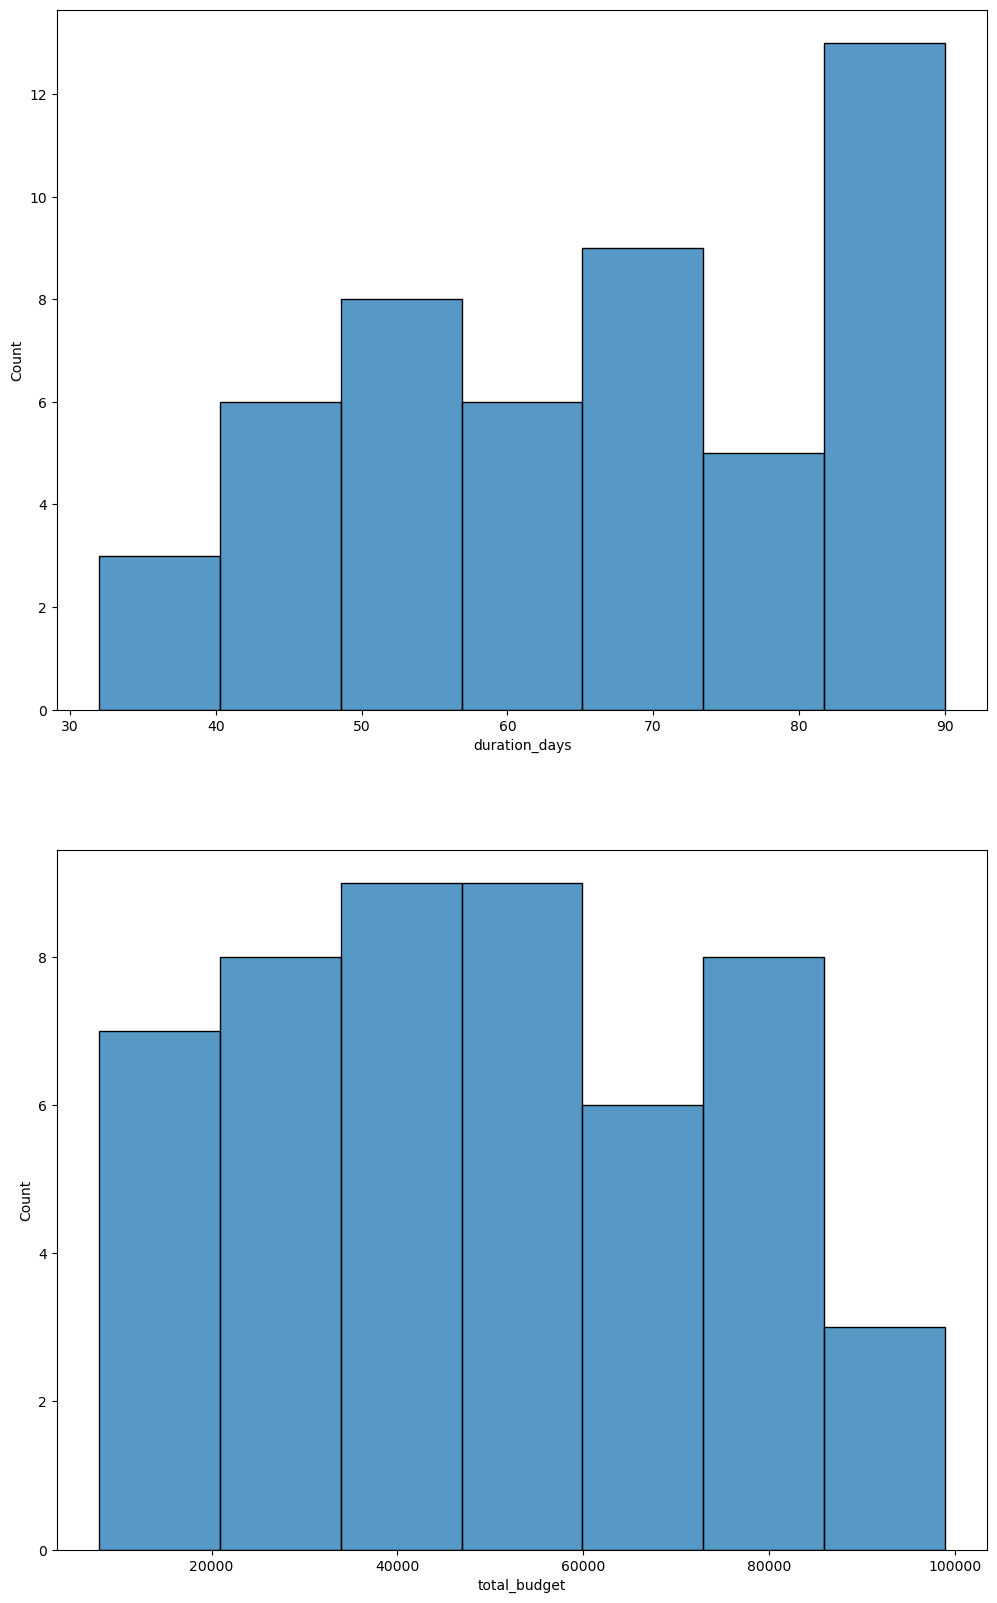

In [59]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(12,20))
ax1=ax[0];ax2=ax[1];

sns.histplot(data=df_campaigns,x="duration_days",ax=ax1)
sns.histplot(data=df_campaigns,x="total_budget",ax=ax2);

## MULTIVARIABLE DATA ANALYSIS

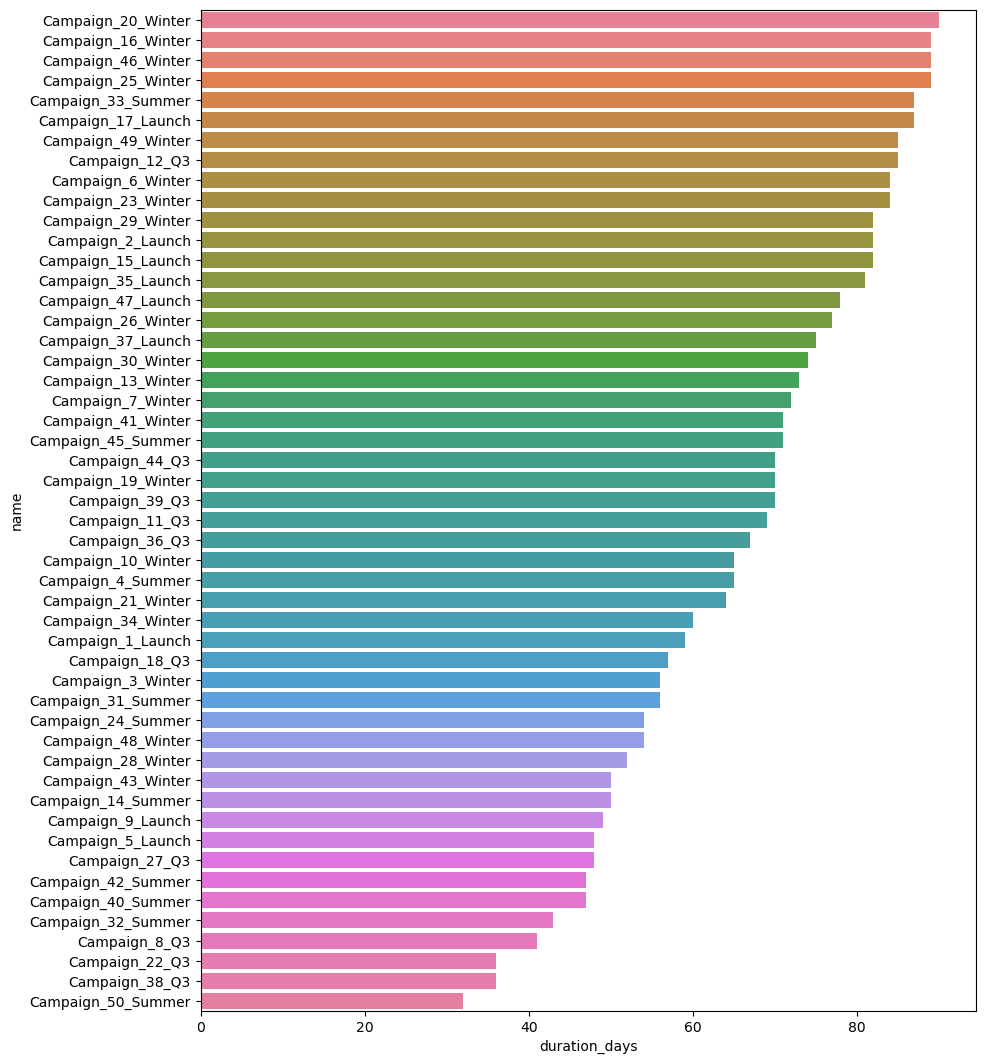

In [60]:
df_campaigns_desc=df_campaigns.sort_values(by="duration_days",ascending=False)
plt.figure(figsize=(10,13))
sns.barplot(data=df_campaigns_desc,x="duration_days",y="name",hue="name");

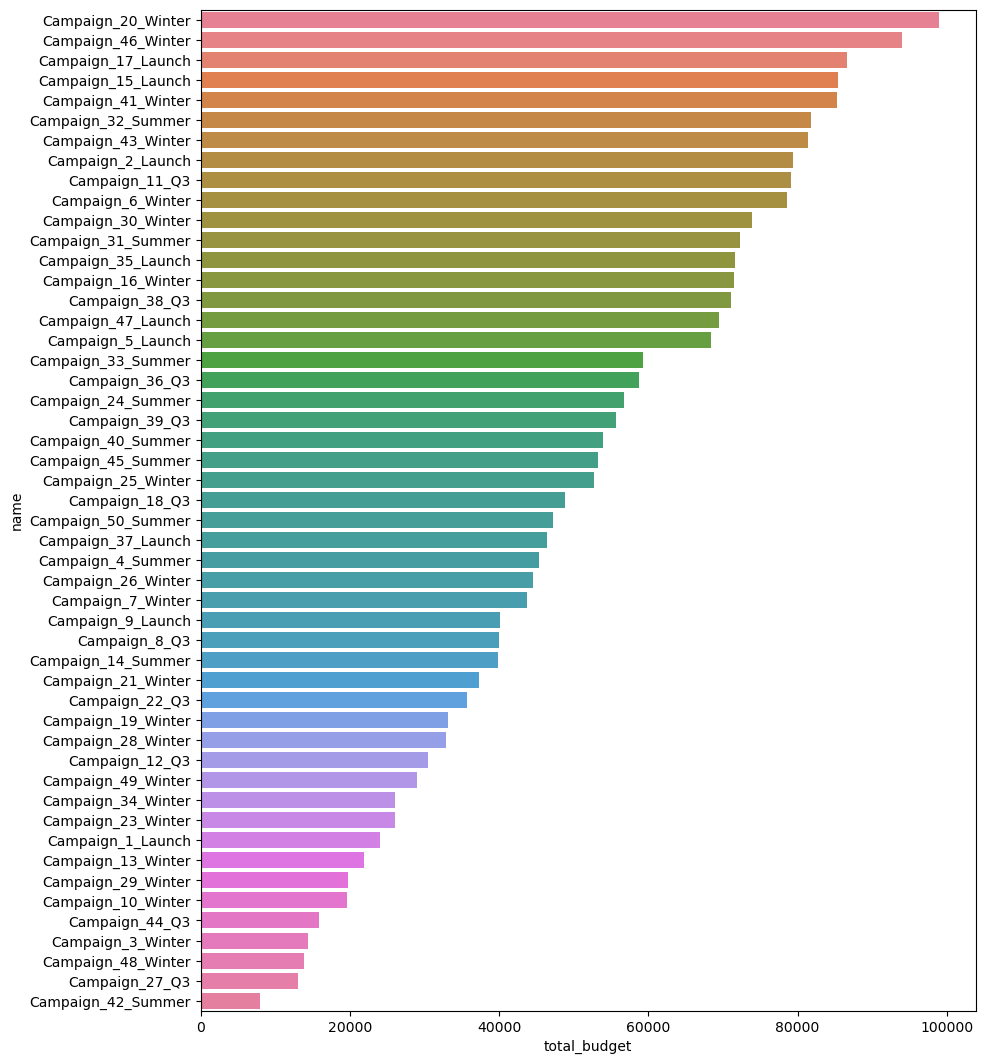

In [61]:
df_campaigns_desc=df_campaigns.sort_values(by="total_budget",ascending=False)
plt.figure(figsize=(10,13))
sns.barplot(data=df_campaigns_desc,x="total_budget",y="name",hue="name");

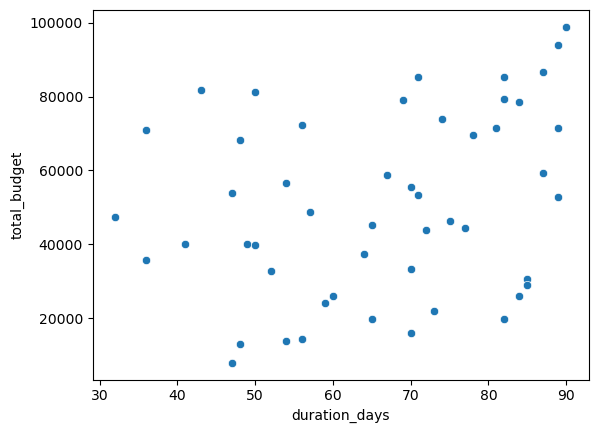

In [62]:
sns.scatterplot(data=df_campaigns,x="duration_days",y="total_budget");

In [63]:
#MONTH IN WHICH THE CAMPAIGN STARTS AND ENDS
print(df_campaigns["start_date"].dt.year.value_counts())
print(df_campaigns["start_date"].dt.month.value_counts())
print("")
print(df_campaigns["end_date"].dt.year.value_counts())
print(df_campaigns["end_date"].dt.month.value_counts())

start_date
2025    50
Name: count, dtype: int64
start_date
4    13
5    12
3     8
7     7
6     5
2     5
Name: count, dtype: int64

end_date
2025    50
Name: count, dtype: int64
end_date
6     13
7     11
8      7
5      7
9      5
4      4
10     3
Name: count, dtype: int64


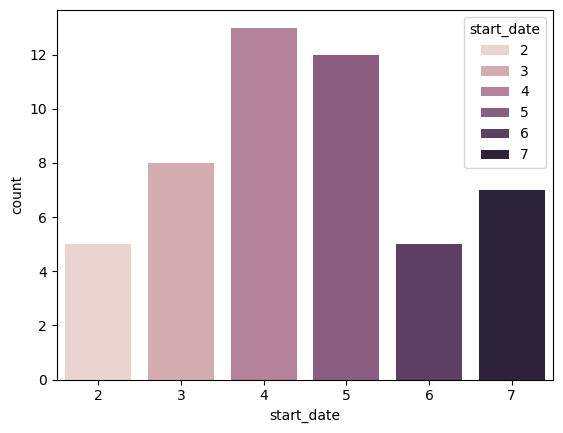

In [64]:
sns.countplot(data=df_campaigns,x=df_campaigns["start_date"].dt.month,hue=df_campaigns["start_date"].dt.month);

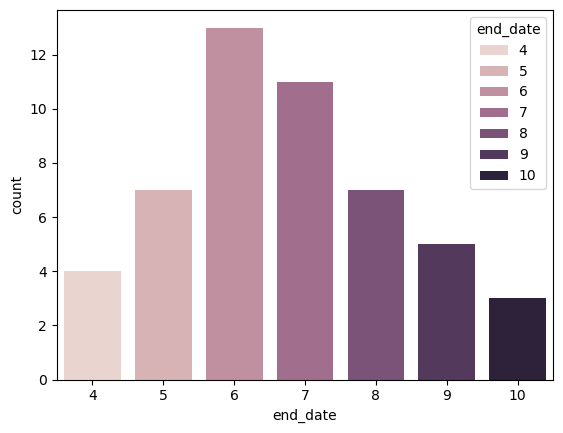

In [65]:
sns.countplot(data=df_campaigns,x=df_campaigns["end_date"].dt.month,hue=df_campaigns["end_date"].dt.month);

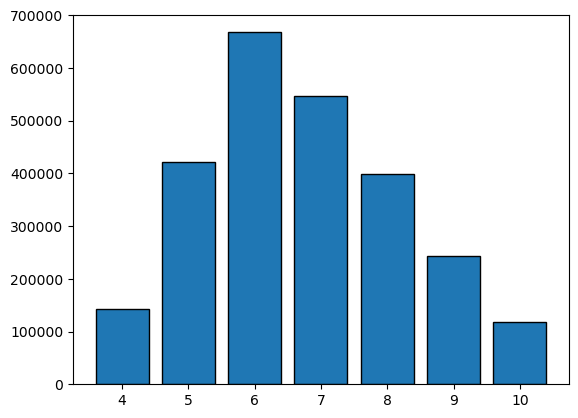

In [66]:
prueba=df_campaigns.groupby(by=df_campaigns["end_date"].dt.month)["total_budget"].sum()
prueba2=pd.DataFrame(prueba.reset_index())
plt.bar(prueba.index,height=prueba.values,edgecolor="Black");


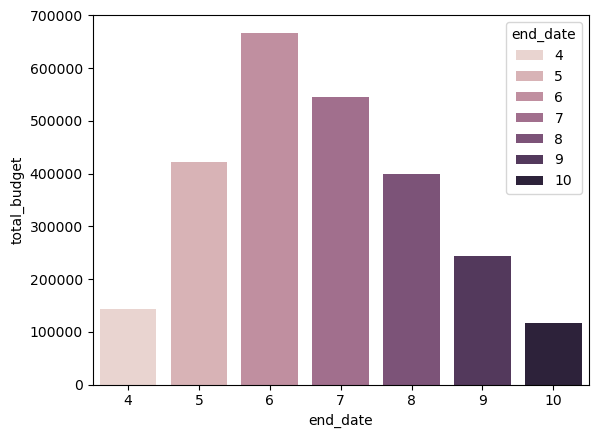

In [67]:
sns.barplot(data=prueba2,x="end_date",y="total_budget",hue="end_date");

## CAMPAIGN TABLE SUMMARY
**There are 50 different campaigns with varying durations and total costs.**
**name:** *Campaign name.*
**start_date:***CAMPAIGN START DATE IN YEAR/MONTH/DAY FORMAT. THE CAMPAIGNS ARE FROM 2025 AND THE MONTHS IN WHICH THEY STARTED ARE APRIL (4) WITH 13 REGISTRATIONS, MAY (5) WITH 12 REGISTRATIONS, MARCH (3) WITH 8 REGISTRATIONS, JULY (7) WITH 7 REGISTRATIONS, JUNE (6) WITH 5 REGISTRATIONS AND FEBRUARY (2) WITH 5 REGISTRATIONS. The months in which they mostly ended are June (6) with 13 records, July (7) with 11 records, August (8) with 7 records, May (5) with 7 records, September (9) with 5 records, April (4) with 4 records and October (10) with 3 records.*\
**end_date:** *Campaign end date in year/month/day format.*\
**duration_days:** *Number of days corresponding to the duration of each campaign. The most frequently recorded durations were 70, 82, and 89 days, with 3 records each. The longest duration was 90 days for the 'Campaign_20_Winter' campaign, and the shortest duration, at 32 days, was for the 'Campaign_50_Summer' campaign.*\
**total_budget:** *Total cost of each campaign. The total cost was generally between $38,000$ and $60,000$ with the 'Campaign_20_Winter' campaign having the highest cost at $98,904$ and the 'Campaign_42_Summer' campaign at $7,918$.*

### MULTIVARIABLE DATA ANALYSIS
**total_budget vs duration_days:** *There is no direct correlation between campaign duration and higher costs. Shorter campaigns generally have lower costs. While longer campaigns tend to be more expensive, this isn't always the case. Shorter campaigns can be more costly compared to longer ones, and some longer campaigns may not be as expensive.*

# AD EVENTS TABLE

In [69]:
df_ad_events.head(5)

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,312834,49,d75a9,2025-06-23 08:53:09,Monday,Morning,Impression
1,293696,185,0023e,2025-08-01 23:33:29,Friday,Evening,Impression
2,371590,12,f49e6,2025-05-20 06:38:48,Tuesday,Morning,Impression
3,384253,109,1eefe,2025-06-19 07:14:57,Thursday,Morning,Click
4,183939,35,540bb,2025-07-22 01:11:22,Tuesday,Night,Impression


In [70]:
df_ad_events_dict=df_ad_events.sample(n=1000,random_state=42)
df_ad_events_dict=df_ad_events_dict.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_ad_events_dict})
display(Markdown(response.content))

This dataset captures individual user interactions with advertisements. Each entry represents a single event related to an ad.

**Dataset Explanation:**

*   **`event_id`**: A unique identifier for each specific interaction event.
*   **`ad_id`**: Identifies the specific advertisement involved in the event. This allows tracking performance per ad.
*   **`user_id`**: An anonymized identifier for the user who performed the action. This enables analysis of individual user behavior.
*   **`timestamp`**: The precise date and time when the event occurred. Crucial for temporal analysis.
*   **`day_of_week`**: The day of the week (e.g., 'Monday', 'Friday') when the event occurred, derived from the timestamp. Useful for weekly patterns.
*   **`time_of_day`**: The general period of the day (e.g., 'Morning', 'Evening') when the event occurred, derived from the timestamp. Useful for daily patterns.
*   **`event_type`**: The type of interaction a user had with the ad. Possible values include: 'Impression' (ad was shown), 'Click' (user clicked the ad), 'Like', 'Share', 'Comment', 'Purchase'. This is the core metric for engagement and conversion.

---

**How to Analyze It: Graphs and Operations**

The primary goal of analyzing this dataset is to understand ad performance, user engagement, and identify patterns that can inform optimization strategies.

**1. Event Type Distribution & Overall Engagement**

*   **Operation:** Count the occurrences of each `event_type`.
*   **Graph:**
    *   **Bar Chart:** Visualize the frequency of each `event_type`.
    *   **Pie Chart:** Show the proportion of each `event_type` relative to the total.
*   **Key Metrics:**
    *   **Click-Through Rate (CTR):** `(Number of Clicks / Number of Impressions)`
    *   **Engagement Rate:** `(Number of Clicks + Likes + Shares + Comments / Number of Impressions)`
    *   **Purchase Conversion Rate:** `(Number of Purchases / Number of Clicks)` or `(Number of Purchases / Number of Impressions)`

**2. Ad Performance Analysis**

*   **Operation:** Group the data by `ad_id` and then calculate the counts of each `event_type` for each ad. Compute CTR and other engagement/conversion rates per ad.
*   **Graphs:**
    *   **Bar Chart (Top N Ads by Clicks/Purchases):** Identify the best-performing ads.
    *   **Scatter Plot (Impressions vs. Clicks/CTR):** Visualize how different ads perform relative to their visibility.
    *   **Stacked Bar Chart (Event Types per Ad):** Show the breakdown of interactions for specific ads.
*   **Insights:** Pinpoint high-performing ads to replicate success, and underperforming ads for optimization or removal.

**3. Temporal Analysis**

*   **Operation:** Group by `day_of_week`, `time_of_day`, or extract `hour_of_day` from `timestamp`. Count `event_type` occurrences for each time segment.
*   **Graphs:**
    *   **Stacked Bar Chart (Events by Day of Week):** Show engagement and conversions across different days.
    *   **Stacked Bar Chart (Events by Time of Day):** Reveal peak hours for different interaction types.
    *   **Line Chart (Events over Time):** Plot daily or hourly event counts (especially Clicks and Purchases) to observe trends and anomalies.
*   **Insights:** Determine optimal times and days for ad scheduling and campaign launches to maximize engagement and conversions.

**4. User Engagement Analysis (Basic)**

*   **Operation:** Group by `user_id` and count the total number of events or specific `event_type`s (e.g., number of clicks per user).
*   **Graphs:**
    *   **Histogram/Distribution Plot:** Show the distribution of events per user (e.g., how many users clicked once, twice, etc.).
*   **Insights:** Identify highly engaged users (potential loyal customers) or users who are repeatedly exposed but not converting (ad fatigue).

**5. Conversion Funnel (Conceptual with current data)**

*   **Operation:** This dataset doesn't explicitly link individual impressions to subsequent clicks/purchases by the *same user for the same ad in a session*. However, you can calculate overall funnel rates:
    *   Impressions -> Clicks (CTR)
    *   Clicks -> Purchases (Conversion Rate from Click)
    *   Impressions -> Purchases (Overall Conversion Rate)
*   **Graph:** A simple bar chart showing these derived rates.
*   **Insights:** Identify bottlenecks in the user journey. Is the ad getting impressions but no clicks? Or clicks but no purchases? This informs where to focus optimization efforts (ad creative, landing page, offer, etc.).

---

**Professional Perspective & Recommendations:**

This dataset is valuable for a foundational understanding of ad campaign performance. To derive deeper insights and actionable recommendations, I would:

1.  **Prioritize Core Metrics:** Focus on CTR and Purchase Conversion Rate as primary indicators of ad effectiveness.
2.  **Identify Top Performers:** Determine which `ad_id`s generate the highest engagement and conversions. Analyze their characteristics (if external data is available) to understand *why* they perform well.
3.  **Optimize Timing:** Use temporal analysis (`day_of_week`, `time_of_day`) to schedule ad delivery during peak engagement periods.
4.  **A/B Testing Foundation:** This data provides a baseline. Future experiments (A/B testing different ad creatives, targeting, etc.) can be measured against these initial findings.
5.  **Data Quality Check:** Ensure `timestamp` is correctly parsed and that `user_id`s and `ad_id`s are consistent. Look for any unusual spikes or drops in event counts that might indicate data issues or external factors.
6.  **Next Steps:** With more data (e.g., ad creatives, user demographics, campaign budgets), the analysis could extend to predictive modeling (e.g., predicting purchase likelihood) or more sophisticated customer journey mapping.

## EXPLORATORY DATA ANALYSIS

In [71]:
df_ad_events.isnull().sum()

event_id       0
ad_id          0
user_id        0
timestamp      0
day_of_week    0
time_of_day    0
event_type     0
dtype: int64

In [72]:
df_ad_events["timestamp"]=pd.to_datetime(df_ad_events["timestamp"],format="ISO8601")
type(df_ad_events["timestamp"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [73]:
df_ad_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   event_id     40000 non-null  int64         
 1   ad_id        40000 non-null  int64         
 2   user_id      40000 non-null  object        
 3   timestamp    40000 non-null  datetime64[ns]
 4   day_of_week  40000 non-null  object        
 5   time_of_day  40000 non-null  object        
 6   event_type   40000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 2.1+ MB


In [74]:
df_ad_events.describe()

,event_id,ad_id,timestamp
count,40000.000000,40000.000000,40000
mean,199868.351400,100.258375,2025-06-22 00:33:28.093600
min,27.000000,1.000000,2025-05-07 14:13:56
25%,100445.250000,51.000000,2025-05-29 23:44:16.500000
50%,199617.000000,100.000000,2025-06-22 03:16:44
75%,299547.000000,150.000000,2025-07-14 19:59:18
max,399943.000000,200.000000,2025-08-06 14:11:30
std,115370.068404,57.522572,NaN


In [75]:
print(df_ad_events["day_of_week"].value_counts())
print("")
print(df_ad_events["time_of_day"].value_counts())
print("")
print(df_ad_events["event_type"].value_counts())
print("")
print(df_ad_events["timestamp"].dt.hour.value_counts())
print("")
print(df_ad_events["timestamp"].dt.month.value_counts())
print("")
print(df_ad_events["user_id"].value_counts().head(5))

day_of_week
Friday       5783
Tuesday      5766
Sunday       5750
Monday       5710
Thursday     5694
Wednesday    5650
Saturday     5647
Name: count, dtype: int64

time_of_day
Evening      10069
Night        10014
Afternoon     9992
Morning       9925
Name: count, dtype: int64

event_type
Impression    34085
Click          3965
Like           1169
Comment         408
Share           192
Purchase        181
Name: count, dtype: int64

timestamp
16    1726
20    1725
9     1706
21    1701
2     1697
0     1690
4     1684
12    1677
1     1676
15    1671
19    1667
22    1663
18    1663
8     1659
3     1655
23    1650
10    1648
11    1648
13    1646
17    1645
6     1642
14    1627
7     1622
5     1612
Name: count, dtype: int64

timestamp
7    13601
6    13023
5    10843
8     2533
Name: count, dtype: int64

user_id
40a2a    14
2af0c    13
b292f    13
8d049    13
2799a    12
Name: count, dtype: int64


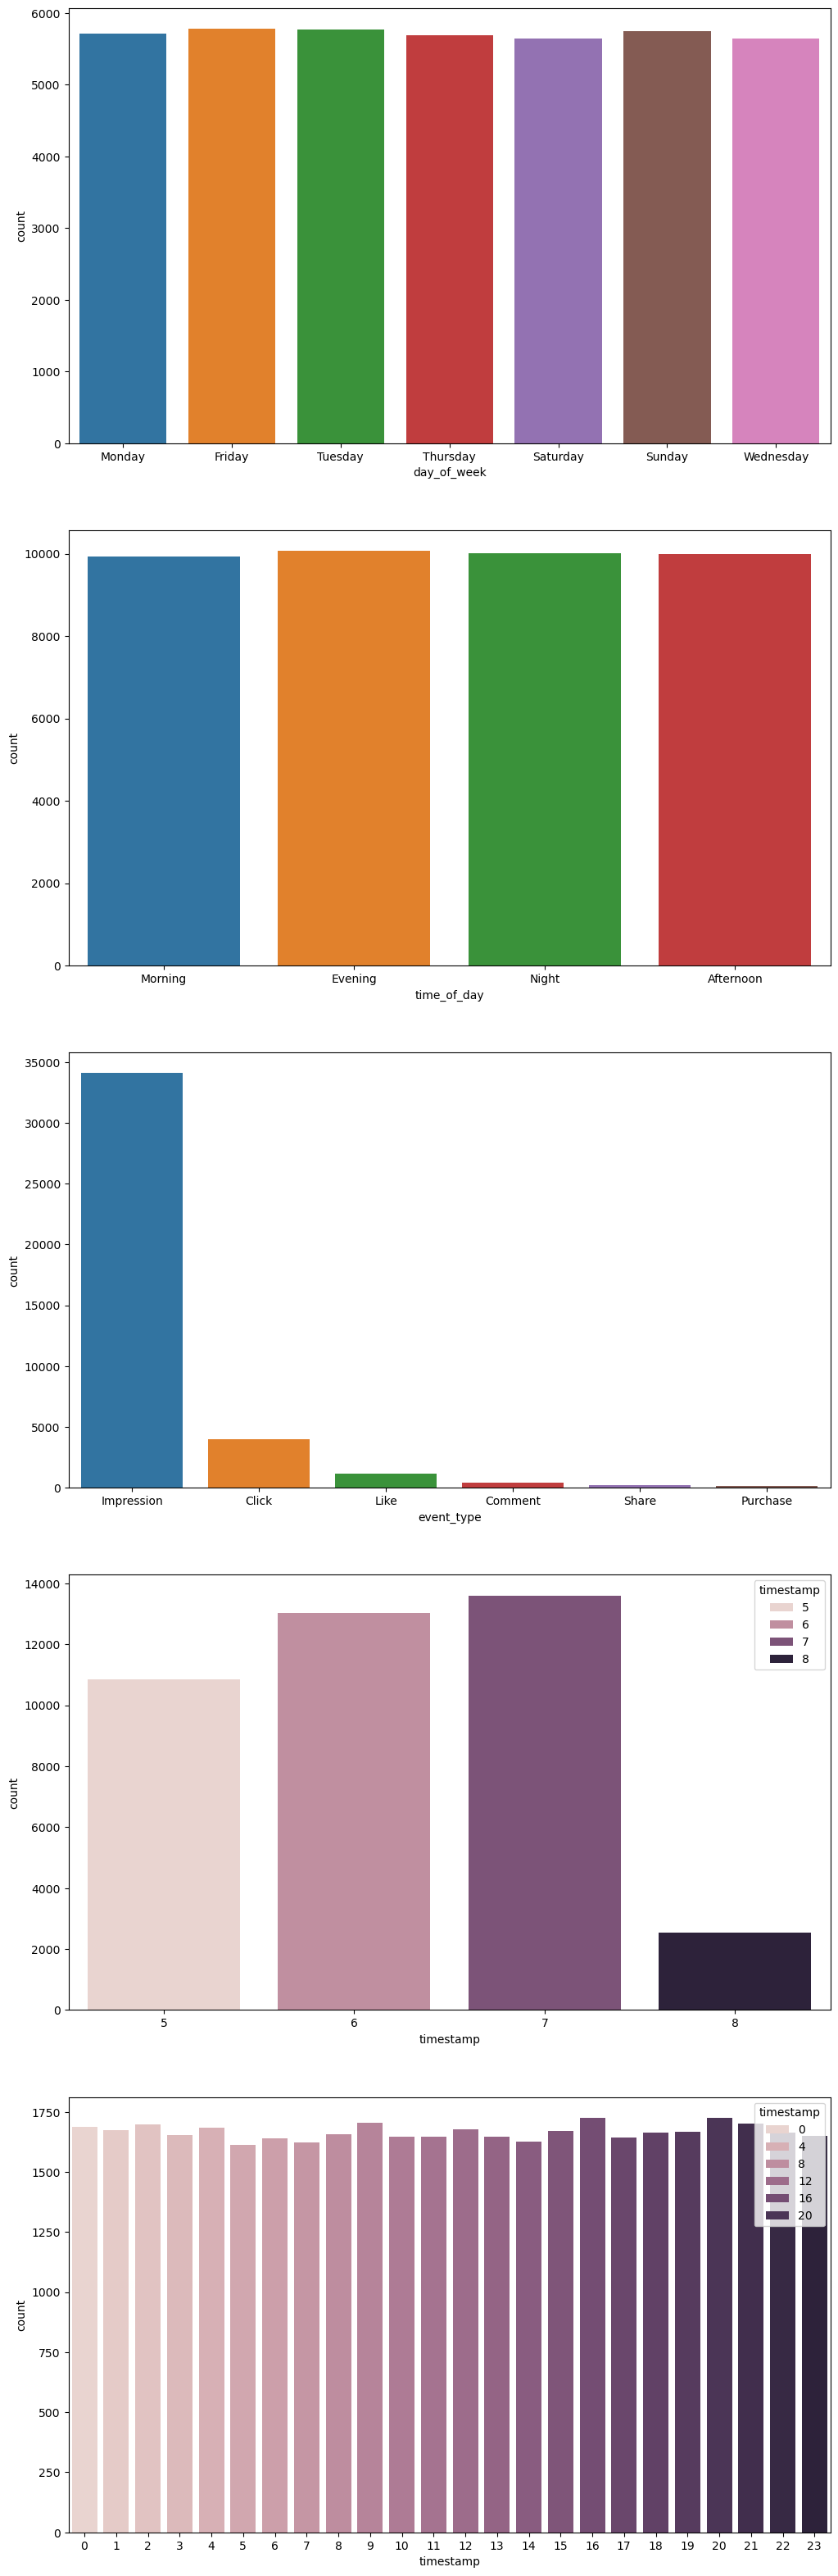

In [76]:
fig,ax=plt.subplots(nrows=5,ncols=1,figsize=(12,40))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4]


sns.countplot(data=df_ad_events,x="day_of_week",hue="day_of_week",ax=ax1)
sns.countplot(data=df_ad_events,x="time_of_day",hue="time_of_day",ax=ax2)
sns.countplot(data=df_ad_events,x="event_type",hue="event_type",ax=ax3)
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.month,hue=df_ad_events["timestamp"].dt.month,ax=ax4)
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.hour,hue=df_ad_events["timestamp"].dt.hour,ax=ax5);

In [77]:
hora = df_ad_events.assign(hour=df_ad_events["timestamp"].dt.hour) \
                   .sort_values("hour", ascending=False)
hora

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,hour
8606,297524,139,3b825,2025-06-08 23:44:31,Sunday,Evening,Impression,23
36026,53199,33,b4fed,2025-05-07 23:43:24,Wednesday,Evening,Impression,23
29718,121282,105,17ac0,2025-06-25 23:57:02,Wednesday,Evening,Impression,23
35982,45010,116,2d068,2025-05-22 23:25:53,Thursday,Evening,Click,23
7685,365156,126,ecd17,2025-07-04 23:23:56,Friday,Evening,Impression,23
...,...,...,...,...,...,...,...,...
9708,42106,20,a093e,2025-07-31 00:01:33,Thursday,Night,Impression,0
33056,124576,114,78f90,2025-06-12 00:36:25,Thursday,Night,Click,0
3261,387472,6,eaf41,2025-06-02 00:31:24,Monday,Night,Impression,0
22530,90777,24,9c620,2025-05-19 00:21:31,Monday,Night,Impression,0


## MULTIVARIABLE DATA ANALYSIS

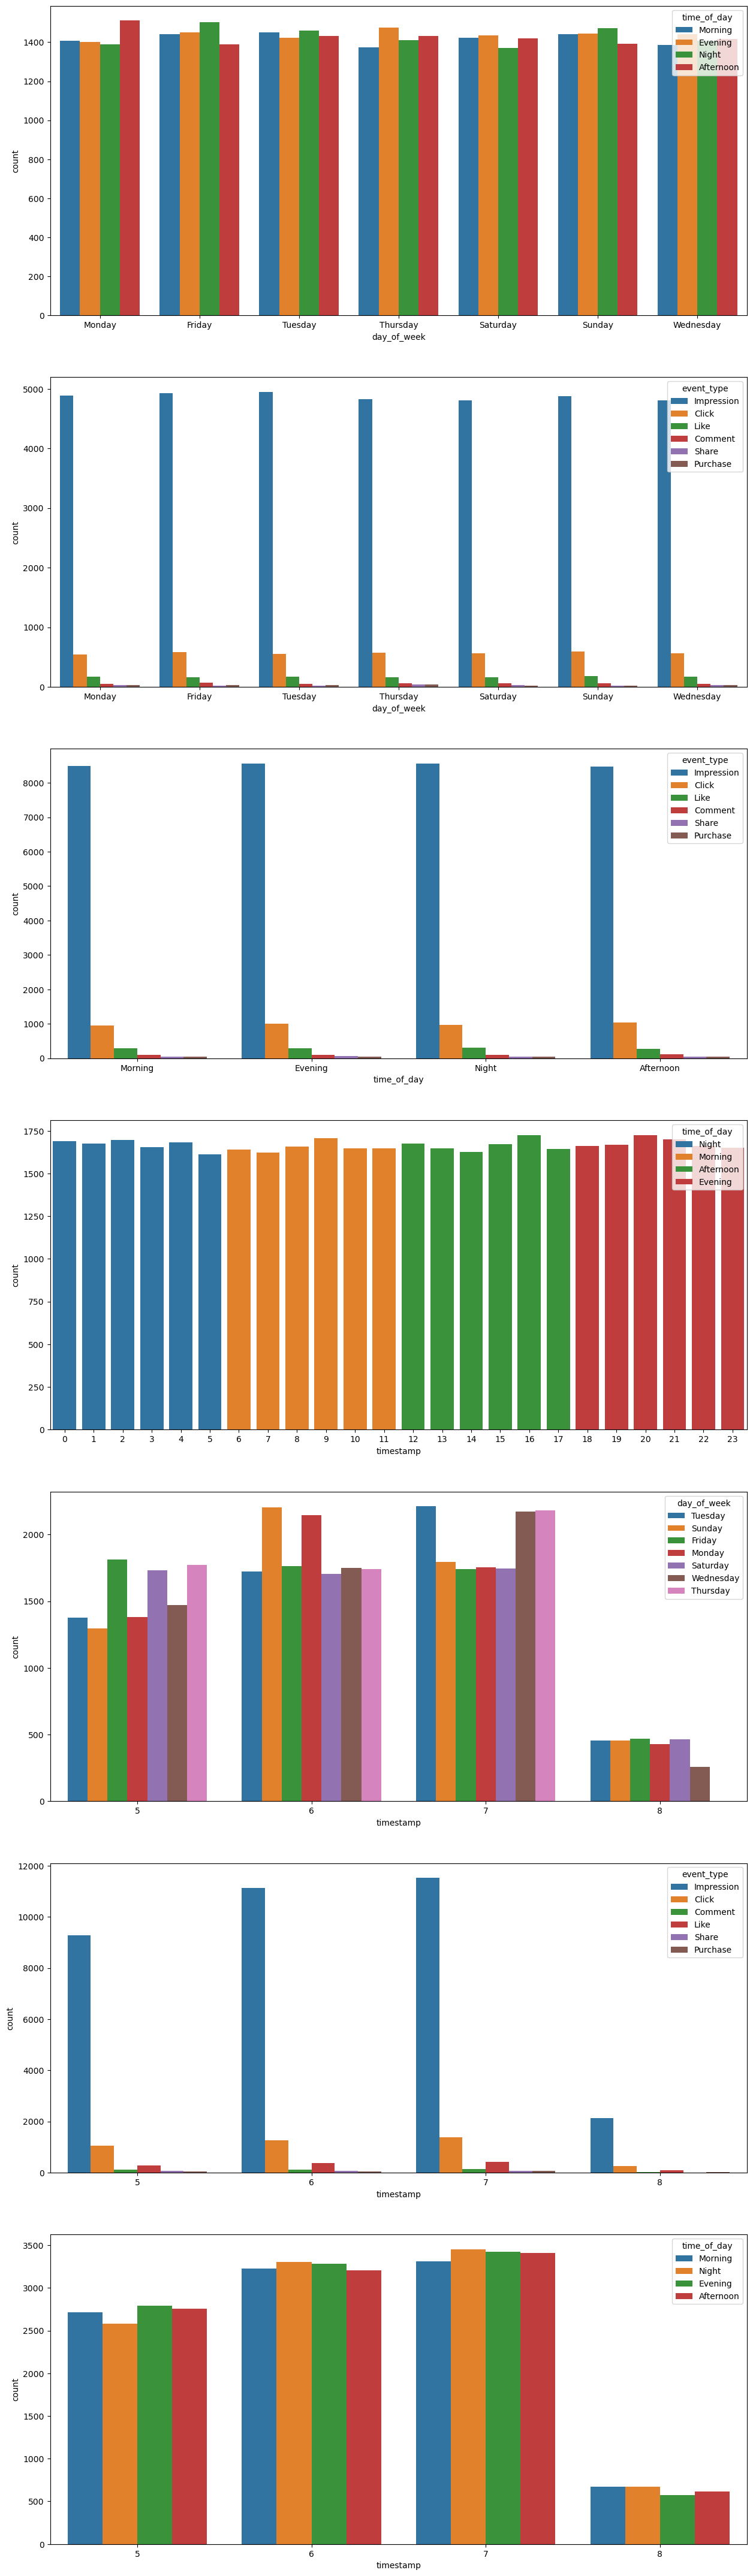

In [79]:
fig,ax=plt.subplots(nrows=7,ncols=1,figsize=(15,55))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4];ax6=ax[5];ax7=ax[6];

sns.countplot(data=df_ad_events,x=df_ad_events["day_of_week"],hue="time_of_day",ax=ax1)
sns.countplot(data=df_ad_events,x="day_of_week",hue="event_type",ax=ax2)
sns.countplot(data=df_ad_events,x="time_of_day",hue="event_type",ax=ax3)
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.hour,hue="time_of_day",ax=ax4)
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.month,hue="day_of_week",ax=ax5)
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.month,hue="event_type",ax=ax6);
sns.countplot(data=df_ad_events,x=df_ad_events["timestamp"].dt.month,hue="time_of_day",ax=ax7);

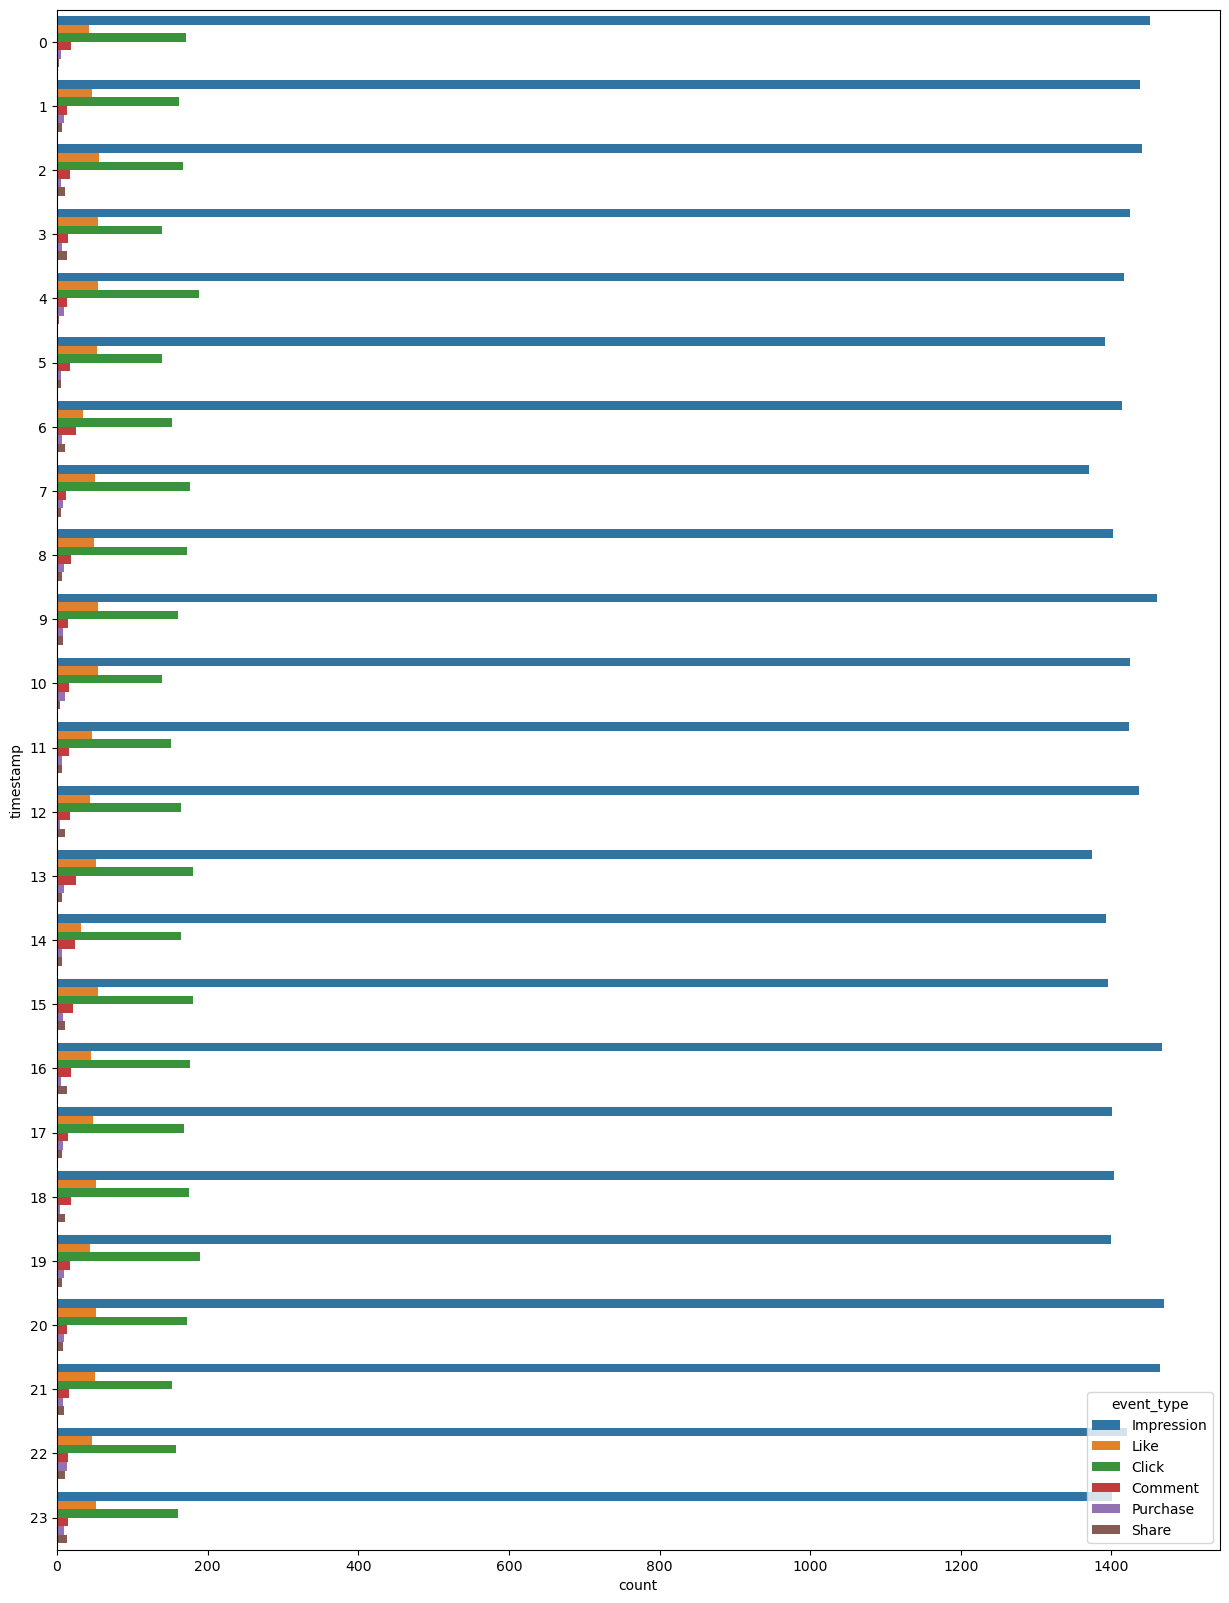

In [80]:
plt.figure(figsize=(15,20))
sns.countplot(data=df_ad_events,y=df_ad_events["timestamp"].dt.hour,hue="event_type");

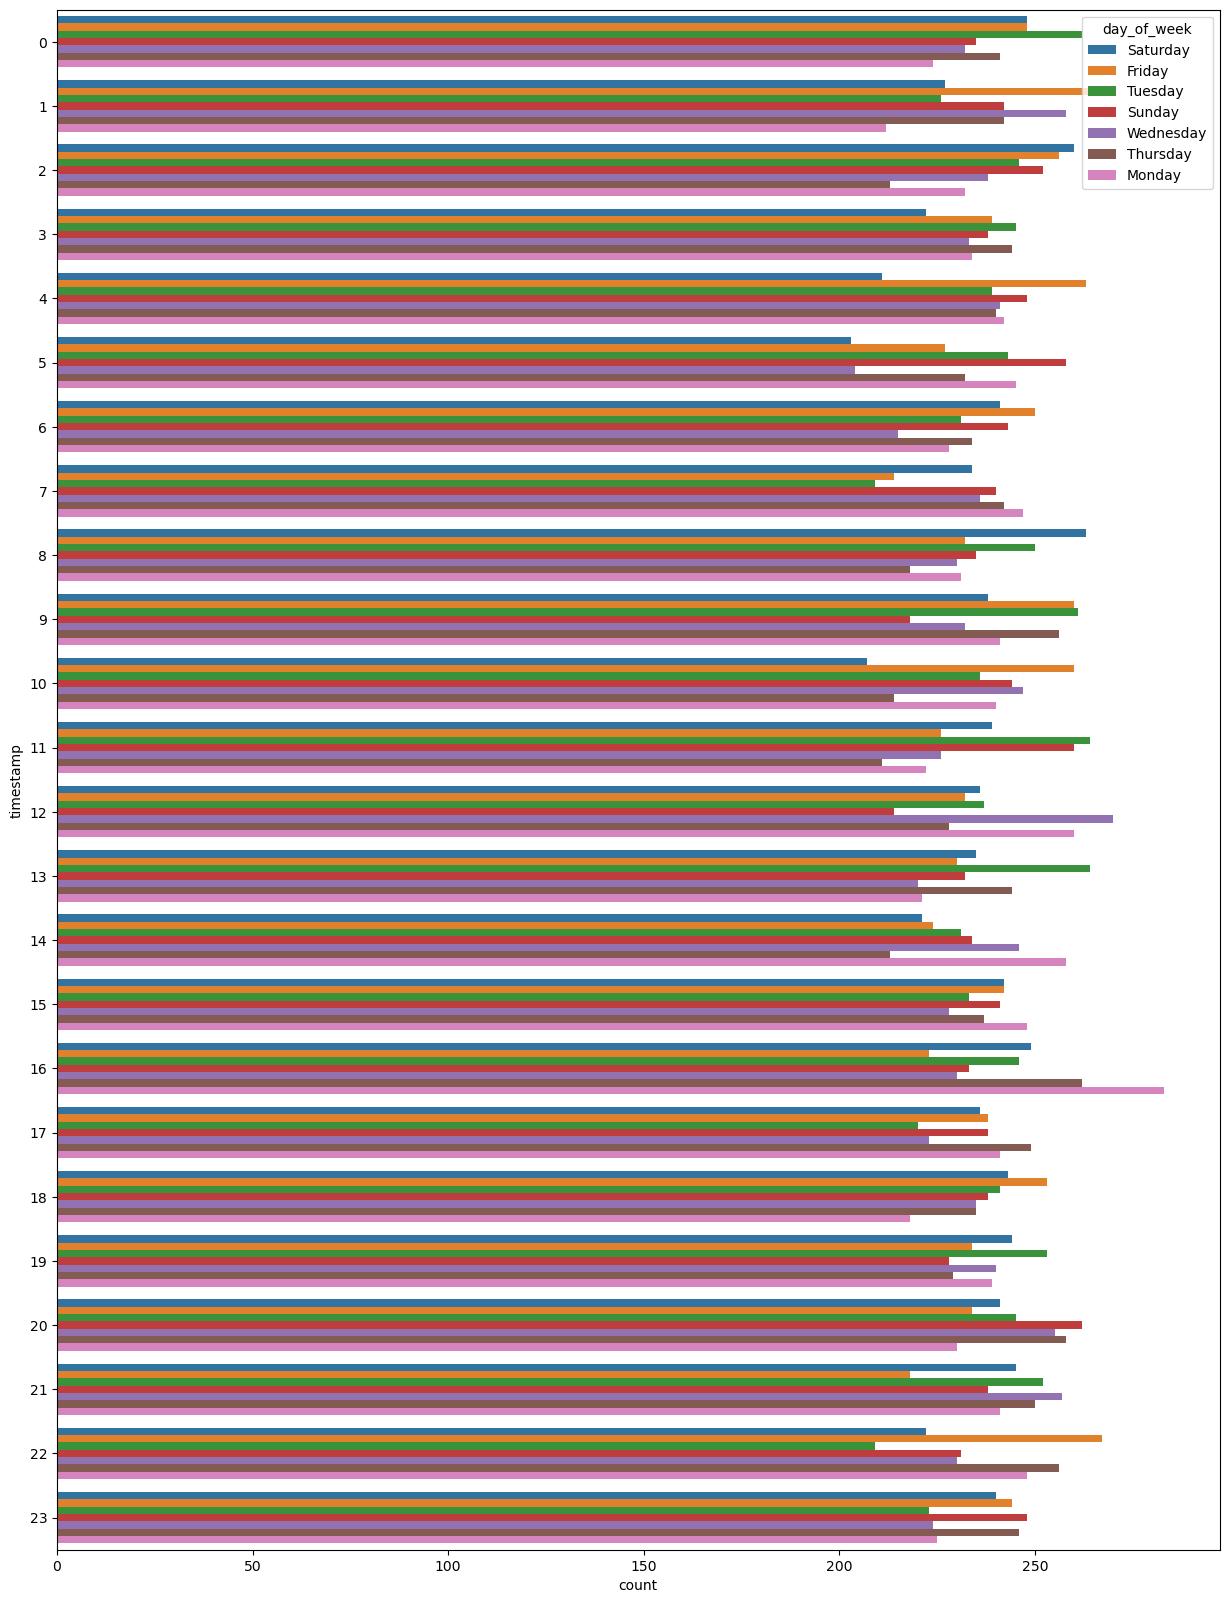

In [81]:
plt.figure(figsize=(15,20))
sns.countplot(data=df_ad_events,y=df_ad_events["timestamp"].dt.hour,hue="day_of_week");

## AD EVENTS SUMMARY

**THE DATASET CONSISTS OF RECORDS OF EVENTS THAT EACH USER HAD, SUCH AS THE TYPE OF EVENT, THE TIME OF DAY, AND THE DAY OF THE WEEK. THE TOTAL NUMBER OF RECORDS IN THE DATASET IS 400,000, BUT THIS ANALYSIS USED 10% OF THAT AMOUNT, THAT IS, 40,000 RECORDS.**
**TIMESTAMP:** *DATE AND TIME THE USER PERFORMED THE INTERACTION OR EVENT. THE RECORD FORMAT IS YEAR/MONTH/DAY-HOUR/MINUTE/SECOND. The 5 hours with the most registrations were 11 AM with $1,745$ registrations, 1 AM with $1,737$, 6 AM with $1,730$, 10 PM with $1,719$ and 7 PM with $1,710$. The month with the most registrations was July with $13,694$, followed by June with $13,225$, May with $10,749$ and finally August with $2,332$.
**day_of_week:** *Day of the week the event was registered. These correspond to Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, and Sunday. The days with the most reported events were Friday with $5792$, followed by Saturday with $5784$, Thursday with $5765$, Monday with $5711$, Tuesday with $5695$, Sunday with $5630$, and Wednesday with $5623$.*
**time_of_day:** *At what time of day was the event recorded? These are morning, afternoon, evening, and night. The highest number of registrations was for sunset with $10,040$, followed by morning with $9,996$, night with $9,992$, and afternoon with $9,972$.*
**event_type:** *Type of reaction the user had to the ad, such as impression, like, click, comment, purchase, and share. The event type with the highest registration was impression with $34,016$, followed by click with $3,960$, like with $1,211$, comment with $436$, purchase with $189$, and share with $188.$*

## MULTIVARIABLE ANALYSIS
**day_of_week vs time_of_day:** *Following the data on the days with the most registrations, we see that on Friday there were the most reactions, primarily at dusk, followed by at night, afternoon, and finally in the morning. On Saturday, there were the most reactions in the afternoon, followed by at night, and a tie between dusk and morning. On Thursday, there were the most reactions at dusk, followed by at night, afternoon, and finally in the morning. On Monday, there were the most reactions in the morning, followed by at night, dusk, and finally at night. On Tuesday, there were the most reactions at dusk, followed by morning, evening, and finally in the afternoon. On Sunday there were very similar reactions, but the peak times were in the morning, followed by the afternoon, evening, and finally nightfall. Finally, on Wednesday there were more reactions in the afternoon, followed by the morning, evening, and finally nightfall.*\
**day_of_week vs event_type:** *The predominant type of reaction every day was impression, followed by click, like, comment, and sometimes, in a tie or higher, purchase and share.*\
**time_of_day vs event_type:** *The reactions at different times of the day were as follows: first impression, followed by click, like, comment, and a tie between purchase and share.*\
**Time of day vs. hour:** *IN THIS RECORD, NIGHT CONSISTS OF 12 AM - 5 AM, MORNING OF 6 AM - 11 AM, AFTERNOON OF 12 PM - 5 PM, AND EVENING OF 6 PM - 11 PM.*\
**Day of week vs. month:** *Following the data on the months with the most registrations, we see that in July there were more registrations on Tuesday, followed by Wednesday, Thursday, Saturday, Monday, Friday, and Sunday. In June there were more registrations on Monday, followed by Sunday, Thursday, Saturday, Friday, Tuesday, and Wednesday. In May there were more registrations on Friday, followed by Saturday, Thursday, Wednesday, Monday, Tuesday, and Sunday. In August there were fewer registrations. The day with the most registrations was Saturday, followed by Monday, Friday, Sunday, Tuesday, and finally Wednesday. In this case, there were no registrations for Thursday.*\
**event_type vs month:** *In every month, the following order of reaction was observed: first, this impression, followed by click, like, comment, purchase, and share.*\
**time_of_day vs. month:** *According to the data, July, the month with the most records, had the most records in the afternoon, followed by the evening, dusk, and morning. June had the most records in the morning, followed by the evening, dusk, and afternoon. In May, there were the most records at dusk, followed by the afternoon, morning, and evening. Finally, in August, there were the most records at night, followed by the morning, afternoon, and evening.*\
**event_type vs. hour:** *Throughout the day, the following reaction order was observed: Impression was the most frequent reaction, followed by Click, Like, Comment, Share, and finally Purchase.*\
**Summary:** *The dataset shows an active audience primarily during the June-July period, with a preference for use towards the end of the day (evening) and during weekends, although with a very low conversion rate (purchases/shares) compared to views.*

# UNIENDO TABLA AD EVENTS, USERS Y ADS

## TABLA ADS & CAMPAIGNS

In [82]:

df_ads_campaign=pd.merge(df_ads,df_campaigns[["campaign_id","name","start_date","end_date","duration_days","total_budget"]],on="campaign_id",how="left")
df_ads_campaign

,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests,name,start_date,end_date,duration_days,total_budget
0,1,28,Facebook,Video,Female,35-44,"art, technology",Campaign_28_Winter,2025-05-09,2025-06-30,52,32844.79
1,2,33,Facebook,Stories,All,25-34,"travel, photography",Campaign_33_Summer,2025-04-08,2025-07-04,87,59264.68
2,3,20,Instagram,Carousel,All,25-34,technology,Campaign_20_Winter,2025-02-17,2025-05-18,90,98904.66
3,4,28,Facebook,Stories,Female,25-34,news,Campaign_28_Winter,2025-05-09,2025-06-30,52,32844.79
4,5,24,Instagram,Image,Female,25-34,news,Campaign_24_Summer,2025-03-30,2025-05-23,54,56692.87
...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,12,Facebook,Stories,Male,35-44,"gaming, sports",Campaign_12_Q3,2025-03-08,2025-06-01,85,30525.65
196,197,9,Facebook,Stories,All,All,"lifestyle, gaming",Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07
197,198,34,Facebook,Video,All,35-44,"fitness, lifestyle",Campaign_34_Winter,2025-07-10,2025-09-08,60,26104.30
198,199,15,Instagram,Video,Male,25-34,"art, news",Campaign_15_Launch,2025-03-21,2025-06-11,82,85407.23


In [83]:

df_ad_campaign_dict=df_ads_campaign.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_ad_campaign_dict})
display(Markdown(response.content))

This dataset describes individual advertisements (`ad_id`) and the campaigns they belong to (`campaign_id`). Each entry provides details about the ad's characteristics, its target audience, and the overall budget and duration of its parent campaign.

**Dataset Explanation:**

*   **`ad_id`**: A unique identifier for each specific advertisement.
*   **`campaign_id`**: An identifier for the advertising campaign to which the ad belongs. Multiple ads can share the same `campaign_id`.
*   **`ad_platform`**: The social media or advertising platform where the ad is run (e.g., 'Facebook', 'Instagram').
*   **`ad_type`**: The format of the advertisement (e.g., 'Video', 'Stories', 'Carousel', 'Image').
*   **`target_gender`**: The gender demographic targeted by the ad ('Female', 'Male', 'All').
*   **`target_age_group`**: The age range targeted by the ad (e.g., '18-24', '25-34', '35-44', 'All').
*   **`target_interests`**: A comma-separated string listing the interests targeted by the ad (e.g., 'art, technology').
*   **`name`**: The name of the campaign. This is duplicated across all ads within the same `campaign_id`.
*   **`start_date`**: The date when the campaign began.
*   **`end_date`**: The date when the campaign is scheduled to end.
*   **`duration_days`**: The total number of days the campaign is planned to run. This is duplicated across all ads within the same `campaign_id`.
*   **`total_budget`**: The total budget allocated for the entire campaign. This is duplicated across all ads within the same `campaign_id`.

**How to Analyze the Dataset:**

The primary goal is to understand the structure of ad campaigns, targeting strategies, and budget allocation across different platforms and ad types.

**Useful Operations:**

1.  **Data Loading & Initial Inspection:**
    *   Load the data into a Pandas DataFrame.
    *   Use `df.info()` to check data types and missing values.
    *   Use `df.describe()` for summary statistics of numerical columns.
2.  **Handle Campaign-Level Duplicates:**
    *   Since `name`, `start_date`, `end_date`, `duration_days`, and `total_budget` are campaign-level attributes, create a separate DataFrame of unique campaigns using `df[['campaign_id', 'name', 'start_date', 'end_date', 'duration_days', 'total_budget']].drop_duplicates()`. This is crucial for accurate budget and duration analysis.
3.  **Feature Engineering:**
    *   **`budget_per_day`**: Calculate `total_budget / duration_days` for campaigns to understand daily spending rates.
    *   **Individual Interests**: Split the `target_interests` string into separate interests (e.g., using `.str.split(', ')` and `explode()` in Pandas) to analyze the frequency of individual interest targets.
    *   **Month/Quarter**: Extract the month or quarter from `start_date` to analyze seasonality.
4.  **Categorical Analysis:**
    *   **`value_counts()`**: Use `df['column'].value_counts()` to find the distribution of `ad_platform`, `ad_type`, `target_gender`, `target_age_group`, and individual `target_interests`.
    *   **`groupby()` and `agg()`**: Group by categorical variables (e.g., `ad_platform`, `ad_type`) and aggregate numerical ones (e.g., `total_budget`, `duration_days`) using `sum()`, `mean()`, `median()`, `min()`, `max()`. Example: `df.groupby('ad_platform')['total_budget'].sum()`.

**Useful Graphs:**

1.  **Bar Charts:**
    *   **Distribution of Categorical Variables:**
        *   Number of ads per `ad_platform`.
        *   Number of ads per `ad_type`.
        *   Number of ads per `target_gender` and `target_age_group`.
        *   Frequency of individual `target_interests` (after splitting).
    *   **Aggregated Metrics by Category:**
        *   Total `total_budget` by `ad_platform` (using the unique campaigns DataFrame).
        *   Average `duration_days` by `ad_type`.
        *   Average `budget_per_day` by `target_gender` or `target_age_group`.
2.  **Histograms / Box Plots:**
    *   **`duration_days` distribution:** To understand the typical length of campaigns.
    *   **`total_budget` distribution:** To see the range and concentration of campaign budgets.
    *   **`budget_per_day` distribution:** To analyze daily spending patterns.
3.  **Stacked Bar Charts:**
    *   **`ad_type` breakdown by `ad_platform`**: To visualize which ad types are more prevalent on specific platforms.
    *   **`target_gender` or `target_age_group` distribution by `ad_platform`**: To see if platforms target different demographics.
4.  **Scatter Plots:**
    *   **`duration_days` vs. `total_budget`**: To explore the relationship between campaign length and budget (using the unique campaigns DataFrame).

**Professional Perspective & Recommendations:**

*   **Campaign-Centric Analysis:** Always remember that `total_budget` and `duration_days` are campaign-level. When analyzing these, ensure you are working with unique campaigns (e.g., by dropping duplicates on `campaign_id`) to prevent inflated sums or skewed averages.
*   **Targeting Deep Dive:** The `target_interests` field is rich. Splitting it into individual interests and analyzing their frequencies will reveal popular targeting themes. You can then investigate if certain interests are more common on specific platforms or with particular ad types.
*   **Budget Efficiency:** Calculating `budget_per_day` is a critical metric. It allows you to compare the intensity of spending across campaigns, regardless of their total duration or budget.
*   **Missing Performance Data:** This dataset provides *planned* campaign details. To truly evaluate success, you would need performance metrics like impressions, clicks, conversions, and actual costs. Without this, you can only analyze *how* campaigns are set up, not *how effective* they are.
*   **Key Insights to Seek:**
    *   Which platforms and ad types are most utilized and receive the highest budgets?
    *   Are there common targeting strategies (gender, age, interests) linked to specific platforms or ad formats?
    *   What are the typical budget allocations and durations for different types of campaigns?
    *   Are there any seasonal trends in campaign launches or budgets based on `start_date`?

## EXPLORATORY DATA ANALYSIS (EDA)

In [84]:
print(df_ads_campaign["name"].value_counts().head(5))

name
Campaign_20_Winter    8
Campaign_24_Summer    8
Campaign_17_Launch    8
Campaign_42_Summer    8
Campaign_38_Q3        8
Name: count, dtype: int64


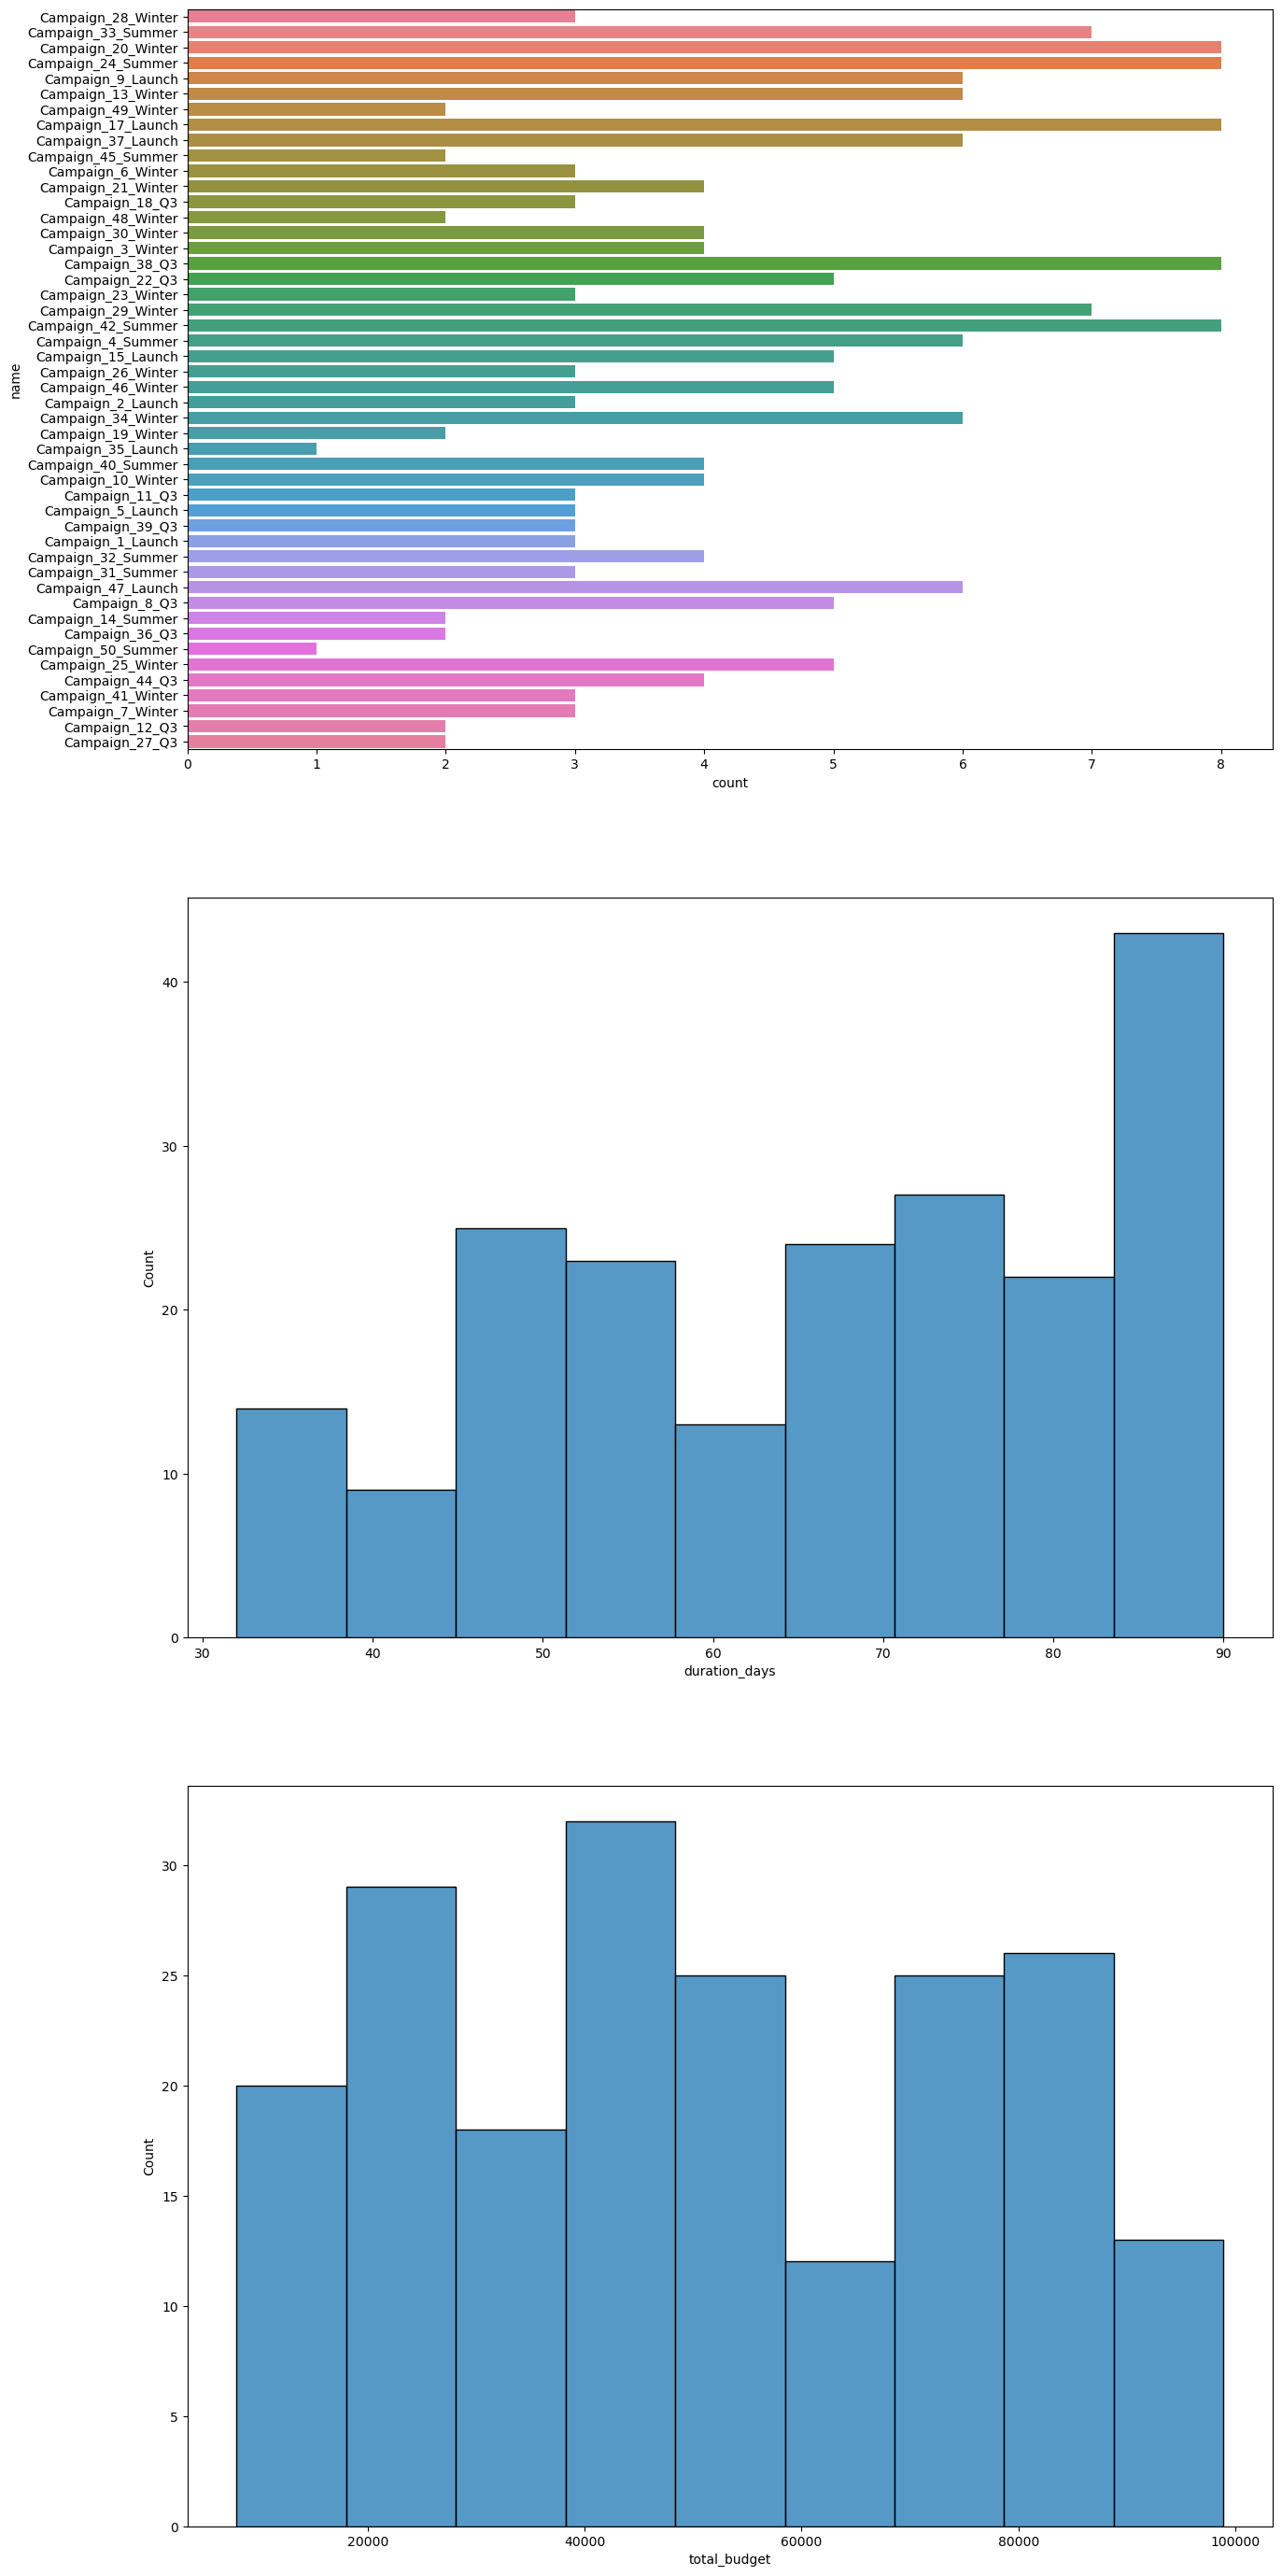

In [85]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_ads_campaign,y="name",hue="name",ax=ax1)
sns.histplot(data=df_ads_campaign,x="duration_days",ax=ax2)
sns.histplot(data=df_ads_campaign,x="total_budget",ax=ax3);

## MULTIVARIABLE DATA ANALYSIS

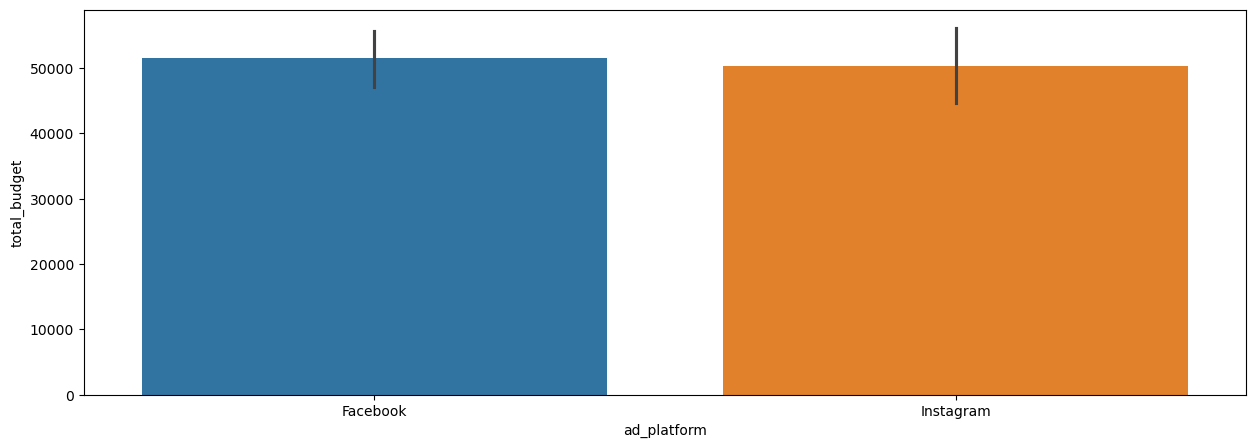

In [86]:
plt.figure(figsize=(15,5))
sns.barplot(data=df_ads_campaign,x="ad_platform",y="total_budget",hue="ad_platform");

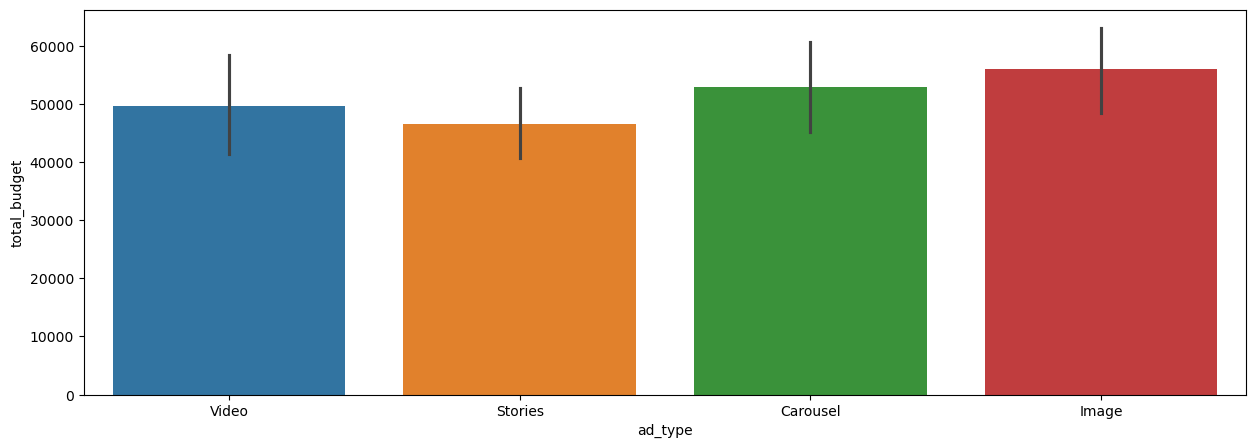

In [87]:
plt.figure(figsize=(15,5))
sns.barplot(data=df_ads_campaign,x="ad_type",y="total_budget",hue="ad_type");

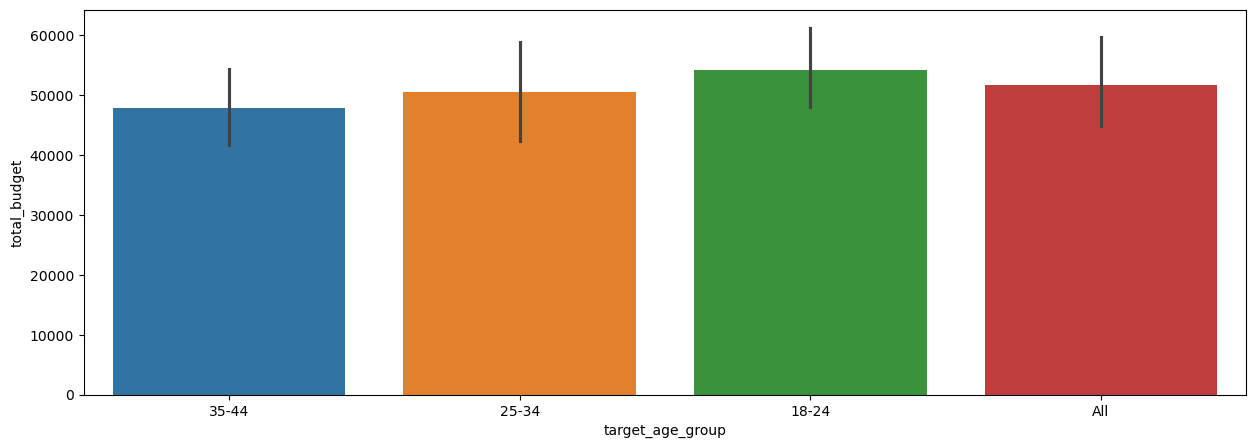

In [88]:
plt.figure(figsize=(15,5))
sns.barplot(data=df_ads_campaign,x="target_age_group",y="total_budget",hue="target_age_group");

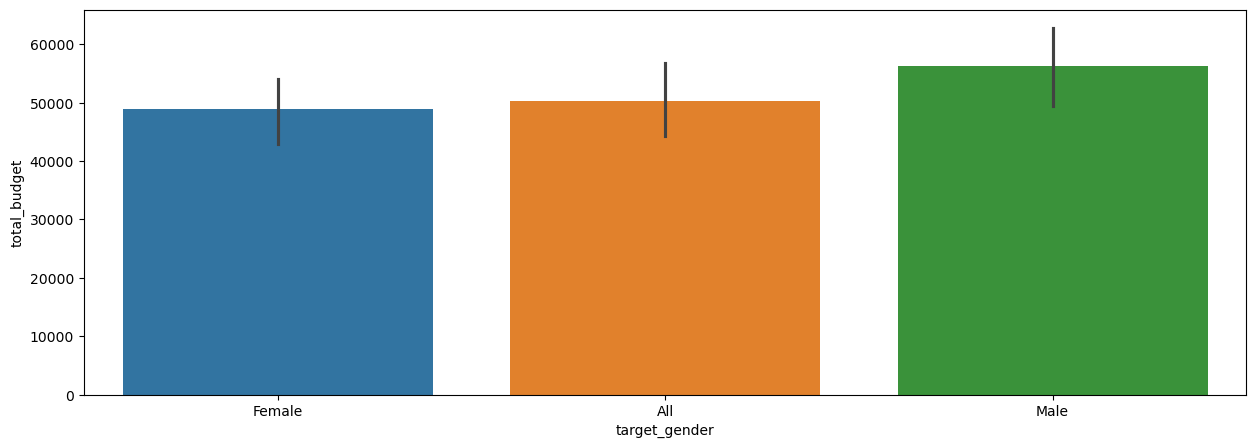

In [89]:
plt.figure(figsize=(15,5))
sns.barplot(data=df_ads_campaign,x="target_gender",y="total_budget",hue="target_gender");

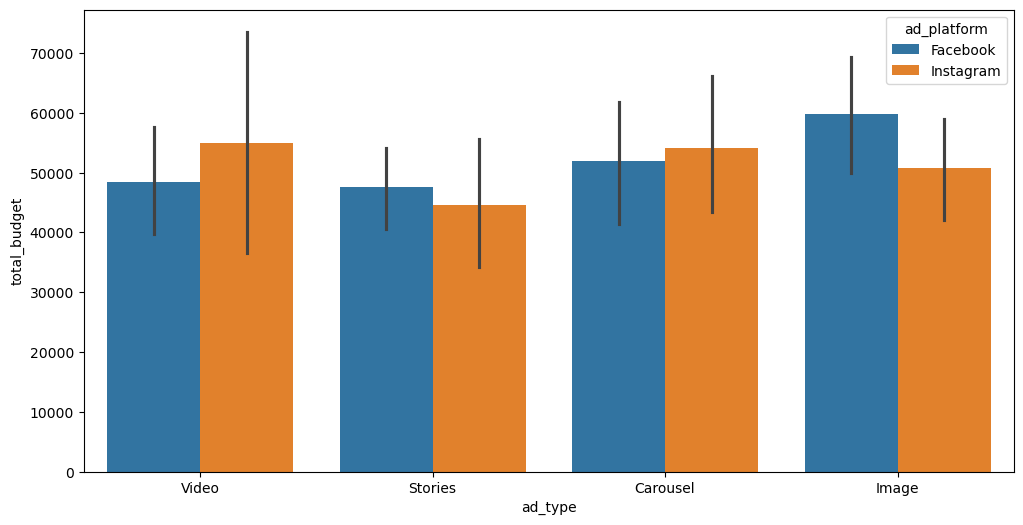

In [90]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ads_campaign,x="ad_type",y="total_budget",hue="ad_platform");

In [91]:
df_costos = df_ads_campaign.groupby(['name', 'ad_platform'])['total_budget'].mean().reset_index()
df_costos = df_costos.sort_values('total_budget', ascending=False)
print(df_costos)

                  name ad_platform  total_budget
18  Campaign_20_Winter   Instagram      98904.66
17  Campaign_20_Winter    Facebook      98904.66
65  Campaign_46_Winter    Facebook      94023.76
66  Campaign_46_Winter   Instagram      94023.76
11  Campaign_17_Launch   Instagram      86675.92
..                 ...         ...           ...
69  Campaign_48_Winter    Facebook      13842.07
31      Campaign_27_Q3    Facebook      12986.30
32      Campaign_27_Q3   Instagram      12986.30
61  Campaign_42_Summer   Instagram       7918.04
60  Campaign_42_Summer    Facebook       7918.04

[84 rows x 3 columns]


In [92]:
df_costos = df_ads_campaign.groupby(['ad_platform', 'ad_type'])['total_budget'].mean().reset_index()
df_costos = df_costos.sort_values('total_budget', ascending=False)
print(df_costos)

  ad_platform   ad_type  total_budget
1    Facebook     Image  59760.583667
7   Instagram     Video  54890.310000
4   Instagram  Carousel  54194.779565
0    Facebook  Carousel  51898.384643
5   Instagram     Image  50721.566818
3    Facebook     Video  48396.915556
2    Facebook   Stories  47572.819286
6   Instagram   Stories  44555.882273


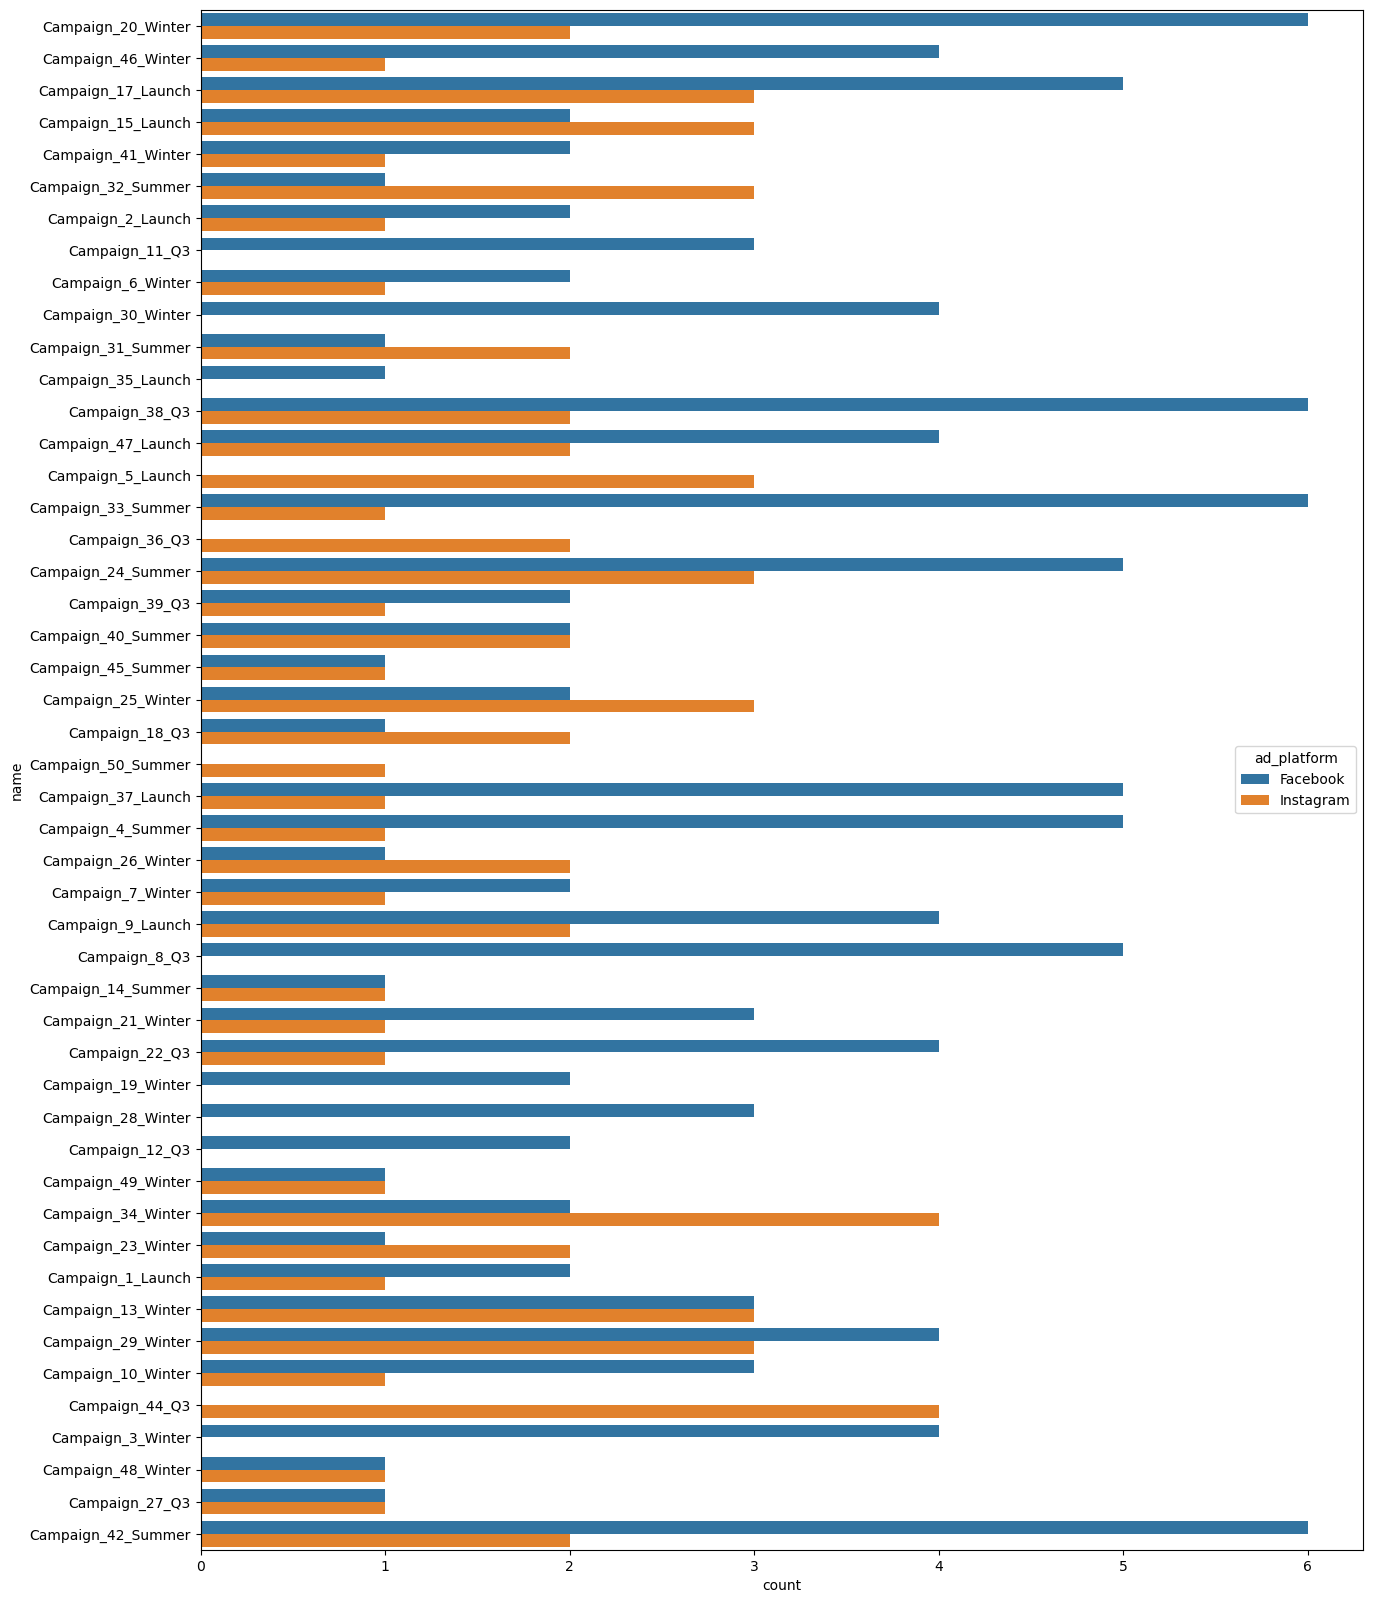

In [93]:
df_total_budget = df_ads_campaign.sort_values(by="total_budget",ascending=False)
plt.figure(figsize=(15,20))
sns.countplot(data=df_total_budget,y="name",hue="ad_platform");

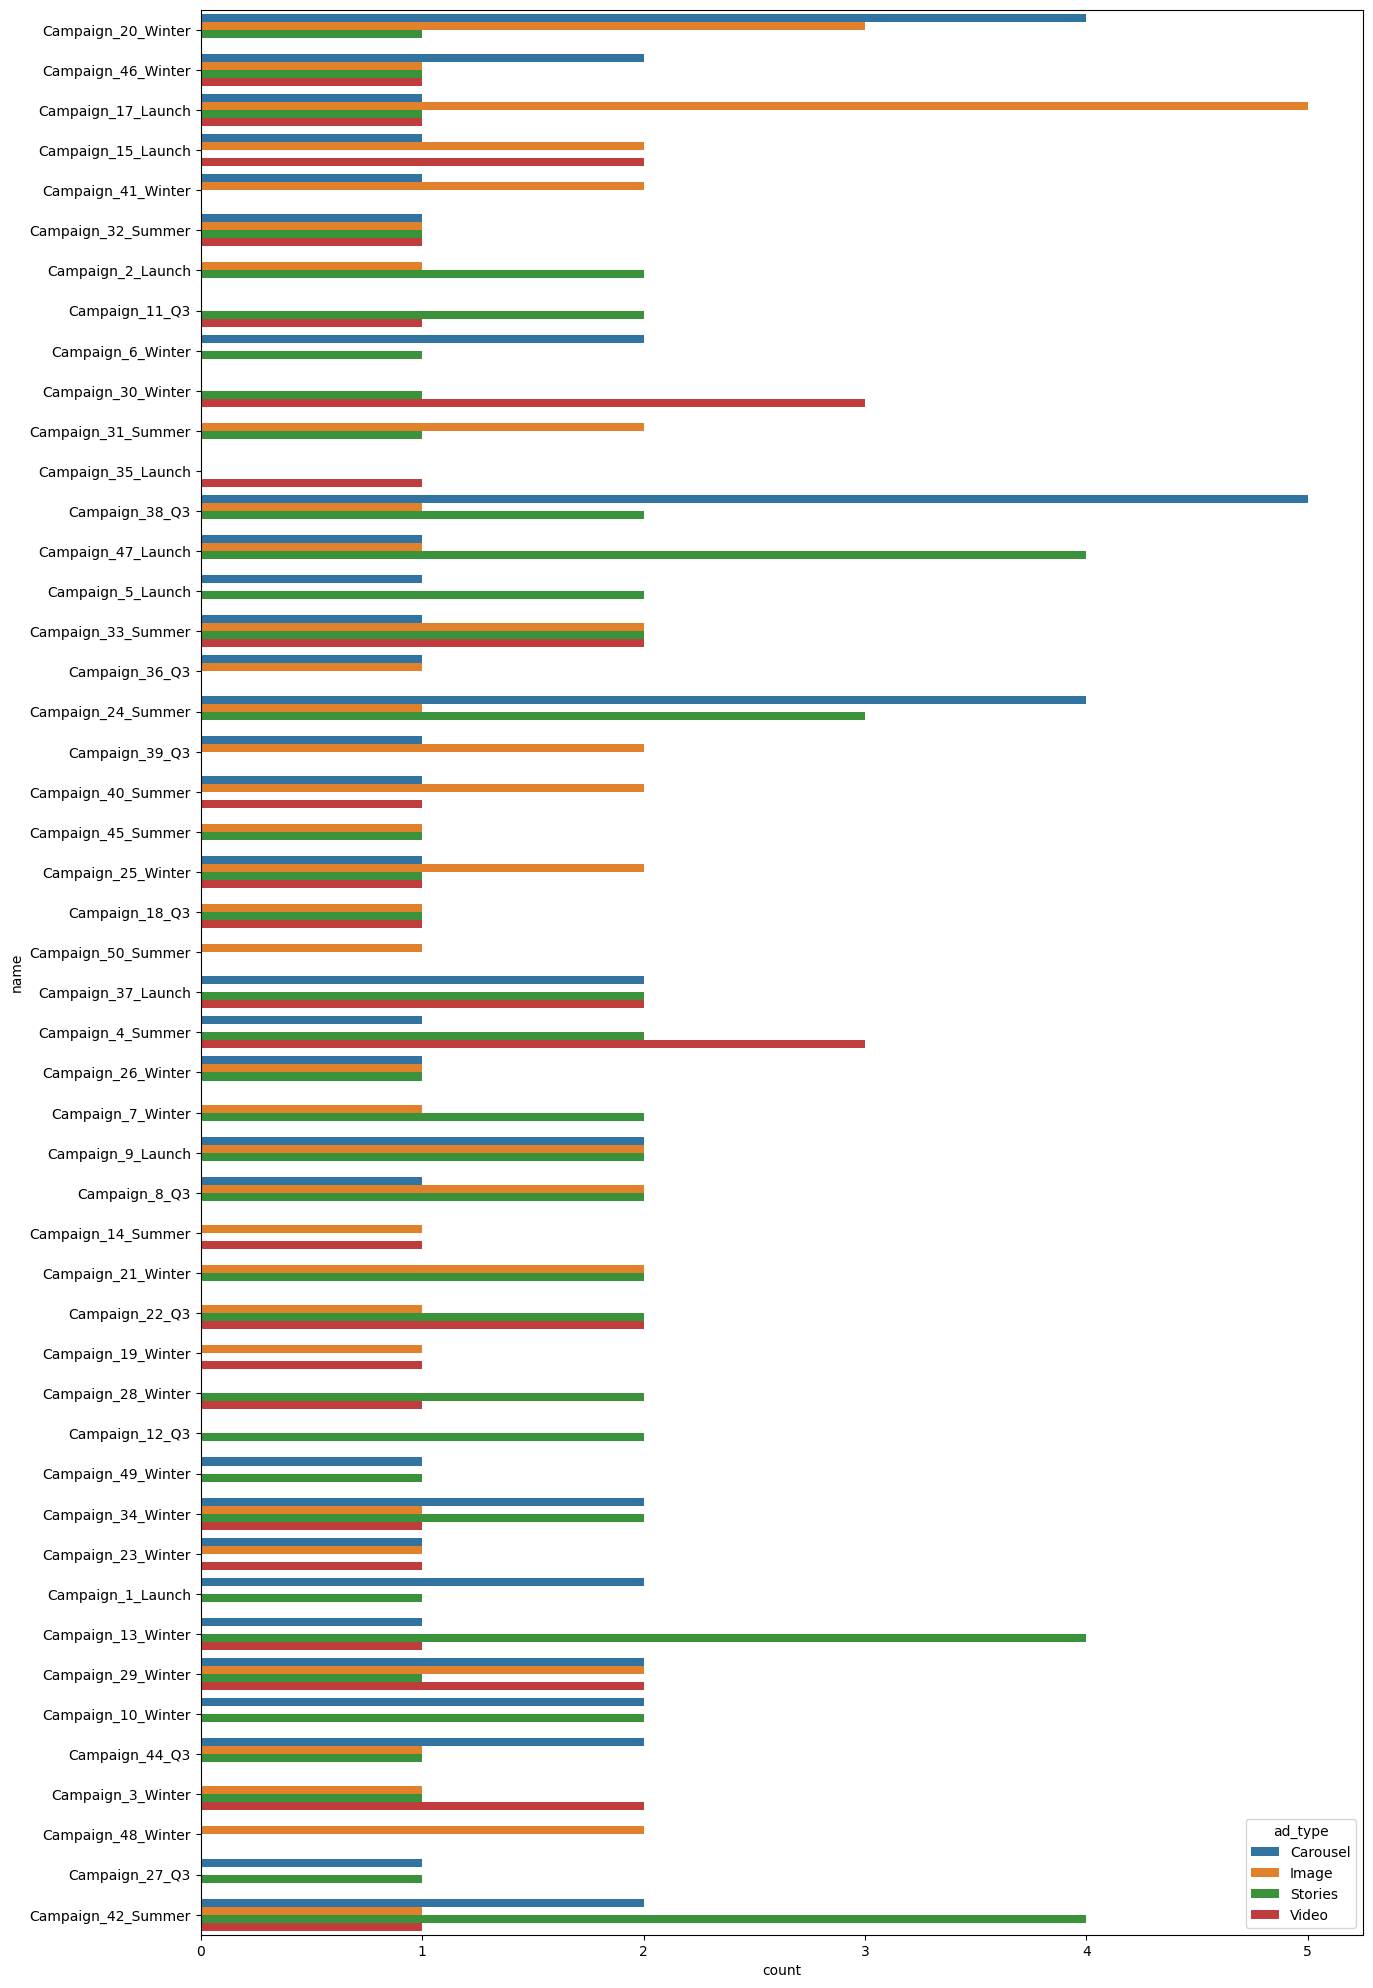

In [94]:
plt.figure(figsize=(15,25))
sns.countplot(data=df_total_budget,y="name",hue="ad_type");

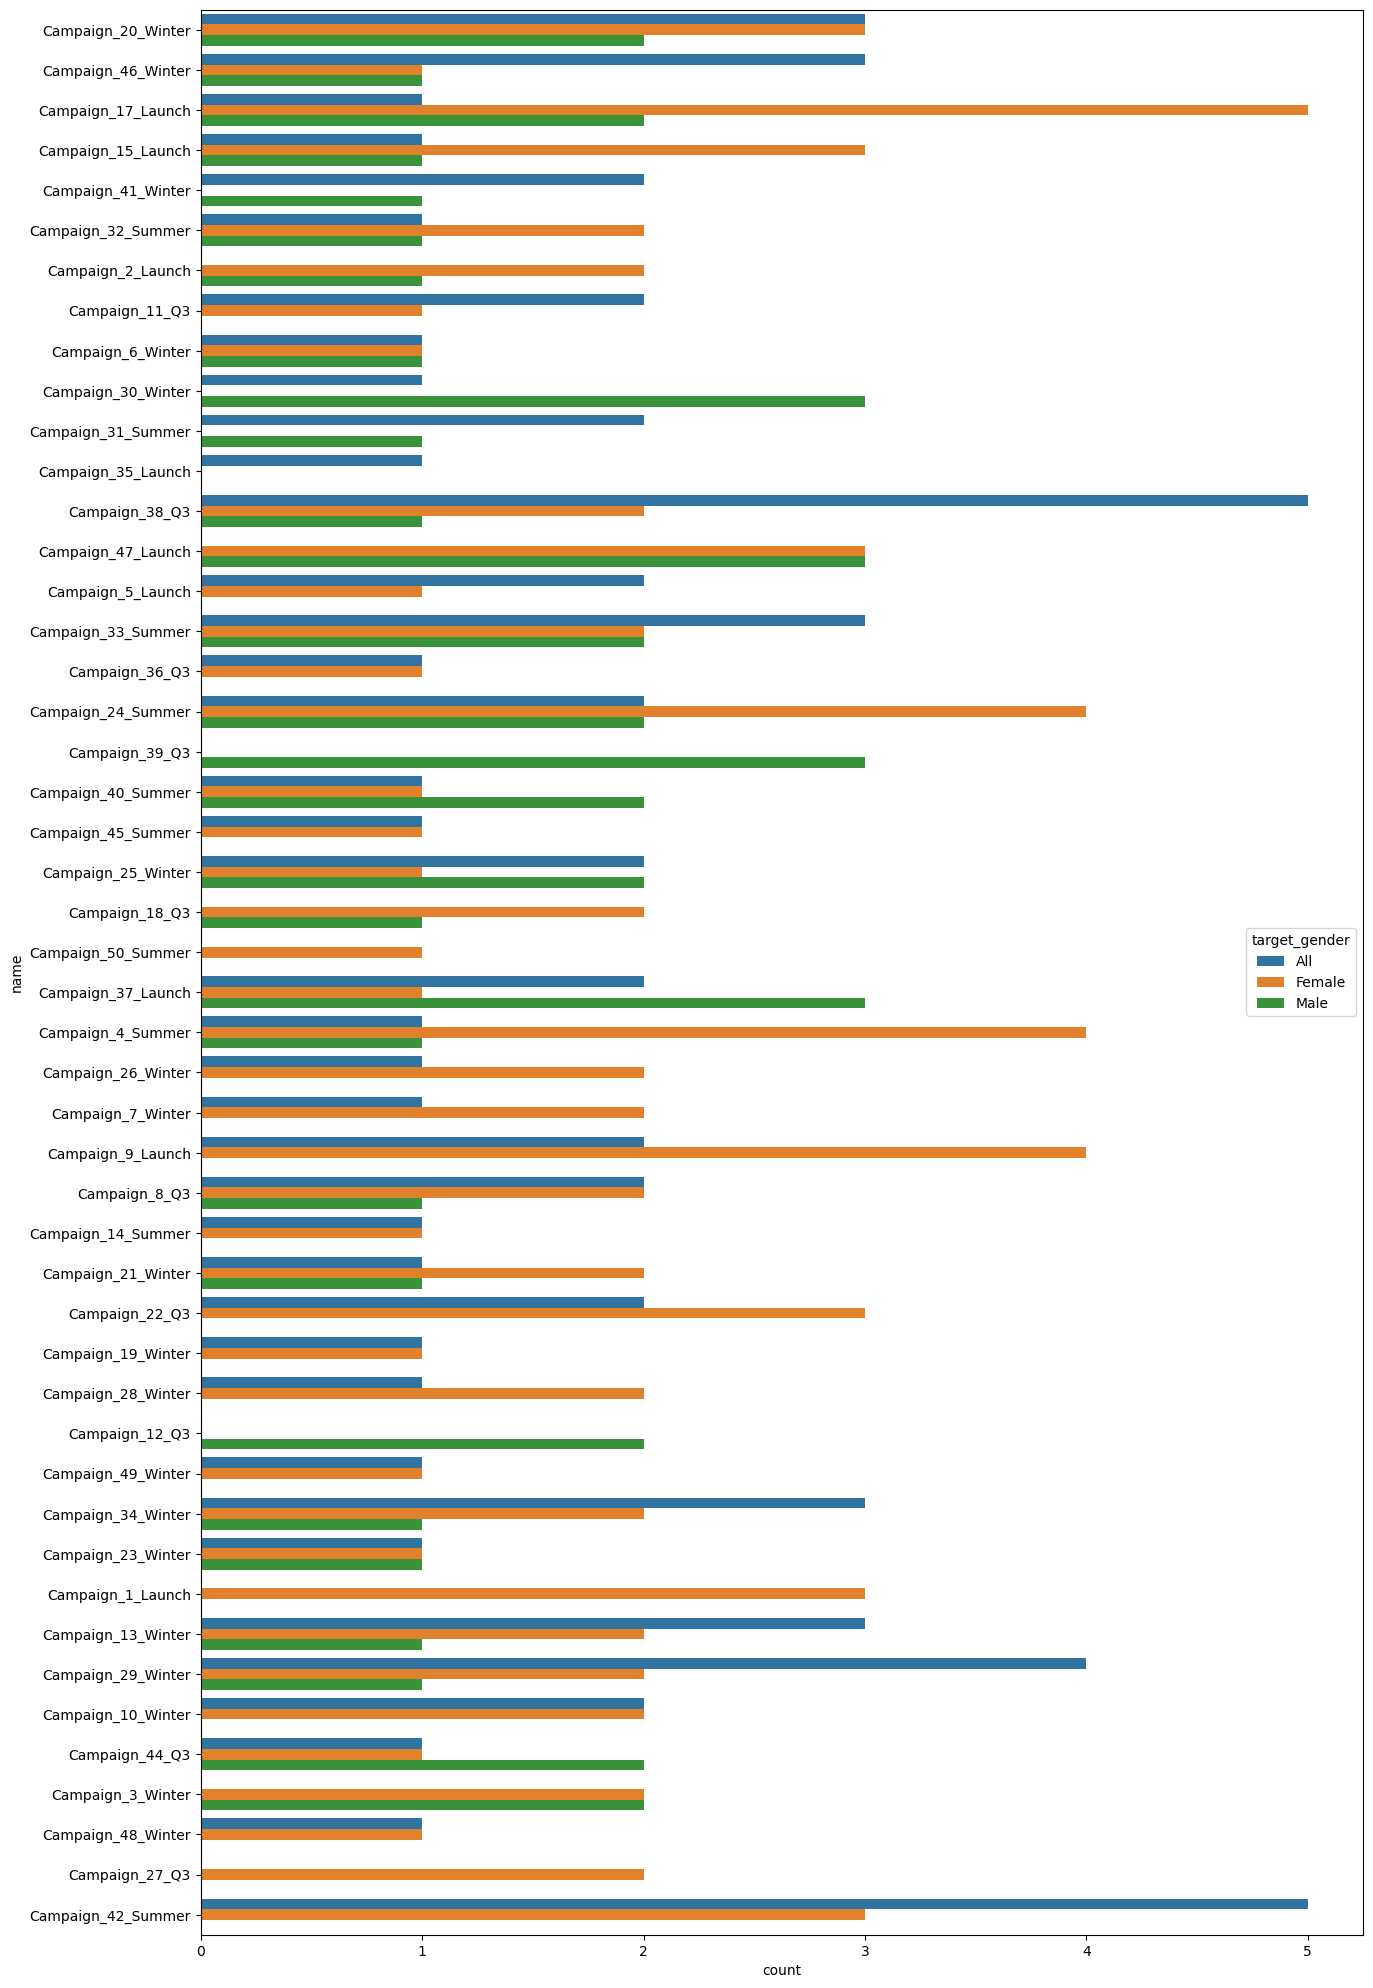

In [95]:
plt.figure(figsize=(15,25))
sns.countplot(data=df_total_budget,y="name",hue="target_gender");

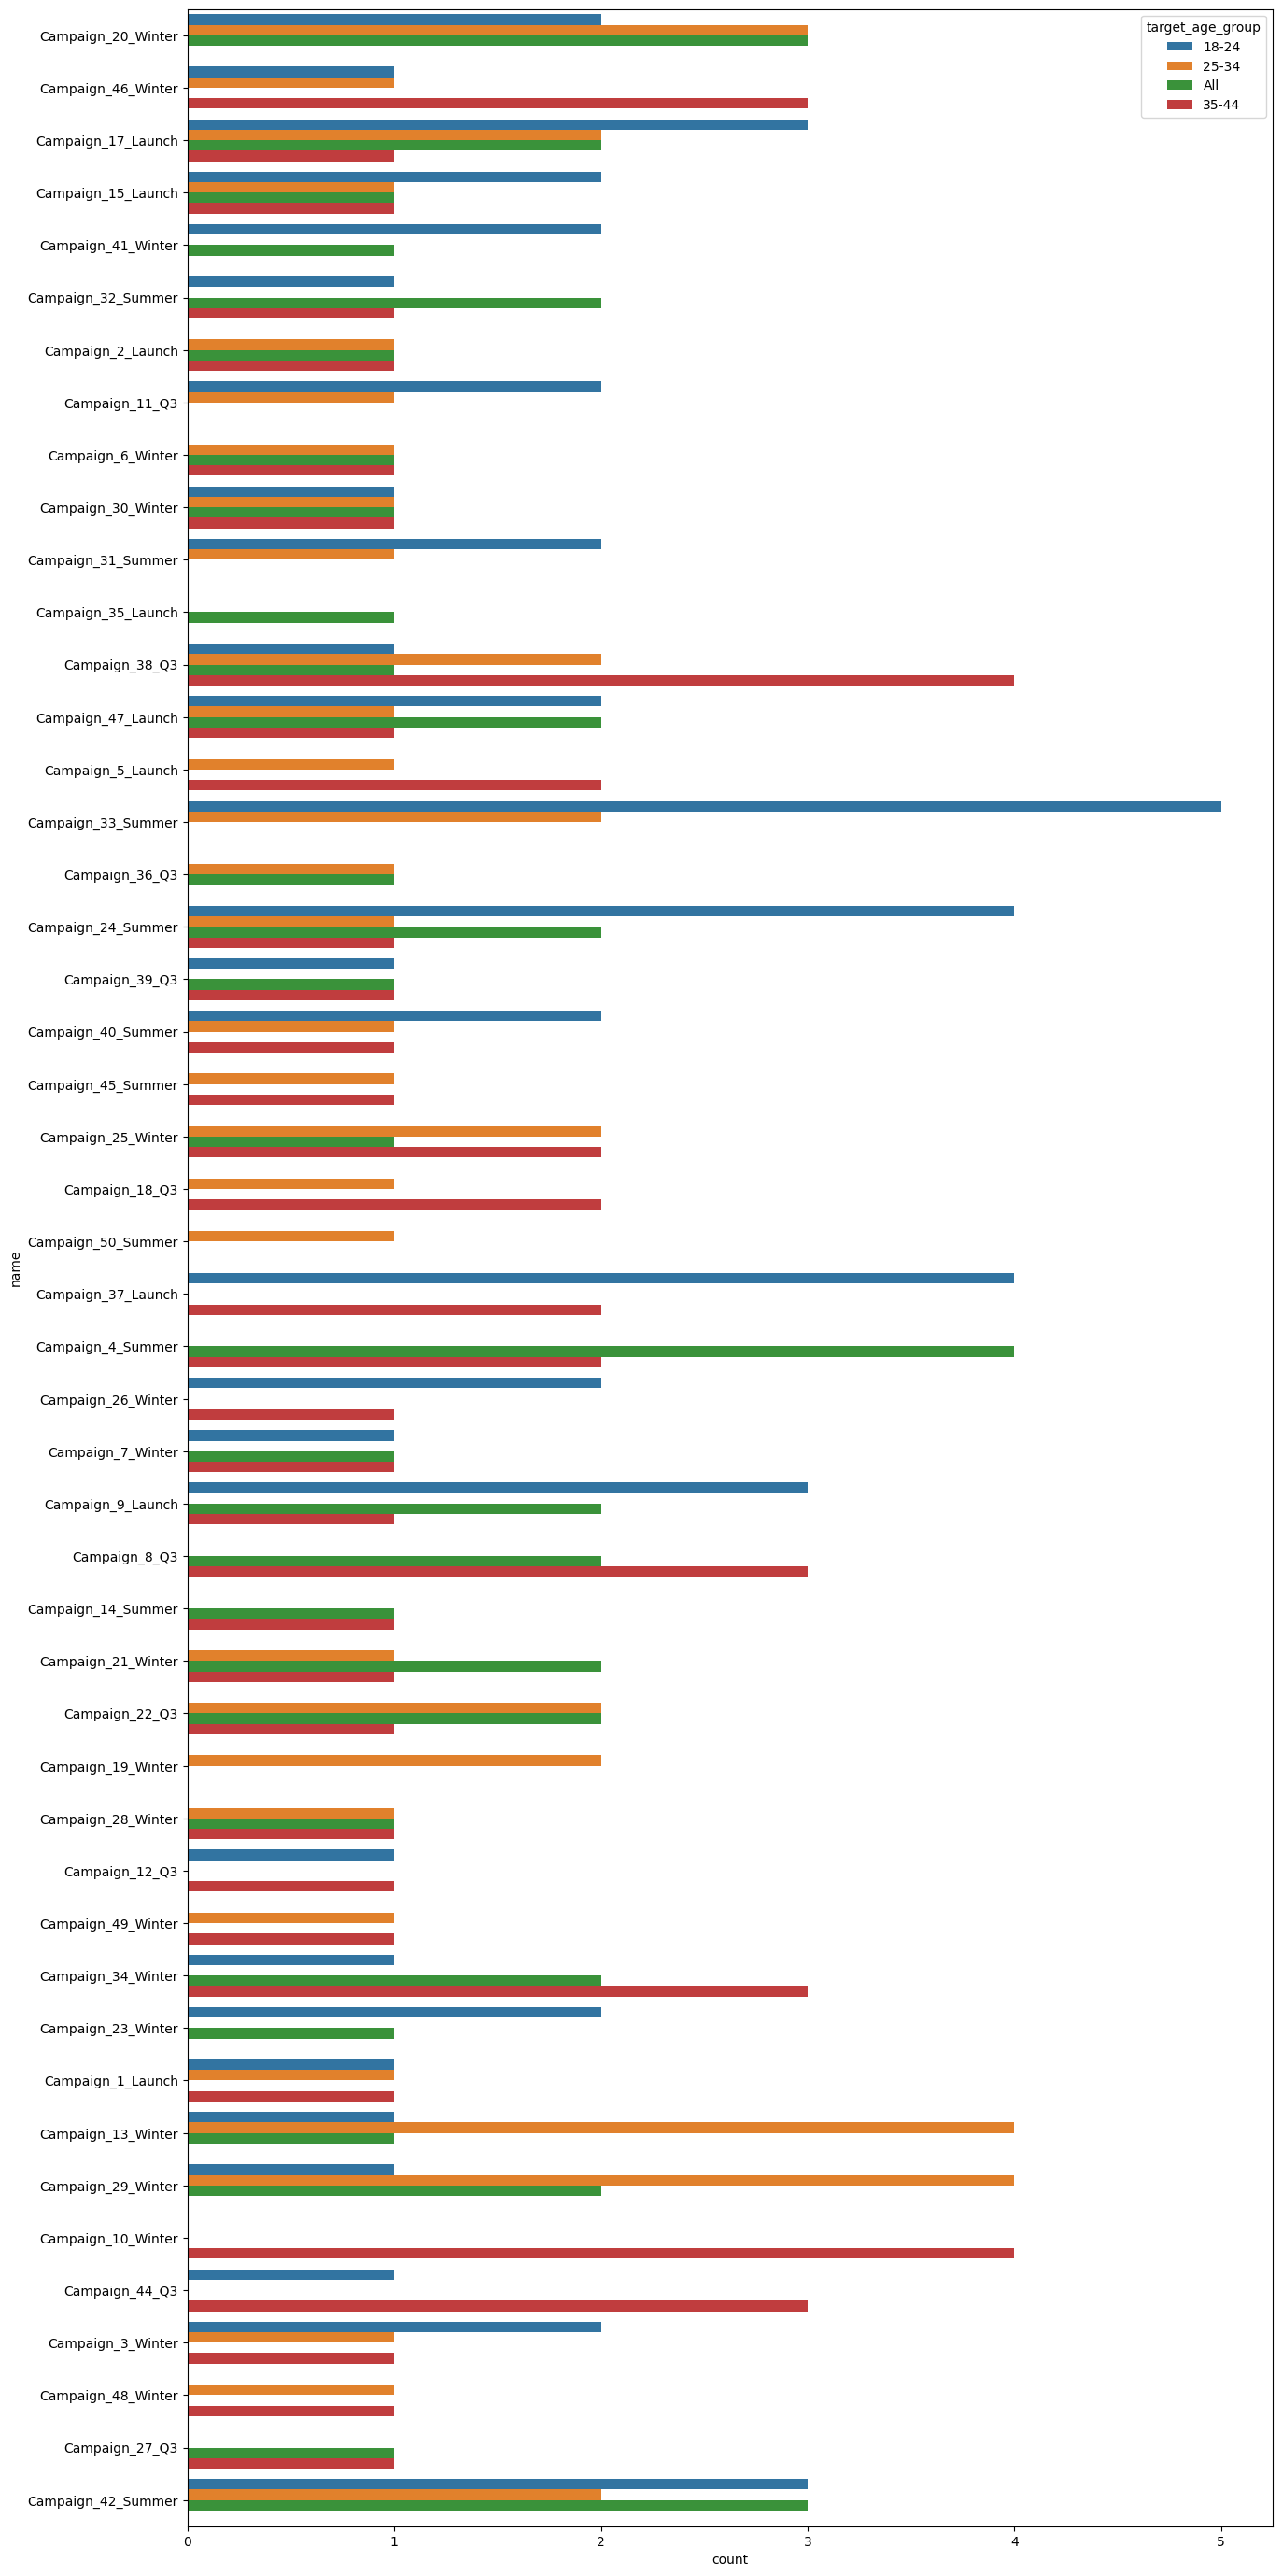

In [96]:
plt.figure(figsize=(15,35))
sns.countplot(data=df_total_budget,y="name",hue="target_age_group");

In [97]:
gaming=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("gaming")]
news=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("news")]
tech=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("technology")]
fit=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("fitness")]
art=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("art")]
food=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("food")]
fashion=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("fashion")]
health=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("health")]
photo=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("photography")]
sports=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("sports")]
finance=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("finance")]
travel=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("travel")]
life=df_ads_campaign[df_ads_campaign["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  27
News:  23
Tech:  21
Fitness:  20
Art:  21
Food:  12
Fashion:  26
Health:  29
Photo:  22
Sports:  24
Finance:  28
Travel:  27
Life:  20


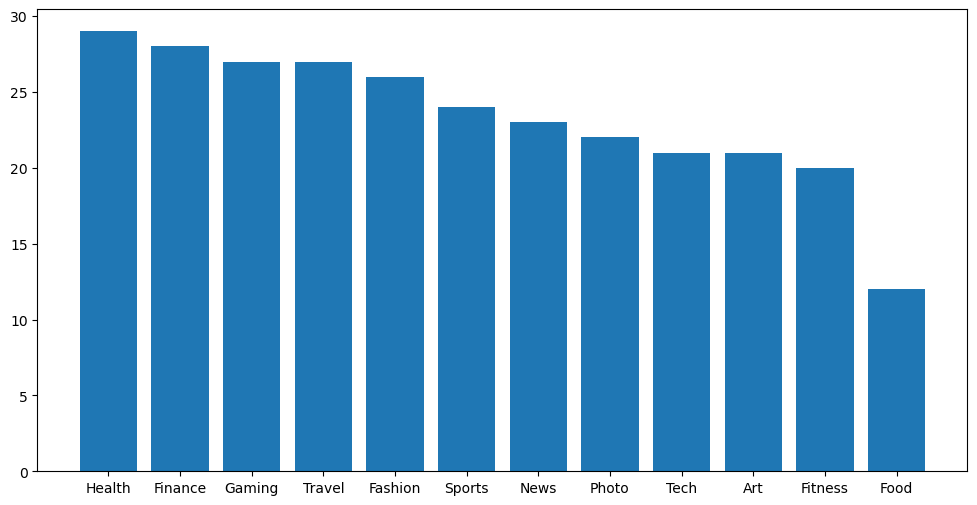

In [98]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

### MACHINE LEARNING

In [99]:
df_ads_campaign2=df_ads_campaign.copy()
df_ads_campaign2["number_of_ad"]=df_ads_campaign2.groupby(by="name")["name"].transform("count")

columnas = ["ad_platform","ad_type","target_gender","target_age_group","duration_days","number_of_ad"]
X= df_ads_campaign2[["ad_platform","ad_type","target_gender","target_age_group","duration_days","number_of_ad"]].copy()
le= LabelEncoder()
y= df_ads_campaign2["total_budget"]
columns = ["ad_platform","ad_type","target_gender","target_age_group"]
for cols in columns:
    X[cols] = le.fit_transform(X[cols])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
df_importance=pd.DataFrame({"Variables":columnas,"Value":model.feature_importances_}).sort_values(by="Value",ascending=False)
df_importance

,Variables,Value
4,duration_days,0.568696
5,number_of_ad,0.260605
3,target_age_group,0.057167
1,ad_type,0.042997
2,target_gender,0.042916
0,ad_platform,0.027620


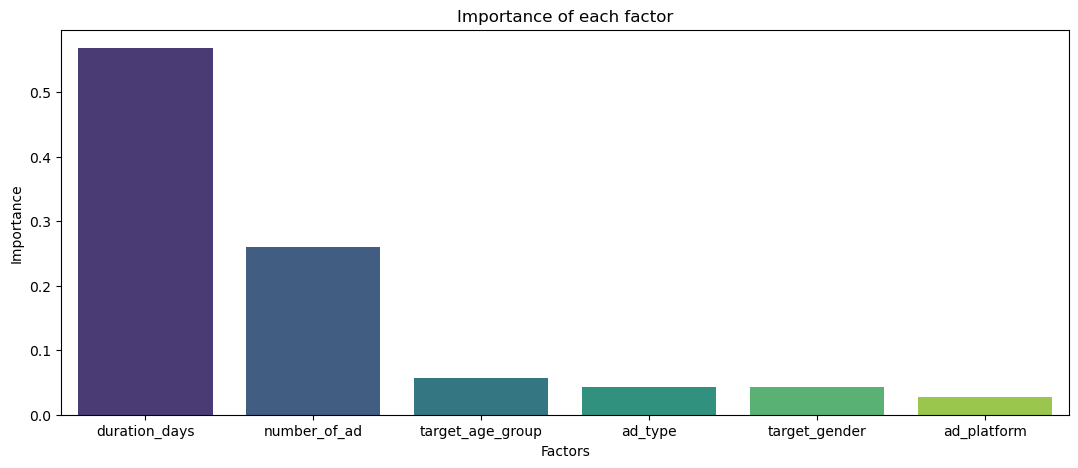

In [100]:
plt.figure(figsize=(13,5))
sns.barplot(data=df_importance,x="Variables",y="Value",hue="Variables",palette="viridis")
plt.xlabel("Factors")
plt.ylabel("Importance")
plt.title("Importance of each factor");

## SUMMARY TABLE ADS & CAMPAIGNS
**THIS TABLE SHOWS INFORMATION ON THE INFLUENCE OF DIFFERENT CAMPAIGNS ON THE DEVELOPMENT OF DIFFERENT ADS TARGETED AT DIFFERENT AUDIENCES. EXPLORATORY DATA ANALYSIS, MACHINE LEARNING MODELING, AND VARIOUS GRAPHS WERE APPLIED.**\
**df_ads_campaign:** *THE 3 MOST FREQUENTLY REPEATED CAMPAIGNS WERE 'Campaign_20_Winter', 'Campaign_24_Summer', AND 'Campaign_17_Launch'.*

## MULTIVARIABLE DATA ANALYSIS
**name vs ad_platform:** *In most campaigns, ad development on the Facebook platform predominated, but in some cases, development was similar between Instagram and Facebook, and in some cases, there were campaigns that only developed ads on Instagram. Among the campaigns that only developed ads on Instagram, we have 'Campaign_5_Launch', 'Campaign_36_Q3', 'Campaign_44_Q3', and 'Campaign_50_Summer'.*\
**name vs ad_type:** *The campaigns with the greatest presence ('Campaign_20_Winter', 'Campaign_24_Summer', and 'Campaign_17_Launch') had different interests in advertising formats. For example, in the case of 'Campaign_20_Winter'.*\
**ad_platform vs total_budget:** *It can be seen that the Instagram platform had a lower cost than Facebook, but this is not reliable since many factors must be taken into account. One of them is that there wasn't much difference in cost between these two platforms, even though Facebook was the platform where ads were most developed. Other factors include the number of ads, the target audience, etc.*\
**ad_type vs total_budget:** *THE GRAPHIC SHOWS THE MOST EXPENSIVE FORMATS. THE MOST EXPENSIVE WAS IMAGES, FOLLOWED BY CAROUSEL, VIDEO, AND FINALLY STORIES. SIMILAR TO THE 'ad_platform vs total_budget' GRAPHIC, THIS GRAPHIC DOES NOT DETERMINE THAT THE AD FORMAT IS THE FACTOR THAT INCREASES AD COSTS, AS THERE ARE MANY FACTORS INVOLVED.*\
**target_group vs total_budget:** *The graph shows that the 18-24 age range was the most expensive to produce, followed by the general public (ALL), 25-34 years, and finally 35-44 years. As with the other graphs, this one does not definitively show that the age range was the cause of the high costs, as there are many factors involved.*\
**target_gender vs total_budget:** *THE GRAPH SHOWS THE COST OF CREATING ADS TARGETED AT DIFFERENT GENDERS. THE GRAPH SHOWS THAT ADS TARGETED AT MEN WERE THE MOST EXPENSIVE, FOLLOWED BY ADS FOR A GENERAL AUDIENCE, AND FINALLY ADS TARGETED AT WOMEN. LIKE THE OTHER GRAPHS, THIS ONE DOES NOT DETERMINE THAT GENDERS WERE THE CAUSE OF THE HIGH COSTS, AS THERE ARE MANY FACTORS INVOLVED.*\
**ad_type vs ad_platform vs total_budget:** *THE GRAPHIC SHOWS THE COSTS OF EACH FORMAT ON EACH PLATFORM. VIDEO WAS MORE EXPENSIVE ON INSTAGRAM THAN ON FACEBOOK. STORIES WERE MORE EXPENSIVE ON FACEBOOK THAN ON INSTAGRAM. CAROUSEL WAS MORE EXPENSIVE ON INSTAGRAM THAN ON FACEBOOK. AND FINALLY, IMAGE WAS MORE EXPENSIVE ON FACEBOOK THAN ON INSTAGRAM.*\
**name vs target_gender:** *The graph shows companies with the highest to lowest costs in descending order. It can be observed that there is no relationship between high costs and the target audience for the ads. In some cases, they were developed for both sexes and the general public, and in other cases, only for women or the general public, but there is no clear indication that gender influenced the price in this graph.*\
**name vs target_age_group:** *There is no clear relationship between the high cost and the age range for which the ad was developed.*\
**target_interests:** *THE GRAPHIC SHOWS THE ADVERTISEMENTS THAT WERE DEVELOPED BASED ON DIFFERENT INTERESTS. THE MOST DEVELOPED ADVERTISEMENTS WERE RELATED TO HEALTH, FINANCE, GAMES, TRAVEL, ETC.*\
## MACHINE LEARNING
**A random forest regression was applied to determine the factors that influenced the campaign prices. The most influential factors are shown below:**\
**duration_days:** *THE MOST INFLUENTIAL FACTOR IS THE DURATION OF EACH CAMPAIGN, EXPRESSED IN DAYS, WITH A 56% INFLUENCE COMPARED TO THE OTHER FACTORS.*\
**number_of_ad:** *THE SECOND MOST IMPORTANT FACTOR IS THE NUMBER OF ADVERTISEMENTS EACH COMPANY MADE, WITH A 26% INFLUENCE COMPARED TO THE OTHER FACTORS.*\
**target_group:** *In third place, with an influence of only 5%, is age range. This and the other factors had very little impact on the cost of the campaigns.*\
**Based on this information, it can be considered that the most influential factors affecting the total cost for each company in developing advertisements were the duration in days and the number of advertisements developed by each company.**

## TABLA USERS & EVENTS

In [101]:
df_users_events=pd.merge(df_ad_events,df_users[["user_id","user_gender","user_age","age_group","country","location","interests"]],on="user_id",how="left")
df_users_events

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,user_gender,user_age,age_group,country,location,interests
0,312834,49,d75a9,2025-06-23 08:53:09,Monday,Morning,Impression,Male,42,35-44,India,Lake Joelberg,"sports, art, fitness"
1,293696,185,0023e,2025-08-01 23:33:29,Friday,Evening,Impression,Female,35,35-44,India,South Lauren,"lifestyle, fitness, health"
2,371590,12,f49e6,2025-05-20 06:38:48,Tuesday,Morning,Impression,Female,25,25-34,United States,Haydenberg,"fitness, sports, finance"
3,384253,109,1eefe,2025-06-19 07:14:57,Thursday,Morning,Click,Male,20,18-24,Japan,East Shaneberg,"fashion, gaming, photography"
4,183939,35,540bb,2025-07-22 01:11:22,Tuesday,Night,Impression,Male,25,25-34,United States,East Chad,"finance, photography, health"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40373,119599,145,33df1,2025-07-30 23:59:56,Wednesday,Evening,Impression,Female,35,35-44,United Kingdom,Port Nathan,"food, travel"
40374,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression,Female,22,18-24,Mexico,Paulport,"travel, health"
40375,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression,Male,44,35-44,Brazil,New Jay,"food, health, lifestyle"
40376,213903,106,0078e,2025-05-10 21:51:23,Saturday,Evening,Impression,Male,25,25-34,India,Wilsontown,"technology, art"


In [103]:
df_users_events_dict=df_users_events.sample(n=1000,random_state=42)
df_users_events_dict=df_users_events_dict.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_users_events_dict})
display(Markdown(response.content))

This dataset captures various events related to user interactions with advertisements. Each entry represents a single event and includes details about the ad, the user, and the temporal context of the interaction.

### Dataset Explanation:

*   **`event_id`**: A unique identifier for each recorded event.
*   **`ad_id`**: A unique identifier for the specific advertisement involved in the event.
*   **`user_id`**: A unique identifier for the user who performed the action.
*   **`timestamp`**: The exact date and time when the event occurred.
*   **`day_of_week`**: The day of the week (e.g., 'Monday', 'Tuesday') when the event happened.
*   **`time_of_day`**: A categorical representation of the time of day (e.g., 'Morning', 'Afternoon', 'Evening', 'Night').
*   **`event_type`**: The type of interaction the user had with the ad. This is a crucial metric, indicating different stages of engagement: 'Impression' (ad was shown), 'Click' (ad was clicked), 'Like' (ad was liked), 'Comment' (user commented on ad), 'Purchase' (user made a purchase related to the ad).
*   **`user_gender`**: The gender of the user ('Male', 'Female', 'Other').
*   **`user_age`**: The numerical age of the user.
*   **`age_group`**: A categorical grouping of user ages (e.g., '18-24', '25-34').
*   **`country`**: The country where the user is located.
*   **`location`**: A more specific geographical location (city/town) of the user.
*   **`interests`**: A comma-separated string listing the user's interests.

### How to Analyze It:

The goal of this analysis is likely to understand ad performance, user engagement patterns, and demographic influences.

#### Key Operations:

1.  **Data Cleaning & Preprocessing**:
    *   Convert `timestamp` to datetime objects (if not already).
    *   Split the `interests` string into individual interests for easier analysis (e.g., one-hot encoding or creating a list of interests per user).
    *   Handle potential missing values or inconsistencies (though not apparent in this sample).

2.  **Descriptive Statistics**:
    *   Count occurrences of each `event_type` to understand overall engagement.
    *   Analyze distributions of `user_gender`, `age_group`, `country`, `day_of_week`, `time_of_day`.
    *   Identify the most common `interests`.

3.  **Performance Metrics Calculation**:
    *   **Click-Through Rate (CTR)**: `(Clicks / Impressions) * 100`
    *   **Like Rate**: `(Likes / Impressions) * 100` (or `Likes / Clicks` for post-click engagement)
    *   **Comment Rate**: `(Comments / Impressions) * 100` (or `Comments / Clicks`)
    *   **Purchase Rate (Conversion Rate)**: `(Purchases / Impressions) * 100` (or `Purchases / Clicks`)
    *   Calculate these rates globally and then segment by various dimensions.

4.  **Segmentation and Grouping**:
    *   Group data by `ad_id` to evaluate individual ad performance.
    *   Group by `user_id` to understand individual user behavior (e.g., number of ads seen, conversion path).
    *   Group by demographic features (`user_gender`, `age_group`, `country`, `location`) to identify target audiences.
    *   Group by temporal features (`day_of_week`, `time_of_day`) to find optimal ad scheduling.
    *   Group by individual `interests` (after splitting) to understand content preferences.

#### Useful Graphs:

1.  **Overall Performance**:
    *   **Bar Chart**: Distribution of `event_type` (e.g., total impressions, clicks, likes, comments, purchases).
    *   **Funnel Chart**: To visualize the conversion path from Impression to Purchase.

2.  **Ad Performance**:
    *   **Bar Charts**: Top N `ad_id`s by Clicks, Likes, or Purchases.
    *   **Heatmap**: `ad_id` vs. `event_type` rates (e.g., CTR, Purchase Rate per ad).

3.  **Demographic Analysis**:
    *   **Bar Charts**: `event_type` rates (CTR, Purchase Rate) segmented by `user_gender`, `age_group`, `country`.
    *   **Pie Chart**: Distribution of `user_gender` or `age_group`.
    *   **Histogram**: Distribution of `user_age`.

4.  **Temporal Analysis**:
    *   **Line Charts**: `event_type` counts or rates over `day_of_week` or `time_of_day` to identify peak engagement times.
    *   **Stacked Bar Charts**: `event_type` distribution segmented by `day_of_week` or `time_of_day`.

5.  **Interests Analysis**:
    *   **Bar Charts**: Top N `interests` associated with higher `Click` or `Purchase` rates.
    *   **Word Cloud**: For a visual representation of frequent `interests`.

### Professional Perspective & Recommendations:

*   **Focus on the Conversion Funnel**: The `event_type` field is critical. Analyze the drop-off rates at each stage (Impression -> Click -> Like/Comment -> Purchase) to identify bottlenecks.
*   **Identify High-Value Segments**: Pinpoint which `age_group`, `gender`, `country`, `location`, or `interests` yield the highest conversion rates. This informs targeted marketing strategies.
*   **Optimize Ad Content and Placement**: Understand which `ad_id`s perform best and why (e.g., what interests they appeal to, what demographics they resonate with). Use temporal insights to schedule ads when users are most receptive.
*   **Personalization Opportunities**: By analyzing `user_id` and `interests`, you can infer user preferences and recommend ads more effectively in the future.
*   **A/B Testing Foundation**: This dataset provides a baseline to formulate hypotheses for A/B tests (e.g., testing different ad creatives for specific age groups or interests).
*   **Anomaly Detection**: Look for unusual spikes or drops in event types that might indicate issues with ads or campaigns.

## EXPLORATORY DATA ANALYSIS (EDA)

In [104]:
print(df_users_events["user_gender"].value_counts())
print("")
print(df_users_events["age_group"].value_counts())
print("")
print(df_users_events["country"].value_counts())
print("")
print(df_users_events["user_age"].value_counts().head(5))

user_gender
Male      22602
Female    13673
Other      4103
Name: count, dtype: int64

age_group
25-34    16743
18-24    12653
35-44     5842
16-17     3569
45-54     1261
55-65      310
Name: count, dtype: int64

country
United States     12074
United Kingdom     6183
Canada             4085
India              3737
Germany            3362
Australia          2862
Brazil             2494
Mexico             2113
Japan              1922
France             1546
Name: count, dtype: int64

user_age
16    2511
26    2039
27    2033
23    1997
24    1996
Name: count, dtype: int64


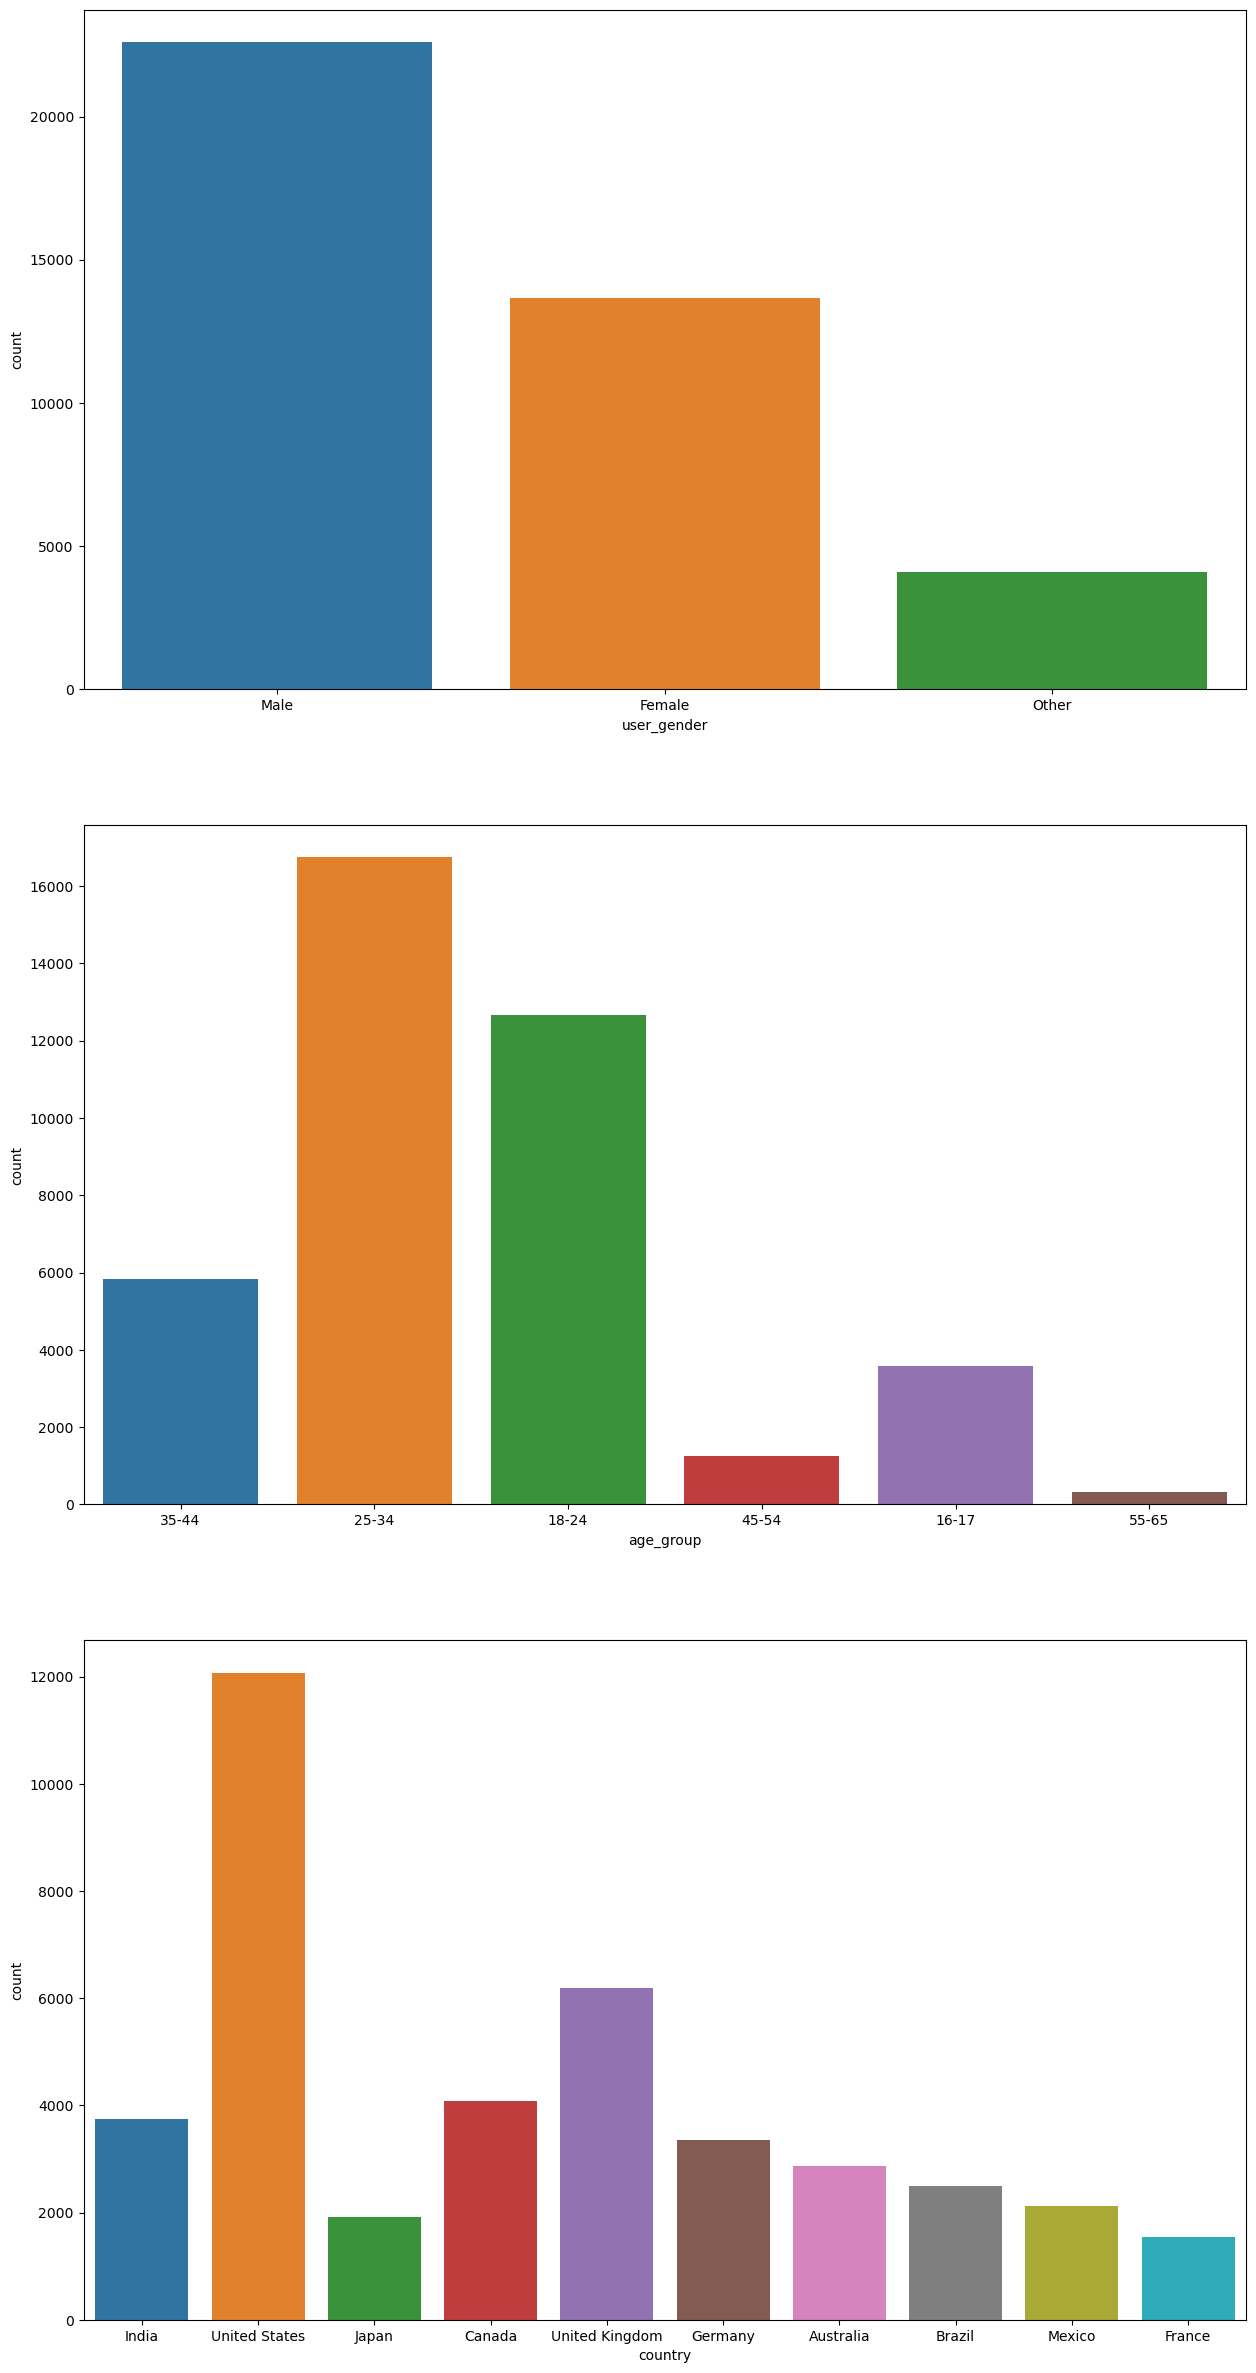

In [105]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_users_events,x="user_gender",hue="user_gender",ax=ax1)
sns.countplot(data=df_users_events,x="age_group",hue="age_group",ax=ax2)
sns.countplot(data=df_users_events,x="country",hue="country",ax=ax3);

### INTERESES EN GENERAL

In [106]:
gaming=df_users_events[df_users_events["interests"].str.contains("gaming")]
news=df_users_events[df_users_events["interests"].str.contains("news")]
tech=df_users_events[df_users_events["interests"].str.contains("technology")]
fit=df_users_events[df_users_events["interests"].str.contains("fitness")]
art=df_users_events[df_users_events["interests"].str.contains("art")]
food=df_users_events[df_users_events["interests"].str.contains("food")]
fashion=df_users_events[df_users_events["interests"].str.contains("fashion")]
health=df_users_events[df_users_events["interests"].str.contains("health")]
photo=df_users_events[df_users_events["interests"].str.contains("photography")]
sports=df_users_events[df_users_events["interests"].str.contains("sports")]
finance=df_users_events[df_users_events["interests"].str.contains("finance")]
travel=df_users_events[df_users_events["interests"].str.contains("travel")]
life=df_users_events[df_users_events["interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  6269
News:  6042
Tech:  6382
Fitness:  6397
Art:  6340
Food:  6006
Fashion:  6190
Health:  6143
Photo:  6019
Sports:  6098
Finance:  5865
Travel:  6310
Life:  6402


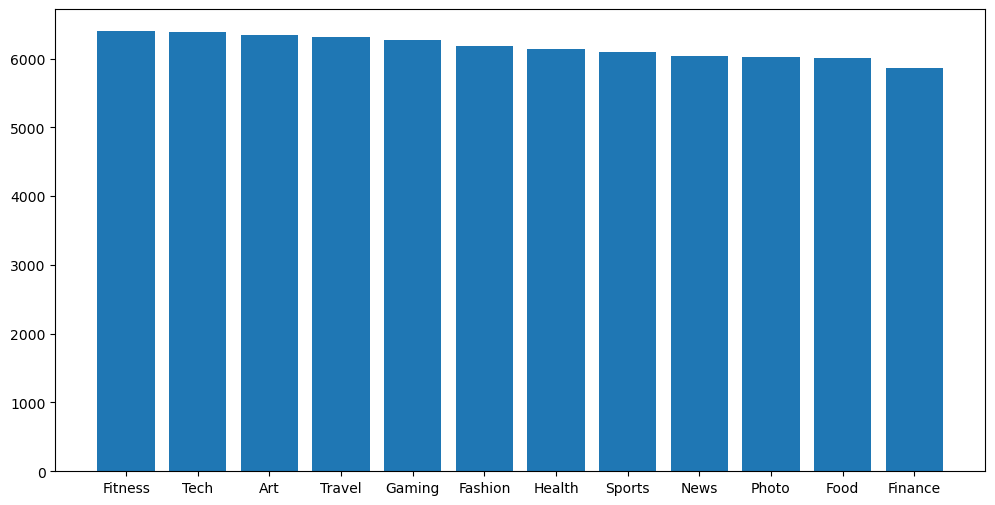

In [107]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

## MULTIVARIABLE DATA ANALYSIS

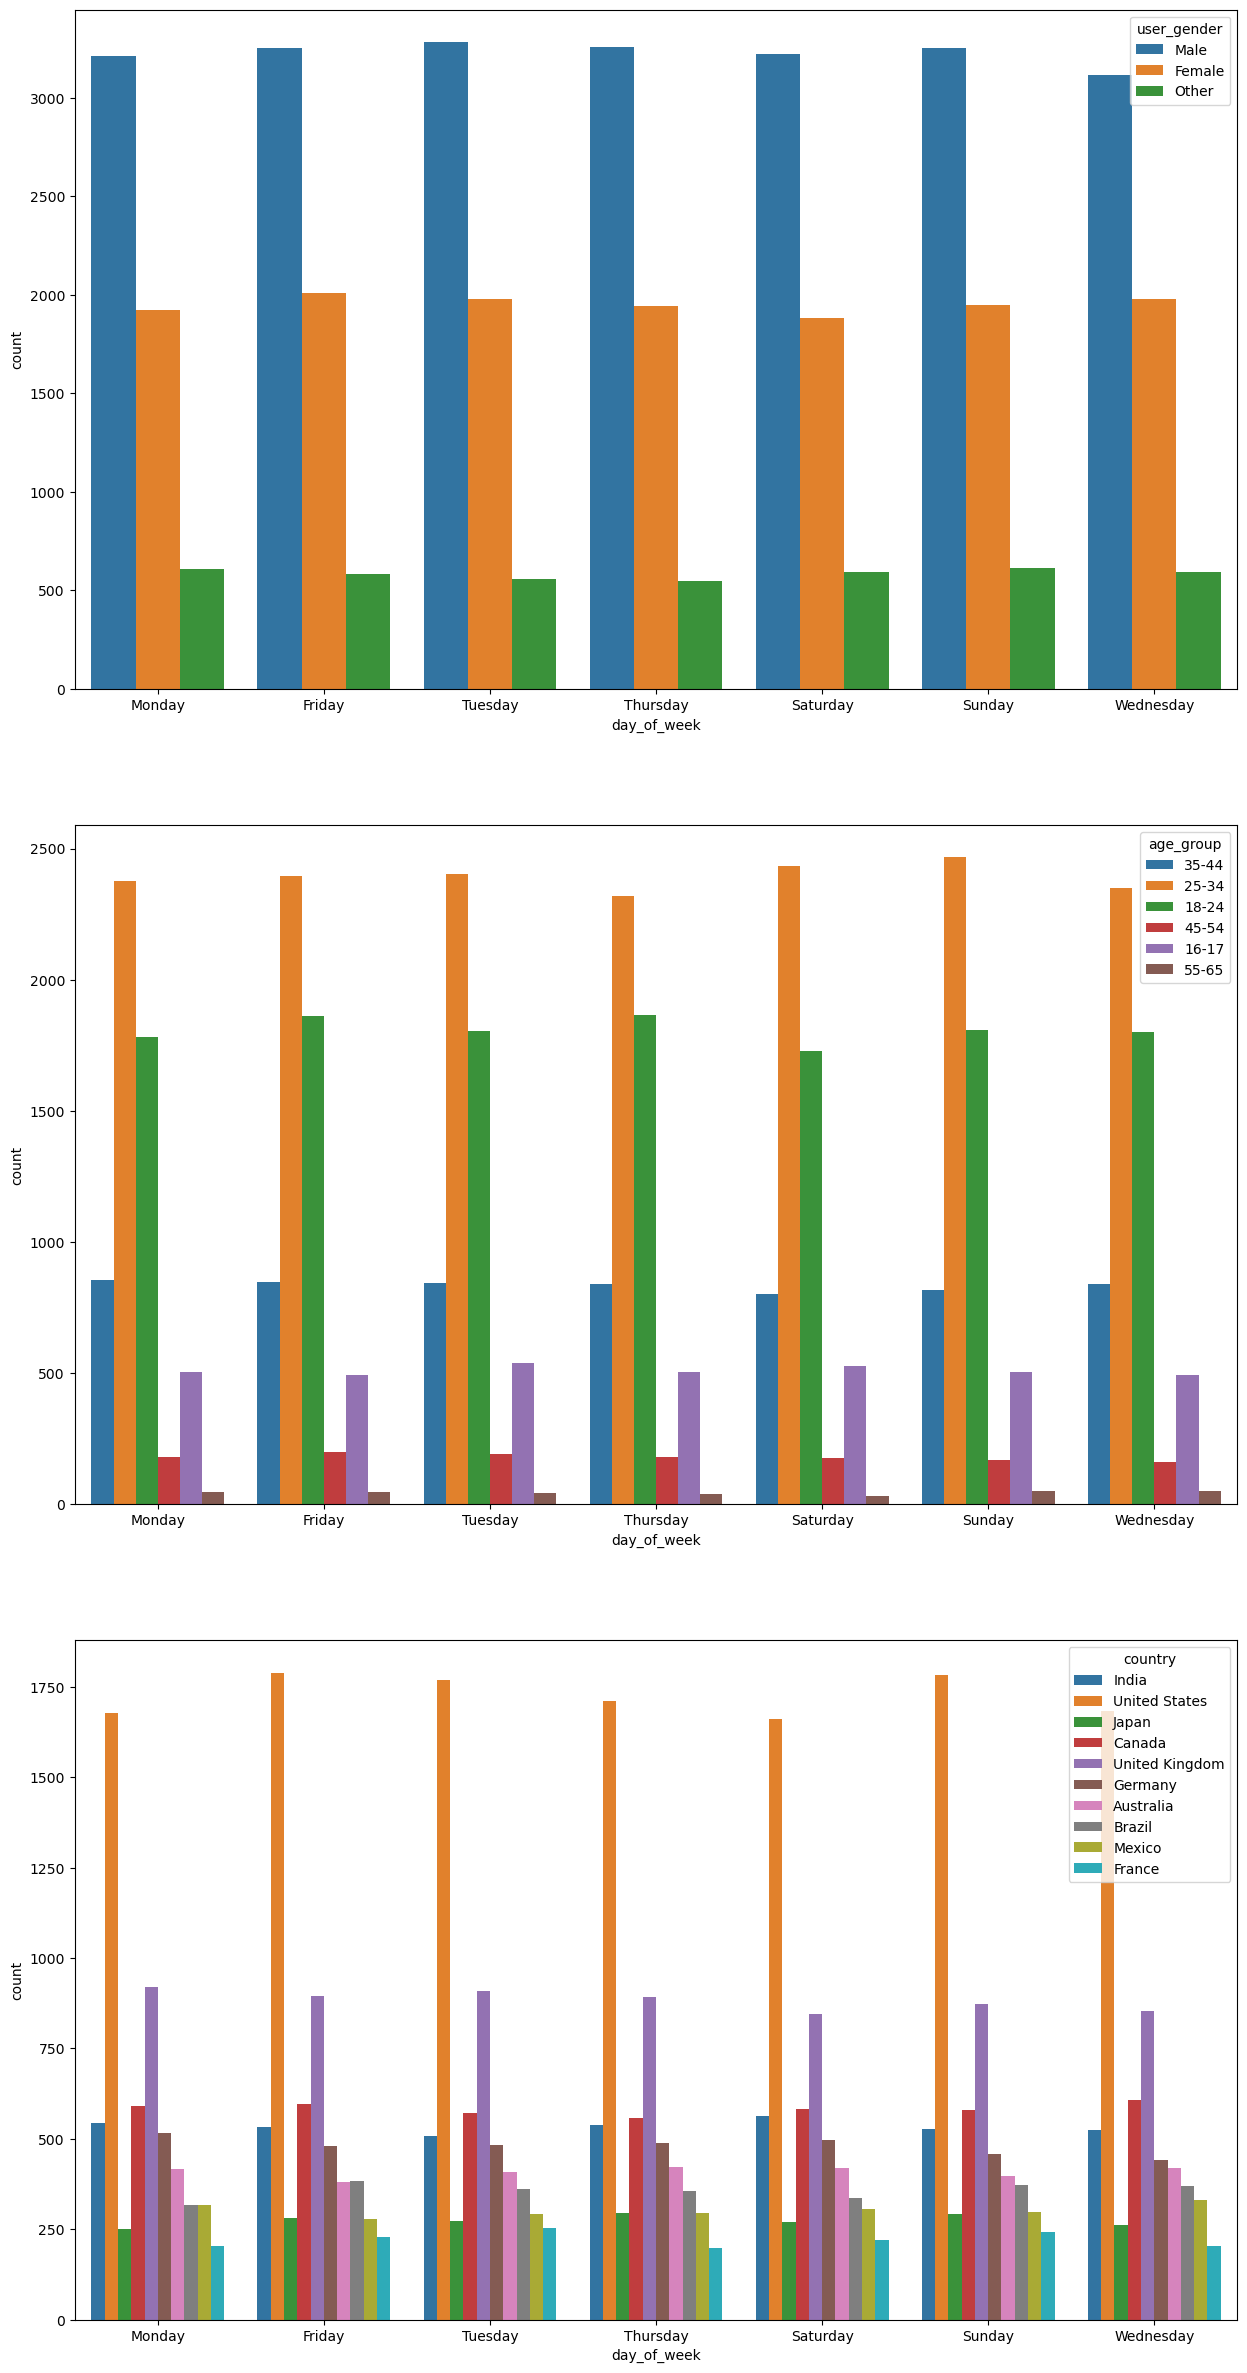

In [109]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_users_events,x="day_of_week",hue="user_gender",ax=ax1)
sns.countplot(data=df_users_events,x="day_of_week",hue="age_group",ax=ax2)
sns.countplot(data=df_users_events,x="day_of_week",hue="country",ax=ax3);

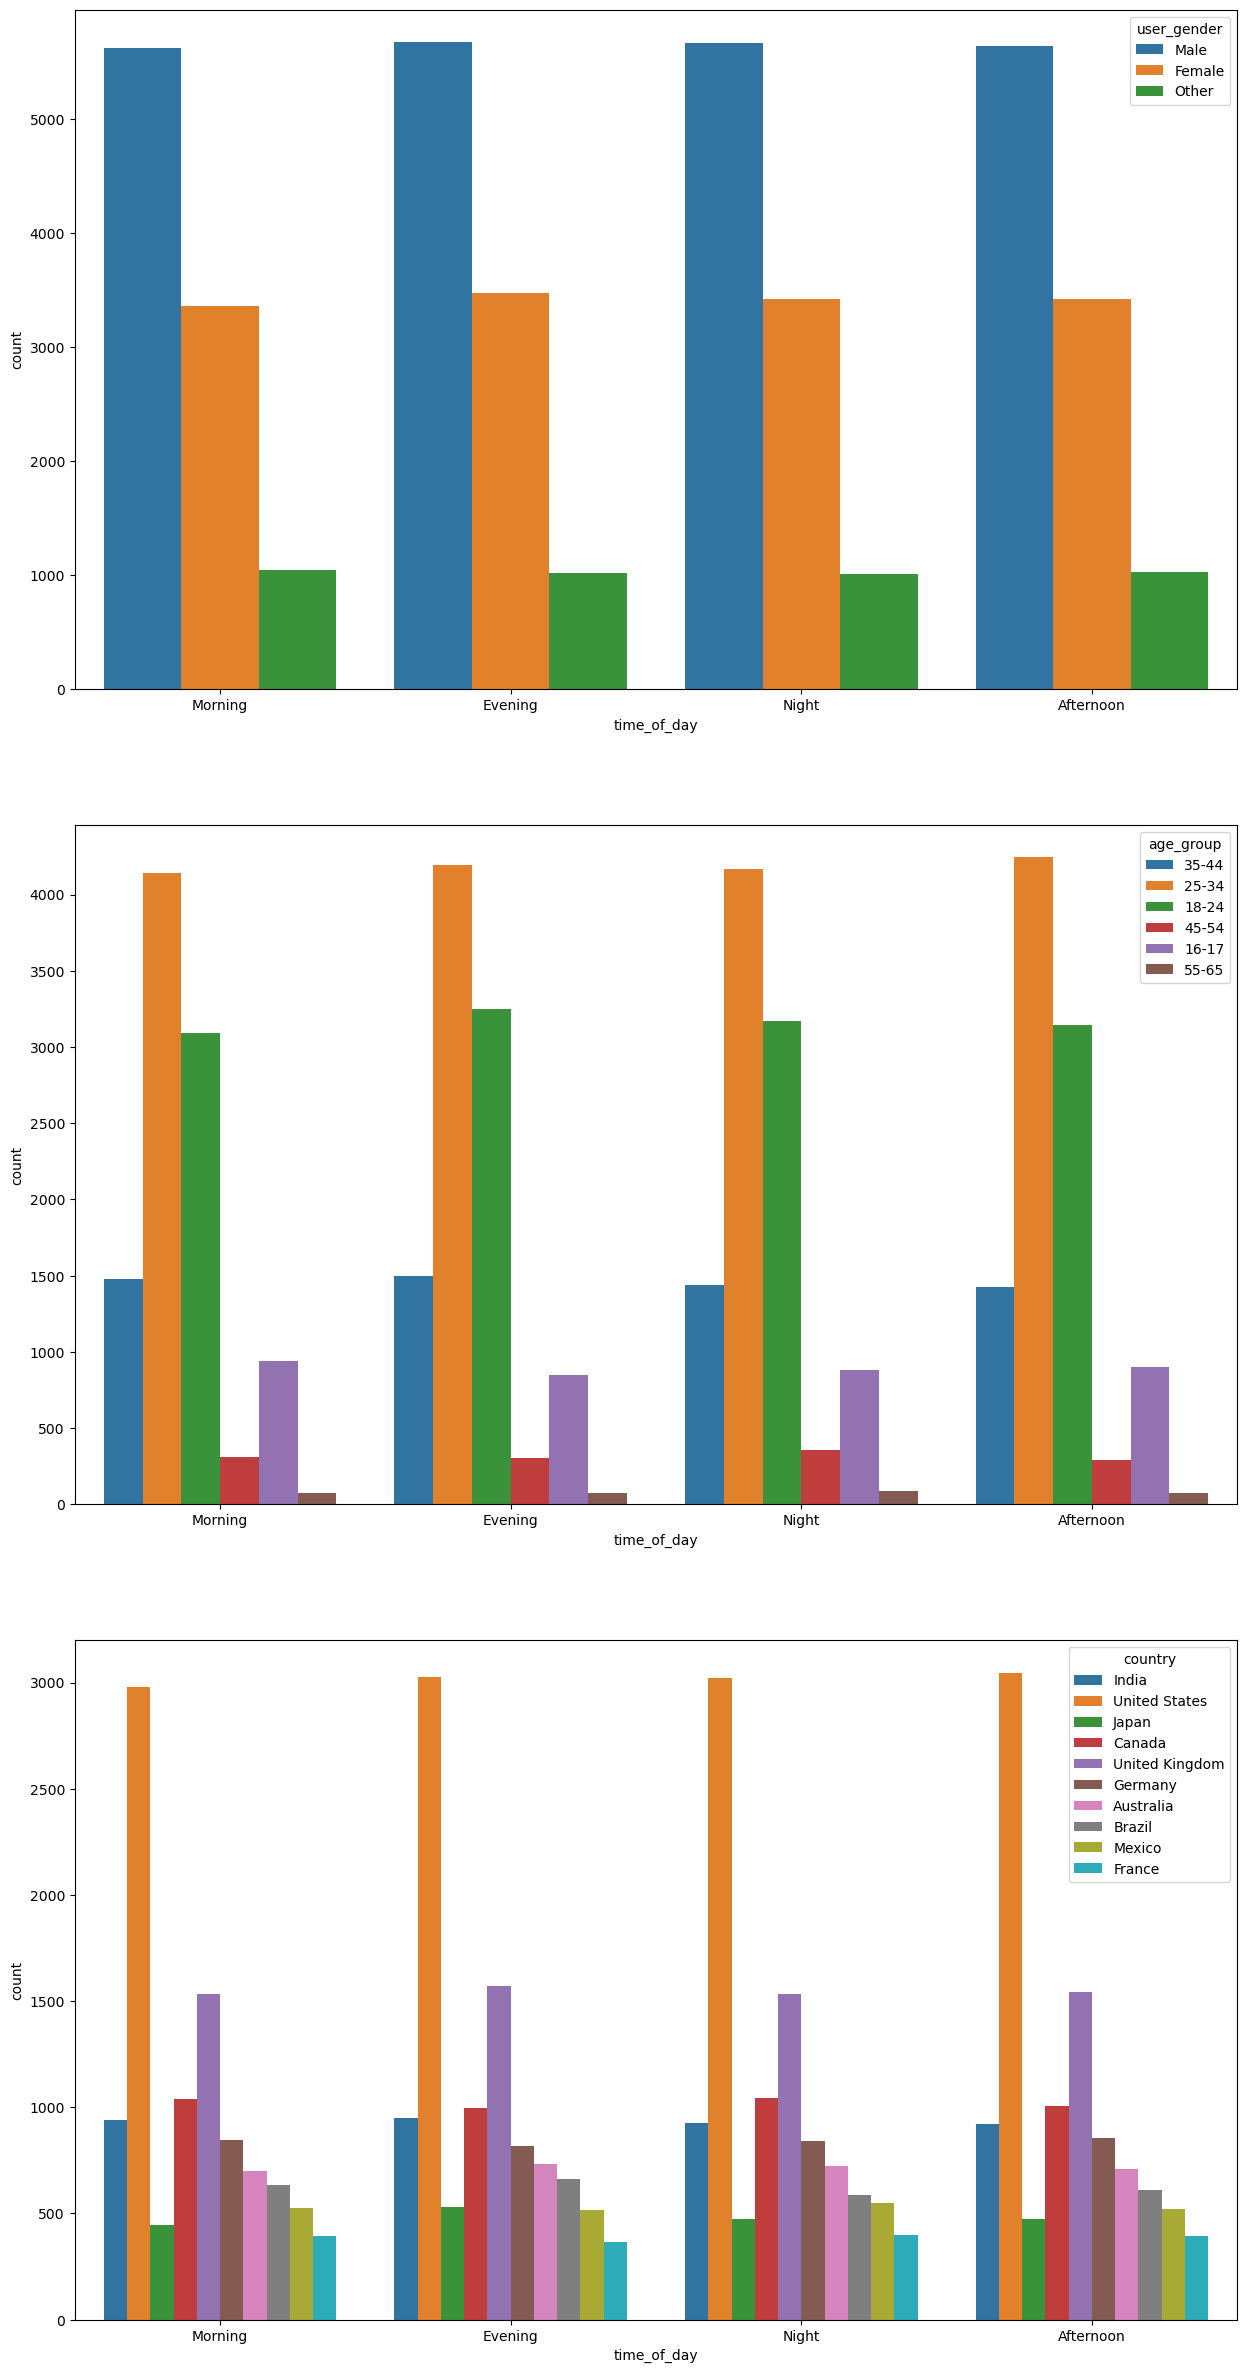

In [110]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_users_events,x="time_of_day",hue="user_gender",ax=ax1)
sns.countplot(data=df_users_events,x="time_of_day",hue="age_group",ax=ax2)
sns.countplot(data=df_users_events,x="time_of_day",hue="country",ax=ax3);

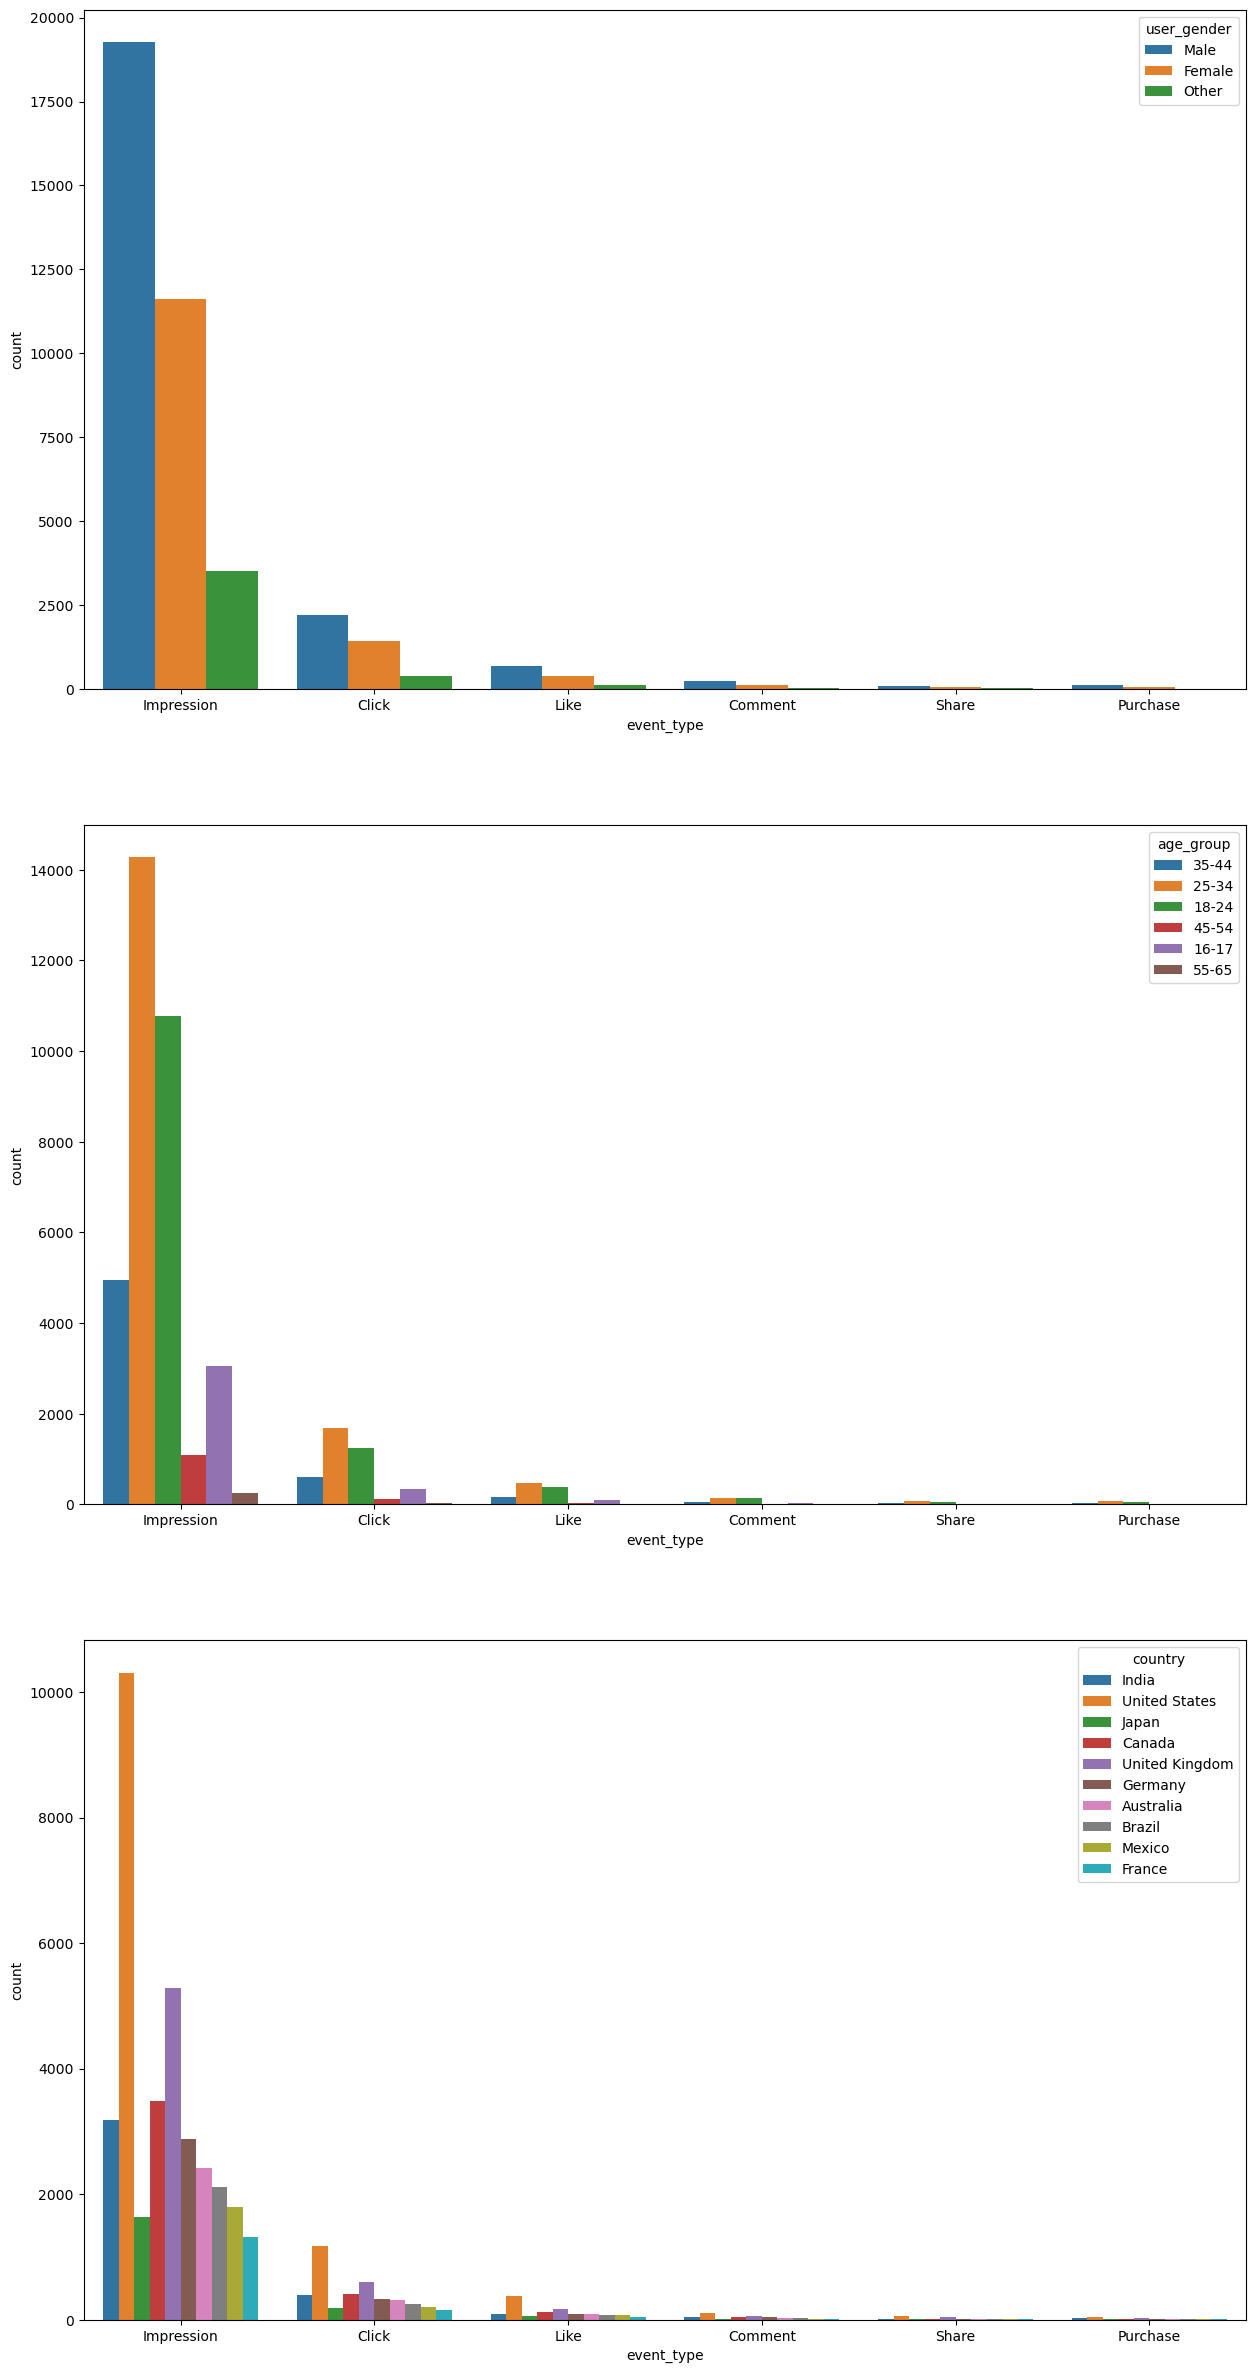

In [111]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_users_events,x="event_type",hue="user_gender",ax=ax1)
sns.countplot(data=df_users_events,x="event_type",hue="age_group",ax=ax2)
sns.countplot(data=df_users_events,x="event_type",hue="country",ax=ax3);

## USERS-EVENTS TABLE SUMMARY
**This table provides information on how users reacted to different types of ads and their preferences. The dataset describes each user with information such as country of origin, gender, age, and interests. This indicates that this dataset focuses more on the user and how the aforementioned factors affect their reaction to the ad.**\
**user_gender:** *The gender that interacted most with the ads was men, followed by women, and lastly, gender not defined.*\
**age_group:** *The age range of the users who participated the most was 25-34 years, followed by 18-24 years, 35-44 years, 16-17 years, 45-54 years and finally 55-65 years.*\
**country:** *The country with the highest user participation was the United States, followed by the United Kingdom, Canada, India, Germany, Australia, Brazil, Mexico, Japan, and finally France.*\
**user_age:** *The age of the users who participated the most was 16 years old, followed by 24 years old, 23 years old, etc.*
### USER INTERESTS
**The top interest was fitness, followed by travel, gaming, technology, etc.**
## MULTIVARIABLE DATA ANALYSIS
**day_of_week vs user_gender:** *HOW EACH SEX INTERACTS ON DIFFERENT DAYS OF THE WEEK. ON ALL DAYS, THE MALE INTERACTED THE MOST, FOLLOWED BY THE FEMALE, AND FINALLY, THE UNDEFINED SEX.*\
**day_of_week vs age_group:** *HOW USERS OF DIFFERENT AGES INTERACTED WITH THE DIFFERENT ADS. ON EVERY DAY, THE AGE RANGE THAT INTERACTED THE MOST WAS 25-34 YEARS, FOLLOWED BY 18-24 YEARS, 35-44 YEARS, 16-17 YEARS, 45-54 YEARS, AND FINALLY 55-65 YEARS.*\
**day_of_week vs country:** *This chart shows how users from different countries participated on different days of the week. Overall, the United States and the United Kingdom had the highest participation every day. Canada and India tied for third place, with Canada being dominant except on Monday, when participation between India and Canada was very similar.*\
**time_of_day vs user gender:** *This graph shows the participation of each sex at different times of the day. We can see that at all times of the day, men had greater participation, followed by women, and finally, the undefined sex.*\
**time_of_day vs age_group:** *This graph shows user participation by age at different times of day. Users aged 25-34 participated the most throughout the day, followed by those aged 18-24, 35-44, etc.*\
**time_of_day vs country:** *This chart shows user participation from different countries. Users from the United States had the highest participation at all times of day, followed by the United Kingdom, Canada, India, etc.*\
**event_type vs user_gender:** *THIS GRAPHIC SHOWS THE TYPE OF REACTION EACH GENDER HAD. IN ALL REACTIONS (IMPRESSION, CLICK, LIKE, SHARE, PURCHASE, AND COMMENT), MALE GENDER HAD THE MOST REACTIONS, FOLLOWED BY FEMALE GENDER, AND LASTLY, THOSE WHO COULD NOT IDENTIFY.*\
**event_type vs age_group:** *THIS GRAPH SHOWS THE TYPE OF REACTION USERS OF DIFFERENT AGES HAD. IN ALL REACTIONS, THE 25-34 YEAR AGE RANGE INTERACTED THE MOST, FOLLOWED BY 18-24 YEARS, 35-44 YEARS, ETC.*\
**event_type vs country:** *This chart shows how users from different countries reacted to the ads. In most cases, if not all, the United States ranked first in all reactions, followed by the United Kingdom, Canada, India, etc.* 

## ADS & EVENTS TABLE

In [112]:

df_ads_events=pd.merge(df_ad_events,df_ads[["ad_id","campaign_id","ad_platform","ad_type","target_gender","target_age_group","target_interests"]],on="ad_id",how="left")
df_ads_events

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,312834,49,d75a9,2025-06-23 08:53:09,Monday,Morning,Impression,11,Facebook,Stories,All,25-34,finance
1,293696,185,0023e,2025-08-01 23:33:29,Friday,Evening,Impression,36,Instagram,Carousel,Female,All,"sports, food"
2,371590,12,f49e6,2025-05-20 06:38:48,Tuesday,Morning,Impression,45,Facebook,Stories,Female,35-44,"gaming, technology"
3,384253,109,1eefe,2025-06-19 07:14:57,Thursday,Morning,Click,8,Facebook,Stories,All,35-44,"travel, fashion"
4,183939,35,540bb,2025-07-22 01:11:22,Tuesday,Night,Impression,18,Instagram,Image,Female,25-34,"travel, finance"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,9391,33,b849a,2025-07-03 09:24:09,Thursday,Morning,Click,15,Instagram,Carousel,Female,All,photography
39996,119599,145,33df1,2025-07-30 23:59:56,Wednesday,Evening,Impression,20,Facebook,Carousel,Male,25-34,travel
39997,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression,29,Instagram,Carousel,All,25-34,"fitness, photography"
39998,213903,106,0078e,2025-05-10 21:51:23,Saturday,Evening,Impression,22,Facebook,Stories,Female,All,"news, fashion"


In [113]:
df_ads_events_dict=df_ads_events.sample(n=1000,random_state=42)
df_ads_events_dict=df_ads_events_dict.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_ads_events_dict})
display(Markdown(response.content))

This dataset represents ad interaction events, capturing various attributes about each interaction. It's an event-level log, which is fundamental for understanding ad performance and user engagement.

### Dataset Explanation:

Each entry in the dataset corresponds to a single ad interaction event and contains the following information:

*   **`event_id`**: A unique identifier for each specific interaction event.
*   **`ad_id`**: An identifier for the particular advertisement shown.
*   **`user_id`**: An anonymized identifier for the user who interacted with the ad.
*   **`timestamp`**: The exact date and time when the event occurred.
*   **`day_of_week`**: The day of the week the event took place (e.g., 'Monday', 'Tuesday').
*   **`time_of_day`**: A categorical representation of the time of day (e.g., 'Morning', 'Afternoon', 'Evening', 'Night').
*   **`event_type`**: The type of interaction the user had with the ad. This is a crucial metric and can include 'Impression', 'Click', 'Like', 'Comment', 'Share', or 'Purchase'.
*   **`campaign_id`**: An identifier for the advertising campaign to which the ad belongs.
*   **`ad_platform`**: The platform where the ad was displayed (e.g., 'Facebook', 'Instagram').
*   **`ad_type`**: The format of the advertisement (e.g., 'Stories', 'Image', 'Video', 'Carousel').
*   **`target_gender`**: The gender demographic targeted by the ad (e.g., 'Male', 'Female', 'All').
*   **`target_age_group`**: The age demographic targeted by the ad (e.g., '18-24', '25-34', '35-44', 'All').
*   **`target_interests`**: A comma-separated string of interests targeted by the ad (e.g., 'news, art').

### How to Analyze the Dataset:

The primary goal of analyzing this dataset is to understand ad performance, optimize campaigns, and gain insights into user behavior.

#### 1. Data Preparation & Feature Engineering:

*   **Timestamp Conversion**: Ensure `timestamp` is a proper datetime object for time-series analysis.
*   **Extracting Interests**: Split `target_interests` into individual interests. This can be done by "exploding" the list of interests into separate rows or by one-hot encoding if you want to analyze each interest as a binary feature.
*   **Derived Metrics**:
    *   **Click-Through Rate (CTR)**: `Clicks / Impressions` per ad, campaign, platform, or demographic.
    *   **Conversion Rate (CVR)**: `Purchases / Clicks` (or `Purchases / Impressions`) to measure the effectiveness of clicks or initial exposure.
    *   **Engagement Rate**: `Total Engagements (Likes + Comments + Shares) / Impressions` to understand how interactive ads are.
    *   **Cost Metrics**: If cost data per ad or campaign were available (not in this dataset), you could calculate Cost Per Click (CPC) or Cost Per Acquisition (CPA).

#### 2. Key Analytical Questions:

*   **Overall Performance**: What is the distribution of `event_type`? Which event types are most common?
*   **Campaign Effectiveness**: Which `campaign_id`s are generating the most clicks, engagements, or purchases? What is their CTR/CVR?
*   **Ad Performance**: Which individual `ad_id`s are performing best? Are there specific `ad_type`s that consistently outperform others?
*   **Platform Analysis**: Is `Facebook` or `Instagram` more effective for certain `event_type`s or campaigns?
*   **Audience Targeting**: How do `target_gender`, `target_age_group`, and `target_interests` influence ad performance (CTR, CVR, engagement)? Which demographics are most responsive to specific ad types or campaigns?
*   **Temporal Trends**: Are there specific `day_of_week` or `time_of_day` segments that yield higher engagement or conversions?

#### 3. Useful Graphs and Operations:

**Operations:**

*   **`groupby()`**: Essential for aggregating events and calculating rates (CTR, CVR) across categorical dimensions like `campaign_id`, `ad_platform`, `ad_type`, `day_of_week`, `time_of_day`, `target_gender`, `target_age_group`, and individual interests.
*   **`value_counts()`**: To quickly see the distribution of categorical variables (e.g., how many impressions vs. clicks).
*   **`pivot_table()`**: For cross-tabulating data and calculating metrics across multiple dimensions (e.g., CTR by `ad_platform` and `ad_type`).
*   **Filtering**: Isolate specific `event_type`s (e.g., only 'Click' events) for deeper analysis.

**Graphs:**

1.  **Bar Charts**:
    *   **Event Type Distribution**: Count of each `event_type` to see the overall breakdown.
    *   **Performance by Category**: Bar charts showing total Clicks/Purchases or average CTR/CVR for each `ad_platform`, `ad_type`, `campaign_id`, `target_gender`, `target_age_group`, and top `target_interests`.
    *   **Temporal Distribution**: Clicks/Purchases by `day_of_week` and `time_of_day` to identify peak performance periods.

2.  **Stacked Bar Charts**:
    *   **Event Breakdown by Category**: Show the proportion of different `event_type`s within each `ad_platform` or `ad_type` to compare engagement patterns.
    *   **Demographic Response**: Stacked bar charts of `event_type` by `target_gender` or `target_age_group`.

3.  **Line Charts**:
    *   **Time Series Analysis**: Plot daily/weekly/monthly trends of impressions, clicks, purchases, CTR, or CVR to observe performance over time.
    *   **Hourly Trends**: Plot clicks/purchases by hour of day (derived from `timestamp`) to find optimal ad delivery times.

4.  **Heatmaps**:
    *   **Day of Week vs. Time of Day**: A heatmap showing the average CTR or number of clicks across `day_of_week` and `time_of_day` to pinpoint specific high-performing slots.
    *   **Demographic Interaction**: Heatmap showing CTR/CVR for combinations of `target_gender` and `target_age_group`.

### Professional Perspective & Recommendations:

*   **Focus on Actionable Insights**: The goal is to identify which advertising strategies (campaigns, ad formats, targeting parameters, timing) are most effective and why. This directly informs future ad spend and creative decisions.
*   **Prioritize Conversion Metrics**: While impressions and clicks are important, ultimately, 'Purchase' events drive business value. Focus on optimizing for CVR.
*   **Segmentation is Key**: Break down performance by all available dimensions (platform, ad type, demographic, interest) to find niches or underperforming segments.
*   **A/B Testing Opportunities**: If you observe different performance metrics for similar ads or campaigns across different platforms/demographics, it suggests opportunities for A/B testing to validate hypotheses.
*   **Limitations**: Without ad spend data, it's impossible to calculate ROI or cost-efficiency metrics (e.g., CPC, CPA). This is a crucial missing piece for a complete ad performance analysis.
*   **User Journey**: While this dataset provides individual events, understanding the sequence of events for a single `user_id` (e.g., Impression -> Click -> Purchase) could offer deeper insights into the user journey and attribution. This would require more advanced session reconstruction.

## EXPLORATORY DATA ANALYSIS (EDA)

In [114]:
print(df_ads_events.isnull().sum())
print("")
print(df_ads_events.info())

event_id            0
ad_id               0
user_id             0
timestamp           0
day_of_week         0
time_of_day         0
event_type          0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   event_id          40000 non-null  int64         
 1   ad_id             40000 non-null  int64         
 2   user_id           40000 non-null  object        
 3   timestamp         40000 non-null  datetime64[ns]
 4   day_of_week       40000 non-null  object        
 5   time_of_day       40000 non-null  object        
 6   event_type        40000 non-null  object        
 7   campaign_id       40000 non-null  int64         
 8   ad_platform       40000 non-null  object      

In [115]:
df_ads_events.describe()

,event_id,ad_id,timestamp,campaign_id
count,40000.000000,40000.000000,40000,40000.000000
mean,199868.351400,100.258375,2025-06-22 00:33:28.093600,25.036025
min,27.000000,1.000000,2025-05-07 14:13:56,1.000000
25%,100445.250000,51.000000,2025-05-29 23:44:16.500000,13.000000
50%,199617.000000,100.000000,2025-06-22 03:16:44,25.000000
75%,299547.000000,150.000000,2025-07-14 19:59:18,37.000000
max,399943.000000,200.000000,2025-08-06 14:11:30,50.000000
std,115370.068404,57.522572,NaN,13.684157


In [116]:
print(df_ads_events["campaign_id"].value_counts().head(5))
print("")
print(df_ads_events["ad_platform"].value_counts())
print("")
print(df_ads_events["ad_type"].value_counts())
print("")
print(df_ads_events["target_gender"].value_counts())
print("")
print(df_ads_events["target_age_group"].value_counts())

campaign_id
17    1681
42    1615
24    1607
20    1593
38    1571
Name: count, dtype: int64

ad_platform
Facebook     25595
Instagram    14405
Name: count, dtype: int64

ad_type
Stories     12795
Image       10302
Carousel    10286
Video        6617
Name: count, dtype: int64

target_gender
Female    16672
All       14179
Male       9149
Name: count, dtype: int64

target_age_group
18-24    10904
35-44    10674
All       9254
25-34     9168
Name: count, dtype: int64


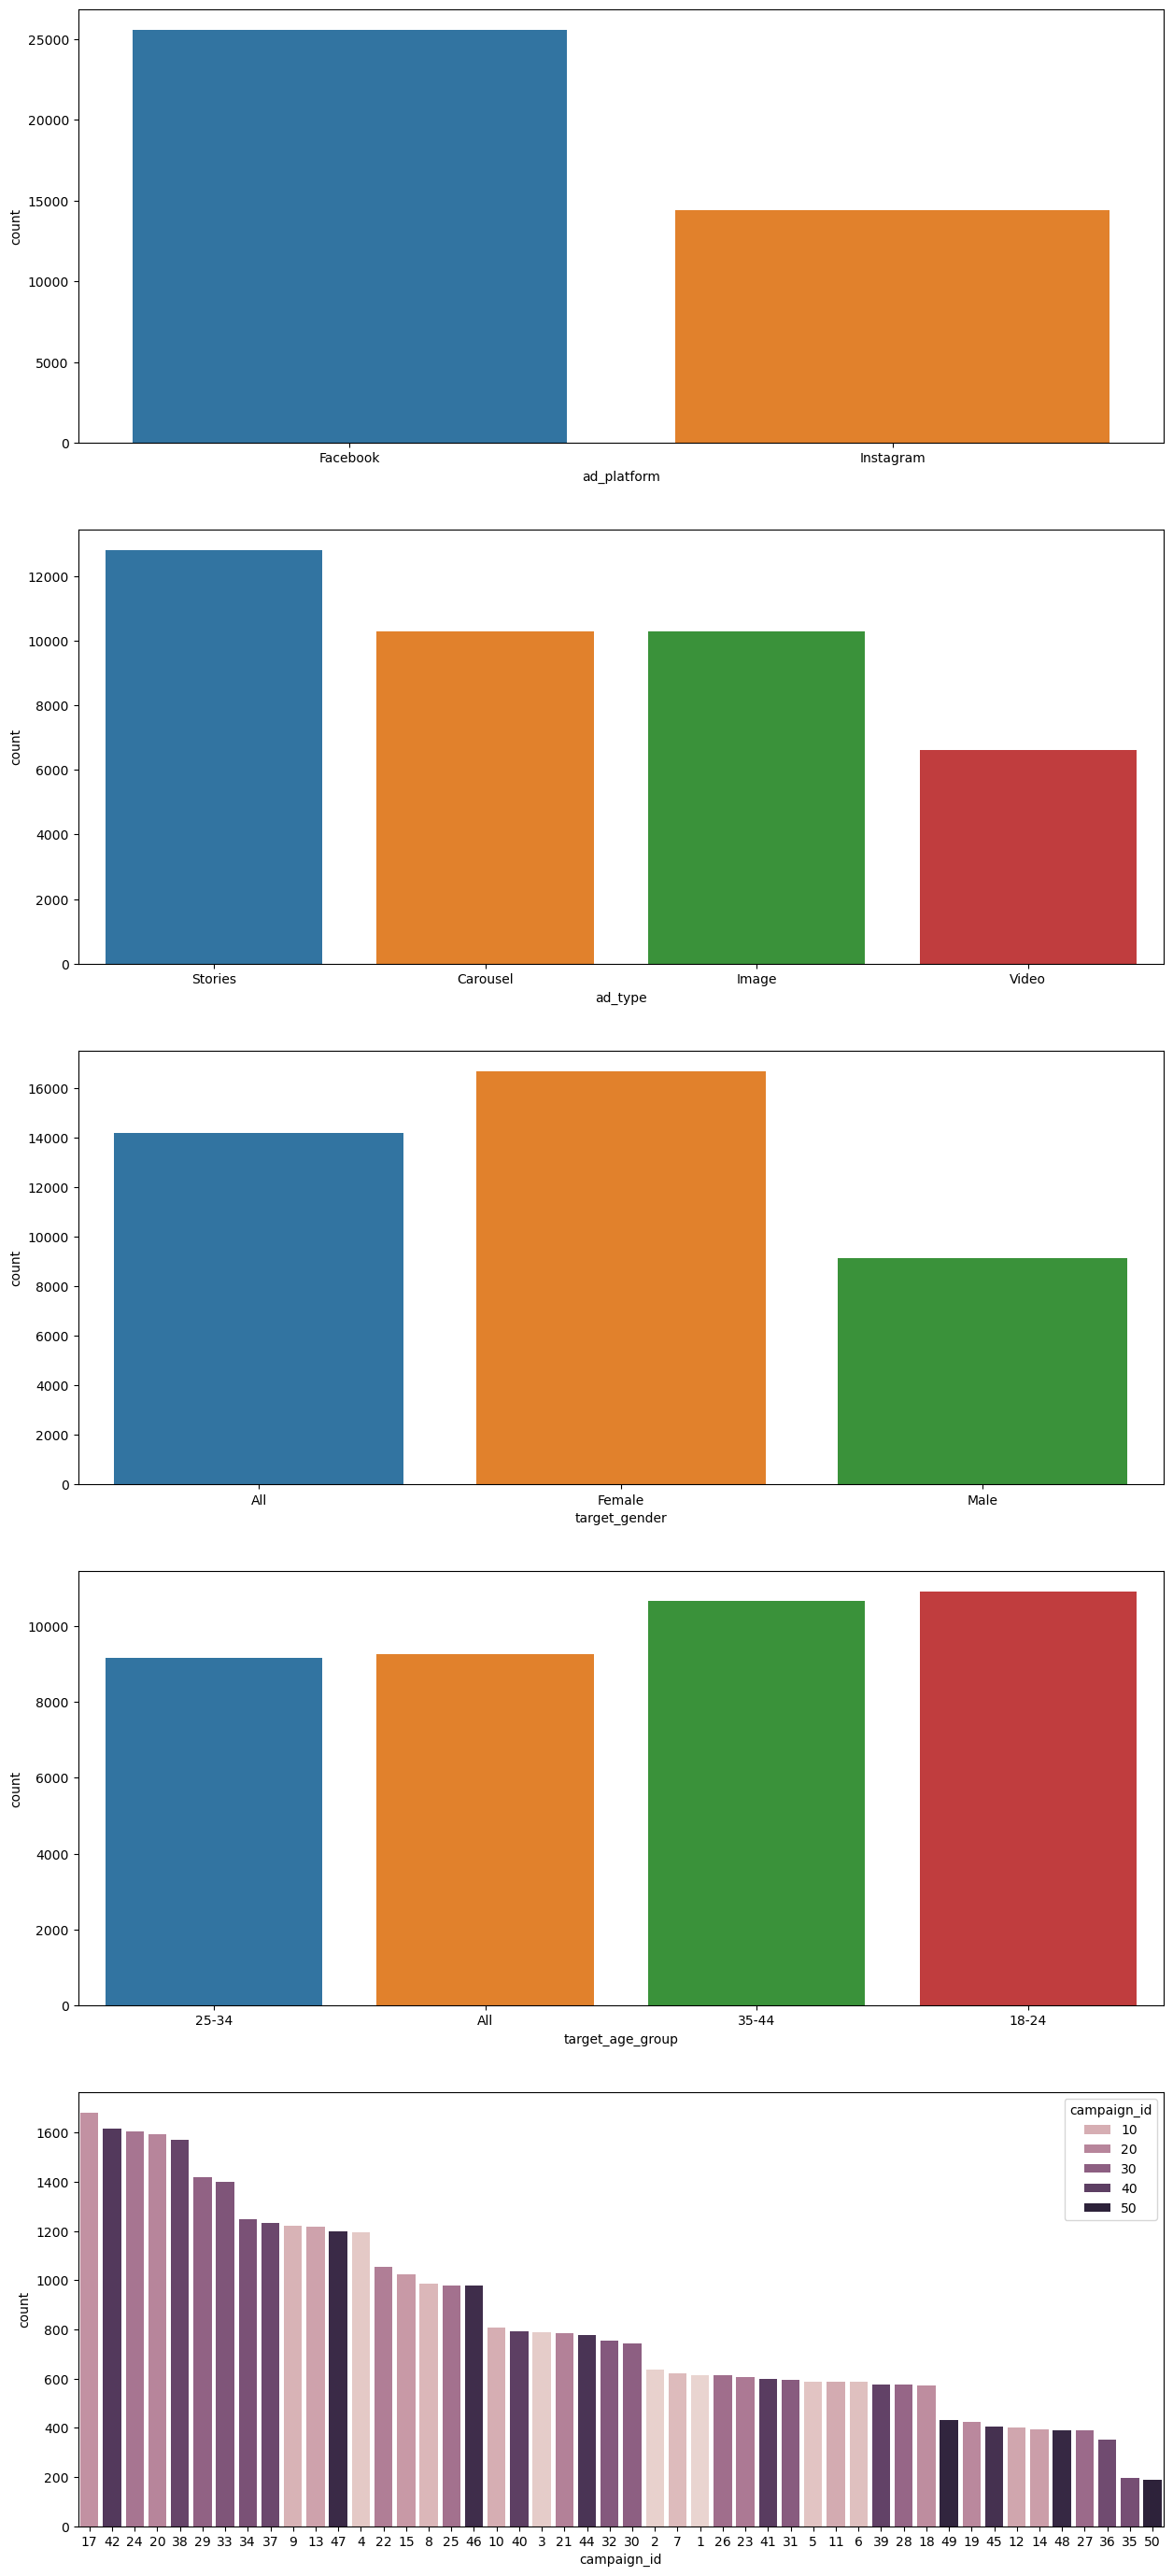

In [118]:
fig,ax=plt.subplots(nrows=5,ncols=1,figsize=(15,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4]

df_ads_campaign=df_ads_events["campaign_id"].value_counts()
df_ads_campaign=pd.DataFrame(df_ads_campaign.reset_index())
df_ads_campaign=df_ads_campaign.sort_values(by="count",ascending=False)


sns.countplot(data=df_ads_events,x="ad_platform",hue="ad_platform",ax=ax1)
sns.countplot(data=df_ads_events,x="ad_type",hue="ad_type",ax=ax2)
sns.countplot(data=df_ads_events,x="target_gender",hue="target_gender",ax=ax3)
sns.countplot(data=df_ads_events,x="target_age_group",hue="target_age_group",ax=ax4)
sns.barplot(data=df_ads_campaign,x=df_ads_campaign["campaign_id"].astype(str),y=df_ads_campaign["count"],hue="campaign_id",ax=ax5);

## MULTIVARIABLE DATA ANALYSIS

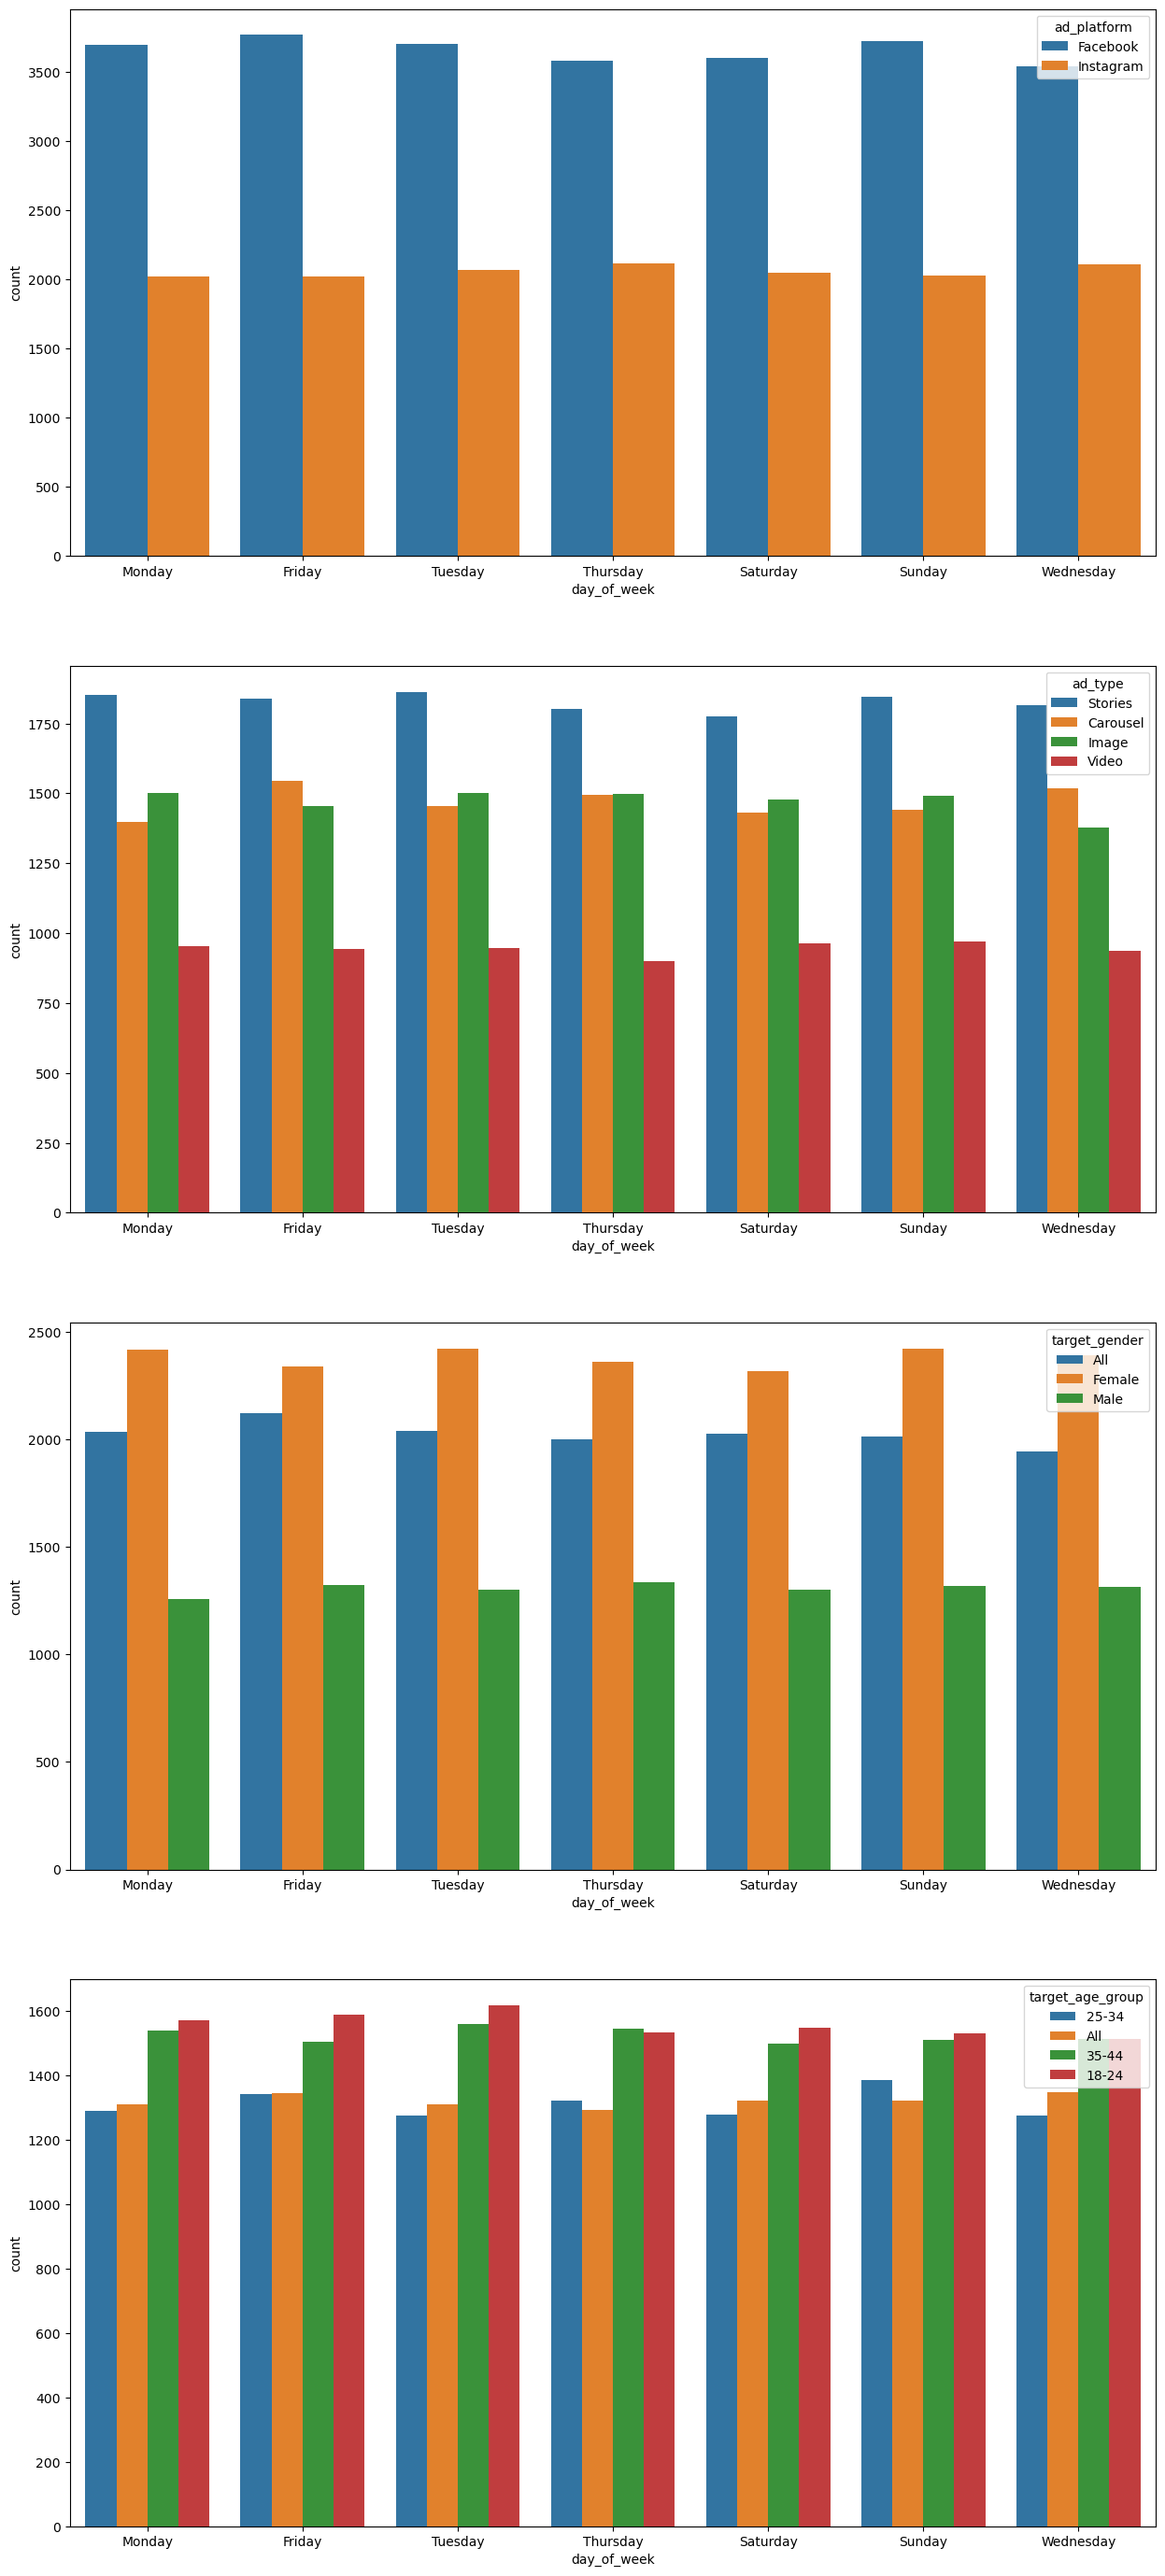

In [119]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];

sns.countplot(data=df_ads_events,x="day_of_week",hue="ad_platform",ax=ax1)
sns.countplot(data=df_ads_events,x="day_of_week",hue="ad_type",ax=ax2)
sns.countplot(data=df_ads_events,x="day_of_week",hue="target_gender",ax=ax3)
sns.countplot(data=df_ads_events,x="day_of_week",hue="target_age_group",ax=ax4);

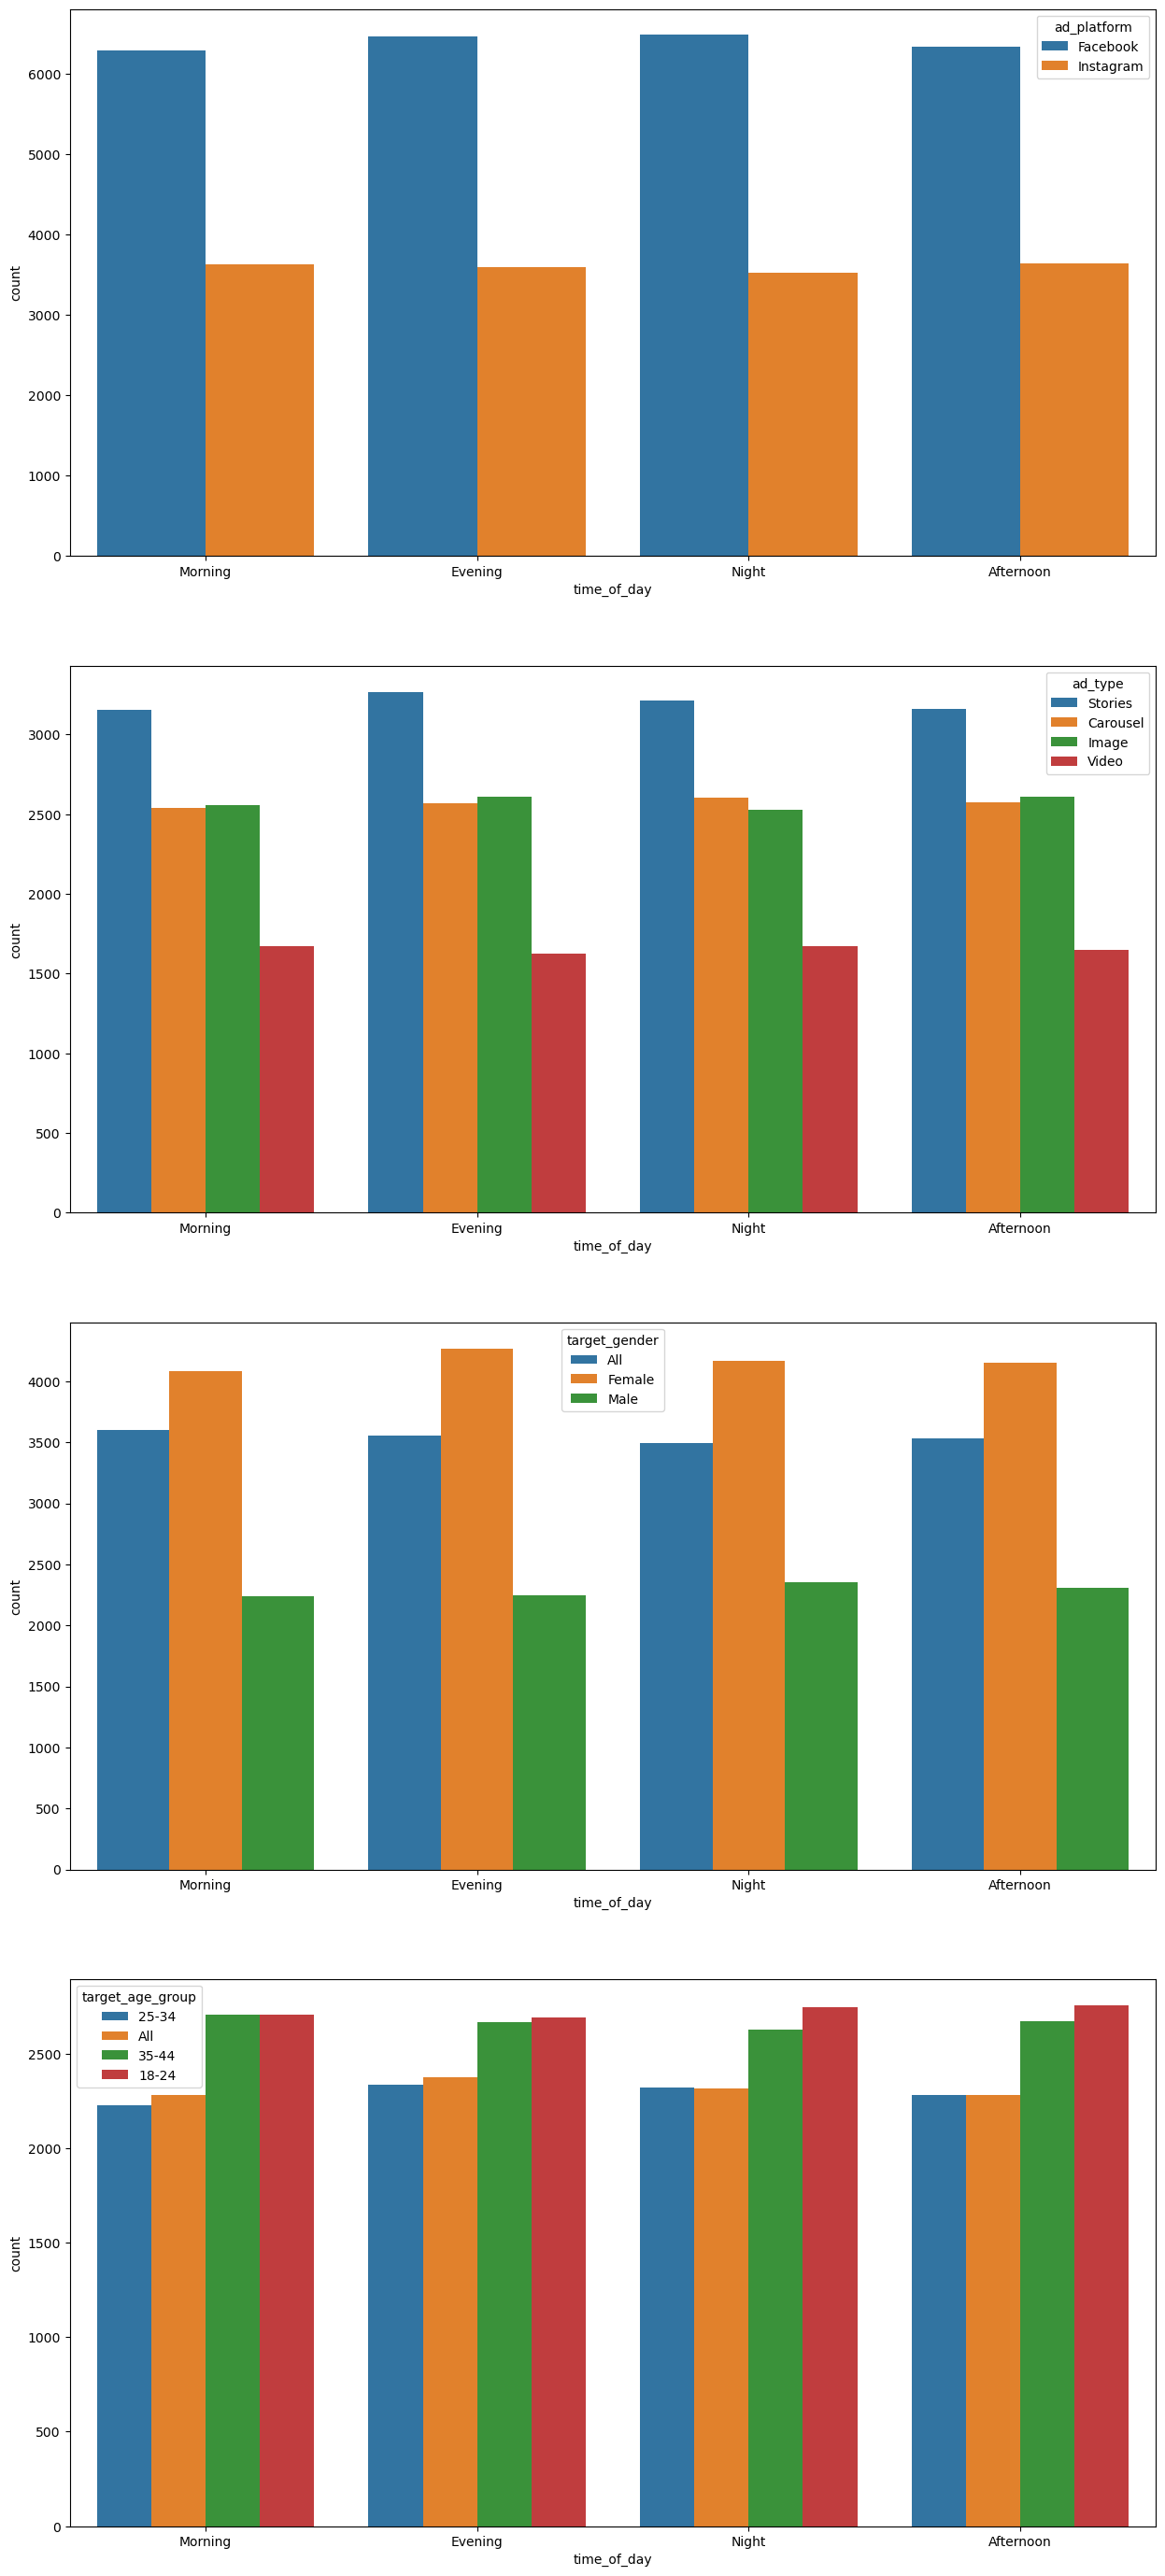

In [120]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];

sns.countplot(data=df_ads_events,x="time_of_day",hue="ad_platform",ax=ax1)
sns.countplot(data=df_ads_events,x="time_of_day",hue="ad_type",ax=ax2)
sns.countplot(data=df_ads_events,x="time_of_day",hue="target_gender",ax=ax3)
sns.countplot(data=df_ads_events,x="time_of_day",hue="target_age_group",ax=ax4);

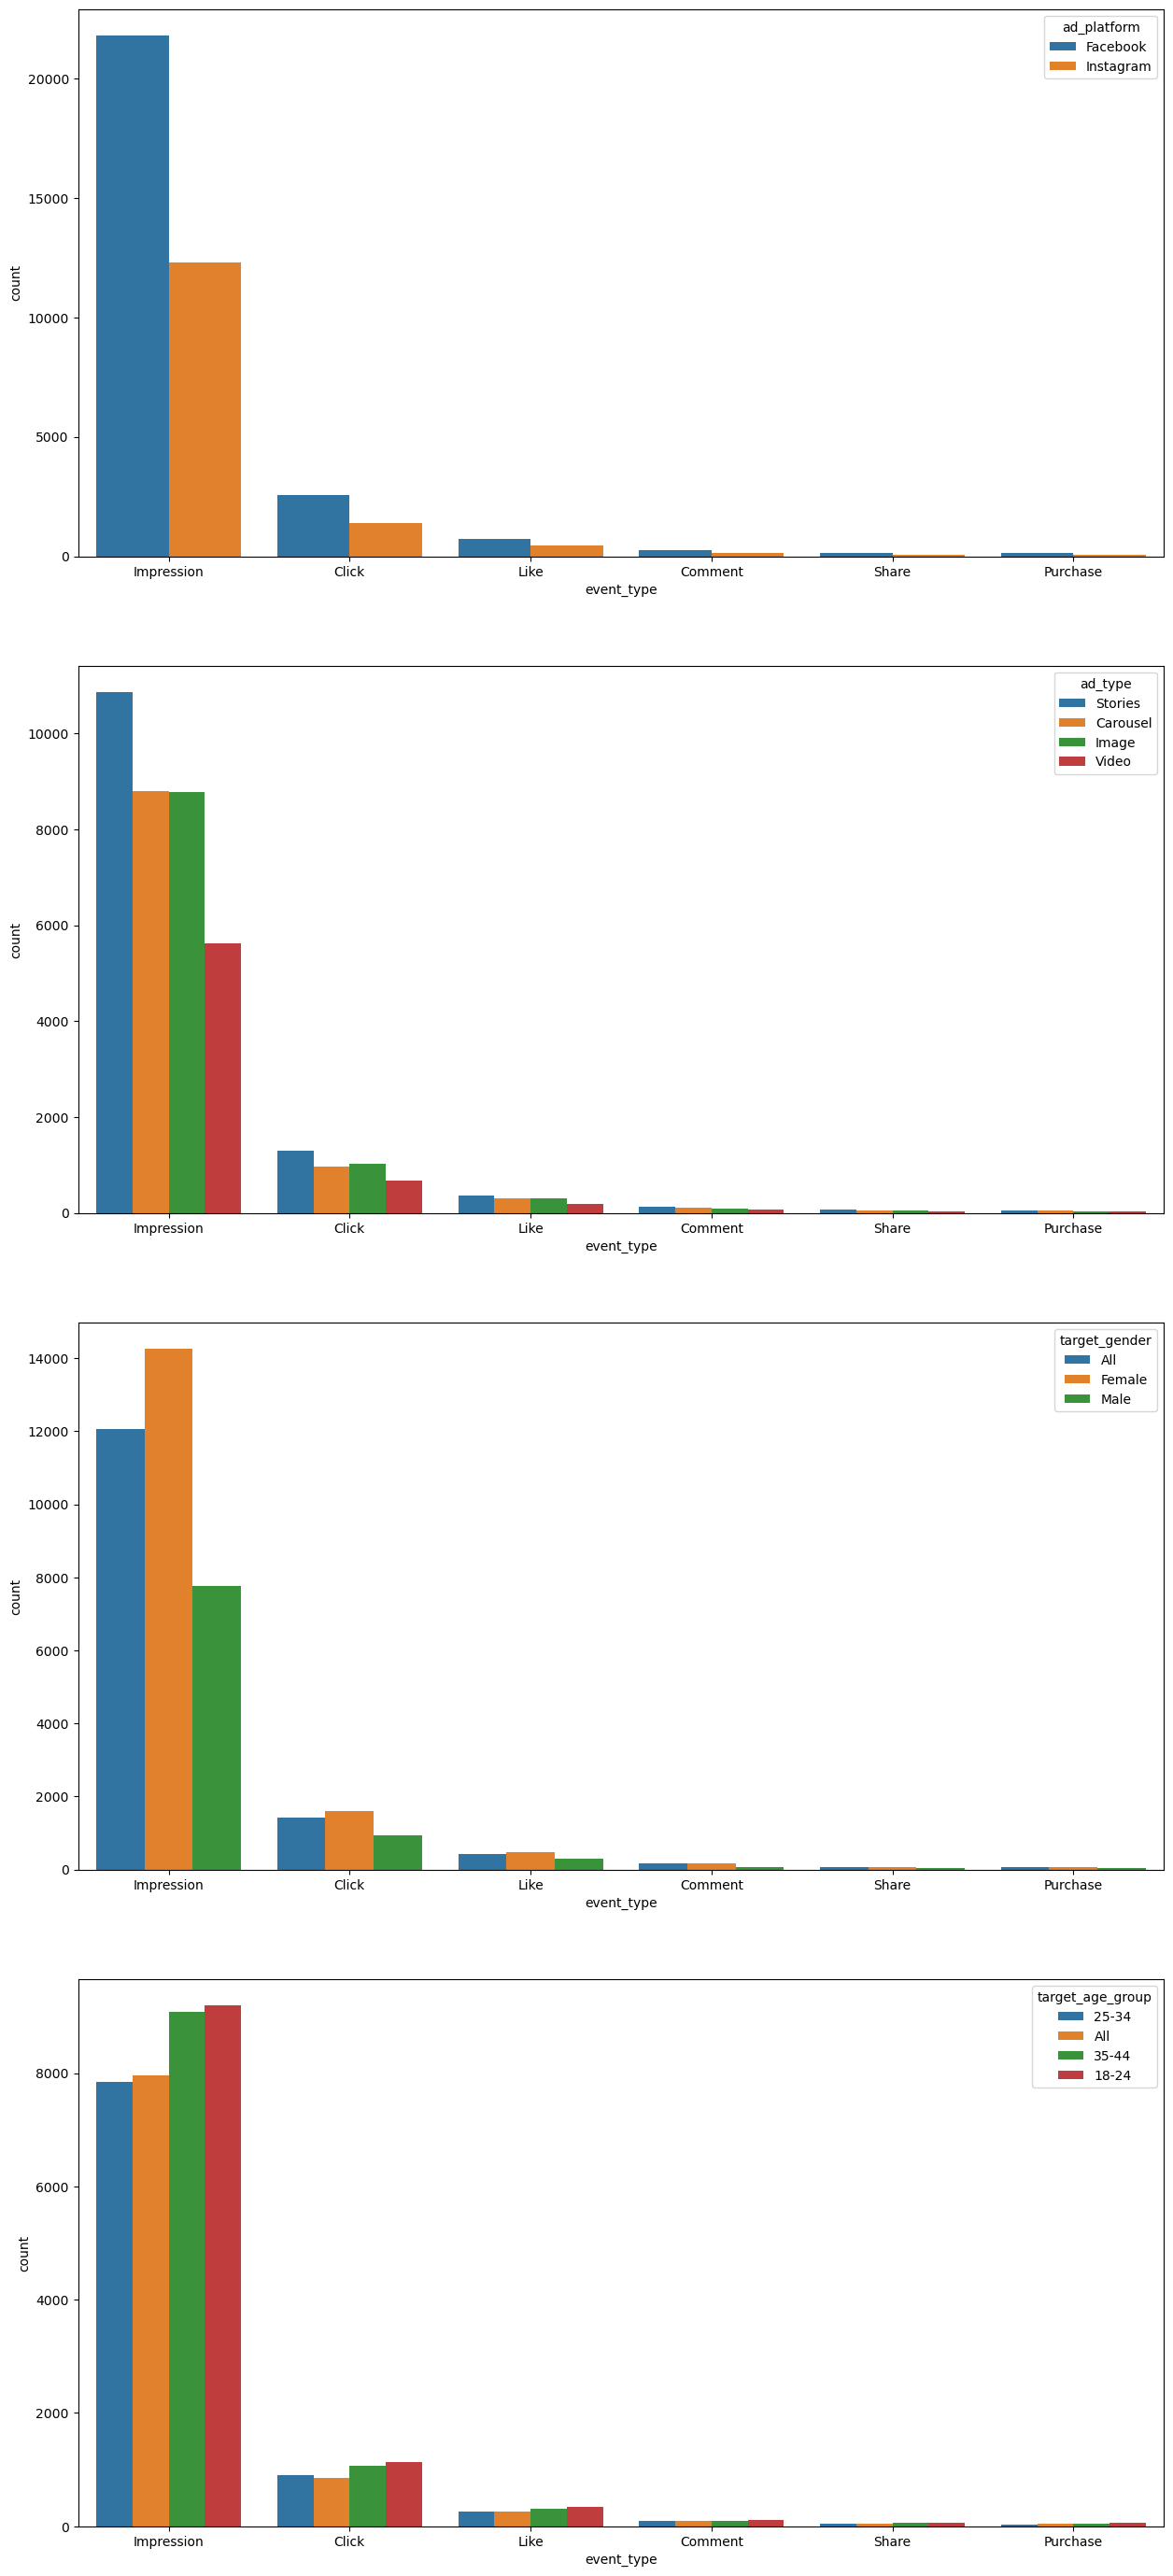

In [121]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,35))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];

sns.countplot(data=df_ads_events,x="event_type",hue="ad_platform",ax=ax1)
sns.countplot(data=df_ads_events,x="event_type",hue="ad_type",ax=ax2)
sns.countplot(data=df_ads_events,x="event_type",hue="target_gender",ax=ax3)
sns.countplot(data=df_ads_events,x="event_type",hue="target_age_group",ax=ax4);

### GENERAL INTERESTS

In [122]:
gaming=df_ads_events[df_ads_events["target_interests"].str.contains("gaming")]
news=df_ads_events[df_ads_events["target_interests"].str.contains("news")]
tech=df_ads_events[df_ads_events["target_interests"].str.contains("technology")]
fit=df_ads_events[df_ads_events["target_interests"].str.contains("fitness")]
art=df_ads_events[df_ads_events["target_interests"].str.contains("art")]
food=df_ads_events[df_ads_events["target_interests"].str.contains("food")]
fashion=df_ads_events[df_ads_events["target_interests"].str.contains("fashion")]
health=df_ads_events[df_ads_events["target_interests"].str.contains("health")]
photo=df_ads_events[df_ads_events["target_interests"].str.contains("photography")]
sports=df_ads_events[df_ads_events["target_interests"].str.contains("sports")]
finance=df_ads_events[df_ads_events["target_interests"].str.contains("finance")]
travel=df_ads_events[df_ads_events["target_interests"].str.contains("travel")]
life=df_ads_events[df_ads_events["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  5336
News:  4483
Tech:  4203
Fitness:  3999
Art:  4192
Food:  2453
Fashion:  5186
Health:  5801
Photo:  4434
Sports:  4746
Finance:  5642
Travel:  5311
Life:  4014


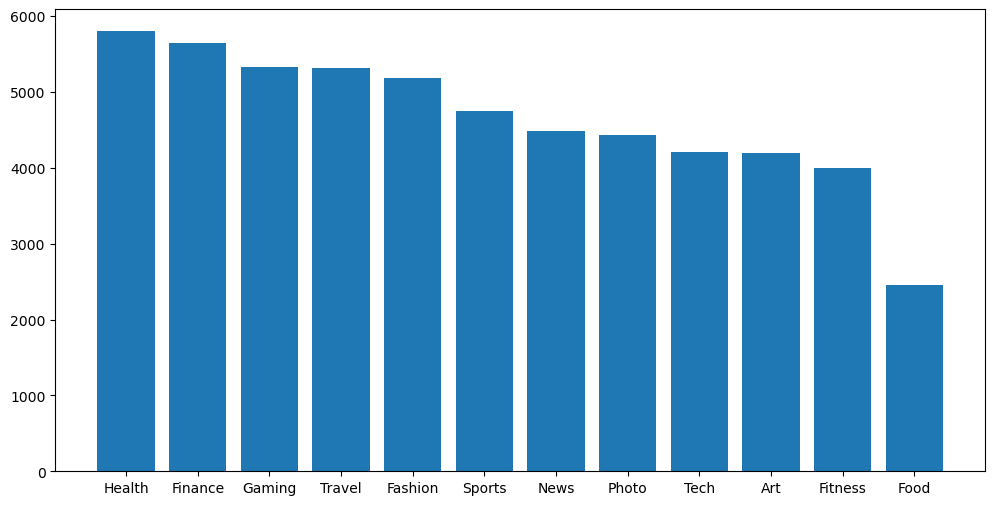

In [123]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

### WOMEN'S INTERESTS

In [124]:
df_ads_events_female=df_ads_events[df_ads_events["target_gender"]=="Female"]
df_ads_events_male=df_ads_events[df_ads_events["target_gender"]=="Male"]
df_ads_events_others=df_ads_events[df_ads_events["target_gender"]=="All"]

In [125]:
gaming=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("gaming")]
news=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("news")]
tech=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("technology")]
fit=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("fitness")]
art=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("art")]
food=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("food")]
fashion=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("fashion")]
health=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("health")]
photo=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("photography")]
sports=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("sports")]
finance=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("finance")]
travel=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("travel")]
life=df_ads_events_female[df_ads_events_female["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  2572
News:  2582
Tech:  2202
Fitness:  2023
Art:  1233
Food:  969
Fashion:  2171
Health:  3069
Photo:  1408
Sports:  1979
Finance:  2183
Travel:  1778
Life:  1422


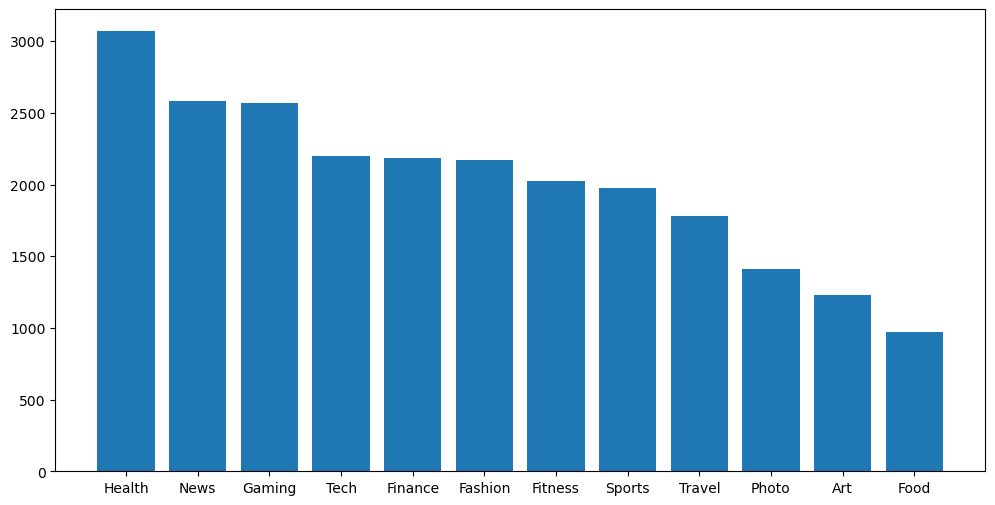

In [126]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

### MEN'S INTERESTS

In [127]:
gaming=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("gaming")]
news=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("news")]
tech=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("technology")]
fit=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("fitness")]
art=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("art")]
food=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("food")]
fashion=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("fashion")]
health=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("health")]
photo=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("photography")]
sports=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("sports")]
finance=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("finance")]
travel=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("travel")]
life=df_ads_events_male[df_ads_events_male["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  1578
News:  1180
Tech:  782
Fitness:  798
Art:  972
Food:  224
Fashion:  1021
Health:  987
Photo:  1636
Sports:  1165
Finance:  1421
Travel:  1344
Life:  979


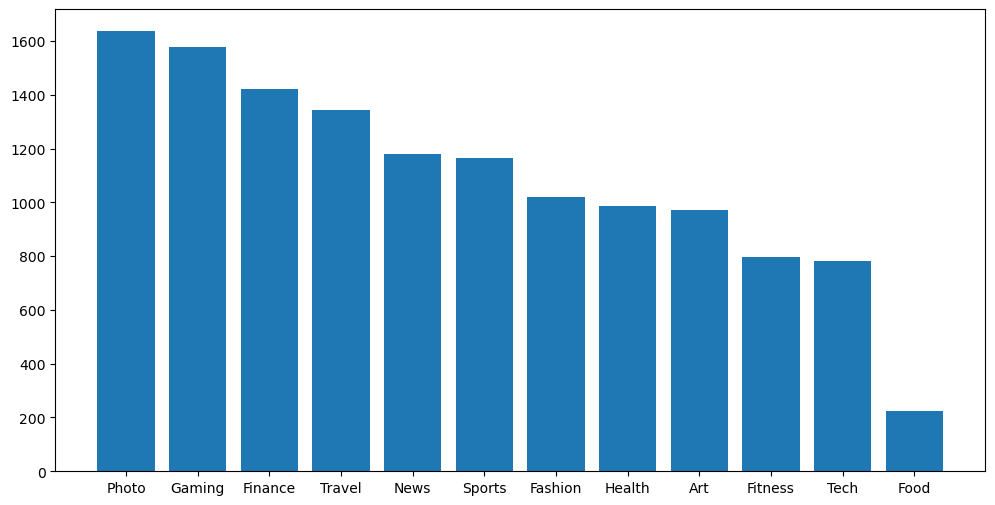

In [128]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

### ALL CATEGORY INTERESTS

In [129]:
gaming=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("gaming")]
news=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("news")]
tech=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("technology")]
fit=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("fitness")]
art=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("art")]
food=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("food")]
fashion=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("fashion")]
health=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("health")]
photo=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("photography")]
sports=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("sports")]
finance=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("finance")]
travel=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("travel")]
life=df_ads_events_others[df_ads_events_others["target_interests"].str.contains("lifestyle")]
print("Gaming: ",len(gaming))
print("News: ",len(news))
print("Tech: ",len(tech))
print("Fitness: ",len(fit))
print("Art: ",len(art))
print("Food: ",len(food))
print("Fashion: ",len(fashion))
print("Health: ",len(health));
print("Photo: ",len(photo))
print("Sports: ",len(sports))
print("Finance: ",len(finance))
print("Travel: ",len(travel))
print("Life: ",len(life))

Gaming:  1186
News:  721
Tech:  1219
Fitness:  1178
Art:  1987
Food:  1260
Fashion:  1994
Health:  1745
Photo:  1390
Sports:  1602
Finance:  2038
Travel:  2189
Life:  1613


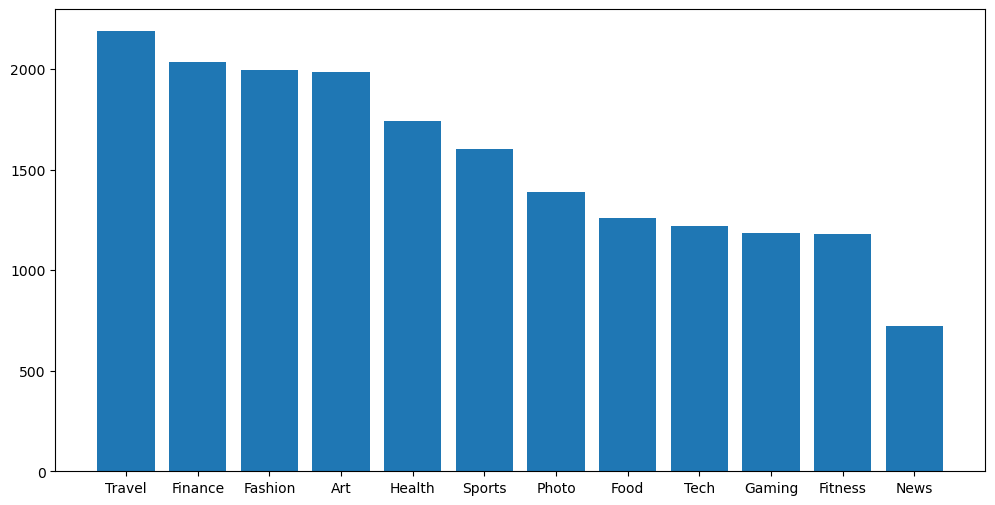

In [130]:
df_total=pd.Series({"Gaming":len(gaming),"News":len(news),"Tech":len(tech),"Fitness":len(fit),"Art":len(art),"Food":len(food),"Fashion":len(fashion),
                     "Health":len(health),"Photo":len(photo),"Sports":len(sports),"Finance":len(finance),"Travel":len(travel)})
df_total=df_total.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(x=df_total.index,height=df_total.values);

## ADS-EVENTS TABLE SUMMARY
**This dataset contains information on how ads impacted users and how they reacted. It provides details about the target audience, including gender, age range, interests, and the platform and format in which the ad was displayed.**
### EXPLORATORY DATA ANALYSIS
**ad_platform:** *The platform with the most user interaction was Facebook, while Instagram had the least.*\
**ad_type:** *The most consumed format by users was Stories, followed by Images, Carousel, and lastly Video. It should be noted that there is not much difference between the Image and Carousel formats.*\
**target_gender:** *GENDER: THE TARGET AUDIENCE OF THE AD. THIS FACTOR IS IMPORTANT TO KNOW IF USERS CONSUMED ADS TARGETED AT THEIR CORRESPONDING GENDER. THE GRAPH SHOWS THE ADS TARGETED AT DIFFERENT GENDER THAT USERS CONSUMED MOST. THE ADS MOST CONSUMED BY USERS WERE TARGETED AT FEMALE AUDIENCES, FOLLOWED BY THOSE TARGETED AT THE GENERAL AUDIENCE, AND LASTLY, ADS TARGETED AT MALE AUDIENCES.*\
**target_age_group:** *AGE RANGE TARGETED BY THE AD. THIS FACTOR IS IMPORTANT TO KNOW IF USERS WITHIN THE TARGETED AGE RANGE CONSUMED THE ADS OR NOT. THE GRAPH SHOWS THAT USERS CONSUMED MORE ADS TARGETED AT AUDIENCES IN THE 35-44 AND 18-24 AGE RANGES, FOLLOWED BY CONTENT FOR THE GENERAL AUDIENCE, AND FINALLY, CONTENT FOR THE 25-34 AGE RANGE.*\
## MULTIVARIABLE DATA ANALYSIS
**day_of_week vs ad_platform:** *THIS GRAPHIC SHOWS THAT USERS CONSUME MORE ADS ON THE FACEBOOK PLATFORM THAN ON INSTAGRAM.*\
**day_of_week vs ad_type:** *This chart shows that users consumed more Stories every day. On some days, such as Saturdays, Wednesdays, Mondays, and Sundays, users consumed more images, while on Fridays, Thursdays, and Tuesdays, users consumed more carousel ads. The least consumed format was video.*\
**day_of_week vs target_gender:** *Users consume more ads every day that were targeted at women, then at the general public, and finally at men.*\
**day_of_week vs target_age_group:** *Every day, users consumed more ads targeting the 35-44 and 18-24 age groups, with Saturdays and Sundays showing a slight difference in consumption between these age groups. Next were ads targeting the 25-34 age group (except Fridays, which were also 25-34), and finally, ads targeting the 25-34 age group.*\
**time_of_day vs ad_platform:** *FACEBOOK WAS THE MOST USED PLATFORM AT ALL TIMES OF DAY.*\
**time_of_day vs ad_type:** *Stories was the most consumed format at all times of day, followed by images and carousels, and lastly video.*\
**time_of_day vs target_gender:** *Advertisements aimed at women are consumed most at all times of day, followed by ads for the general public, and lastly ads aimed at men.*\
**time_of_day vs target_age_group:** *Advertisements targeting the 35-44 and 18-24 age groups were the most consumed at all times of day, followed by ads for the general public, and lastly those for the 25-34 age group.*\
**event_type vs ad_platform:** *ALL TYPES OF USER REACTIONS OCCURRED FIRST ON THE FACEBOOK PLATFORM.*\
**event_type vs ad_type:** *Reactions are mostly in the form of Stories, followed by images, carousels, and finally video.*\
**event_type vs target_gender:** *Users had the greatest reaction to ads targeted at women, followed by ads targeted at the general public, and finally those targeted at the male public.*\
**event_type vs target_age_group:** *Users reacted most strongly to ads targeting the 35-44 age group, followed by 18-24, then the general public, and finally 25-34.*
#### GENERAL INTERESTS MOST CONSUMED BY USERS 
*USERS CONSUMED THE MOST HEALTH-RELATED CONTENT, FOLLOWED BY FINANCE, GAMES, TRAVEL, ETC.*
#### CONTENT INTERESTS TARGETED AT WOMEN THAT USERS CONSUMED MOST
*USERS CONSUMED MORE CONTENT RELATED TO HEALTH, GAMES, NEWS, TECH, ETC.*
#### INTERESTS TARGETED AT MEN THAT USERS CONSUMED MOST
*USERS CONSUMED MOST CONTENT RELATED TO PHOTOGRAPHY, GAMES, FINANCE, TRAVEL, ETC.*
#### CONTENT MOST CONSUMED BY USERS AND TARGET AUDIENCES
*USERS CONSUMED THE MOST CONTENT RELATED TO TRAVEL, FINANCE, ART, FASHION, HEALTH, ETC.*

# TABLE OF THE ENTIRE DATABASE

In [131]:

df_all = pd.merge(df_ad_events,df_ads[["ad_id","campaign_id","ad_platform","ad_type","target_gender","target_age_group","target_interests"]],on="ad_id",how="left")
df_all=df_all.merge(df_users[["user_id","user_gender","user_age","age_group","country","location","interests"]],on="user_id",how="left")
df_all=df_all.merge(df_campaigns[["campaign_id","name","start_date","end_date","duration_days","total_budget"]],on="campaign_id",how="left")
df_all

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,user_age,age_group,country,location,interests,name,start_date,end_date,duration_days,total_budget
0,312834,49,d75a9,2025-06-23 08:53:09,Monday,Morning,Impression,11,Facebook,Stories,...,42,35-44,India,Lake Joelberg,"sports, art, fitness",Campaign_11_Q3,2025-04-24,2025-07-02,69,79067.91
1,293696,185,0023e,2025-08-01 23:33:29,Friday,Evening,Impression,36,Instagram,Carousel,...,35,35-44,India,South Lauren,"lifestyle, fitness, health",Campaign_36_Q3,2025-03-07,2025-05-13,67,58801.99
2,371590,12,f49e6,2025-05-20 06:38:48,Tuesday,Morning,Impression,45,Facebook,Stories,...,25,25-34,United States,Haydenberg,"fitness, sports, finance",Campaign_45_Summer,2025-05-26,2025-08-05,71,53303.55
3,384253,109,1eefe,2025-06-19 07:14:57,Thursday,Morning,Click,8,Facebook,Stories,...,20,18-24,Japan,East Shaneberg,"fashion, gaming, photography",Campaign_8_Q3,2025-02-25,2025-04-07,41,39953.19
4,183939,35,540bb,2025-07-22 01:11:22,Tuesday,Night,Impression,18,Instagram,Image,...,25,25-34,United States,East Chad,"finance, photography, health",Campaign_18_Q3,2025-04-19,2025-06-15,57,48832.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40373,119599,145,33df1,2025-07-30 23:59:56,Wednesday,Evening,Impression,20,Facebook,Carousel,...,35,35-44,United Kingdom,Port Nathan,"food, travel",Campaign_20_Winter,2025-02-17,2025-05-18,90,98904.66
40374,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression,29,Instagram,Carousel,...,22,18-24,Mexico,Paulport,"travel, health",Campaign_29_Winter,2025-07-16,2025-10-06,82,19773.66
40375,270990,81,49c5c,2025-07-27 18:50:17,Sunday,Evening,Impression,29,Instagram,Carousel,...,44,35-44,Brazil,New Jay,"food, health, lifestyle",Campaign_29_Winter,2025-07-16,2025-10-06,82,19773.66
40376,213903,106,0078e,2025-05-10 21:51:23,Saturday,Evening,Impression,22,Facebook,Stories,...,25,25-34,India,Wilsontown,"technology, art",Campaign_22_Q3,2025-03-17,2025-04-22,36,35743.40


In [132]:
df_all_dict=df_all.sample(n=1000,random_state=42)
df_all_dict=df_all_dict.to_dict(orient="records")
template=ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."),
    ("user","Explain the dataset to me clearly and also tell me how to analyze it; that is, what graphs and operations would be useful to apply. The dataset is: {dataset}")
])
chain = template|llm
response=chain.invoke({"dataset":df_all_dict})
display(Markdown(response.content))

This dataset provides detailed logs of ad interactions, combining information about the ad event itself, the user who performed the action, and the campaign parameters. It's designed for analyzing ad campaign performance and user engagement.

### Dataset Explanation:

Each entry (row) in the dataset represents a single ad event and contains the following information:

*   **`event_id`**: Unique identifier for each ad interaction event.
*   **`ad_id`**: Identifier for the specific ad creative.
*   **`user_id`**: Identifier for the user interacting with the ad.
*   **`timestamp`**: The exact date and time when the event occurred.
*   **`day_of_week`**: The day of the week the event occurred (e.g., 'Monday').
*   **`time_of_day`**: The general time period of the day (e.g., 'Morning', 'Afternoon', 'Evening', 'Night').
*   **`event_type`**: The type of interaction (e.g., 'Impression', 'Click', 'Like', 'Purchase', 'Comment', 'Share'). These are key performance indicators (KPIs).
*   **`campaign_id`**: Identifier for the advertising campaign the ad belongs to.
*   **`ad_platform`**: The platform where the ad was displayed (e.g., 'Facebook', 'Instagram').
*   **`ad_type`**: The format of the ad (e.g., 'Image', 'Video', 'Stories', 'Carousel').
*   **`target_gender`**: The gender targeted by the ad campaign.
*   **`target_age_group`**: The age group targeted by the ad campaign.
*   **`target_interests`**: Comma-separated interests targeted by the ad campaign.
*   **`user_gender`**: The actual gender of the user.
*   **`user_age`**: The actual age of the user.
*   **`age_group`**: The actual age group of the user.
*   **`country`**: The country of the user.
*   **`location`**: The specific location (city/region) of the user.
*   **`interests`**: Comma-separated actual interests of the user.
*   **`name`**: Name of the campaign.
*   **`start_date`**: Campaign start date.
*   **`end_date`**: Campaign end date.
*   **`duration_days`**: Duration of the campaign in days.
*   **`total_budget`**: Total budget allocated for the campaign.

### How to Analyze the Dataset:

The goal of analyzing this dataset is to understand ad campaign effectiveness, identify audience segments, and optimize future ad strategies.

**1. Data Preparation (Operations):**

*   **Convert `timestamp`, `start_date`, `end_date` to datetime objects**: Essential for time-series analysis and duration calculations.
*   **Calculate Key Metrics**:
    *   **Click-Through Rate (CTR)**: `Clicks / Impressions`
    *   **Conversion Rate (CVR)**: `Purchases / Impressions` (or `Purchases / Clicks`)
    *   **Engagement Rate**: `Likes / Impressions` (or `Likes / Clicks`)
    *   **Cost Per Click (CPC)**: `Total Budget / Clicks` (requires aggregating budget per campaign and then dividing by total clicks for that campaign)
    *   **Cost Per Acquisition (CPA)**: `Total Budget / Purchases`
*   **Handle Multi-value Fields**: `target_interests` and `interests` are comma-separated strings. For detailed analysis, these should be split into individual interests (e.g., using `explode` in Pandas) to count occurrences of each interest.
*   **Check for Data Consistency**: Compare `target_gender` with `user_gender`, `target_age_group` with `age_group` to assess targeting accuracy.

**2. Useful Graphs and Operations:**

**A. Overall Campaign Performance & Engagement:**

*   **Operation**: Count `event_type` occurrences. Calculate overall CTR, CVR, Engagement Rate.
*   **Graph**:
    *   **Bar Chart**: Distribution of `event_type` (Impressions, Clicks, Likes, Purchases, Comments, Shares).
    *   **Pie Chart**: Proportion of each `event_type` relative to total events.
*   **Insight**: Understand the general engagement funnel and overall effectiveness.

**B. Performance by Campaign:**

*   **Operation**: Group by `campaign_id` (or `name`), then count `event_type` and calculate CTR, CVR, Engagement Rate for each campaign.
*   **Graph**:
    *   **Bar Chart**: Total events (or specific event types like Purchases) per `campaign_id`.
    *   **Stacked Bar Chart**: `event_type` distribution within each `campaign_id`.
    *   **Scatter Plot**: `total_budget` vs. `conversion_rate` (or total purchases) for each campaign to identify budget efficiency.
*   **Insight**: Identify top-performing and underperforming campaigns, and how budget relates to outcomes.

**C. Performance by Ad Characteristics:**

*   **Operation**: Group by `ad_platform`, `ad_type`, `target_gender`, `target_age_group`, `target_interests` (after splitting), then count `event_type` and calculate rates (CTR, CVR).
*   **Graph**:
    *   **Bar Charts**: For each characteristic (e.g., `ad_platform`, `ad_type`), show total events or conversion rates.
    *   **Heatmap**: For two categorical variables (e.g., `ad_platform` vs. `ad_type`) showing a performance metric (e.g., CVR).
*   **Insight**: Determine which platforms, ad formats, and targeting strategies yield the best results.

**D. User Demographics & Interests:**

*   **Operation**: Group by `user_gender`, `age_group`, `country`, `location`, `interests` (after splitting), then count `event_type` and calculate rates.
*   **Graph**:
    *   **Bar Charts**: Show engagement metrics broken down by `user_gender`, `age_group`, `country`.
    *   **Word Cloud / Bar Chart**: For `interests` (both `user_interests` and `target_interests`) to visualize common themes.
    *   **Comparison Bar Charts**: `target_gender` vs. `user_gender` or `target_age_group` vs. `age_group` to evaluate targeting accuracy.
*   **Insight**: Understand who is actually engaging with the ads and if the targeting is effective. Identify valuable audience segments.

**E. Temporal Analysis:**

*   **Operation**: Group by `day_of_week` and `time_of_day`, then count `event_type` and calculate rates. Aggregate events by day/week using `timestamp`.
*   **Graph**:
    *   **Bar Charts**: Events by `day_of_week` and `time_of_day`.
    *   **Line Chart**: Events over time (daily, weekly) using `timestamp`.
*   **Insight**: Discover optimal times and days for ad delivery and observe trends over the campaign period.

**F. Campaign Duration vs. Performance:**

*   **Operation**: Group by `campaign_id`, then plot `duration_days` against performance metrics (e.g., total purchases, CVR).
*   **Graph**:
    *   **Scatter Plot**: `duration_days` vs. `conversion_rate`.
*   **Insight**: Explore if longer or shorter campaigns tend to be more effective.

By applying these analytical steps and visualizations, you can gain a comprehensive understanding of your ad campaign ecosystem, pinpoint areas for improvement, and inform future marketing decisions.

#### ADS VS USER

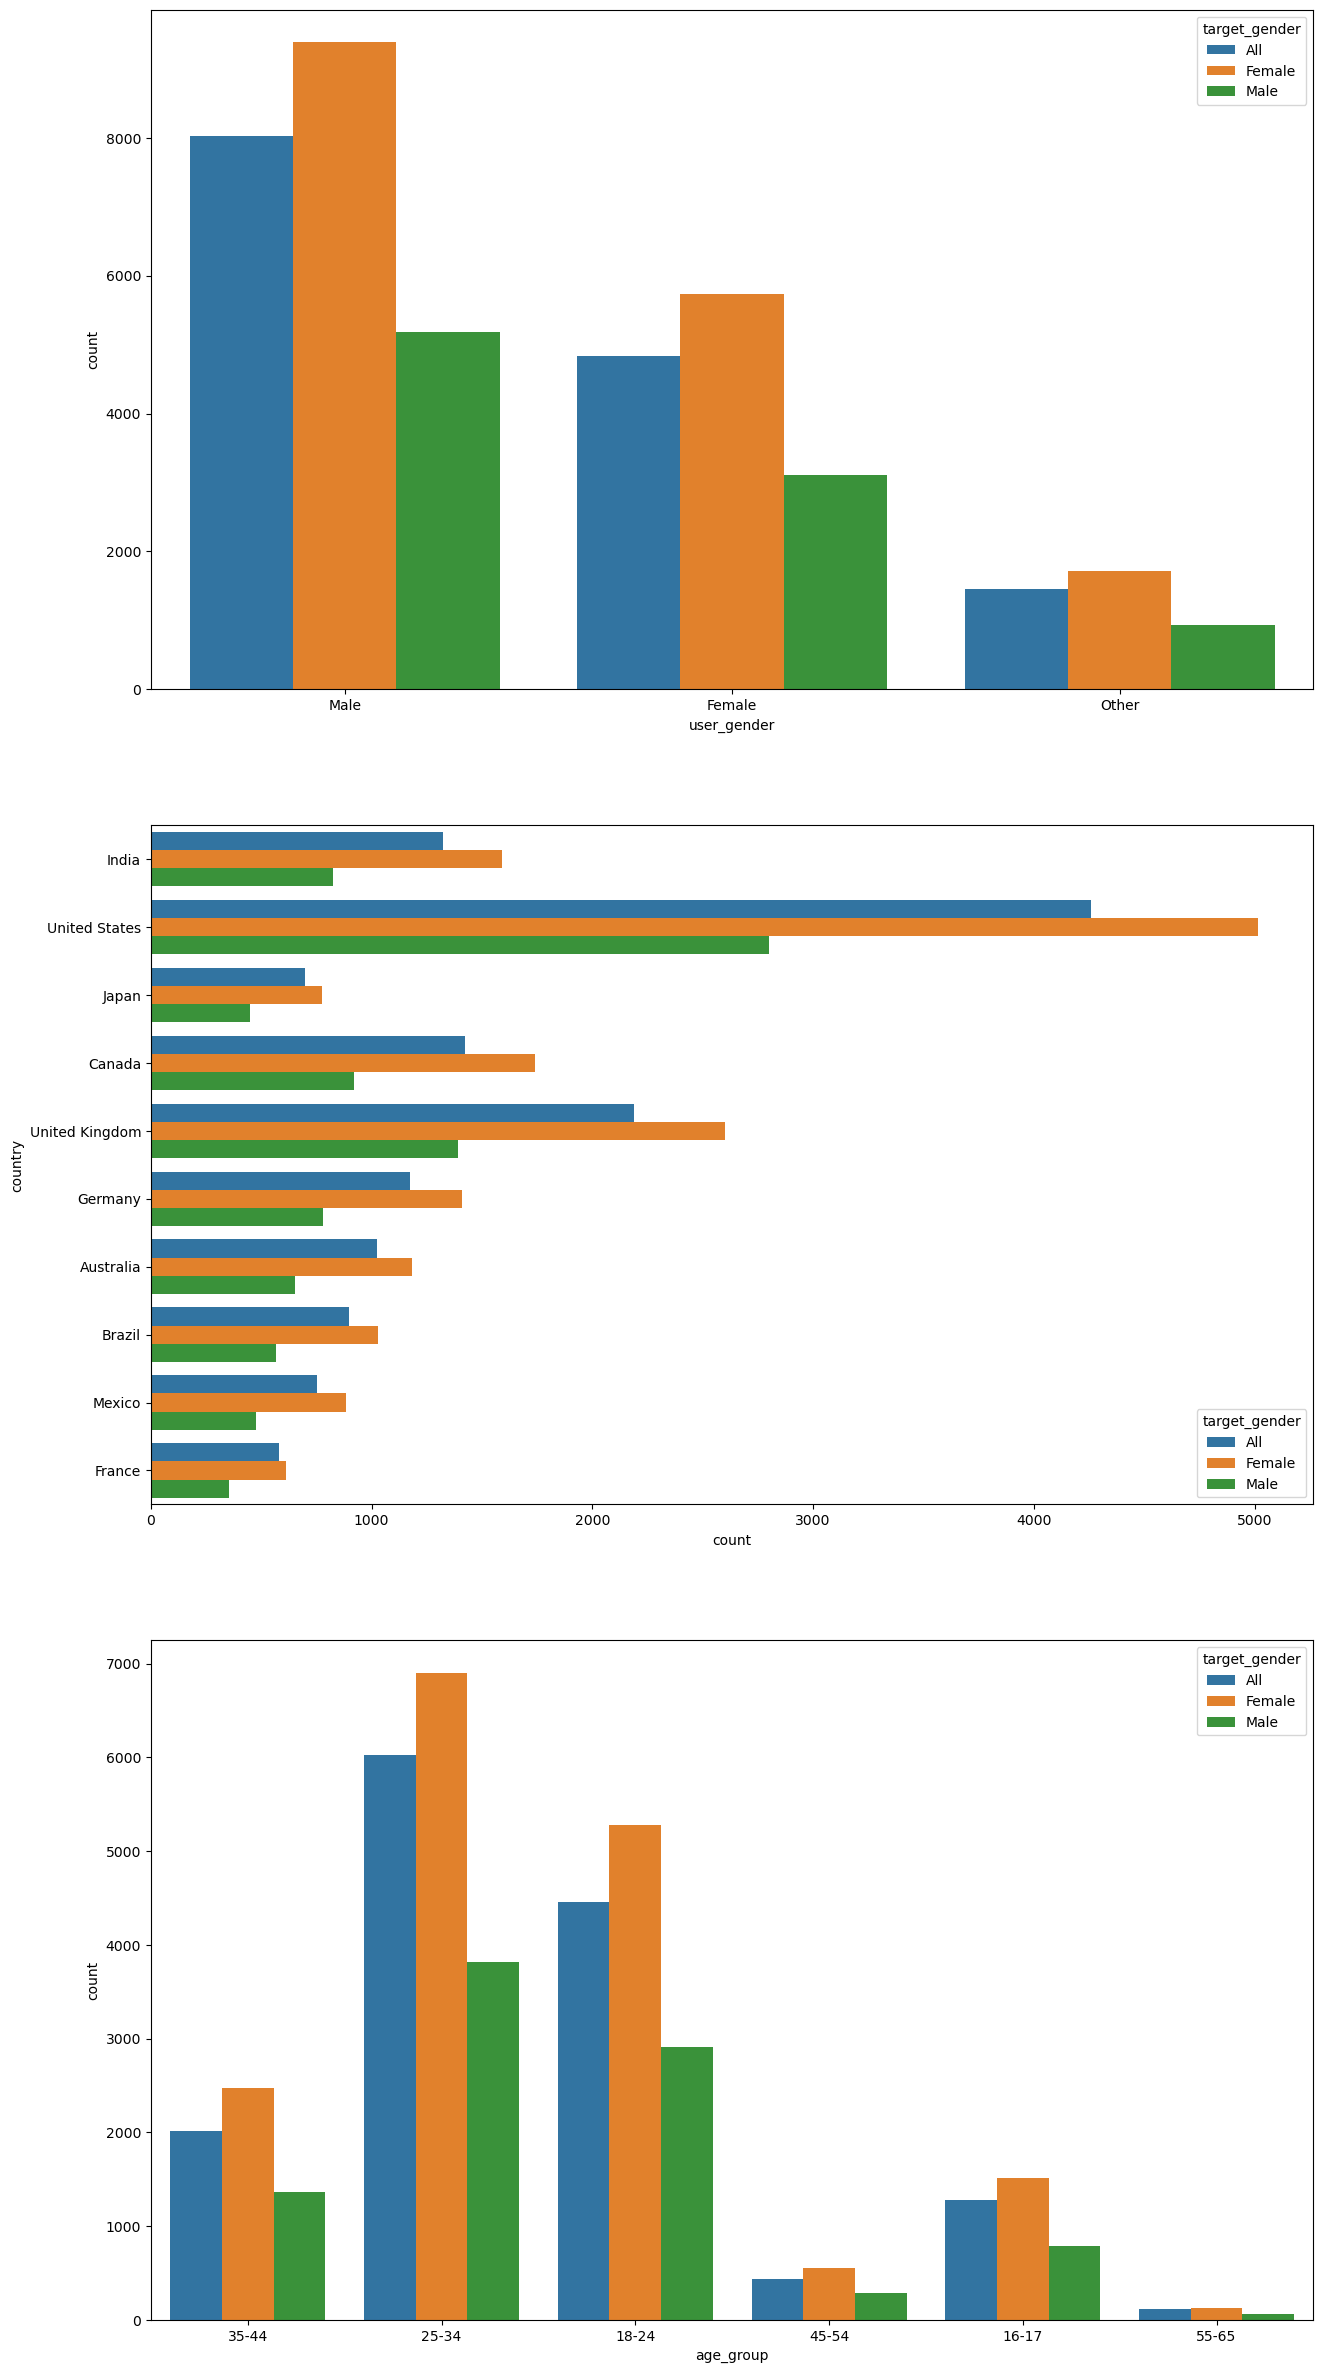

In [133]:

fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_all,x="user_gender",hue="target_gender",ax=ax1)
sns.countplot(data=df_all,y="country",hue="target_gender",ax=ax2)
sns.countplot(data=df_all,x="age_group",hue="target_gender",ax=ax3);

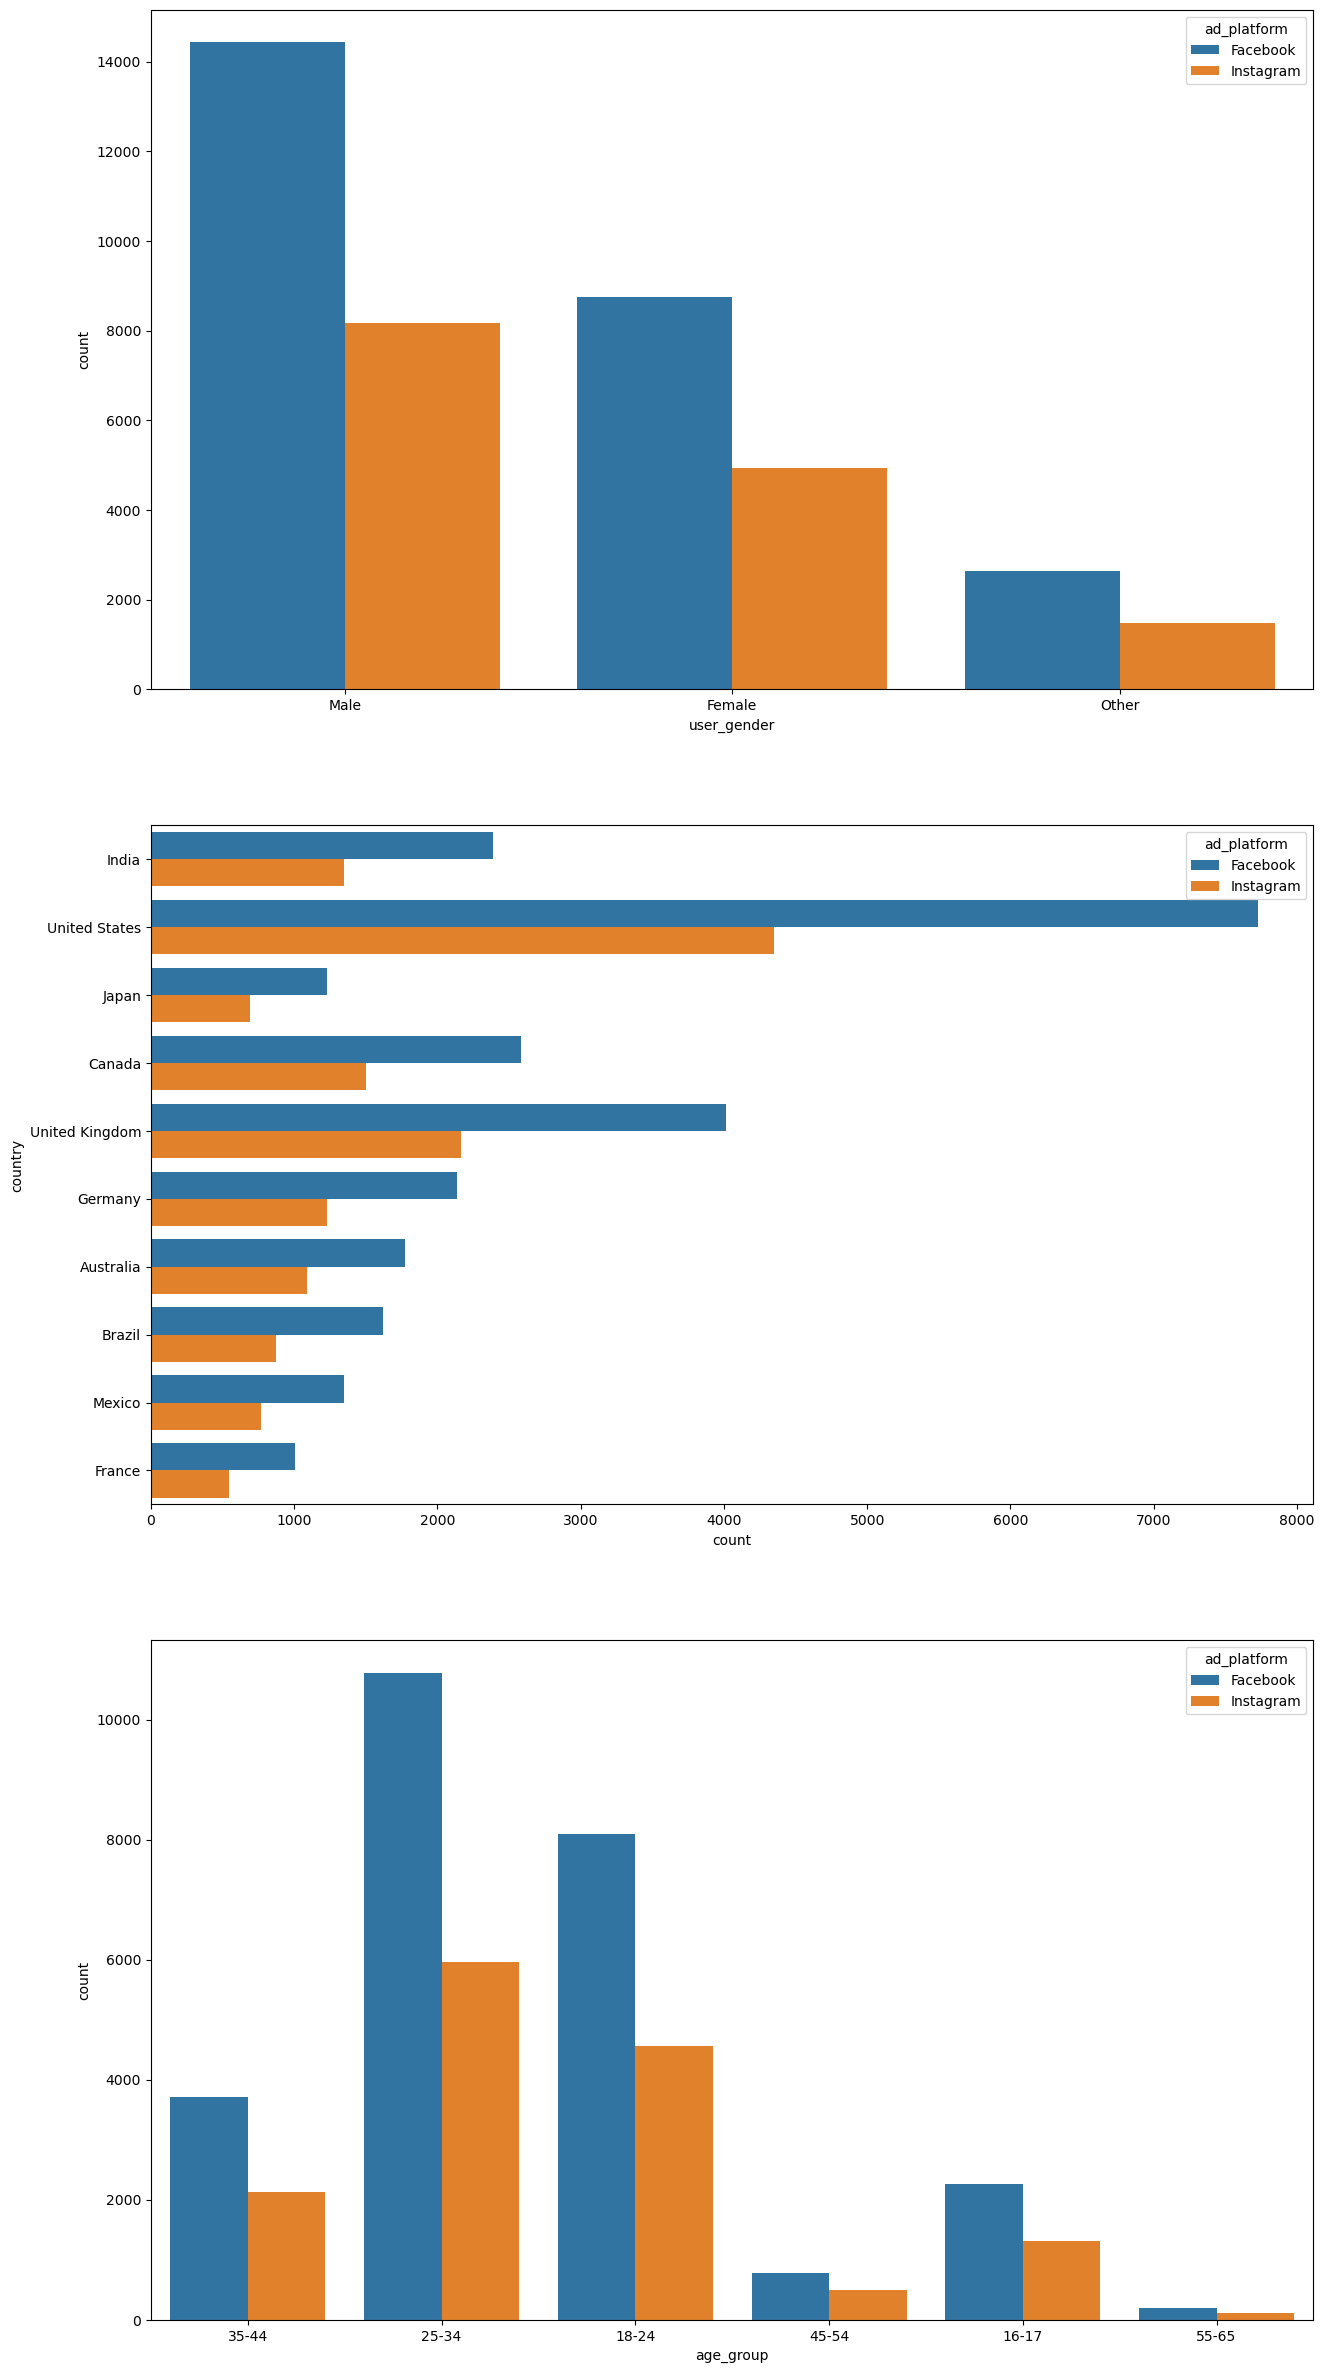

In [134]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_all,x="user_gender",hue="ad_platform",ax=ax1)
sns.countplot(data=df_all,y="country",hue="ad_platform",ax=ax2)
sns.countplot(data=df_all,x="age_group",hue="ad_platform",ax=ax3);

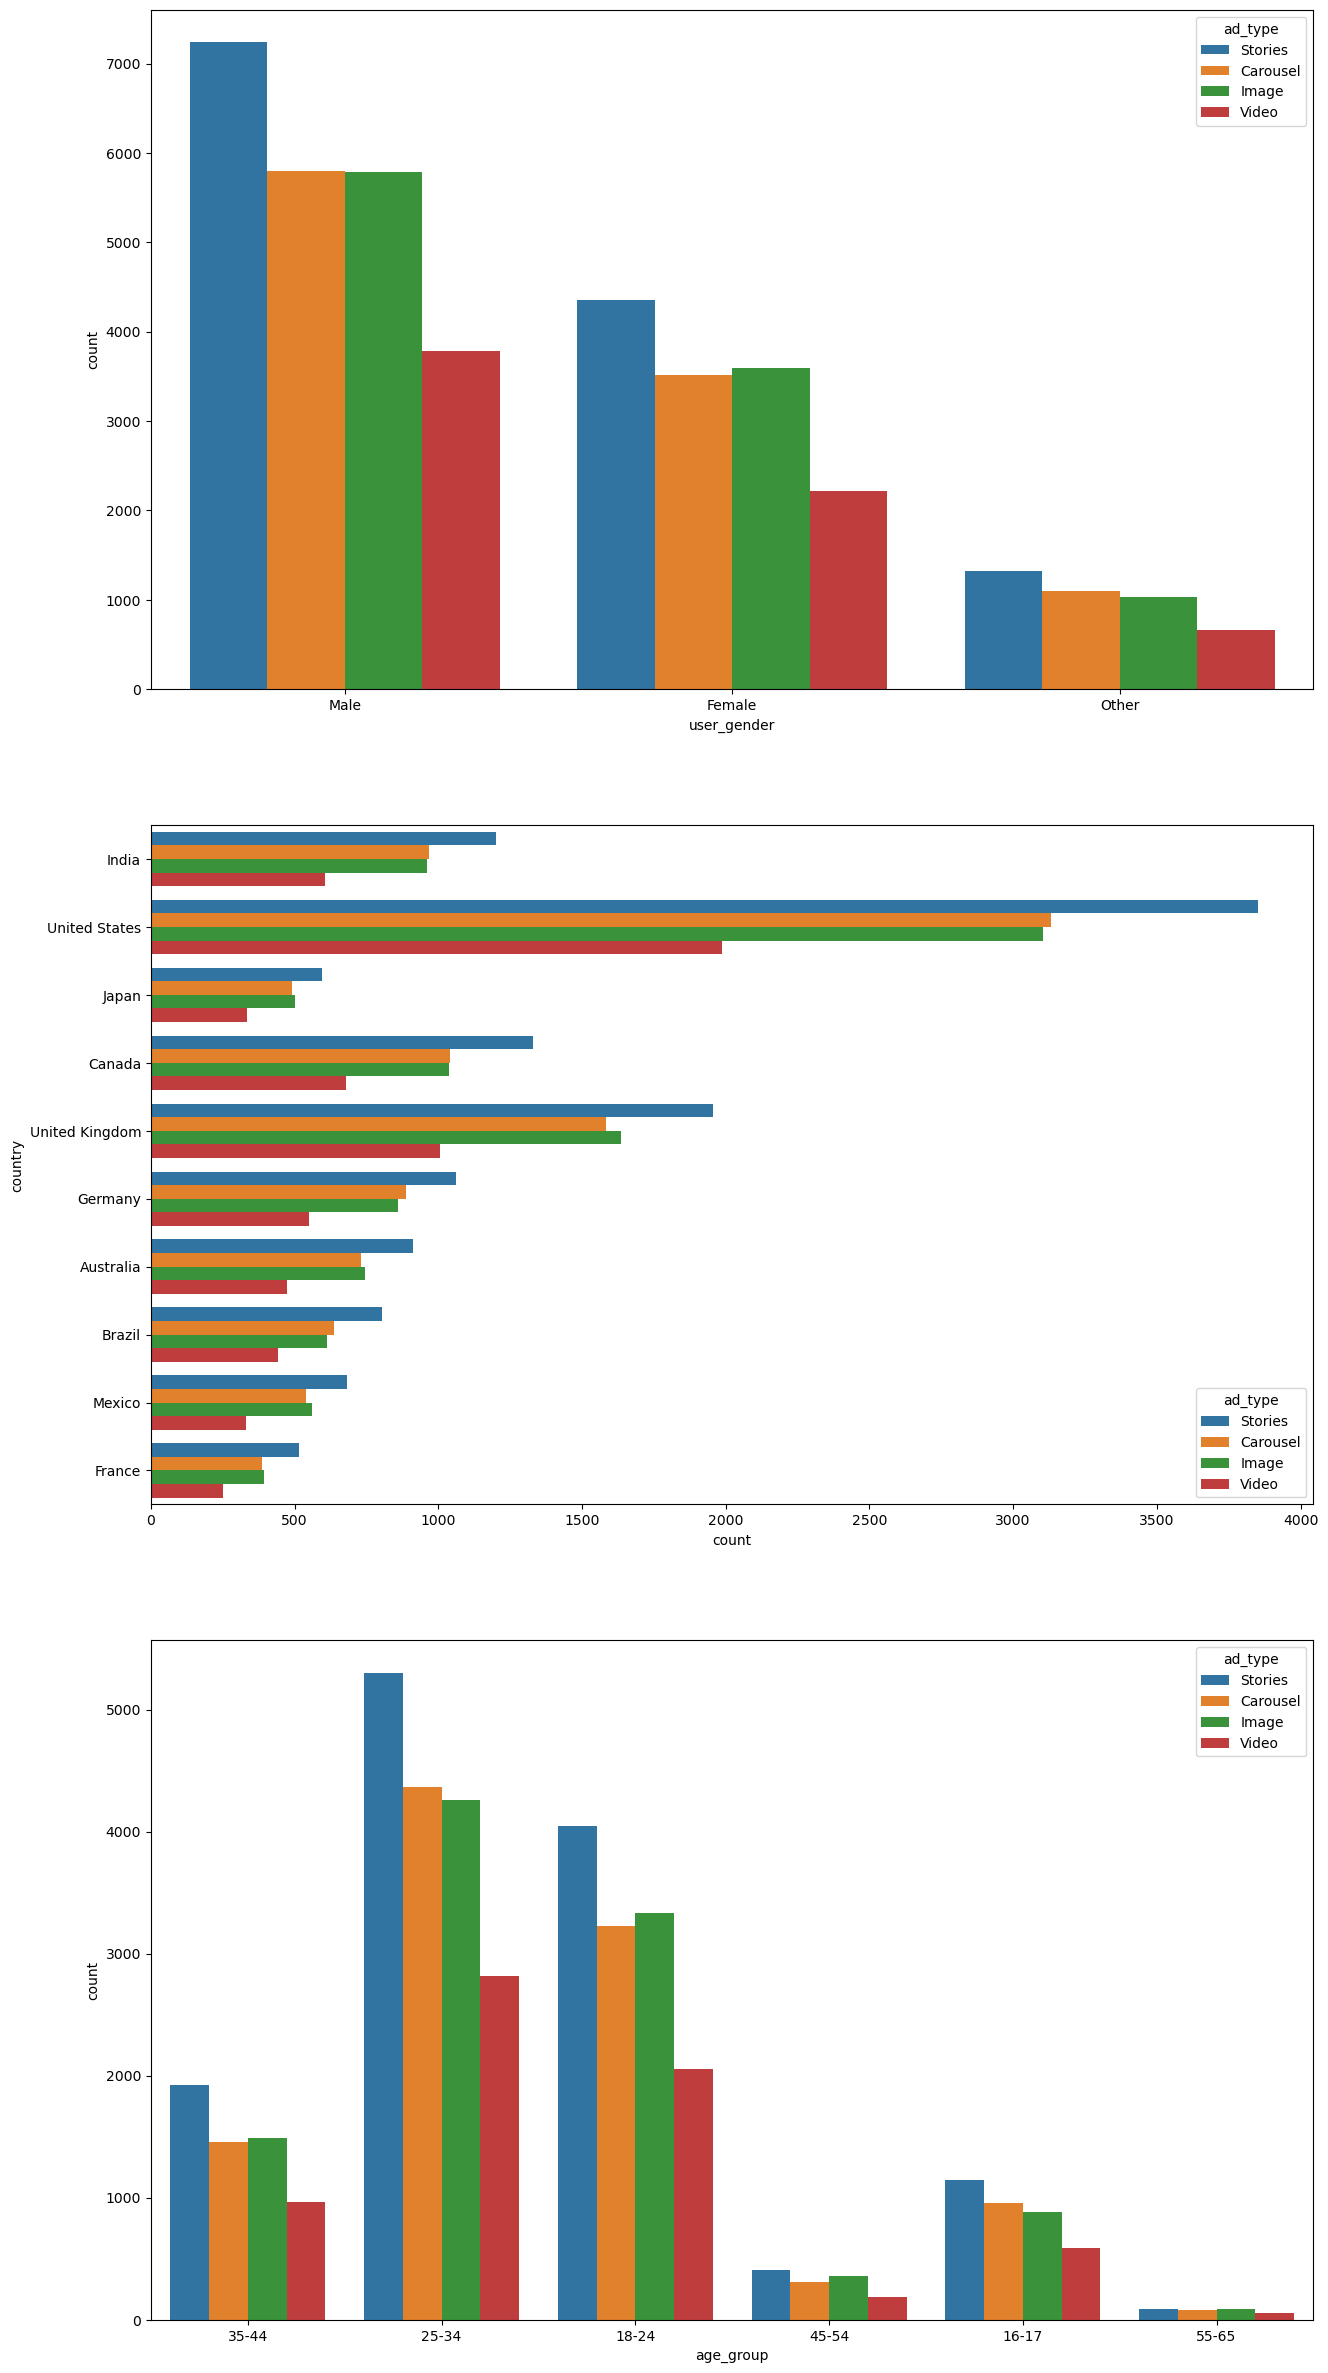

In [135]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_all,x="user_gender",hue="ad_type",ax=ax1)
sns.countplot(data=df_all,y="country",hue="ad_type",ax=ax2)
sns.countplot(data=df_all,x="age_group",hue="ad_type",ax=ax3);

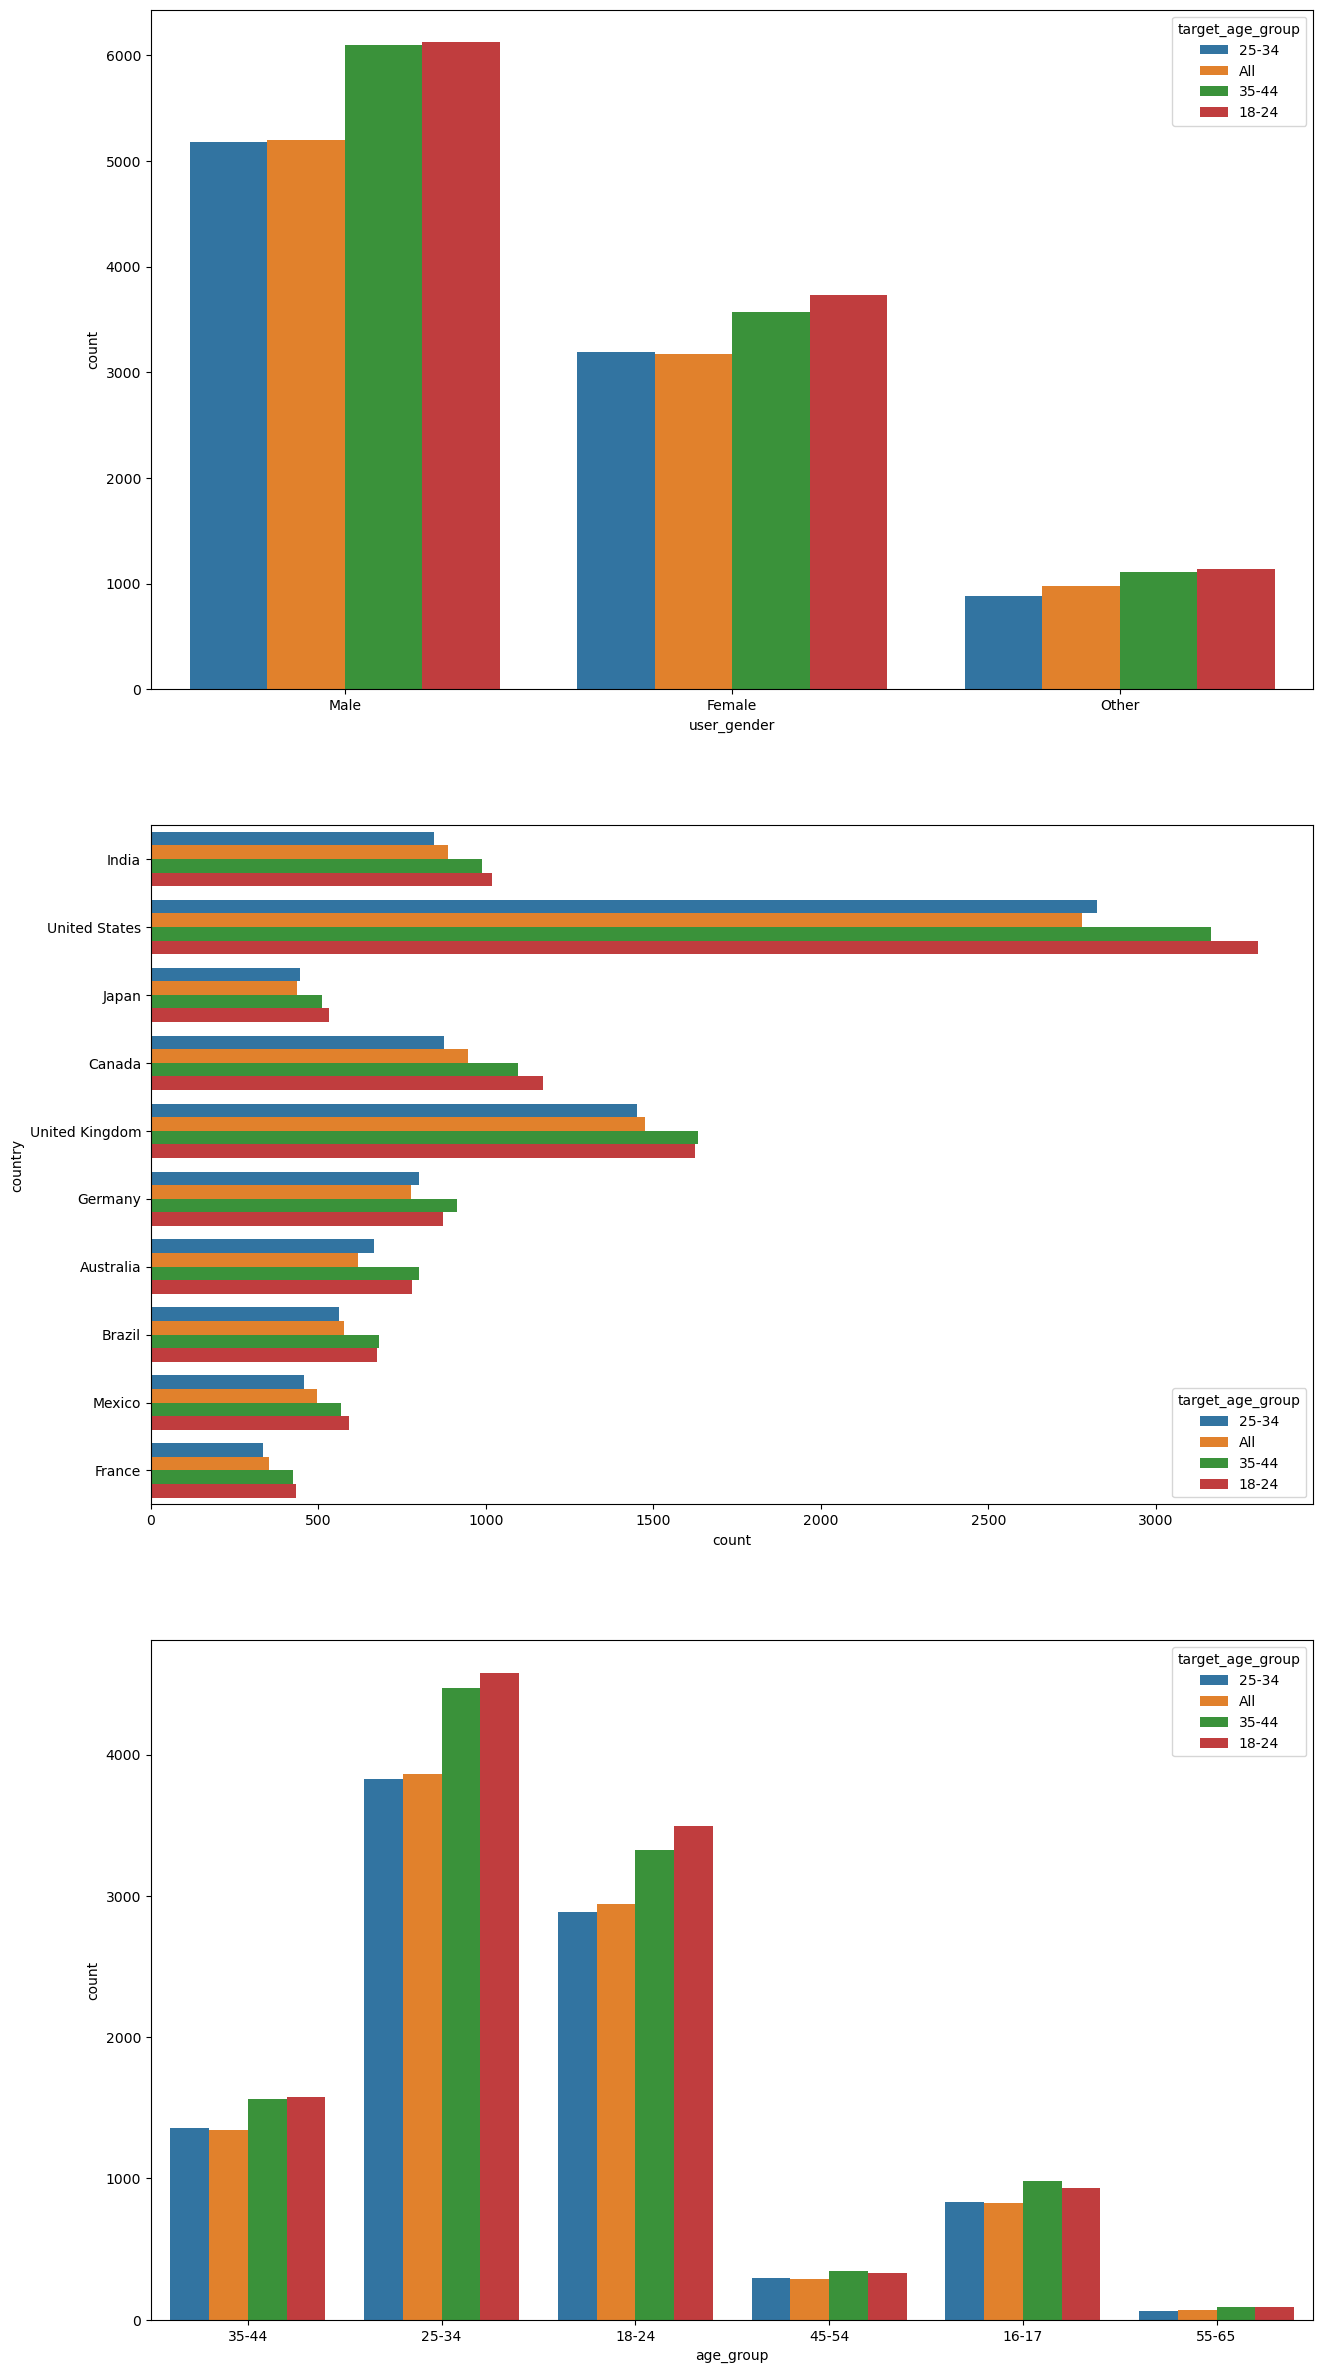

In [136]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];

sns.countplot(data=df_all,x="user_gender",hue="target_age_group",ax=ax1)
sns.countplot(data=df_all,y="country",hue="target_age_group",ax=ax2)
sns.countplot(data=df_all,x="age_group",hue="target_age_group",ax=ax3);

### USER VS CAMPAIGN

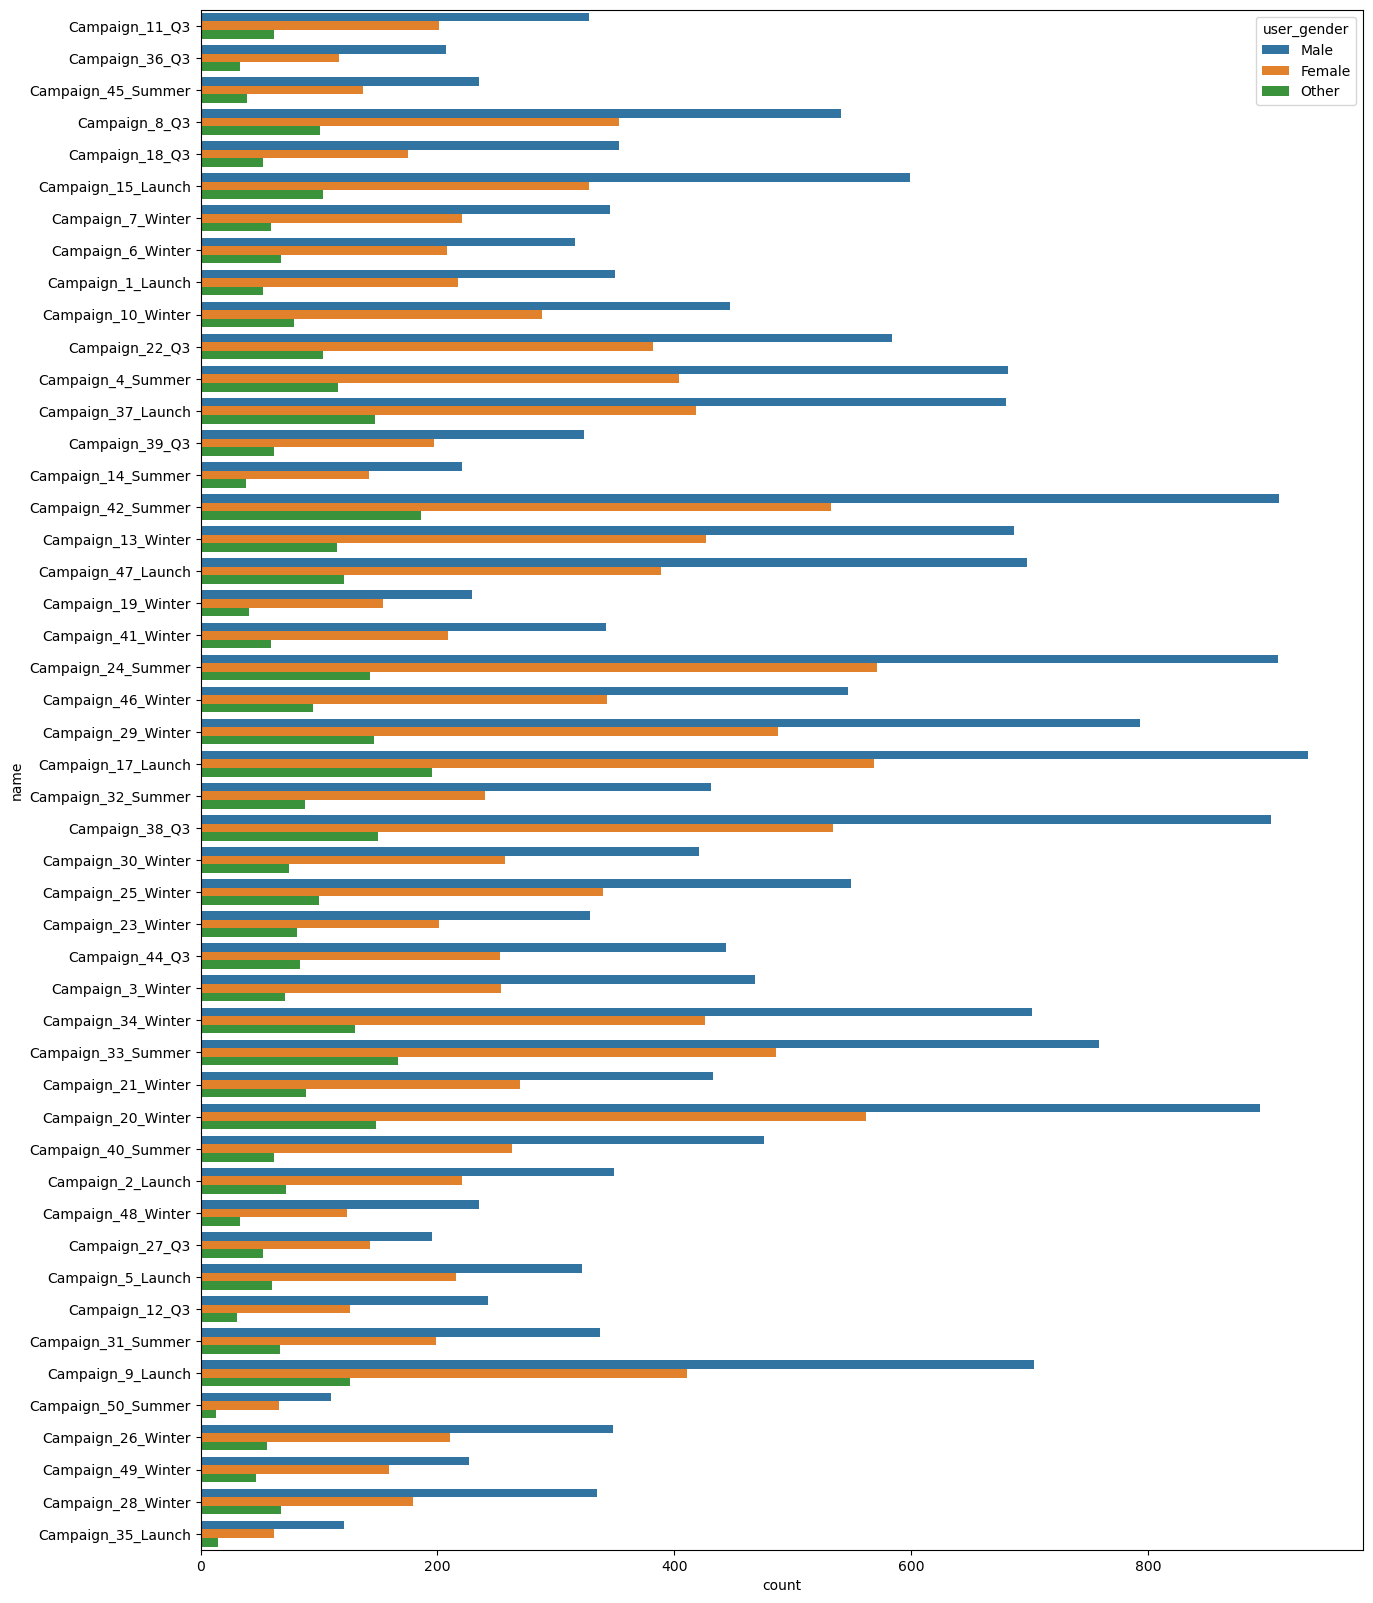

In [137]:
plt.figure(figsize=(15,20))
sns.countplot(data=df_all,hue="user_gender",y="name");

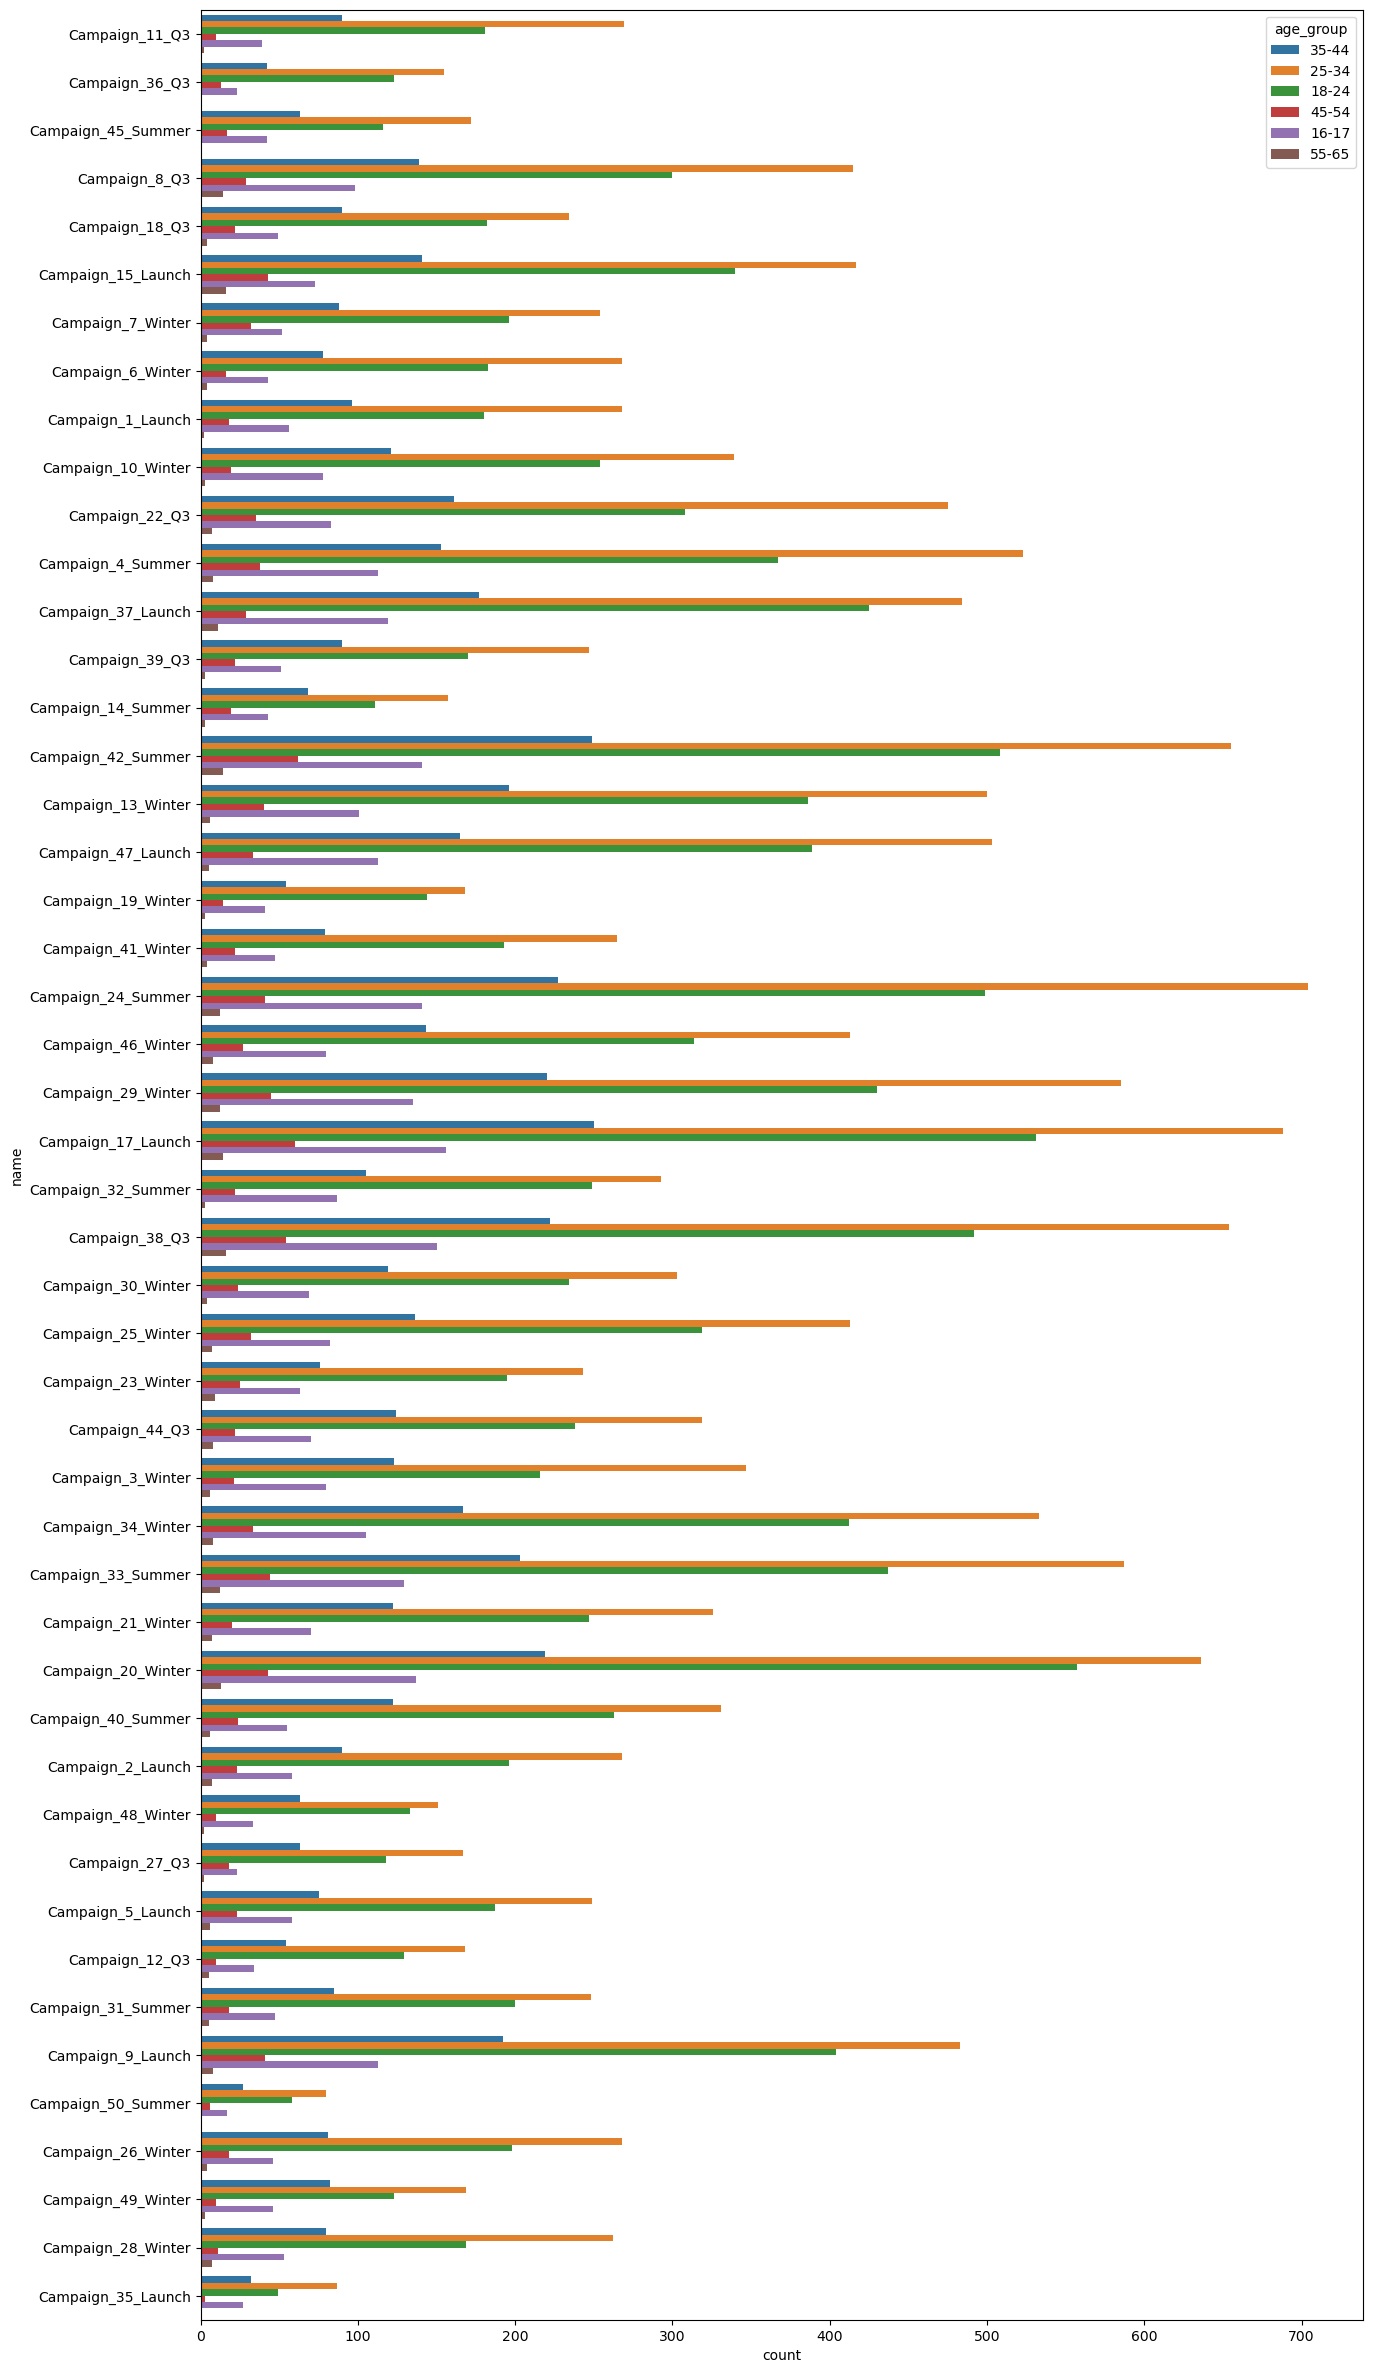

In [138]:
plt.figure(figsize=(15,30))
sns.countplot(data=df_all,hue="age_group",y="name");

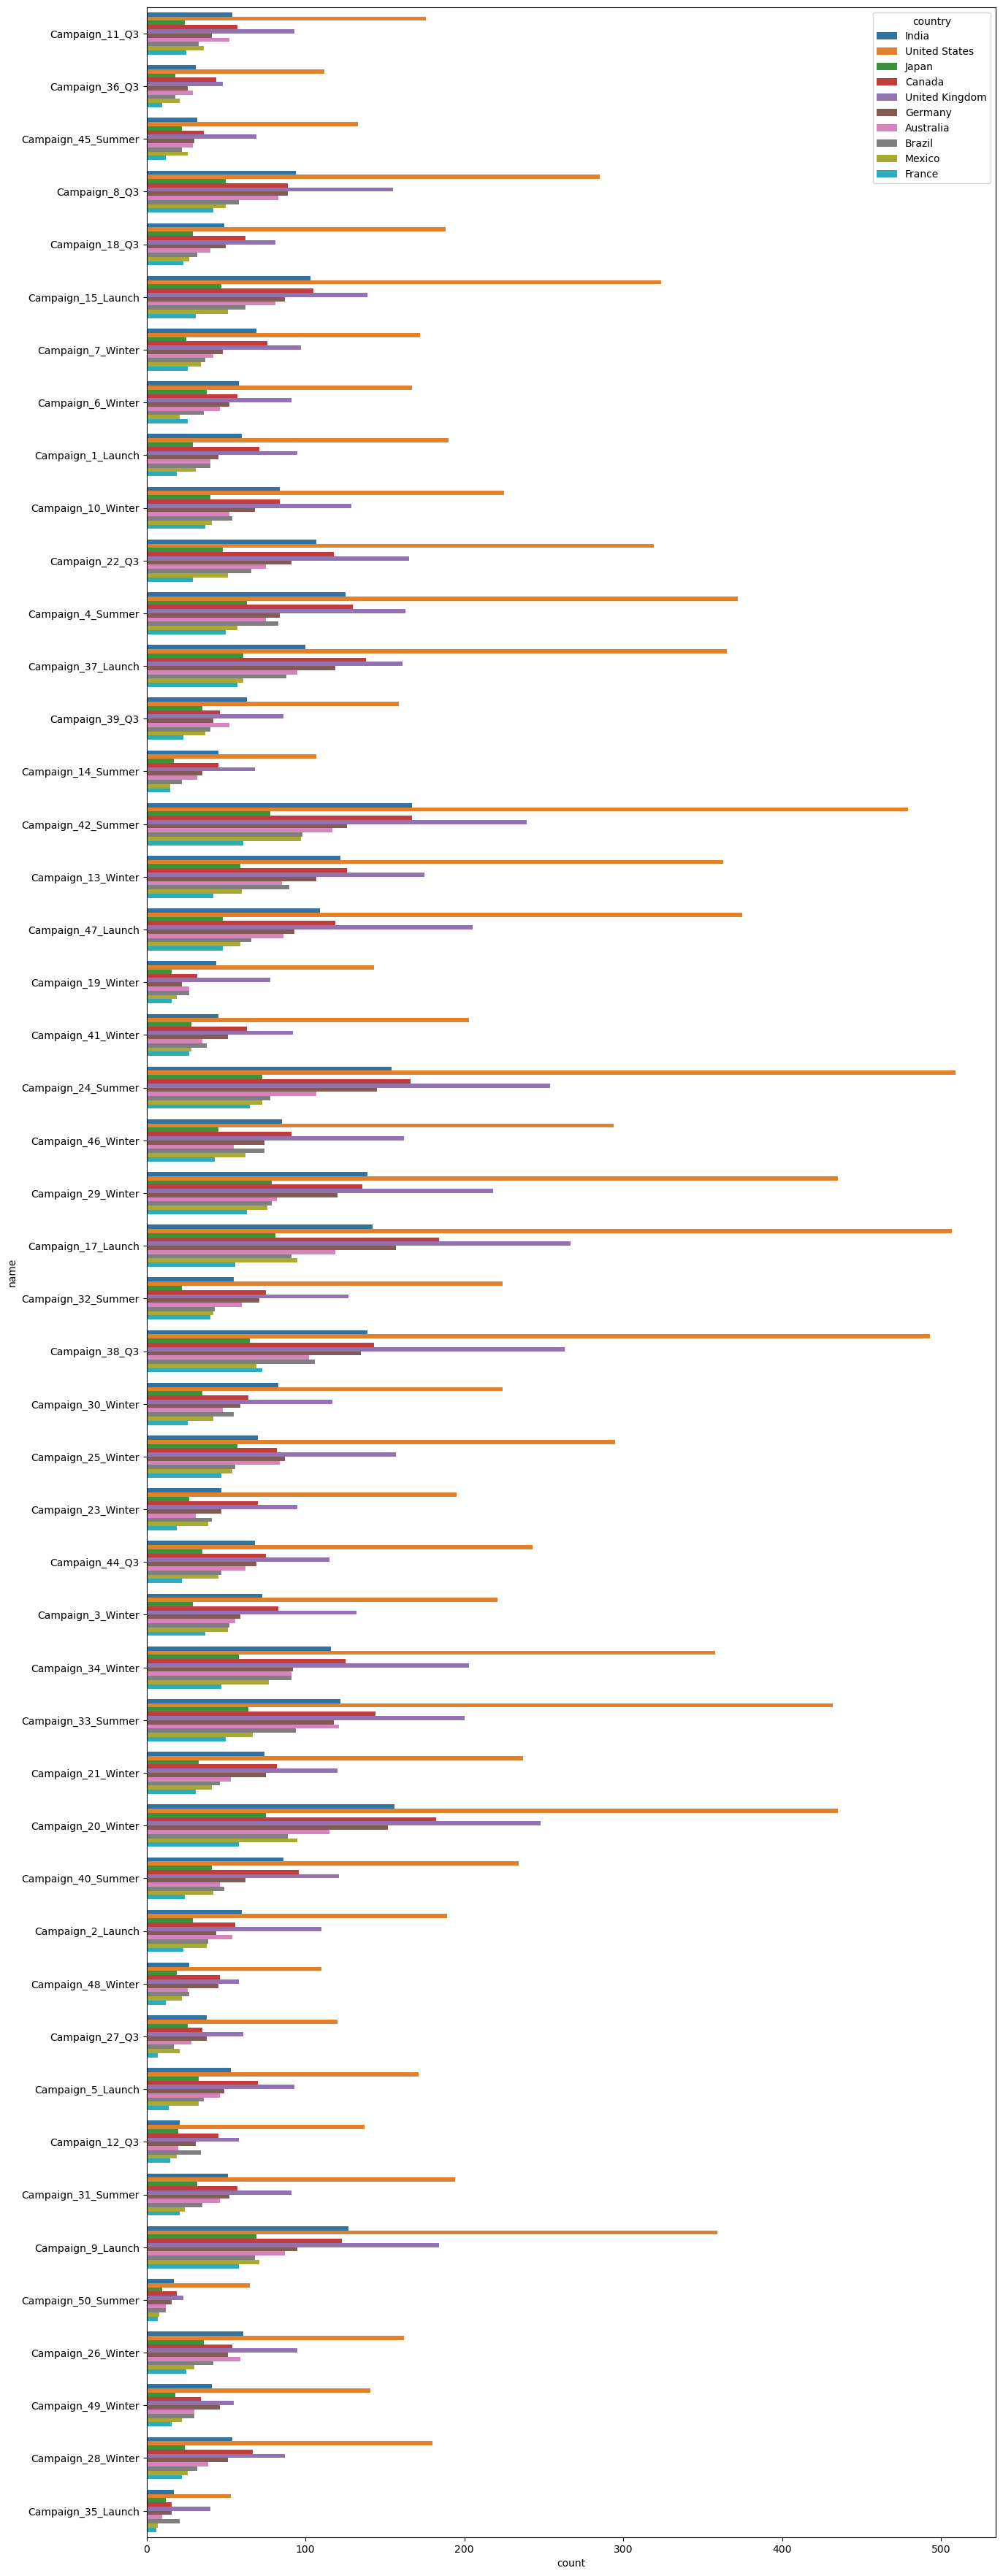

In [139]:
plt.figure(figsize=(15,45))
sns.countplot(data=df_all,hue="country",y="name");

### CAMPAIGN VS EVENTS

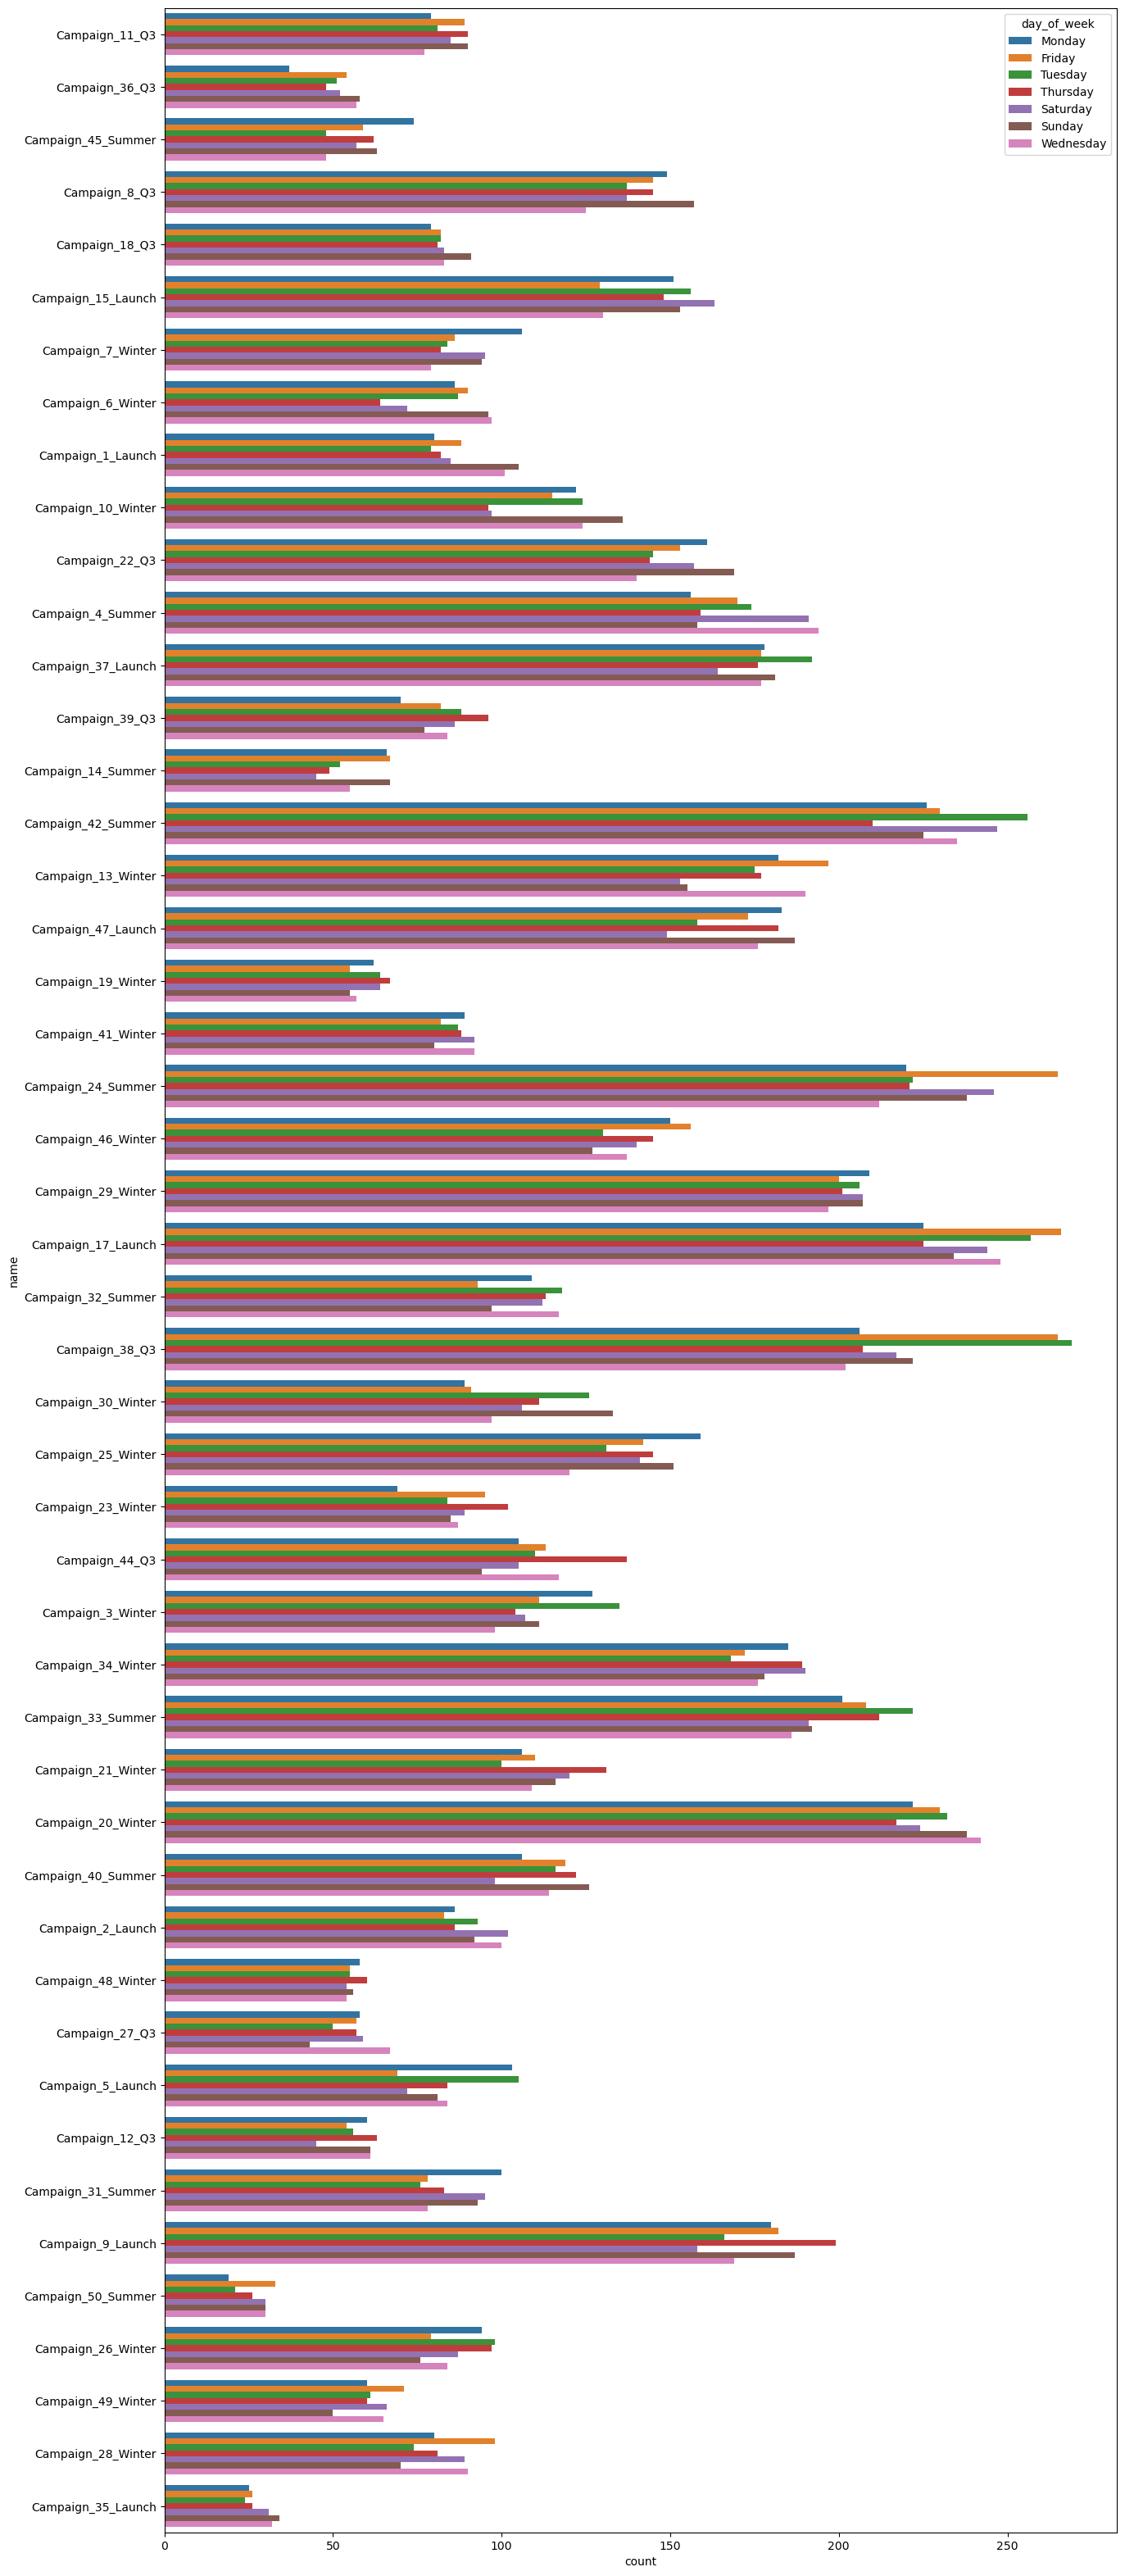

In [140]:
plt.figure(figsize=(15,40))
sns.countplot(data=df_all,hue="day_of_week",y="name");

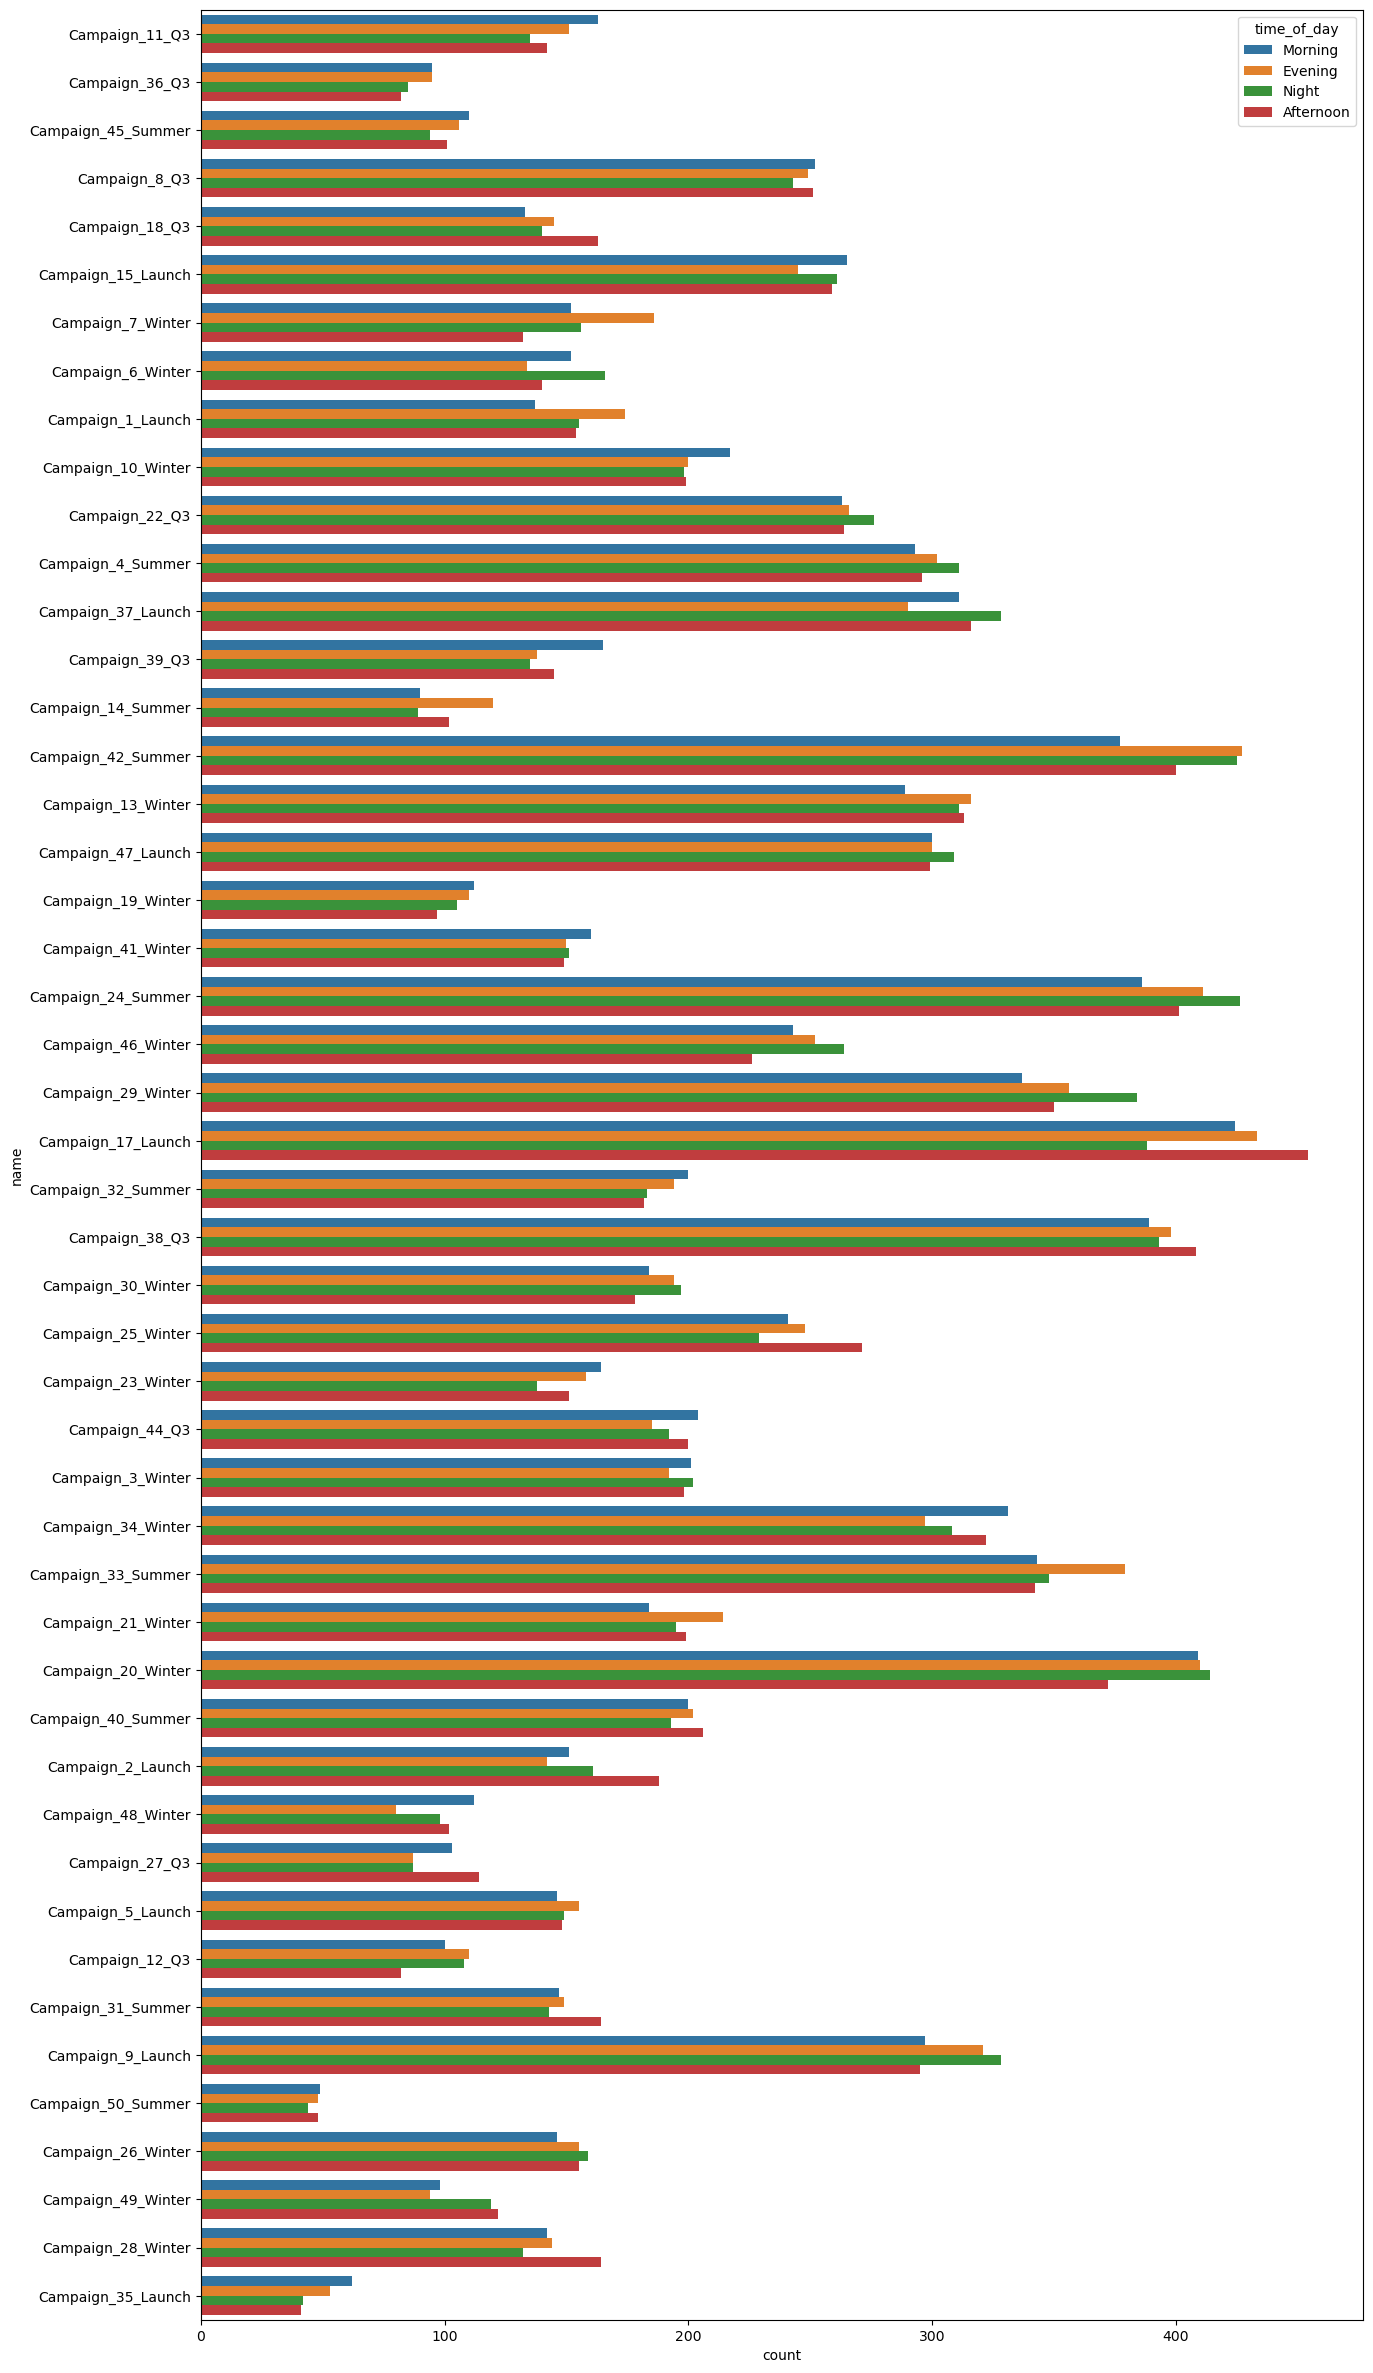

In [141]:
plt.figure(figsize=(15,30))
sns.countplot(data=df_all,hue="time_of_day",y="name");

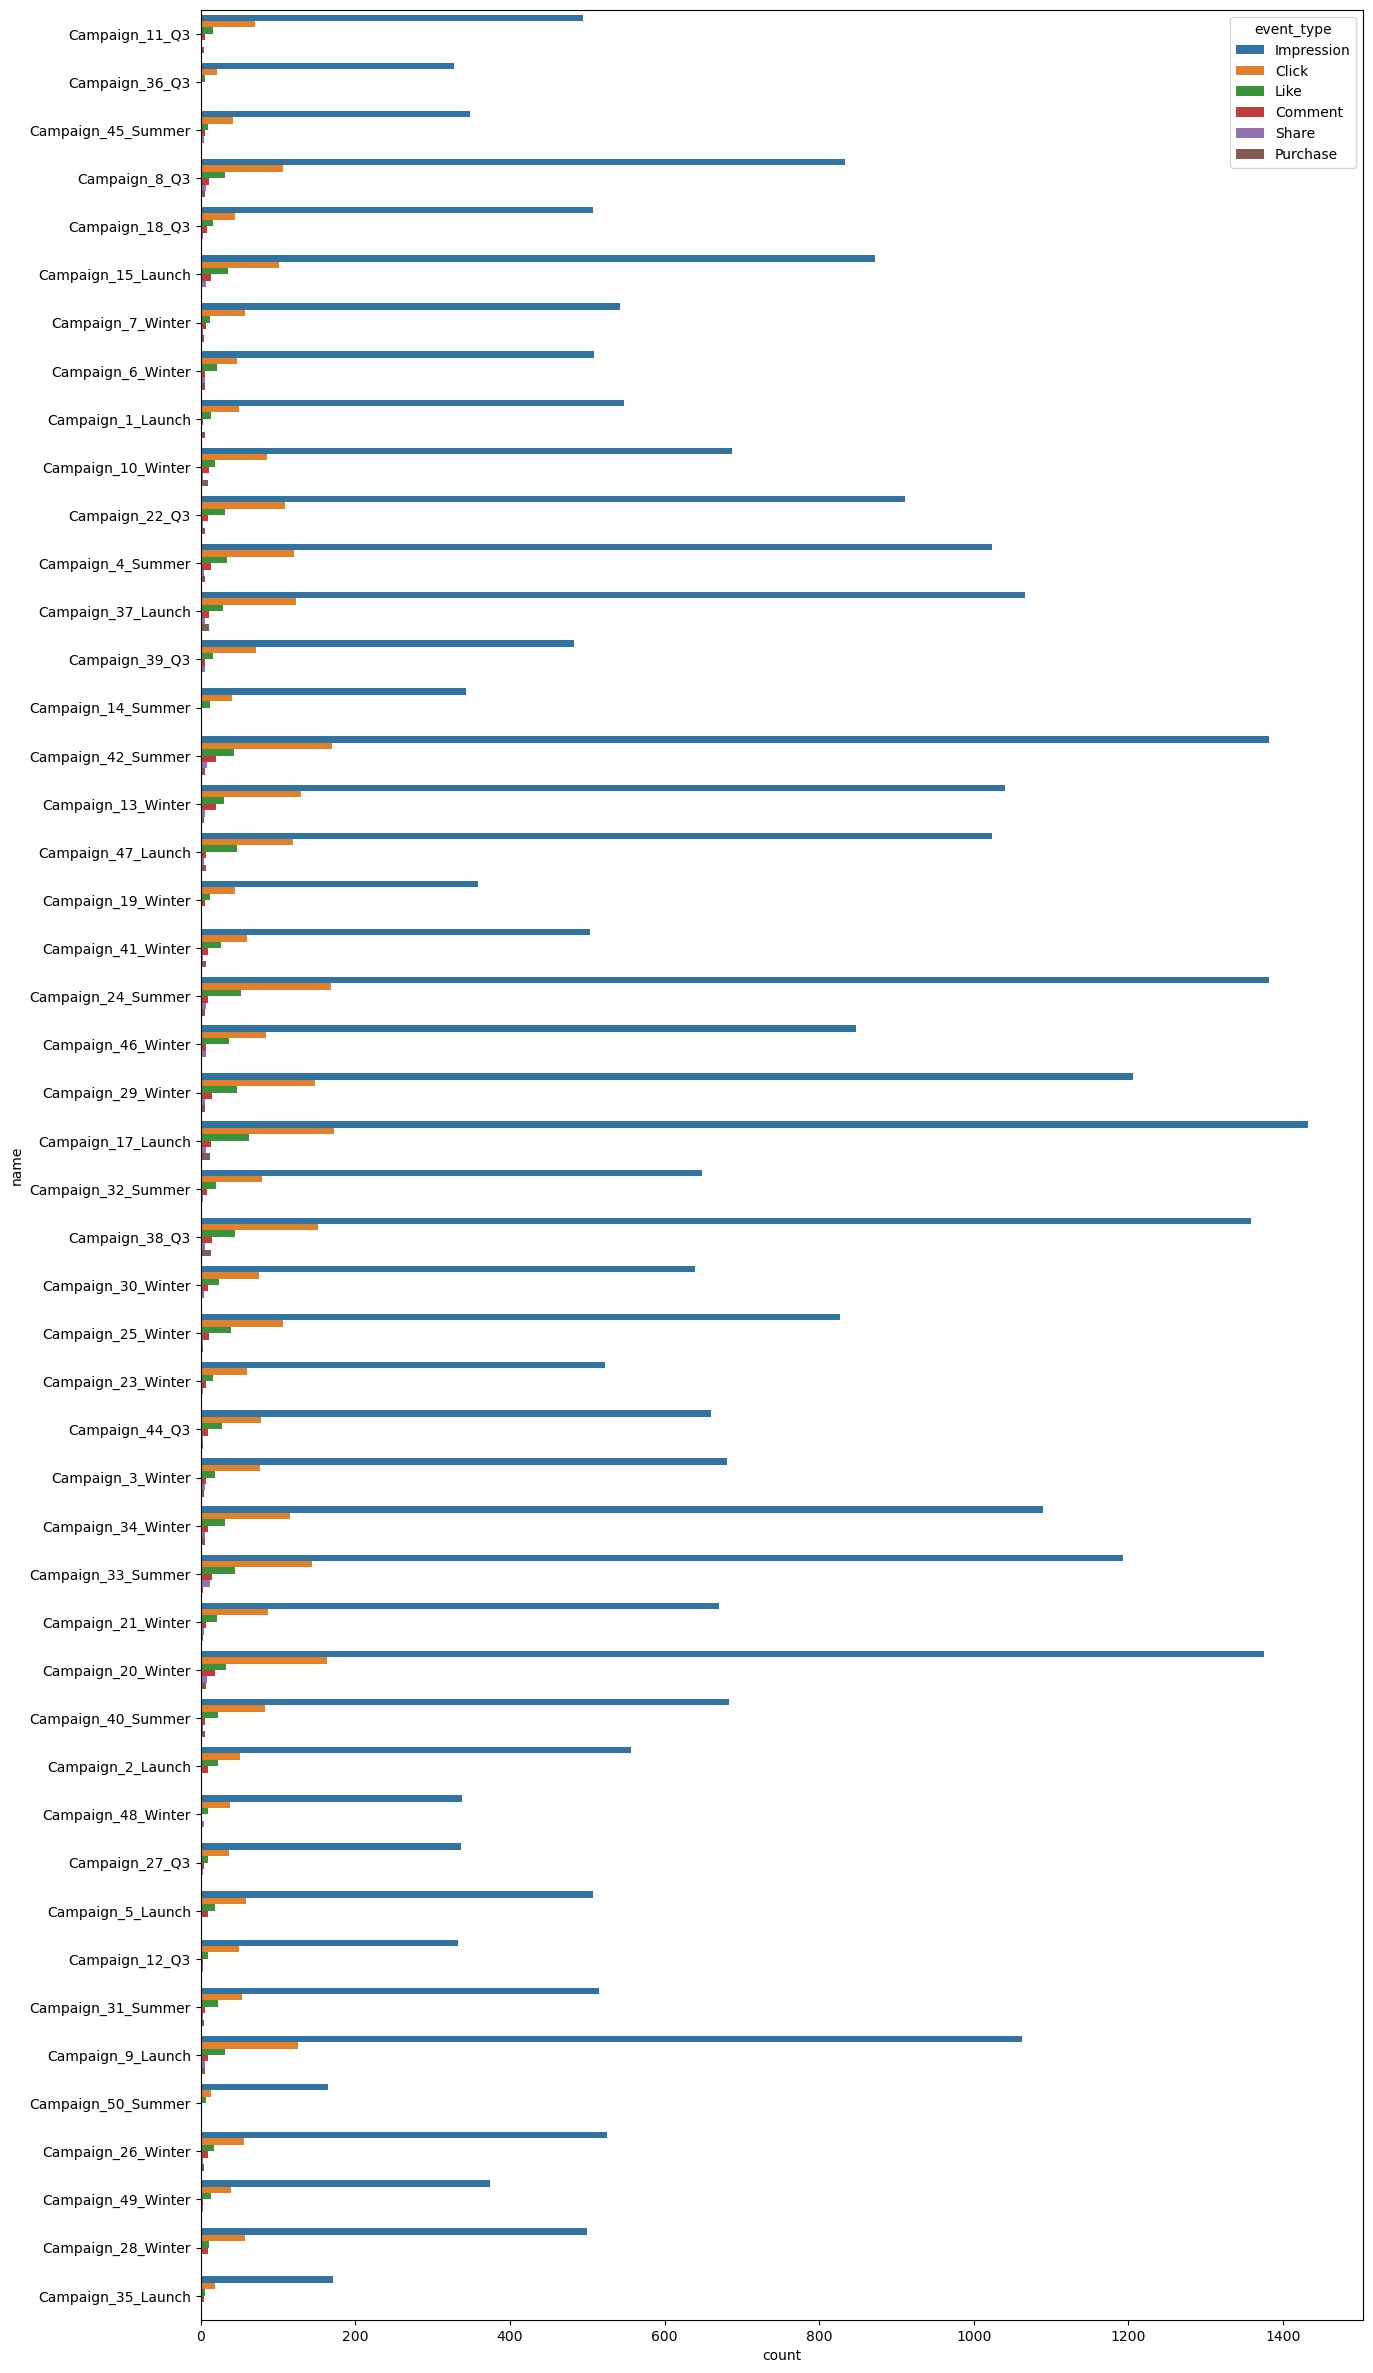

In [142]:
plt.figure(figsize=(15,30))
sns.countplot(data=df_all,hue="event_type",y="name");

## RESUME ADS VS USER TABLE
**user_gender vs target_gender:** *This chart reveals which ads targeted at different genders were consumed by users of different genders, and whether they preferred ads specifically targeted to their gender. The chart shows that both men and women consumed ads aimed at female audiences, followed by ads for the general public, and finally ads aimed at men.*\
**country vs target_gender:** *THIS GRAPHIC SHOWS THE CONSUMPTION OF ADVERTISEMENTS TARGETED AT DIFFERENT GENDERS IN DIFFERENT COUNTRIES. ALL COUNTRIES CONSUMED MORE ADVERTISEMENTS TARGETED AT FEMALE AUDIENCES, FOLLOWED BY ADVERTISEMENTS TARGETED AT THE GENERAL AUDIENCE, AND FINALLY ADVERTISEMENTS TARGETED AT MALE AUDIENCES.*\
**age_group vs target_gender:** *THIS GRAPH SHOWS AD CONSUMPTION BY USERS OF DIFFERENT AGE RANGES. IN ALL CASES, USERS CONSUMED MORE ADS TARGETED AT FEMALE AUDIENCES, FOLLOWED BY THE GENERAL AUDIENCE, AND FINALLY BY MALE AUDIENCES.*\
**user_gender vs ad_platform:** *This chart shows users of different genders who viewed ads on different platforms. In all cases, more ads were viewed on Facebook, followed by Instagram.*\
**country vs ad_platform:** *THIS GRAPHIC SHOWS AD CONSUMPTION IN DIFFERENT COUNTRIES ACROSS VARIOUS PLATFORMS. IN ALL CASES, MORE ADS WERE CONSUMED ON THE FACEBOOK PLATFORM.*\
**age_group vs ad_platform:** *THIS GRAPHIC SHOWS AD CONSUMPTION ACROSS DIFFERENT PLATFORMS BY USERS OF DIFFERENT AGES. IN ALL CASES, USERS CONSUMED MORE ADS ON THE FACEBOOK PLATFORM.*\
**user_gender vs ad_type:** *This chart shows ad consumption in different formats by users of different genders. In all cases, Stories ads were consumed the most. Second, females and males consumed slightly more image ads, while those of undetermined gender consumed more carousel ads. Third, females and males consumed more carousel ads, while those of undetermined gender consumed more image ads. Finally, video ads were consumed the most in all cases.*\
**country vs ad_type:** *This chart shows the different countries that consumed ads in different formats. In India, the United Kingdom, the USA, Australia, Canada, and France, the most consumed ads were in the Stories format, followed by image, carousel, and finally video. In Mexico, Germany, Japan, and Brazil, the most consumed ads were in the Stories format, followed by carousel, image, and finally video.*\
**age_group vs ad_type:** *This chart shows the most consumed ads in different formats by users of different ages. In most cases, users consumed more ads in Story format, followed by image, carousel, and finally video. Only among 16-17 and 45-54 year olds was there a slight increase in carousel ad consumption compared to image ads.*\
**user_gender vs target_age_group:***This graph shows the consumption of ads targeted at different age groups by users of different genders. Female and male users consumed more ads aimed at the 35-44 age group, followed by the 18-24 age group, then the general public, and finally the 25-34 age group. Users of unspecified gender consumed more ads aimed at the 18-24 age group, followed by the 35-44 age group.*\
**country vs target_age_group:** *This chart shows the consumption of targeted ads for different age groups across various countries. In India, the UK, the USA, Brazil, Australia, Mexico, and France, the most ads were targeted at users aged 35-44, followed by those aged 18-24. In Germany, Canada, and Japan, the most ads were targeted at the 18-24 age group, followed by those aged 35-44.*\
**age_group vs target_age_group:** *This graph shows the consumption of ads targeted at different age groups by users of different ages. For users aged 25-34, 16-17, 35-44, and 45-54, the most consumed ads were those targeting the 35-44 age group, followed by 18-24. Users aged 18-24 and 55-65 consumed more ads primarily targeting the 18-24 age group, followed by 35-44.*\
**user_gender vs name:** *THIS GRAPHIC SHOWS THE IMPACT OF THE CAMPAIGNS ON DIFFERENT USERS DIVIDED BY GENDER. IN ALL CASES, THE CAMPAIGNS REACHED THE MOST MALE AUDIENCE, FOLLOWED BY THE FEMALE AUDIENCE, AND FINALLY THE AUDIENCE WITHOUT SPECIFICATION OF GENDER.*\
**age_group vs name:** *This chart shows the impact each campaign had on users in different age ranges. In all cases, the campaigns reached the 25-34 age group most, followed by the 18-24 and 35-44 age groups.*\
**country vs name:** *This chart shows the reach of the campaigns in different countries. In all cases, the campaigns had the greatest reach in the United States, followed by the United Kingdom. In some cases, the campaigns had the greatest reach in Canada, and in others, in India.*\